In [99]:
library(asreml)
library(data.table)
library(tidyverse)
library(parallel)
library(qqman)
library(topGO)

In [2]:
# asreml.license.activate(acode = "GHFF-ABBA-EDFE-FCGC")

In [2]:
# from Charlie
plotTraitOnTree <- function(traits, taxa, tree, visible_tip_labels = FALSE, 
                            plot.title = NA, legend.title = "",col = c("red","white","blue"),
                            type = 'phylogram',direction = 'rightwards',fontsize = 1) {
  # Drop trait observations for taxa that are not present in tree
  taxaNotInTree <- taxa[!taxa %in% tree$tip.label]
  
  trait.df <- data.frame(cbind(traits, taxa)) %>%
    filter(!taxa %in% taxaNotInTree) %>%
    filter(!is.na(traits)) 
  trait.vec <- as.numeric(as.matrix(trait.df)[,1]) # Convert to vector to enable plotting
  names(trait.vec) <- trait.df$taxa
  # Drop tips that are not present in trait/taxa list
  tipsToDrop <- tree$tip.label[!tree$tip.label %in% trait.df$taxa]
  tree.pruned <- drop.tip(tree, tipsToDrop)
  # Set negative branch lengths to 0
  tree.pruned$edge.length[tree.pruned$edge.length < 0] <- 0
  # Check that names in tree match names in data matrix
  name.check(tree.pruned, trait.vec)
  # Determine whether tip labels are visible based on user arguments
  font.size <- c(0.00001,1)
  if(visible_tip_labels) {
    font.size <- c(fontsize,1)
  }
  # Generate plot
#   options(repr.plot.width=plot.dim[1], repr.plot.height=plot.dim[2])
  plot <- contMap(tree.pruned,trait.vec, plot = FALSE)
  plot <-setMap(plot, col)
  plot(plot, fsize = font.size,outline= F, title = plot.title,lwd = 2,type = type,direction = direction,
       leg.txt=legend.title)
  }

In [3]:
fit_model <- function(OG_id, data, Kmat, trait) {
#   library(asreml)
  asreml.options(verbose = FALSE)
  filtered_data <- subset(data, OG == OG_id)
  #filtered_data <- filtered_data %>% group_by(assemblyID) %>% slice_max(queryCov, n = 1, with_ties = FALSE) %>% ungroup()
  phyloK_OG <- Kmat[rownames(Kmat) %in% filtered_data$assemblyID,]
  phyloK_OG <- phyloK_OG[,colnames(phyloK_OG) %in% filtered_data$assemblyID]
  model <- asreml(fixed = trait ~ dn.ds, random = ~ vm(assemblyID, phyloK_OG) + compdup, ai.sing = TRUE, data = filtered_data)
  #model <- asreml(fixed = lifeHistoryNumeric ~ dn.ds, random = ~compdup, ai.sing = TRUE, data = filtered_data)
  modelSummary <- summary(model)
  loglik <- modelSummary$loglik
  tabasco_explained <- modelSummary$varcomp$component[1]
  phylo_explained <- modelSummary$varcomp$component[2]
  modelWald <- wald.asreml(model)
  dnds_coeff <- model$coefficients$fixed[2]
  dnds_pval <- modelWald[2,4]
  dnds_explained <- modelWald[2,2]/sum(modelWald[,2])
  return(c(OG_id,dnds_coeff, dnds_pval, loglik, tabasco_explained, phylo_explained, dnds_explained))
}

In [4]:
fit_model_ePC1 <- function(OG_id, data, Kmat) {
#   library(asreml)
  asreml.options(verbose = FALSE)
  filtered_data <- subset(data, OG == OG_id)
  #filtered_data <- filtered_data %>% group_by(assemblyID) %>% slice_max(queryCov, n = 1, with_ties = FALSE) %>% ungroup()
  phyloK_OG <- Kmat[rownames(Kmat) %in% filtered_data$assemblyID,]
  phyloK_OG <- phyloK_OG[,colnames(phyloK_OG) %in% filtered_data$assemblyID]
  model <- asreml(fixed = envPC_1 ~ dn.ds, random = ~ vm(assemblyID, phyloK_OG) + compdup, ai.sing = TRUE, data = filtered_data)
  #model <- asreml(fixed = lifeHistoryNumeric ~ dn.ds, random = ~compdup, ai.sing = TRUE, data = filtered_data)
  modelSummary <- summary(model)
  loglik <- modelSummary$loglik
  tabasco_explained <- modelSummary$varcomp$component[1]
  phylo_explained <- modelSummary$varcomp$component[2]
  modelWald <- wald.asreml(model)
  dnds_coeff <- model$coefficients$fixed[2]
  dnds_pval <- modelWald[2,4]
  dnds_explained <- modelWald[2,2]/sum(modelWald[,2])
  return(c(OG_id,dnds_coeff, dnds_pval, loglik, tabasco_explained, phylo_explained, dnds_explained))
}

In [5]:
fit_model_ePC2 <- function(OG_id, data, Kmat) {
#   library(asreml)
  asreml.options(verbose = FALSE)
  filtered_data <- subset(data, OG == OG_id)
  #filtered_data <- filtered_data %>% group_by(assemblyID) %>% slice_max(queryCov, n = 1, with_ties = FALSE) %>% ungroup()
  phyloK_OG <- Kmat[rownames(Kmat) %in% filtered_data$assemblyID,]
  phyloK_OG <- phyloK_OG[,colnames(phyloK_OG) %in% filtered_data$assemblyID]
  model <- asreml(fixed = envPC_2 ~ dn.ds, random = ~ vm(assemblyID, phyloK_OG) + compdup, ai.sing = TRUE, data = filtered_data)
  #model <- asreml(fixed = lifeHistoryNumeric ~ dn.ds, random = ~compdup, ai.sing = TRUE, data = filtered_data)
  modelSummary <- summary(model)
  loglik <- modelSummary$loglik
  tabasco_explained <- modelSummary$varcomp$component[1]
  phylo_explained <- modelSummary$varcomp$component[2]
  modelWald <- wald.asreml(model)
  dnds_coeff <- model$coefficients$fixed[2]
  dnds_pval <- modelWald[2,4]
  dnds_explained <- modelWald[2,2]/sum(modelWald[,2])
  return(c(OG_id,dnds_coeff, dnds_pval, loglik, tabasco_explained, phylo_explained, dnds_explained))
}

In [6]:
fit_model_bio01 <- function(OG_id, data, Kmat) {
#   library(asreml)
  asreml.options(verbose = FALSE)
  filtered_data <- subset(data, OG == OG_id)
  #filtered_data <- filtered_data %>% group_by(assemblyID) %>% slice_max(queryCov, n = 1, with_ties = FALSE) %>% ungroup()
  phyloK_OG <- Kmat[rownames(Kmat) %in% filtered_data$assemblyID,]
  phyloK_OG <- phyloK_OG[,colnames(phyloK_OG) %in% filtered_data$assemblyID]
  model <- asreml(fixed = bio01_Annual_Mean_Temperature_quan50 ~ dn.ds, random = ~ vm(assemblyID, phyloK_OG) + compdup, ai.sing = TRUE, data = filtered_data)
  #model <- asreml(fixed = lifeHistoryNumeric ~ dn.ds, random = ~compdup, ai.sing = TRUE, data = filtered_data)
  modelSummary <- summary(model)
  loglik <- modelSummary$loglik
  tabasco_explained <- modelSummary$varcomp$component[1]
  phylo_explained <- modelSummary$varcomp$component[2]
  modelWald <- wald.asreml(model)
  dnds_coeff <- model$coefficients$fixed[2]
  dnds_pval <- modelWald[2,4]
  dnds_explained <- modelWald[2,2]/sum(modelWald[,2])
  return(c(OG_id,dnds_coeff, dnds_pval, loglik, tabasco_explained, phylo_explained, dnds_explained))
}

In [7]:
fit_model_bio12 <- function(OG_id, data, Kmat) {
#   library(asreml)
  asreml.options(verbose = FALSE)
  filtered_data <- subset(data, OG == OG_id)
  #filtered_data <- filtered_data %>% group_by(assemblyID) %>% slice_max(queryCov, n = 1, with_ties = FALSE) %>% ungroup()
  phyloK_OG <- Kmat[rownames(Kmat) %in% filtered_data$assemblyID,]
  phyloK_OG <- phyloK_OG[,colnames(phyloK_OG) %in% filtered_data$assemblyID]
  model <- asreml(fixed = bio12_Annual_Precipitation_quan50 ~ dn.ds, random = ~ vm(assemblyID, phyloK_OG) + compdup, ai.sing = TRUE, data = filtered_data)
  #model <- asreml(fixed = lifeHistoryNumeric ~ dn.ds, random = ~compdup, ai.sing = TRUE, data = filtered_data)
  modelSummary <- summary(model)
  loglik <- modelSummary$loglik
  tabasco_explained <- modelSummary$varcomp$component[1]
  phylo_explained <- modelSummary$varcomp$component[2]
  modelWald <- wald.asreml(model)
  dnds_coeff <- model$coefficients$fixed[2]
  dnds_pval <- modelWald[2,4]
  dnds_explained <- modelWald[2,2]/sum(modelWald[,2])
  return(c(OG_id,dnds_coeff, dnds_pval, loglik, tabasco_explained, phylo_explained, dnds_explained))
}

In [8]:
fit_model_bio01_zs <- function(OG_id, data, Kmat) {
#   library(asreml)
  asreml.options(verbose = FALSE)
  filtered_data <- subset(data, OG == OG_id)
  #filtered_data <- filtered_data %>% group_by(assemblyID) %>% slice_max(queryCov, n = 1, with_ties = FALSE) %>% ungroup()
  phyloK_OG <- Kmat[rownames(Kmat) %in% filtered_data$assemblyID,]
  phyloK_OG <- phyloK_OG[,colnames(phyloK_OG) %in% filtered_data$assemblyID]
  model <- asreml(fixed = bio01_Annual_Mean_Temperature_quan50 ~ scaledZeroShotScore, random = ~ vm(assemblyID, phyloK_OG) + compdup, ai.sing = TRUE, data = filtered_data)
  #model <- asreml(fixed = lifeHistoryNumeric ~ dn.ds, random = ~compdup, ai.sing = TRUE, data = filtered_data)
  modelSummary <- summary(model)
  loglik <- modelSummary$loglik
  tabasco_explained <- modelSummary$varcomp$component[1]
  phylo_explained <- modelSummary$varcomp$component[2]
  modelWald <- wald.asreml(model)
  dnds_coeff <- model$coefficients$fixed[2]
  dnds_pval <- modelWald[2,4]
  dnds_explained <- modelWald[2,2]/sum(modelWald[,2])
  return(c(OG_id,dnds_coeff, dnds_pval, loglik, tabasco_explained, phylo_explained, dnds_explained))
}

In [9]:
fit_model_ori <- function(OG_id, data, Kmat) {
#   library(asreml)
    gc()
  asreml.options(verbose = FALSE)
  filtered_data <- subset(data, OG == OG_id)
  #filtered_data <- filtered_data %>% group_by(assemblyID) %>% slice_max(queryCov, n = 1, with_ties = FALSE) %>% ungroup()
  phyloK_OG <- Kmat[rownames(Kmat) %in% filtered_data$assemblyID,]
  phyloK_OG <- phyloK_OG[,colnames(phyloK_OG) %in% filtered_data$assemblyID]
  model <- asreml(fixed = scaled.dn.ds ~ envPC_1 + envPC_2 + envPC_3 + envPC_4 + envPC_5 + envPC_6 + envPC_7 + envPC_8 + envPC_9 + envPC_10,
                  random = ~ vm(assemblyID, phyloK_OG) + compdup , ai.sing = TRUE, data = filtered_data)
  #model <- asreml(fixed = lifeHistoryNumeric ~ dn.ds, random = ~compdup, ai.sing = TRUE, data = filtered_data)
  modelSummary <- summary(model)
  loglik <- modelSummary$loglik
  tabasco_explained <- modelSummary$varcomp$component[1]/sum(modelSummary$varcomp$component)
  phylo_explained <- modelSummary$varcomp$component[2]/sum(modelSummary$varcomp$component)
  modelWald <- wald.asreml(model)
  envPC_coeff <- model$coefficients$fixed[2:11]
  envPC_pval <- modelWald[2:11,4]
  envPC_explained <- modelWald[2:11,2]/sum(modelWald[,2])
#     return(model)
  return(c(OG_id,envPC_coeff, envPC_pval, loglik, tabasco_explained, phylo_explained))#, envPC_explained))
}

In [10]:
fit_model <- function(OG_id, data, Kmat) {
#   library(asreml)
    gc()
  asreml.options(verbose = FALSE)
  filtered_data <- subset(data, OG == OG_id)
  #filtered_data <- filtered_data %>% group_by(assemblyID) %>% slice_max(queryCov, n = 1, with_ties = FALSE) %>% ungroup()
  phyloK_OG <- Kmat[rownames(Kmat) %in% filtered_data$assemblyID,]
  phyloK_OG <- phyloK_OG[,colnames(phyloK_OG) %in% filtered_data$assemblyID]
  model <- asreml(fixed = scaled.dn.ds ~ envPC_1 + envPC_2 + envPC_3 + envPC_4 + envPC_5 + envPC_6 + envPC_7 + envPC_8 + envPC_9 + envPC_10,
                  random = ~ vm(assemblyID, phyloK_OG) + compdup + queryCov + pacbio, ai.sing = TRUE, data = filtered_data)
  #model <- asreml(fixed = lifeHistoryNumeric ~ dn.ds, random = ~compdup, ai.sing = TRUE, data = filtered_data)
  modelSummary <- summary(model)
  loglik <- modelSummary$loglik
  tabasco_explained <- modelSummary$varcomp$component[1]/sum(modelSummary$varcomp$component)
    queryCov_explained <- modelSummary$varcomp$component[2]/sum(modelSummary$varcomp$component)
    pacbio_explained <- modelSummary$varcomp$component[3]/sum(modelSummary$varcomp$component)
  phylo_explained <- modelSummary$varcomp$component[4]/sum(modelSummary$varcomp$component)
  modelWald <- wald.asreml(model)
  envPC_coeff <- model$coefficients$fixed[2:11]
  envPC_pval <- modelWald[2:11,4]
  envPC_explained <- modelWald[2:11,2]/sum(modelWald[,2])
#     return(model)
  return(c(OG_id,envPC_coeff, envPC_pval, loglik, tabasco_explained,queryCov_explained,pacbio_explained, phylo_explained))#, envPC_explained))
}

In [11]:
fit_model_zs_ori <- function(OG_id, data, Kmat) {
#   library(asreml)
    gc()
  asreml.options(verbose = FALSE)
  filtered_data <- subset(data, OG == OG_id)
  #filtered_data <- filtered_data %>% group_by(assemblyID) %>% slice_max(queryCov, n = 1, with_ties = FALSE) %>% ungroup()
  phyloK_OG <- Kmat[rownames(Kmat) %in% filtered_data$assemblyID,]
  phyloK_OG <- phyloK_OG[,colnames(phyloK_OG) %in% filtered_data$assemblyID]
  model <- asreml(fixed = scaledScore ~ envPC_1 + envPC_2 + envPC_3 + envPC_4 + envPC_5 + envPC_6 + envPC_7 + envPC_8 + envPC_9 + envPC_10 + compdup,
                  random = ~ vm(assemblyID, phyloK_OG), ai.sing = TRUE, data = filtered_data)
  #model <- asreml(fixed = lifeHistoryNumeric ~ dn.ds, random = ~compdup, ai.sing = TRUE, data = filtered_data)
  modelSummary <- summary(model)
  loglik <- modelSummary$loglik
  phylo_explained <- modelSummary$varcomp$component[1]/sum(modelSummary$varcomp$component)
  residual <- modelSummary$varcomp$component[2]
  modelWald <- wald.asreml(model)
  envPC_coeff <- model$coefficients$fixed[2:11]
  envPC_pval <- modelWald[2:11,4]
#   envPC_explained <- modelWald[2:11,2]/sum(modelWald[,2])
#     return(modelSummary)
  return(c(OG_id,envPC_coeff, envPC_pval, loglik, phylo_explained,residual))#, envPC_explained))
}

In [12]:
fit_model_zs <- function(OG_id, data, Kmat) {
#   library(asreml)
    gc()
  asreml.options(verbose = FALSE)
  filtered_data <- subset(data, OG == OG_id)
  #filtered_data <- filtered_data %>% group_by(assemblyID) %>% slice_max(queryCov, n = 1, with_ties = FALSE) %>% ungroup()
  phyloK_OG <- Kmat[rownames(Kmat) %in% filtered_data$assemblyID,]
  phyloK_OG <- phyloK_OG[,colnames(phyloK_OG) %in% filtered_data$assemblyID]
  model <- asreml(fixed = scaledScore ~ envPC_1 + envPC_2 + envPC_3 + envPC_4 + envPC_5 + envPC_6 + envPC_7 + envPC_8 + envPC_9 + envPC_10 + compdup + queryCov + pacbio,
                  random = ~ vm(assemblyID, phyloK_OG), ai.sing = TRUE, data = filtered_data)
  #model <- asreml(fixed = lifeHistoryNumeric ~ dn.ds, random = ~compdup, ai.sing = TRUE, data = filtered_data)
  modelSummary <- summary(model)
  loglik <- modelSummary$loglik
  phylo_explained <- modelSummary$varcomp$component[1]/sum(modelSummary$varcomp$component)
  residual <- modelSummary$varcomp$component[2]
  modelWald <- wald.asreml(model)
  envPC_coeff <- model$coefficients$fixed[2:11]
  envPC_pval <- modelWald[2:11,4]
#   envPC_explained <- modelWald[2:11,2]/sum(modelWald[,2])
#     return(modelSummary)
  return(c(OG_id,envPC_coeff, envPC_pval, loglik, phylo_explained,residual))#, envPC_explained))
}

In [13]:
fit_model_zs_dna_ori <- function(OG_id, data, Kmat) {
#   library(asreml)
    gc()
  asreml.options(verbose = FALSE)
  filtered_data <- subset(data, OG == OG_id)
  #filtered_data <- filtered_data %>% group_by(assemblyID) %>% slice_max(queryCov, n = 1, with_ties = FALSE) %>% ungroup()
  phyloK_OG <- Kmat[rownames(Kmat) %in% filtered_data$assemblyID,]
  phyloK_OG <- phyloK_OG[,colnames(phyloK_OG) %in% filtered_data$assemblyID]
  model <- asreml(fixed = scaledScore_DNA ~ envPC_1 + envPC_2 + envPC_3 + envPC_4 + envPC_5 + envPC_6 + envPC_7 + envPC_8 + envPC_9 + envPC_10,
                  random = ~ vm(assemblyID, phyloK_OG) + compdup, ai.sing = TRUE, data = filtered_data)
  #model <- asreml(fixed = lifeHistoryNumeric ~ dn.ds, random = ~compdup, ai.sing = TRUE, data = filtered_data)
  modelSummary <- summary(model)
  loglik <- modelSummary$loglik
  tabasco_explained <- modelSummary$varcomp$component[1]/sum(modelSummary$varcomp$component)
  phylo_explained <- modelSummary$varcomp$component[2]/sum(modelSummary$varcomp$component)
  modelWald <- wald.asreml(model)
  envPC_coeff <- model$coefficients$fixed[2:11]
  envPC_pval <- modelWald[2:11,4]
  envPC_explained <- modelWald[2:11,2]/sum(modelWald[,2])
#     return(model)
  return(c(OG_id,envPC_coeff, envPC_pval, loglik, tabasco_explained, phylo_explained))#, envPC_explained))
}

In [14]:
fit_model_zs_dna <- function(OG_id, data, Kmat) {
#   library(asreml)
    gc()
  asreml.options(verbose = FALSE)
  filtered_data <- subset(data, OG == OG_id)
  #filtered_data <- filtered_data %>% group_by(assemblyID) %>% slice_max(queryCov, n = 1, with_ties = FALSE) %>% ungroup()
  phyloK_OG <- Kmat[rownames(Kmat) %in% filtered_data$assemblyID,]
  phyloK_OG <- phyloK_OG[,colnames(phyloK_OG) %in% filtered_data$assemblyID]
  model <- asreml(fixed = scaledScore_DNA ~ envPC_1 + envPC_2 + envPC_3 + envPC_4 + envPC_5 + envPC_6 + envPC_7 + envPC_8 + envPC_9 + envPC_10,
                  random = ~ vm(assemblyID, phyloK_OG) + compdup + queryCov + pacbio, ai.sing = TRUE, data = filtered_data)
  #model <- asreml(fixed = lifeHistoryNumeric ~ dn.ds, random = ~compdup, ai.sing = TRUE, data = filtered_data)
  modelSummary <- summary(model)
  loglik <- modelSummary$loglik
  tabasco_explained <- modelSummary$varcomp$component[1]/sum(modelSummary$varcomp$component)
    queryCov_explained <- modelSummary$varcomp$component[2]/sum(modelSummary$varcomp$component)
    pacbio_explained <- modelSummary$varcomp$component[3]/sum(modelSummary$varcomp$component)
  phylo_explained <- modelSummary$varcomp$component[4]/sum(modelSummary$varcomp$component)
    
  modelWald <- wald.asreml(model)
  envPC_coeff <- model$coefficients$fixed[2:11]
  envPC_pval <- modelWald[2:11,4]
#   envPC_explained <- modelWald[2:11,2]/sum(modelWald[,2])
#     return(model)
  return(c(OG_id,envPC_coeff, envPC_pval, loglik, tabasco_explained,queryCov_explained,pacbio_explained, phylo_explained))#, envPC_explained))
}

In [15]:
fit_model_multiVar_ori <- function(OG_id, data, Kmat) {
#   library(asreml)
    gc()
  asreml.options(verbose = FALSE)
  filtered_data <- subset(data, OG == OG_id)
    filtered_data$scaled.dn.ds = -filtered_data$scaled.dn.ds
  #filtered_data <- filtered_data %>% group_by(assemblyID) %>% slice_max(queryCov, n = 1, with_ties = FALSE) %>% ungroup()
  phyloK_OG <- Kmat[rownames(Kmat) %in% filtered_data$assemblyID,]
  phyloK_OG <- phyloK_OG[,colnames(phyloK_OG) %in% filtered_data$assemblyID]
  model <- asreml(fixed = cbind(scaled.dn.ds,scaledScore,scaledScore_DNA) ~ envPC_1 + envPC_2 + envPC_3 + envPC_4 + envPC_5 + envPC_6 + envPC_7 + envPC_8 + envPC_9 + envPC_10,
                  random = ~ vm(assemblyID, phyloK_OG) + compdup , ai.sing = TRUE, data = filtered_data)
  #model <- asreml(fixed = lifeHistoryNumeric ~ dn.ds, random = ~compdup, ai.sing = TRUE, data = filtered_data)
  modelSummary <- summary(model)
  loglik <- modelSummary$loglik
  tabasco_explained <- modelSummary$varcomp$component[1]/sum(modelSummary$varcomp$component)
    phylo_explained <- modelSummary$varcomp$component[2]/sum(modelSummary$varcomp$component)
  modelWald <- wald.asreml(model)
  envPC_coeff <- model$coefficients$fixed[1:10]
  envPC_pval <- modelWald[1:10,4]
#   envPC_explained <- modelWald[1:10,2]/sum(modelWald[,2]) # wrong calculation; need to update this
#     return(model)
  return(c(OG_id,envPC_coeff, envPC_pval, loglik, 
           tabasco_explained, phylo_explained))#, envPC_explained))
}

In [16]:
fit_model_multiVar <- function(OG_id, data, Kmat) {
#   library(asreml)
    gc()
  asreml.options(verbose = FALSE)
  filtered_data <- subset(data, OG == OG_id)
    filtered_data$scaled.dn.ds = -filtered_data$scaled.dn.ds
  #filtered_data <- filtered_data %>% group_by(assemblyID) %>% slice_max(queryCov, n = 1, with_ties = FALSE) %>% ungroup()
  phyloK_OG <- Kmat[rownames(Kmat) %in% filtered_data$assemblyID,]
  phyloK_OG <- phyloK_OG[,colnames(phyloK_OG) %in% filtered_data$assemblyID]
  model <- asreml(fixed = cbind(scaled.dn.ds,scaledScore,scaledScore_DNA) ~ trait+envPC_1 + envPC_2 + envPC_3 + envPC_4 + envPC_5 + envPC_6 + envPC_7 + envPC_8 + envPC_9 + envPC_10,
                  random = ~ vm(assemblyID, phyloK_OG) + compdup + queryCov + pacbio, ai.sing = TRUE, data = filtered_data)
  #model <- asreml(fixed = lifeHistoryNumeric ~ dn.ds, random = ~compdup, ai.sing = TRUE, data = filtered_data)
  modelSummary <- summary(model)
  loglik <- modelSummary$loglik
  tabasco_explained <- modelSummary$varcomp$component[1]/sum(modelSummary$varcomp$component)
    queryCov_explained <- modelSummary$varcomp$component[2]/sum(modelSummary$varcomp$component)
    pacbio_explained <- modelSummary$varcomp$component[3]/sum(modelSummary$varcomp$component)
    phylo_explained <- modelSummary$varcomp$component[4]/sum(modelSummary$varcomp$component)
  modelWald <- wald.asreml(model)
  envPC_coeff <- model$coefficients$fixed[1:10]
  envPC_pval <- modelWald[1:10,4]
#   envPC_explained <- modelWald[1:10,2]/sum(modelWald[,2]) # wrong calculation; need to update this
    return(model)
#   return(c(OG_id,envPC_coeff, envPC_pval, loglik, 
#            tabasco_explained,queryCov_explained,pacbio_explained, phylo_explained))#, envPC_explained))
}

In [317]:
fit_model_envPC1 <- function(OG_id, data, Kmat) {
#   library(asreml)
    gc()
  asreml.options(verbose = FALSE)
  filtered_data <- subset(data, OG == OG_id)
  phyloK_OG <- Kmat[rownames(Kmat) %in% filtered_data$assemblyID,]
  phyloK_OG <- phyloK_OG[,colnames(phyloK_OG) %in% filtered_data$assemblyID]
  model_full <- asreml(fixed = envPC_1 ~ scaled.dn.ds + scaledScore + scaledScore_DNA + PMS + compdup + queryCov + pacbio,
                       random = ~ vm(assemblyID, phyloK_OG) , ai.sing = F, data = filtered_data)
  model_reduced1 <- asreml(fixed = envPC_1 ~ scaled.dn.ds + scaledScore + scaledScore_DNA +PMS + compdup + queryCov + pacbio,
                           ai.sing = F, data = filtered_data)
  filtered_data <- subset(data, OG == OG_id)
  model_reduced2 <- asreml(fixed = envPC_1 ~ compdup + queryCov + pacbio,
                  random = ~ vm(assemblyID, phyloK_OG) , ai.sing = F, data = filtered_data)  

  totalVar = var(filtered_data$envPC_1)
  modelSummary <- summary(model_full)
  IC_full = infoCriteria(model_full,IClikelihood = "full")
  IC_reduced = infoCriteria(model_reduced2,IClikelihood = "full")
  logLik_full <- IC_full$loglik
  logLik_reduced <- IC_reduced$loglik
  BIC_full <- IC_full$BIC
  BIC_reduced <- IC_reduced$BIC

  LRT_statistic <- -2 * (logLik_reduced - logLik_full)
  p_value <- pchisq(LRT_statistic, df = 4, lower.tail = FALSE)
  gene_explained <-  (model_reduced2$sigma2-model_full$sigma2)/totalVar
  phylo_explained <- (model_reduced1$sigma2-model_full$sigma2)/totalVar
  
  modelWald <- wald.asreml(model_full)
  partialCoeff <- model_full$coefficients$fixed[c(2:4,6)]
  partialPval <- modelWald[2:5,4]

    
#  return(model_full)
    out = c(OG_id,BIC_full,BIC_reduced,LRT_statistic,p_value,gene_explained,phylo_explained,totalVar,partialCoeff,partialPval)
    names(out) = c("OG","BIC_full","BIC_reduced","LR","p","geneVAE","phyloVAE","totalVar",
                   paste("partialCoeff",c("dNdS","ESM2","plantCad","PMS"),sep = "_"),
                   paste("partialP",c("dNdS","ESM2","plantCad","PMS"),sep = "_"))
  if(model_full$converge) return(out)
  else return(NULL)
}

In [318]:
fit_model_envPC2 <- function(OG_id, data, Kmat) {
#   library(asreml)
    gc()
  asreml.options(verbose = FALSE)
  filtered_data <- subset(data, OG == OG_id)
  phyloK_OG <- Kmat[rownames(Kmat) %in% filtered_data$assemblyID,]
  phyloK_OG <- phyloK_OG[,colnames(phyloK_OG) %in% filtered_data$assemblyID]
  model_full <- asreml(fixed = envPC_2 ~ scaled.dn.ds + scaledScore + scaledScore_DNA + PMS + compdup + queryCov + pacbio,
                       random = ~ vm(assemblyID, phyloK_OG) , ai.sing = F, data = filtered_data)
  model_reduced1 <- asreml(fixed = envPC_2 ~ scaled.dn.ds + scaledScore + scaledScore_DNA +PMS + compdup + queryCov + pacbio,
                           ai.sing = F, data = filtered_data)
  filtered_data <- subset(data, OG == OG_id)
  model_reduced2 <- asreml(fixed = envPC_2 ~ compdup + queryCov + pacbio,
                  random = ~ vm(assemblyID, phyloK_OG) , ai.sing = F, data = filtered_data)  

  totalVar = var(filtered_data$envPC_2)
  modelSummary <- summary(model_full)
  IC_full = infoCriteria(model_full,IClikelihood = "full")
  IC_reduced = infoCriteria(model_reduced2,IClikelihood = "full")
  logLik_full <- IC_full$loglik
  logLik_reduced <- IC_reduced$loglik
  BIC_full <- IC_full$BIC
  BIC_reduced <- IC_reduced$BIC

  LRT_statistic <- -2 * (logLik_reduced - logLik_full)
  p_value <- pchisq(LRT_statistic, df = 4, lower.tail = FALSE)
  gene_explained <-  (model_reduced2$sigma2-model_full$sigma2)/totalVar
  phylo_explained <- (model_reduced1$sigma2-model_full$sigma2)/totalVar
  
  modelWald <- wald.asreml(model_full)
  partialCoeff <- model_full$coefficients$fixed[c(2:4,6)]
  partialPval <- modelWald[2:5,4]

    
#  return(model_full)
    out = c(OG_id,BIC_full,BIC_reduced,LRT_statistic,p_value,gene_explained,phylo_explained,totalVar,partialCoeff,partialPval)
    names(out) = c("OG","BIC_full","BIC_reduced","LR","p","geneVAE","phyloVAE","totalVar",
                   paste("partialCoeff",c("dNdS","ESM2","plantCad","PMS"),sep = "_"),
                   paste("partialP",c("dNdS","ESM2","plantCad","PMS"),sep = "_"))
  if(model_full$converge) return(out)
  else return(NULL)
}

In [3]:
fit_model_envPC1_v2 <- function(OG_id, data, Kmat,envDf,asmQual) {
#   library(asreml)
    gc()
    asreml.options(verbose = FALSE)
    filtered_data <- subset(data, OG == OG_id)
    filtered_data <- filtered_data[,c("assemblyID","envPC_1","scaled.dn.ds","scaledScore", "scaledScore_DNA", "PMS",
                                      "compdup", "queryCov","pacbio")]
    missingTaxa <- setdiff(envDf$assemblyID, filtered_data$assemblyID)
    dfToAdd <- data.frame(assemblyID = missingTaxa,envPC_1 = envDf[missingTaxa,]$envPC_1,
                          scaled.dn.ds = mean(filtered_data$scaled.dn.ds),
                          scaledScore = mean(filtered_data$scaledScore),
                          scaledScore_DNA = mean(filtered_data$scaledScore_DNA), PMS = 0,
                          compdup = rowSums(asmQual[missingTaxa,2:3]),queryCov = mean(filtered_data$queryCov),
                          pacbio = grepl("pacbio",asmQual[missingTaxa,6],ignore.case = T), PAV = 0)
    dfToAdd = na.omit(dfToAdd)
    filtered_data$PAV = 1
    filtered_data <- rbind(filtered_data,dfToAdd)
    filtered_data$PAV = as.factor(filtered_data$PAV)
    filtered_data$PMS = as.factor(filtered_data$PMS)
    filtered_data$pacbio = as.factor(filtered_data$pacbio)
    tmp = filtered_data

    model_full <- asreml(fixed = envPC_1 ~ PAV + PAV:scaled.dn.ds + PAV:scaledScore + PAV:scaledScore_DNA + PAV:PMS + compdup + PAV:queryCov + pacbio,
                         random = ~ vm(assemblyID, Kmat) , ai.sing = F, data = filtered_data)
    model_reduced1 <- asreml(fixed = envPC_1 ~ PAV + PAV:scaled.dn.ds + PAV:scaledScore + PAV:scaledScore_DNA + PAV:PMS + compdup + PAV:queryCov + pacbio,
                             ai.sing = F, data = filtered_data)
    filtered_data <- tmp
    model_reduced2 <- asreml(fixed = envPC_1 ~ compdup + queryCov + pacbio,
                             random = ~ vm(assemblyID, Kmat) , ai.sing = F, data = filtered_data)  
    
    totalVar = var(filtered_data$envPC_1)
    modelSummary <- summary(model_full)
    IC_full = infoCriteria(model_full,IClikelihood = "full")
    IC_reduced = infoCriteria(model_reduced2,IClikelihood = "full")
    logLik_full <- IC_full$loglik
    logLik_reduced <- IC_reduced$loglik
    BIC_full <- IC_full$BIC
    BIC_reduced <- IC_reduced$BIC

    LRT_statistic <- -2 * (logLik_reduced - logLik_full)
    p_value <- pchisq(LRT_statistic, df = 5, lower.tail = FALSE)
    gene_explained <-  (model_reduced2$sigma2-model_full$sigma2)/totalVar
    phylo_explained <- (model_reduced1$sigma2-model_full$sigma2)/totalVar
  
    modelWald <- wald.asreml(model_full)
    partialCoeff <- model_full$coefficients$fixed[c(3,8,10,12,16)]
    partialPval <- modelWald[c(2,5:8),4]

#     return(model_full)
    out = c(OG_id,BIC_full,BIC_reduced,LRT_statistic,p_value,gene_explained,phylo_explained,totalVar,partialCoeff,partialPval)
    names(out) = c("OG","BIC_full","BIC_reduced","LR","p","geneVAE","phyloVAE","totalVar",
                   paste("partialCoeff",c("PAV","dNdS","ESM2","plantCad","PMS"),sep = "_"),
                   paste("partialP",c("PAV","dNdS","ESM2","plantCad","PMS"),sep = "_"))
    if(model_full$converge) return(out)
    else return(NULL)
}

In [4]:
fit_model_envPC2_v2 <- function(OG_id, data, Kmat,envDf,asmQual) {
#   library(asreml)
    gc()
    asreml.options(verbose = FALSE)
    filtered_data <- subset(data, OG == OG_id)
    filtered_data <- filtered_data[,c("assemblyID","envPC_2","scaled.dn.ds","scaledScore", "scaledScore_DNA", "PMS",
                                      "compdup", "queryCov","pacbio")]
    missingTaxa <- setdiff(envDf$assemblyID, filtered_data$assemblyID)
    dfToAdd <- data.frame(assemblyID = missingTaxa,envPC_2 = envDf[missingTaxa,]$envPC_2,
                          scaled.dn.ds = mean(filtered_data$scaled.dn.ds),
                          scaledScore = mean(filtered_data$scaledScore),
                          scaledScore_DNA = mean(filtered_data$scaledScore_DNA), PMS = 0,
                          compdup = rowSums(asmQual[missingTaxa,2:3]),queryCov = mean(filtered_data$queryCov),
                          pacbio = grepl("pacbio",asmQual[missingTaxa,6],ignore.case = T), PAV = 0)
    dfToAdd = na.omit(dfToAdd)
    filtered_data$PAV = 1
    filtered_data <- rbind(filtered_data,dfToAdd)
    filtered_data$PAV = as.factor(filtered_data$PAV)
    filtered_data$PMS = as.factor(filtered_data$PMS)
    filtered_data$pacbio = as.factor(filtered_data$pacbio)
    tmp = filtered_data

    model_full <- asreml(fixed = envPC_2 ~ PAV + PAV:scaled.dn.ds + PAV:scaledScore + PAV:scaledScore_DNA + PAV:PMS + compdup + PAV:queryCov + pacbio,
                         random = ~ vm(assemblyID, Kmat) , ai.sing = F, data = filtered_data)
    model_reduced1 <- asreml(fixed = envPC_2 ~ PAV + PAV:scaled.dn.ds + PAV:scaledScore + PAV:scaledScore_DNA + PAV:PMS + compdup + PAV:queryCov + pacbio,
                             ai.sing = F, data = filtered_data)
    filtered_data <- tmp
    model_reduced2 <- asreml(fixed = envPC_2 ~ compdup + queryCov + pacbio,
                             random = ~ vm(assemblyID, Kmat) , ai.sing = F, data = filtered_data)  
    
    totalVar = var(filtered_data$envPC_2)
    modelSummary <- summary(model_full)
    IC_full = infoCriteria(model_full,IClikelihood = "full")
    IC_reduced = infoCriteria(model_reduced2,IClikelihood = "full")
    logLik_full <- IC_full$loglik
    logLik_reduced <- IC_reduced$loglik
    BIC_full <- IC_full$BIC
    BIC_reduced <- IC_reduced$BIC

    LRT_statistic <- -2 * (logLik_reduced - logLik_full)
    p_value <- pchisq(LRT_statistic, df = 5, lower.tail = FALSE)
    gene_explained <-  (model_reduced2$sigma2-model_full$sigma2)/totalVar
    phylo_explained <- (model_reduced1$sigma2-model_full$sigma2)/totalVar
  
    modelWald <- wald.asreml(model_full)
    partialCoeff <- model_full$coefficients$fixed[c(3,8,10,12,16)]
    partialPval <- modelWald[c(2,5:8),4]
    
#  return(model_full)
    out = c(OG_id,BIC_full,BIC_reduced,LRT_statistic,p_value,gene_explained,phylo_explained,totalVar,partialCoeff,partialPval)
    names(out) = c("OG","BIC_full","BIC_reduced","LR","p","geneVAE","phyloVAE","totalVar",
                   paste("partialCoeff",c("PAV","dNdS","ESM2","plantCad","PMS"),sep = "_"),
                   paste("partialP",c("PAV","dNdS","ESM2","plantCad","PMS"),sep = "_"))
    if(model_full$converge) return(out)
    else return(NULL)
}

In [5]:
fit_model_envPC3_v2 <- function(OG_id, data, Kmat,envDf,asmQual) {
#   library(asreml)
    gc()
    asreml.options(verbose = FALSE)
    filtered_data <- subset(data, OG == OG_id)
    filtered_data <- filtered_data[,c("assemblyID","envPC_3","scaled.dn.ds","scaledScore", "scaledScore_DNA", "PMS",
                                      "compdup", "queryCov","pacbio")]
    missingTaxa <- setdiff(envDf$assemblyID, filtered_data$assemblyID)
    dfToAdd <- data.frame(assemblyID = missingTaxa,envPC_3 = envDf[missingTaxa,]$envPC_3,
                          scaled.dn.ds = mean(filtered_data$scaled.dn.ds),
                          scaledScore = mean(filtered_data$scaledScore),
                          scaledScore_DNA = mean(filtered_data$scaledScore_DNA), PMS = 0,
                          compdup = rowSums(asmQual[missingTaxa,2:3]),queryCov = mean(filtered_data$queryCov),
                          pacbio = grepl("pacbio",asmQual[missingTaxa,6],ignore.case = T), PAV = 0)
    dfToAdd = na.omit(dfToAdd)
    filtered_data$PAV = 1
    filtered_data <- rbind(filtered_data,dfToAdd)
    filtered_data$PAV = as.factor(filtered_data$PAV)
    filtered_data$PMS = as.factor(filtered_data$PMS)
    filtered_data$pacbio = as.factor(filtered_data$pacbio)
    tmp = filtered_data

    model_full <- asreml(fixed = envPC_3 ~ PAV + PAV:scaled.dn.ds + PAV:scaledScore + PAV:scaledScore_DNA + PAV:PMS + compdup + PAV:queryCov + pacbio,
                         random = ~ vm(assemblyID, Kmat) , ai.sing = F, data = filtered_data)
    model_reduced1 <- asreml(fixed = envPC_3 ~ PAV + PAV:scaled.dn.ds + PAV:scaledScore + PAV:scaledScore_DNA + PAV:PMS + compdup + PAV:queryCov + pacbio,
                             ai.sing = F, data = filtered_data)
    filtered_data <- tmp
    model_reduced2 <- asreml(fixed = envPC_3 ~ compdup + queryCov + pacbio,
                             random = ~ vm(assemblyID, Kmat) , ai.sing = F, data = filtered_data)  
    
    totalVar = var(filtered_data$envPC_3)
    modelSummary <- summary(model_full)
    IC_full = infoCriteria(model_full,IClikelihood = "full")
    IC_reduced = infoCriteria(model_reduced2,IClikelihood = "full")
    logLik_full <- IC_full$loglik
    logLik_reduced <- IC_reduced$loglik
    BIC_full <- IC_full$BIC
    BIC_reduced <- IC_reduced$BIC

    LRT_statistic <- -2 * (logLik_reduced - logLik_full)
    p_value <- pchisq(LRT_statistic, df = 5, lower.tail = FALSE)
    gene_explained <-  (model_reduced2$sigma2-model_full$sigma2)/totalVar
    phylo_explained <- (model_reduced1$sigma2-model_full$sigma2)/totalVar
  
    modelWald <- wald.asreml(model_full)
    partialCoeff <- model_full$coefficients$fixed[c(3,8,10,12,16)]
    partialPval <- modelWald[c(2,5:8),4]
    
#  return(model_full)
    out = c(OG_id,BIC_full,BIC_reduced,LRT_statistic,p_value,gene_explained,phylo_explained,totalVar,partialCoeff,partialPval)
    names(out) = c("OG","BIC_full","BIC_reduced","LR","p","geneVAE","phyloVAE","totalVar",
                   paste("partialCoeff",c("PAV","dNdS","ESM2","plantCad","PMS"),sep = "_"),
                   paste("partialP",c("PAV","dNdS","ESM2","plantCad","PMS"),sep = "_"))
    if(model_full$converge) return(out)
    else return(NULL)
}

In [6]:
fit_model_envPC4_v2 <- function(OG_id, data, Kmat,envDf,asmQual) {
#   library(asreml)
    gc()
    asreml.options(verbose = FALSE)
    filtered_data <- subset(data, OG == OG_id)
    filtered_data <- filtered_data[,c("assemblyID","envPC_4","scaled.dn.ds","scaledScore", "scaledScore_DNA", "PMS",
                                      "compdup", "queryCov","pacbio")]
    missingTaxa <- setdiff(envDf$assemblyID, filtered_data$assemblyID)
    dfToAdd <- data.frame(assemblyID = missingTaxa,envPC_4 = envDf[missingTaxa,]$envPC_4,
                          scaled.dn.ds = mean(filtered_data$scaled.dn.ds),
                          scaledScore = mean(filtered_data$scaledScore),
                          scaledScore_DNA = mean(filtered_data$scaledScore_DNA), PMS = 0,
                          compdup = rowSums(asmQual[missingTaxa,2:3]),queryCov = mean(filtered_data$queryCov),
                          pacbio = grepl("pacbio",asmQual[missingTaxa,6],ignore.case = T), PAV = 0)
    dfToAdd = na.omit(dfToAdd)
    filtered_data$PAV = 1
    filtered_data <- rbind(filtered_data,dfToAdd)
    filtered_data$PAV = as.factor(filtered_data$PAV)
    filtered_data$PMS = as.factor(filtered_data$PMS)
    filtered_data$pacbio = as.factor(filtered_data$pacbio)
    tmp = filtered_data

    model_full <- asreml(fixed = envPC_4 ~ PAV + PAV:scaled.dn.ds + PAV:scaledScore + PAV:scaledScore_DNA + PAV:PMS + compdup + PAV:queryCov + pacbio,
                         random = ~ vm(assemblyID, Kmat) , ai.sing = F, data = filtered_data)
    model_reduced1 <- asreml(fixed = envPC_4 ~ PAV + PAV:scaled.dn.ds + PAV:scaledScore + PAV:scaledScore_DNA + PAV:PMS + compdup + PAV:queryCov + pacbio,
                             ai.sing = F, data = filtered_data)
    filtered_data <- tmp
    model_reduced2 <- asreml(fixed = envPC_4 ~ compdup + queryCov + pacbio,
                             random = ~ vm(assemblyID, Kmat) , ai.sing = F, data = filtered_data)  
    
    totalVar = var(filtered_data$envPC_4)
    modelSummary <- summary(model_full)
    IC_full = infoCriteria(model_full,IClikelihood = "full")
    IC_reduced = infoCriteria(model_reduced2,IClikelihood = "full")
    logLik_full <- IC_full$loglik
    logLik_reduced <- IC_reduced$loglik
    BIC_full <- IC_full$BIC
    BIC_reduced <- IC_reduced$BIC

    LRT_statistic <- -2 * (logLik_reduced - logLik_full)
    p_value <- pchisq(LRT_statistic, df = 5, lower.tail = FALSE)
    gene_explained <-  (model_reduced2$sigma2-model_full$sigma2)/totalVar
    phylo_explained <- (model_reduced1$sigma2-model_full$sigma2)/totalVar
  
    modelWald <- wald.asreml(model_full)
    partialCoeff <- model_full$coefficients$fixed[c(3,8,10,12,16)]
    partialPval <- modelWald[c(2,5:8),4]
    
#  return(model_full)
    out = c(OG_id,BIC_full,BIC_reduced,LRT_statistic,p_value,gene_explained,phylo_explained,totalVar,partialCoeff,partialPval)
    names(out) = c("OG","BIC_full","BIC_reduced","LR","p","geneVAE","phyloVAE","totalVar",
                   paste("partialCoeff",c("PAV","dNdS","ESM2","plantCad","PMS"),sep = "_"),
                   paste("partialP",c("PAV","dNdS","ESM2","plantCad","PMS"),sep = "_"))
    if(model_full$converge) return(out)
    else return(NULL)
}

In [7]:
fit_model_envPC5_v2 <- function(OG_id, data, Kmat,envDf,asmQual) {
#   library(asreml)
    gc()
    asreml.options(verbose = FALSE)
    filtered_data <- subset(data, OG == OG_id)
    filtered_data <- filtered_data[,c("assemblyID","envPC_5","scaled.dn.ds","scaledScore", "scaledScore_DNA", "PMS",
                                      "compdup", "queryCov","pacbio")]
    missingTaxa <- setdiff(envDf$assemblyID, filtered_data$assemblyID)
    dfToAdd <- data.frame(assemblyID = missingTaxa,envPC_5 = envDf[missingTaxa,]$envPC_5,
                          scaled.dn.ds = mean(filtered_data$scaled.dn.ds),
                          scaledScore = mean(filtered_data$scaledScore),
                          scaledScore_DNA = mean(filtered_data$scaledScore_DNA), PMS = 0,
                          compdup = rowSums(asmQual[missingTaxa,2:3]),queryCov = mean(filtered_data$queryCov),
                          pacbio = grepl("pacbio",asmQual[missingTaxa,6],ignore.case = T), PAV = 0)
    dfToAdd = na.omit(dfToAdd)
    filtered_data$PAV = 1
    filtered_data <- rbind(filtered_data,dfToAdd)
    filtered_data$PAV = as.factor(filtered_data$PAV)
    filtered_data$PMS = as.factor(filtered_data$PMS)
    filtered_data$pacbio = as.factor(filtered_data$pacbio)
    tmp = filtered_data

    model_full <- asreml(fixed = envPC_5 ~ PAV + PAV:scaled.dn.ds + PAV:scaledScore + PAV:scaledScore_DNA + PAV:PMS + compdup + PAV:queryCov + pacbio,
                         random = ~ vm(assemblyID, Kmat) , ai.sing = F, data = filtered_data)
    model_reduced1 <- asreml(fixed = envPC_5 ~ PAV + PAV:scaled.dn.ds + PAV:scaledScore + PAV:scaledScore_DNA + PAV:PMS + compdup + PAV:queryCov + pacbio,
                             ai.sing = F, data = filtered_data)
    filtered_data <- tmp
    model_reduced2 <- asreml(fixed = envPC_5 ~ compdup + queryCov + pacbio,
                             random = ~ vm(assemblyID, Kmat) , ai.sing = F, data = filtered_data)  
    
    totalVar = var(filtered_data$envPC_5)
    modelSummary <- summary(model_full)
    IC_full = infoCriteria(model_full,IClikelihood = "full")
    IC_reduced = infoCriteria(model_reduced2,IClikelihood = "full")
    logLik_full <- IC_full$loglik
    logLik_reduced <- IC_reduced$loglik
    BIC_full <- IC_full$BIC
    BIC_reduced <- IC_reduced$BIC

    LRT_statistic <- -2 * (logLik_reduced - logLik_full)
    p_value <- pchisq(LRT_statistic, df = 5, lower.tail = FALSE)
    gene_explained <-  (model_reduced2$sigma2-model_full$sigma2)/totalVar
    phylo_explained <- (model_reduced1$sigma2-model_full$sigma2)/totalVar
  
    modelWald <- wald.asreml(model_full)
    partialCoeff <- model_full$coefficients$fixed[c(3,8,10,12,16)]
    partialPval <- modelWald[c(2,5:8),4]
    
#  return(model_full)
    out = c(OG_id,BIC_full,BIC_reduced,LRT_statistic,p_value,gene_explained,phylo_explained,totalVar,partialCoeff,partialPval)
    names(out) = c("OG","BIC_full","BIC_reduced","LR","p","geneVAE","phyloVAE","totalVar",
                   paste("partialCoeff",c("PAV","dNdS","ESM2","plantCad","PMS"),sep = "_"),
                   paste("partialP",c("PAV","dNdS","ESM2","plantCad","PMS"),sep = "_"))
    if(model_full$converge) return(out)
    else return(NULL)
}

In [8]:
fit_model_envPC6_v2 <- function(OG_id, data, Kmat,envDf,asmQual) {
#   library(asreml)
    gc()
    asreml.options(verbose = FALSE)
    filtered_data <- subset(data, OG == OG_id)
    filtered_data <- filtered_data[,c("assemblyID","envPC_6","scaled.dn.ds","scaledScore", "scaledScore_DNA", "PMS",
                                      "compdup", "queryCov","pacbio")]
    missingTaxa <- setdiff(envDf$assemblyID, filtered_data$assemblyID)
    dfToAdd <- data.frame(assemblyID = missingTaxa,envPC_6 = envDf[missingTaxa,]$envPC_6,
                          scaled.dn.ds = mean(filtered_data$scaled.dn.ds),
                          scaledScore = mean(filtered_data$scaledScore),
                          scaledScore_DNA = mean(filtered_data$scaledScore_DNA), PMS = 0,
                          compdup = rowSums(asmQual[missingTaxa,2:3]),queryCov = mean(filtered_data$queryCov),
                          pacbio = grepl("pacbio",asmQual[missingTaxa,6],ignore.case = T), PAV = 0)
    dfToAdd = na.omit(dfToAdd)
    filtered_data$PAV = 1
    filtered_data <- rbind(filtered_data,dfToAdd)
    filtered_data$PAV = as.factor(filtered_data$PAV)
    filtered_data$PMS = as.factor(filtered_data$PMS)
    filtered_data$pacbio = as.factor(filtered_data$pacbio)
    tmp = filtered_data

    model_full <- asreml(fixed = envPC_6 ~ PAV + PAV:scaled.dn.ds + PAV:scaledScore + PAV:scaledScore_DNA + PAV:PMS + compdup + PAV:queryCov + pacbio,
                         random = ~ vm(assemblyID, Kmat) , ai.sing = F, data = filtered_data)
    model_reduced1 <- asreml(fixed = envPC_6 ~ PAV + PAV:scaled.dn.ds + PAV:scaledScore + PAV:scaledScore_DNA + PAV:PMS + compdup + PAV:queryCov + pacbio,
                             ai.sing = F, data = filtered_data)
    filtered_data <- tmp
    model_reduced2 <- asreml(fixed = envPC_6 ~ compdup + queryCov + pacbio,
                             random = ~ vm(assemblyID, Kmat) , ai.sing = F, data = filtered_data)  
    
    totalVar = var(filtered_data$envPC_6)
    modelSummary <- summary(model_full)
    IC_full = infoCriteria(model_full,IClikelihood = "full")
    IC_reduced = infoCriteria(model_reduced2,IClikelihood = "full")
    logLik_full <- IC_full$loglik
    logLik_reduced <- IC_reduced$loglik
    BIC_full <- IC_full$BIC
    BIC_reduced <- IC_reduced$BIC

    LRT_statistic <- -2 * (logLik_reduced - logLik_full)
    p_value <- pchisq(LRT_statistic, df = 5, lower.tail = FALSE)
    gene_explained <-  (model_reduced2$sigma2-model_full$sigma2)/totalVar
    phylo_explained <- (model_reduced1$sigma2-model_full$sigma2)/totalVar
  
    modelWald <- wald.asreml(model_full)
    partialCoeff <- model_full$coefficients$fixed[c(3,8,10,12,16)]
    partialPval <- modelWald[c(2,5:8),4]
    
#  return(model_full)
    out = c(OG_id,BIC_full,BIC_reduced,LRT_statistic,p_value,gene_explained,phylo_explained,totalVar,partialCoeff,partialPval)
    names(out) = c("OG","BIC_full","BIC_reduced","LR","p","geneVAE","phyloVAE","totalVar",
                   paste("partialCoeff",c("PAV","dNdS","ESM2","plantCad","PMS"),sep = "_"),
                   paste("partialP",c("PAV","dNdS","ESM2","plantCad","PMS"),sep = "_"))
    if(model_full$converge) return(out)
    else return(NULL)
}

In [9]:
fit_model_envPC7_v2 <- function(OG_id, data, Kmat,envDf,asmQual) {
#   library(asreml)
    gc()
    asreml.options(verbose = FALSE)
    filtered_data <- subset(data, OG == OG_id)
    filtered_data <- filtered_data[,c("assemblyID","envPC_7","scaled.dn.ds","scaledScore", "scaledScore_DNA", "PMS",
                                      "compdup", "queryCov","pacbio")]
    missingTaxa <- setdiff(envDf$assemblyID, filtered_data$assemblyID)
    dfToAdd <- data.frame(assemblyID = missingTaxa,envPC_7 = envDf[missingTaxa,]$envPC_7,
                          scaled.dn.ds = mean(filtered_data$scaled.dn.ds),
                          scaledScore = mean(filtered_data$scaledScore),
                          scaledScore_DNA = mean(filtered_data$scaledScore_DNA), PMS = 0,
                          compdup = rowSums(asmQual[missingTaxa,2:3]),queryCov = mean(filtered_data$queryCov),
                          pacbio = grepl("pacbio",asmQual[missingTaxa,6],ignore.case = T), PAV = 0)
    dfToAdd = na.omit(dfToAdd)
    filtered_data$PAV = 1
    filtered_data <- rbind(filtered_data,dfToAdd)
    filtered_data$PAV = as.factor(filtered_data$PAV)
    filtered_data$PMS = as.factor(filtered_data$PMS)
    filtered_data$pacbio = as.factor(filtered_data$pacbio)
    tmp = filtered_data

    model_full <- asreml(fixed = envPC_7 ~ PAV + PAV:scaled.dn.ds + PAV:scaledScore + PAV:scaledScore_DNA + PAV:PMS + compdup + PAV:queryCov + pacbio,
                         random = ~ vm(assemblyID, Kmat) , ai.sing = F, data = filtered_data)
    model_reduced1 <- asreml(fixed = envPC_7 ~ PAV + PAV:scaled.dn.ds + PAV:scaledScore + PAV:scaledScore_DNA + PAV:PMS + compdup + PAV:queryCov + pacbio,
                             ai.sing = F, data = filtered_data)
    filtered_data <- tmp
    model_reduced2 <- asreml(fixed = envPC_7 ~ compdup + queryCov + pacbio,
                             random = ~ vm(assemblyID, Kmat) , ai.sing = F, data = filtered_data)  
    
    totalVar = var(filtered_data$envPC_7)
    modelSummary <- summary(model_full)
    IC_full = infoCriteria(model_full,IClikelihood = "full")
    IC_reduced = infoCriteria(model_reduced2,IClikelihood = "full")
    logLik_full <- IC_full$loglik
    logLik_reduced <- IC_reduced$loglik
    BIC_full <- IC_full$BIC
    BIC_reduced <- IC_reduced$BIC

    LRT_statistic <- -2 * (logLik_reduced - logLik_full)
    p_value <- pchisq(LRT_statistic, df = 5, lower.tail = FALSE)
    gene_explained <-  (model_reduced2$sigma2-model_full$sigma2)/totalVar
    phylo_explained <- (model_reduced1$sigma2-model_full$sigma2)/totalVar
  
    modelWald <- wald.asreml(model_full)
    partialCoeff <- model_full$coefficients$fixed[c(3,8,10,12,16)]
    partialPval <- modelWald[c(2,5:8),4]
    
#  return(model_full)
    out = c(OG_id,BIC_full,BIC_reduced,LRT_statistic,p_value,gene_explained,phylo_explained,totalVar,partialCoeff,partialPval)
    names(out) = c("OG","BIC_full","BIC_reduced","LR","p","geneVAE","phyloVAE","totalVar",
                   paste("partialCoeff",c("PAV","dNdS","ESM2","plantCad","PMS"),sep = "_"),
                   paste("partialP",c("PAV","dNdS","ESM2","plantCad","PMS"),sep = "_"))
    if(model_full$converge) return(out)
    else return(NULL)
}

In [10]:
fit_model_envPC8_v2 <- function(OG_id, data, Kmat,envDf,asmQual) {
#   library(asreml)
    gc()
    asreml.options(verbose = FALSE)
    filtered_data <- subset(data, OG == OG_id)
    filtered_data <- filtered_data[,c("assemblyID","envPC_8","scaled.dn.ds","scaledScore", "scaledScore_DNA", "PMS",
                                      "compdup", "queryCov","pacbio")]
    missingTaxa <- setdiff(envDf$assemblyID, filtered_data$assemblyID)
    dfToAdd <- data.frame(assemblyID = missingTaxa,envPC_8 = envDf[missingTaxa,]$envPC_8,
                          scaled.dn.ds = mean(filtered_data$scaled.dn.ds),
                          scaledScore = mean(filtered_data$scaledScore),
                          scaledScore_DNA = mean(filtered_data$scaledScore_DNA), PMS = 0,
                          compdup = rowSums(asmQual[missingTaxa,2:3]),queryCov = mean(filtered_data$queryCov),
                          pacbio = grepl("pacbio",asmQual[missingTaxa,6],ignore.case = T), PAV = 0)
    dfToAdd = na.omit(dfToAdd)
    filtered_data$PAV = 1
    filtered_data <- rbind(filtered_data,dfToAdd)
    filtered_data$PAV = as.factor(filtered_data$PAV)
    filtered_data$PMS = as.factor(filtered_data$PMS)
    filtered_data$pacbio = as.factor(filtered_data$pacbio)
    tmp = filtered_data

    model_full <- asreml(fixed = envPC_8 ~ PAV + PAV:scaled.dn.ds + PAV:scaledScore + PAV:scaledScore_DNA + PAV:PMS + compdup + PAV:queryCov + pacbio,
                         random = ~ vm(assemblyID, Kmat) , ai.sing = F, data = filtered_data)
    model_reduced1 <- asreml(fixed = envPC_8 ~ PAV + PAV:scaled.dn.ds + PAV:scaledScore + PAV:scaledScore_DNA + PAV:PMS + compdup + PAV:queryCov + pacbio,
                             ai.sing = F, data = filtered_data)
    filtered_data <- tmp
    model_reduced2 <- asreml(fixed = envPC_8 ~ compdup + queryCov + pacbio,
                             random = ~ vm(assemblyID, Kmat) , ai.sing = F, data = filtered_data)  
    
    totalVar = var(filtered_data$envPC_8)
    modelSummary <- summary(model_full)
    IC_full = infoCriteria(model_full,IClikelihood = "full")
    IC_reduced = infoCriteria(model_reduced2,IClikelihood = "full")
    logLik_full <- IC_full$loglik
    logLik_reduced <- IC_reduced$loglik
    BIC_full <- IC_full$BIC
    BIC_reduced <- IC_reduced$BIC

    LRT_statistic <- -2 * (logLik_reduced - logLik_full)
    p_value <- pchisq(LRT_statistic, df = 5, lower.tail = FALSE)
    gene_explained <-  (model_reduced2$sigma2-model_full$sigma2)/totalVar
    phylo_explained <- (model_reduced1$sigma2-model_full$sigma2)/totalVar
  
    modelWald <- wald.asreml(model_full)
    partialCoeff <- model_full$coefficients$fixed[c(3,8,10,12,16)]
    partialPval <- modelWald[c(2,5:8),4]
    
#  return(model_full)
    out = c(OG_id,BIC_full,BIC_reduced,LRT_statistic,p_value,gene_explained,phylo_explained,totalVar,partialCoeff,partialPval)
    names(out) = c("OG","BIC_full","BIC_reduced","LR","p","geneVAE","phyloVAE","totalVar",
                   paste("partialCoeff",c("PAV","dNdS","ESM2","plantCad","PMS"),sep = "_"),
                   paste("partialP",c("PAV","dNdS","ESM2","plantCad","PMS"),sep = "_"))
    if(model_full$converge) return(out)
    else return(NULL)
}

In [11]:
fit_model_envPC9_v2 <- function(OG_id, data, Kmat,envDf,asmQual) {
#   library(asreml)
    gc()
    asreml.options(verbose = FALSE)
    filtered_data <- subset(data, OG == OG_id)
    filtered_data <- filtered_data[,c("assemblyID","envPC_9","scaled.dn.ds","scaledScore", "scaledScore_DNA", "PMS",
                                      "compdup", "queryCov","pacbio")]
    missingTaxa <- setdiff(envDf$assemblyID, filtered_data$assemblyID)
    dfToAdd <- data.frame(assemblyID = missingTaxa,envPC_9 = envDf[missingTaxa,]$envPC_9,
                          scaled.dn.ds = mean(filtered_data$scaled.dn.ds),
                          scaledScore = mean(filtered_data$scaledScore),
                          scaledScore_DNA = mean(filtered_data$scaledScore_DNA), PMS = 0,
                          compdup = rowSums(asmQual[missingTaxa,2:3]),queryCov = mean(filtered_data$queryCov),
                          pacbio = grepl("pacbio",asmQual[missingTaxa,6],ignore.case = T), PAV = 0)
    dfToAdd = na.omit(dfToAdd)
    filtered_data$PAV = 1
    filtered_data <- rbind(filtered_data,dfToAdd)
    filtered_data$PAV = as.factor(filtered_data$PAV)
    filtered_data$PMS = as.factor(filtered_data$PMS)
    filtered_data$pacbio = as.factor(filtered_data$pacbio)
    tmp = filtered_data

    model_full <- asreml(fixed = envPC_9 ~ PAV + PAV:scaled.dn.ds + PAV:scaledScore + PAV:scaledScore_DNA + PAV:PMS + compdup + PAV:queryCov + pacbio,
                         random = ~ vm(assemblyID, Kmat) , ai.sing = F, data = filtered_data)
    model_reduced1 <- asreml(fixed = envPC_9 ~ PAV + PAV:scaled.dn.ds + PAV:scaledScore + PAV:scaledScore_DNA + PAV:PMS + compdup + PAV:queryCov + pacbio,
                             ai.sing = F, data = filtered_data)
    filtered_data <- tmp
    model_reduced2 <- asreml(fixed = envPC_9 ~ compdup + queryCov + pacbio,
                             random = ~ vm(assemblyID, Kmat) , ai.sing = F, data = filtered_data)  
    
    totalVar = var(filtered_data$envPC_9)
    modelSummary <- summary(model_full)
    IC_full = infoCriteria(model_full,IClikelihood = "full")
    IC_reduced = infoCriteria(model_reduced2,IClikelihood = "full")
    logLik_full <- IC_full$loglik
    logLik_reduced <- IC_reduced$loglik
    BIC_full <- IC_full$BIC
    BIC_reduced <- IC_reduced$BIC

    LRT_statistic <- -2 * (logLik_reduced - logLik_full)
    p_value <- pchisq(LRT_statistic, df = 5, lower.tail = FALSE)
    gene_explained <-  (model_reduced2$sigma2-model_full$sigma2)/totalVar
    phylo_explained <- (model_reduced1$sigma2-model_full$sigma2)/totalVar
  
    modelWald <- wald.asreml(model_full)
    partialCoeff <- model_full$coefficients$fixed[c(3,8,10,12,16)]
    partialPval <- modelWald[c(2,5:8),4]
    
#  return(model_full)
    out = c(OG_id,BIC_full,BIC_reduced,LRT_statistic,p_value,gene_explained,phylo_explained,totalVar,partialCoeff,partialPval)
    names(out) = c("OG","BIC_full","BIC_reduced","LR","p","geneVAE","phyloVAE","totalVar",
                   paste("partialCoeff",c("PAV","dNdS","ESM2","plantCad","PMS"),sep = "_"),
                   paste("partialP",c("PAV","dNdS","ESM2","plantCad","PMS"),sep = "_"))
    if(model_full$converge) return(out)
    else return(NULL)
}

In [12]:
fit_model_envPC10_v2 <- function(OG_id, data, Kmat,envDf,asmQual) {
#   library(asreml)
    gc()
    asreml.options(verbose = FALSE)
    filtered_data <- subset(data, OG == OG_id)
    filtered_data <- filtered_data[,c("assemblyID","envPC_10","scaled.dn.ds","scaledScore", "scaledScore_DNA", "PMS",
                                      "compdup", "queryCov","pacbio")]
    missingTaxa <- setdiff(envDf$assemblyID, filtered_data$assemblyID)
    dfToAdd <- data.frame(assemblyID = missingTaxa,envPC_10 = envDf[missingTaxa,]$envPC_10,
                          scaled.dn.ds = mean(filtered_data$scaled.dn.ds),
                          scaledScore = mean(filtered_data$scaledScore),
                          scaledScore_DNA = mean(filtered_data$scaledScore_DNA), PMS = 0,
                          compdup = rowSums(asmQual[missingTaxa,2:3]),queryCov = mean(filtered_data$queryCov),
                          pacbio = grepl("pacbio",asmQual[missingTaxa,6],ignore.case = T), PAV = 0)
    dfToAdd = na.omit(dfToAdd)
    filtered_data$PAV = 1
    filtered_data <- rbind(filtered_data,dfToAdd)
    filtered_data$PAV = as.factor(filtered_data$PAV)
    filtered_data$PMS = as.factor(filtered_data$PMS)
    filtered_data$pacbio = as.factor(filtered_data$pacbio)
    tmp = filtered_data

    model_full <- asreml(fixed = envPC_10 ~ PAV + PAV:scaled.dn.ds + PAV:scaledScore + PAV:scaledScore_DNA + PAV:PMS + compdup + PAV:queryCov + pacbio,
                         random = ~ vm(assemblyID, Kmat) , ai.sing = F, data = filtered_data)
    model_reduced1 <- asreml(fixed = envPC_10 ~ PAV + PAV:scaled.dn.ds + PAV:scaledScore + PAV:scaledScore_DNA + PAV:PMS + compdup + PAV:queryCov + pacbio,
                             ai.sing = F, data = filtered_data)
    filtered_data <- tmp
    model_reduced2 <- asreml(fixed = envPC_10 ~ compdup + queryCov + pacbio,
                             random = ~ vm(assemblyID, Kmat) , ai.sing = F, data = filtered_data)  
    
    totalVar = var(filtered_data$envPC_10)
    modelSummary <- summary(model_full)
    IC_full = infoCriteria(model_full,IClikelihood = "full")
    IC_reduced = infoCriteria(model_reduced2,IClikelihood = "full")
    logLik_full <- IC_full$loglik
    logLik_reduced <- IC_reduced$loglik
    BIC_full <- IC_full$BIC
    BIC_reduced <- IC_reduced$BIC

    LRT_statistic <- -2 * (logLik_reduced - logLik_full)
    p_value <- pchisq(LRT_statistic, df = 5, lower.tail = FALSE)
    gene_explained <-  (model_reduced2$sigma2-model_full$sigma2)/totalVar
    phylo_explained <- (model_reduced1$sigma2-model_full$sigma2)/totalVar
  
    modelWald <- wald.asreml(model_full)
    partialCoeff <- model_full$coefficients$fixed[c(3,8,10,12,16)]
    partialPval <- modelWald[c(2,5:8),4]
    
#  return(model_full)
    out = c(OG_id,BIC_full,BIC_reduced,LRT_statistic,p_value,gene_explained,phylo_explained,totalVar,partialCoeff,partialPval)
    names(out) = c("OG","BIC_full","BIC_reduced","LR","p","geneVAE","phyloVAE","totalVar",
                   paste("partialCoeff",c("PAV","dNdS","ESM2","plantCad","PMS"),sep = "_"),
                   paste("partialP",c("PAV","dNdS","ESM2","plantCad","PMS"),sep = "_"))
    if(model_full$converge) return(out)
    else return(NULL)
}

In [13]:
library(asremlPlus)

In [14]:
library(pheatmap)

In [178]:
metadata = read.csv("/workdir/sh2246/p_phyloGWAS/data/Poaceae_metadata_2024.08.21.csv",header = T)

In [181]:
annualAssembly = read.table("/workdir/sh2246/p_phyloGWAS/data/annual_assemblies.txt",header = F)[,1]

In [182]:
length(annualAssembly)

[1] 248

In [188]:
na.omit(metadata$assemblyID[metadata$lifeHistory=='annual'])[!na.omit(metadata$assemblyID[metadata$lifeHistory=='annual'])%in%annualAssembly]

[1] "AN21TNTL0356" "AN22TNTL148"  "AN21TNTL0291" "AN22TNTL134"  "AN20T009"

In [177]:
head(metadata)

,assemblyID,tracker_sample_name,correctSpecies,CorrectEcotype,Species,genotype_info,altName,lifeHistory,technology,source,notes
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
1,ASM2160514v1,NA,Aegilops bicornis,TB01,Aegilops bicornis,TB01,NA,annual,Oxford Nanopore PromethION,NCBI,
2,Aegilops_cylindrica,NA,Aegilops cylindrica,merged,Aegilops cylindrica,merged,NA,annual,Illumina,SRA,
3,SRR2219562,NA,Aegilops geniculata,NA,Aegilops geniculata,NA,NA,annual,Illumina,SRA,
4,ASM2160520v1,NA,Aegilops longissima,TL01,Aegilops longissima,TL01,NA,annual,Oxford Nanopore PromethION,NCBI,
5,aegilops_longissima_6782_assembly,NA,Aegilops longissima,NA,Aegilops longissima,NA,NA,annual,NA,NCBI,
6,Aegilops_markgrafii,NA,Aegilops markgrafii,merged,Aegilops markgrafii,merged,NA,annual,Illumina,SRA,


In [37]:
phyloKMat <- read.table('/workdir/sh2246/p_phyloGWAS/data/phyloK_800Poaceae_astral.txt')

colnames(phyloKMat) <- rownames(phyloKMat)

In [ ]:
allOG_fast <- fread('/workdir/sh2246/p_phyloGWAS/data/fullSetOGs_240903.txt',sep = "\t")
colnames(allOG_fast) = limma::strsplit2(colnames(allOG_fast)[1]," ")

In [35]:
TABASCO = read.csv("/workdir/sh2246/p_phyloGWAS/data/tabasco_Poaceae800.csv")
TABASCO = merge(TABASCO,metadata[,c(1,9)],by = "assemblyID",all.x = T)

TABASCO = TABASCO[!duplicated(TABASCO[,1]),]

rownames(TABASCO) = TABASCO$assemblyID

In [13]:
allOG_fast = cbind(allOG_fast,limma::strsplit2(allOG_fast$seq2,":"))

In [14]:
colnames(allOG_fast)[19:21] = c("OG","assemblyID","SeqNumber")

In [15]:
dim(allOG_fast)

[1] 18978244       21

In [33]:
allOG_fast = merge(allOG_fast,metadata,by = "assemblyID")

In [34]:
dim(allOG_fast)

[1] 18960706       31

In [36]:
length(unique(allOG_fast$OG))

[1] 19716

In [929]:
gc()

,used,(Mb),gc trigger,(Mb),max used,(Mb)
Ncells,27019285,1443.0,74490060,3978.2,93112574,4972.8
Vcells,10570399323,80645.8,29392793357,224249.3,26354445001,201068.5


In [29]:
envData = read.table("/workdir/sh2246/p_phyloGWAS/output/envData_759Poaceae_20240821.txt")

In [30]:
ePCIdx = grep("PC",colnames(envData))

In [31]:
# ePC_df = cbind(rownames(envData),envData[,ePCIdx])
# colnames(ePC_df)[1] = "assemblyID"

In [32]:
envDf = cbind(rownames(envData),envData)
colnames(envDf)[1] = "assemblyID"

In [ ]:
# forFiltering <- allOG_fast %>% group_by(OG) %>% count(assemblyID) %>% filter(n > 12) %>% summarise(unique(OG))
# allOG_fast <- allOG_fast %>% filter(!(OG %in% forFiltering$OG))

testData <-  allOG_fast %>% filter(lifeHistory == "annual" | lifeHistory == "perennial") %>% filter(!is.na(ds)) %>% filter(!is.na(dn)) %>% filter(!is.na(dn.ds)) %>% filter(!is.na(queryCov))

tooSmall <- testData %>% group_by(OG) %>% count() %>% filter(n < 100)
testData <- testData %>% filter(!(OG %in% tooSmall$OG))

testData$assemblyID <- as.factor(testData$assemblyID)
testData$lifeHistory <- as.factor(testData$lifeHistory)

testData$lifeHistoryNumeric <- as.numeric(testData$lifeHistory)

testData <- testData %>% filter(assemblyID %in% rownames(phyloKMat))

In [43]:
length(unique(allOG_fast$OG))
length(unique(testData$OG))

[1] 19716

In [45]:
testData = merge(testData,TABASCO,by = "assemblyID")

In [46]:
length(unique(testData$OG))

[1] 19625

In [47]:
testData$compdup <- testData$complete + testData$duplicated

OG_list <- unique(testData$OG)

In [71]:
testData_merged = merge(testData,envDf,by = "assemblyID")


In [72]:
length(unique(testData_merged$OG))

[1] 19625

In [73]:
testData_merged$assemblyID = as.factor(testData_merged$assemblyID)

In [74]:
colnames(testData_merged)[3] = "seqID"

In [75]:
zeroShotDF = fread("/workdir/sh2246/p_phyloGWAS/output/combined_ESM_zeroShotScores_v2_20240909.txt")

In [76]:
colnames(zeroShotDF) = c("seqID","zeroShotScore","scaledScore")

In [77]:
head(zeroShotDF)

seqID,zeroShotScore,scaledScore
<chr>,<dbl>,<dbl>
OG0000508:10wheat_assembly_jagger:0,7.207558,0.5485725
OG0000508:10wheat_assembly_jagger:1,7.148899,0.4214025
OG0000508:10wheat_assembly_lancer:0,7.175770,0.4796587
OG0000508:10wheat_assembly_stanley:0,7.207558,0.5485725
OG0000508:10wheat_assembly_stanley:1,7.175770,0.4796587
OG0000508:4AgS:0,4.944552,-4.3575512


In [78]:
testData_merged = merge(zeroShotDF,testData_merged,by = "seqID")

In [79]:
head(testData_merged)

seqID,zeroShotScore,scaledScore,assemblyID,seq1,Codons,Compared,Ambigiuous,Indels,Ns,⋯,envPC_31,envPC_32,envPC_33,envPC_34,envPC_35,envPC_36,envPC_37,envPC_38,envPC_39,envPC_40
<chr>,<dbl>,<dbl>,<fct>,<chr>,<int>,<int>,<int>,<int>,<int>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
OG0000062:10wheat_assembly_jagger:1,4.877508,1.089152,10wheat_assembly_jagger,OG0000062:ASM1935983v1:0,137,137,0,0,0,⋯,0.99264,-0.8827,0.80461,-0.40422,-1.26081,-0.07097,0.20012,0.50082,0.57836,1.26217
OG0000062:10wheat_assembly_jagger:11,4.877508,1.089152,10wheat_assembly_jagger,OG0000062:ASM1935983v1:0,137,137,0,0,0,⋯,0.99264,-0.8827,0.80461,-0.40422,-1.26081,-0.07097,0.20012,0.50082,0.57836,1.26217
OG0000062:10wheat_assembly_jagger:12,4.877508,1.089152,10wheat_assembly_jagger,OG0000062:ASM1935983v1:0,137,137,0,0,0,⋯,0.99264,-0.8827,0.80461,-0.40422,-1.26081,-0.07097,0.20012,0.50082,0.57836,1.26217
OG0000062:10wheat_assembly_jagger:16,4.877508,1.089152,10wheat_assembly_jagger,OG0000062:ASM1935983v1:0,137,137,0,0,0,⋯,0.99264,-0.8827,0.80461,-0.40422,-1.26081,-0.07097,0.20012,0.50082,0.57836,1.26217
OG0000062:10wheat_assembly_jagger:18,4.877508,1.089152,10wheat_assembly_jagger,OG0000062:ASM1935983v1:0,137,137,0,0,0,⋯,0.99264,-0.8827,0.80461,-0.40422,-1.26081,-0.07097,0.20012,0.50082,0.57836,1.26217
OG0000062:10wheat_assembly_jagger:19,4.877508,1.089152,10wheat_assembly_jagger,OG0000062:ASM1935983v1:0,137,137,0,0,0,⋯,0.99264,-0.8827,0.80461,-0.40422,-1.26081,-0.07097,0.20012,0.50082,0.57836,1.26217


In [42]:
OG_list = unique(testData_merged$OG)

In [43]:
length(OG_list)

[1] 19625

In [60]:
cor(testData_merged$zeroShotScore,testData_merged$dn.ds,use = "complete",method = "spearman")
cor(testData_merged$zeroShotScore,testData_merged$dn,use = "complete",method = "spearman")
cor(testData_merged$zeroShotScore,testData_merged$ds,use = "complete",method = "spearman")

[1] -0.2661904

[1] -0.2411991

[1] 0.04454903

In [49]:
rVec = mclapply(OG_list,function(x) {
    gc()
    tmp = subset(testData_merged,OG==x)
    return(cor(tmp$zeroShotScore,tmp$dn.ds,use = "complete",method = "spearman"))
},mc.cores = 20)

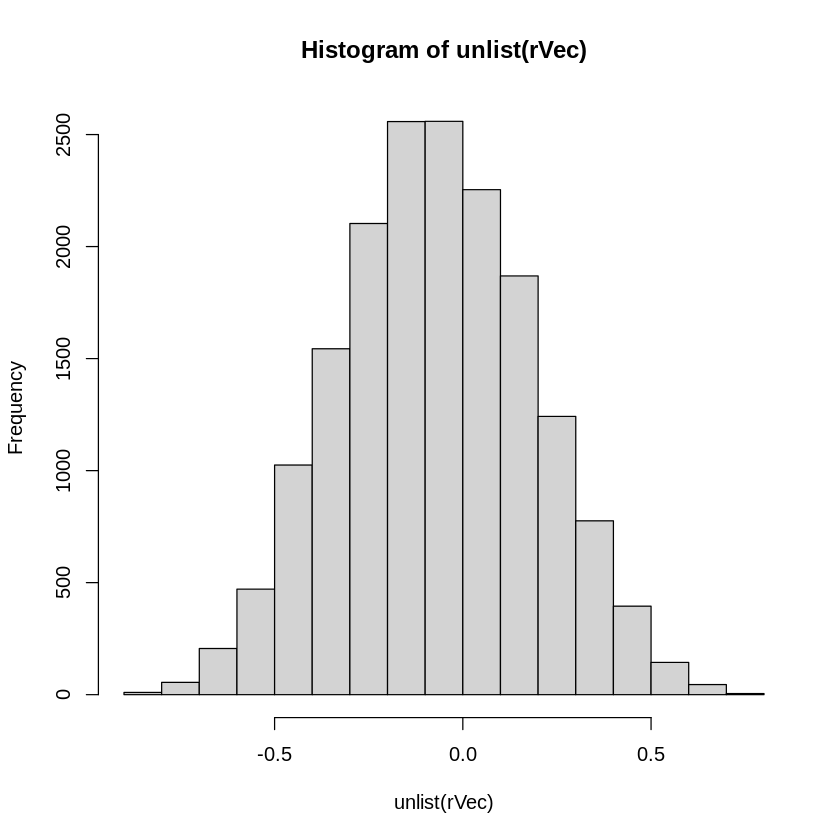

In [50]:
hist(unlist(rVec))

In [51]:
summary(unlist(rVec))

    Min.  1st Qu.   Median     Mean  3rd Qu.     Max. 
-0.87323 -0.24877 -0.07524 -0.07073  0.10669  0.78819 

In [ ]:
# set.seed(123)
# testData_subset2 = subset(testData_subset,OG %in% sample(OG_list_subset,1000))

# LSD::heatscatter(testData_subset2$zeroShotScore,testData_subset2$dn.ds,xlab = "avg. zero-shot scores",ylab = "dN/dS")
# abline(v = 2)

In [82]:
PMS = fread('/workdir/sh2246/p_phyloGWAS/output/combined_PMS_v2_20240909.txt')

In [83]:
colnames(PMS) = c("seqID","PMS","AAlength")

In [84]:
testData_merged = merge(testData_merged,PMS,by = 'seqID')

In [85]:
testData_merged$scaled.dn.ds = unlist(tapply(testData_merged$dn.ds,testData_merged$OG, function(x) (x-mean(x,na.rm =T))/sd(x,na.rm = T)))

In [86]:
cor(cbind(testData_merged$dn.ds,testData_merged$scaled.dn.ds,testData_merged$zeroShotScore,testData_merged$scaledScore),method = "spearman")

1.00000000,0.45165196,-0.26619041,-0.04528441
0.45165196,1.00000000,-0.02024905,-0.06480752
-0.26619041,-0.02024905,1.00000000,0.30884734
-0.04528441,-0.06480752,0.30884734,1.00000000


In [108]:
FS = fread('/workdir/sh2246/p_phyloGWAS/output/frameShiftMutation.txt')[,c(1,3)]

In [109]:
FS2 = fread('/workdir/sh2246/p_phyloGWAS/output/frameShiftMutation_additionalOGs.txt')[,c(1,3)]

In [110]:
FS = rbind(FS,FS2)

In [111]:
colnames(FS)[1] = "seqID"

In [115]:
# testData_merged = testData_merged[,-(368:370)]

In [116]:
testData_merged = merge(testData_merged,FS,by = 'seqID',all.x = T)

In [117]:
dim(testData_merged)
length(unique(testData_merged$OG))

[1] 16235636      368

In [418]:
plantCadZS = fread("/workdir/sh2246/p_phyloGWAS/output/plantCad_zeroShot_allOGs_240917.txt")

In [419]:
colnames(plantCadZS) = c("seqID","zeroShotScore_DNA","scaledScore_DNA")

In [422]:
plantCadZS$seqID = gsub('^OG.......:','',plantCadZS$seqID)

In [423]:
testData_merged = testData_merged[,1:370]

In [424]:
testData_merged = merge(testData_merged,plantCadZS,by = 'seqID',all.x = T)

In [425]:
dim(testData_merged)
length(unique(testData_merged$OG))

[1] 16235636      372

[1] 19625

In [394]:
gc()

,used,(Mb),gc trigger,(Mb),max used,(Mb)
Ncells,47267980,2524.4,74490060,3978.2,93112574,4972.8
Vcells,17273722636,131788.1,24493927798,186873.9,25503639656,194577.4


In [119]:
testData_merged$groups = as.character(cut(testData_merged$dn.ds,
                                          c(0,quantile(testData_merged$dn.ds,c(0.5,0.9,0.95,0.99,1))),
                                          labels = 1:5))
gc()
# testData_merged$groups[testData_merged$Frameshift==1] = "6"
testData_merged$groups[testData_merged$PMS==1] = "7"

,used,(Mb),gc trigger,(Mb),max used,(Mb)
Ncells,26937069,1438.6,74490060,3978.2,93112574,4972.8
Vcells,13119575997,100094.5,25514424790,194659.7,21248587301,162113.9


In [120]:
testData_merged$groups2 = as.character(cut(testData_merged$scaled.dn.ds,
                                          c(min(testData_merged$scaled.dn.ds)-.1,quantile(testData_merged$scaled.dn.ds,c(0.5,0.9,0.95,0.99,1))),
                                          labels = 1:5))
gc()
testData_merged$groups2[testData_merged$Frameshift==1] = "6"
testData_merged$groups2[testData_merged$PMS==1] = "7"

,used,(Mb),gc trigger,(Mb),max used,(Mb)
Ncells,26937120,1438.6,74490060,3978.2,93112574,4972.8
Vcells,13135814324,100218.4,25514424790,194659.7,24955892712,190398.4


In [121]:
write.table(testData_merged[,c(1,372)],"/workdir/sh2246/p_phyloGWAS/output/seqCategories.txt",quote = F,sep = "\t",row.names = F)

In [122]:
table(testData_merged$groups)
table(testData_merged$groups2)


      1       2       3       4       5       7 
7793111 6082024  753549  603872  151887  851193 


      1       2       3       4       5       6       7 
7707683 6073532  751727  602013  146548  102940  851193 

In [123]:
table(testData_merged$PMS,testData_merged$Frameshift)
fisher.test(table(testData_merged$PMS,testData_merged$Frameshift))

   
           0        1
  0 15281503   102940
  1   159715   691478


	Fisher's Exact Test for Count Data

data:  table(testData_merged$PMS, testData_merged$Frameshift)
p-value < 2.2e-16
alternative hypothesis: true odds ratio is not equal to 1
95 percent confidence interval:
 628.9443 658.5955
sample estimates:
odds ratio 
  645.9944 


In [48]:
library(ggplot2)
library(ggridges)
  

Warning message:
“The dot-dot notation (`..x..`) was deprecated in ggplot2 3.4.0.
ℹ Please use `after_stat(x)` instead.”
Picking joint bandwidth of 0.0581



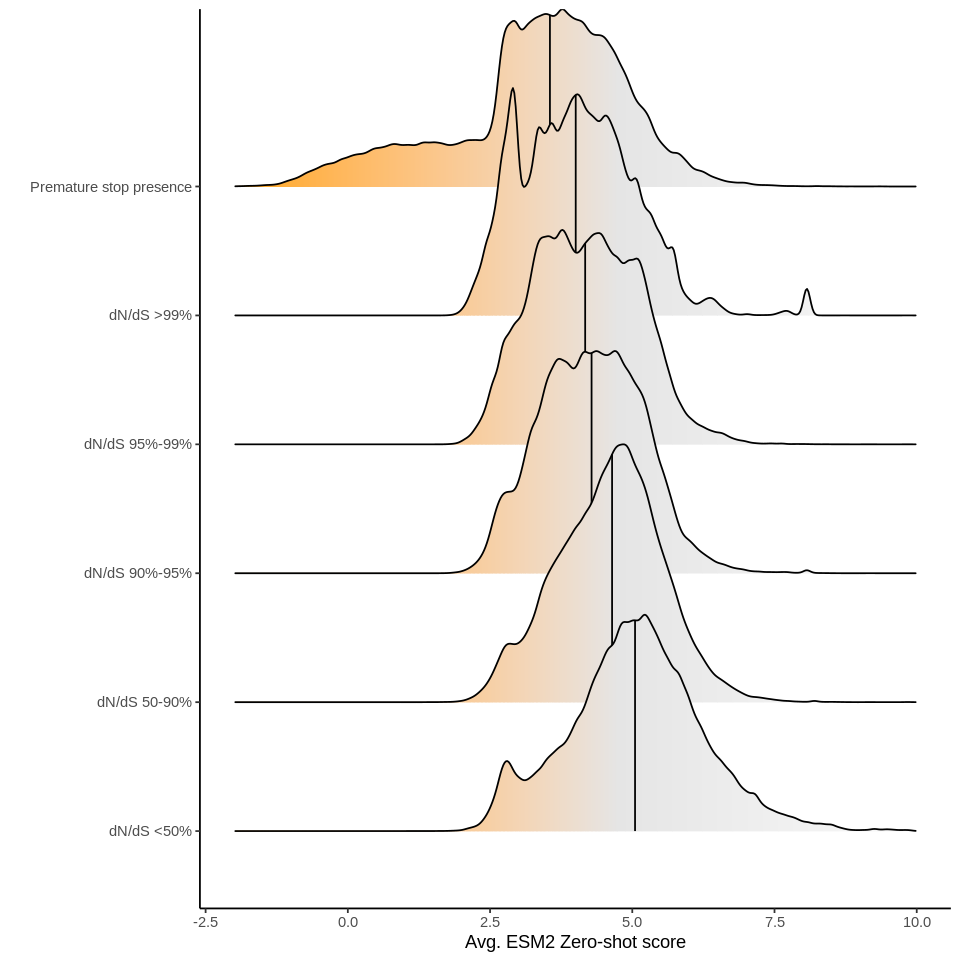

In [95]:
ggplot(testData_merged, aes(x = zeroShotScore, y = groups,fill = ..x..)) +
  geom_density_ridges_gradient(scale = 2, rel_min_height = 0,quantiles = 2,quantile_lines = T) + 
  scale_fill_gradient2(name = "Zero-shot scores", low = "orange", mid = "grey90", high = "white", 
                       midpoint = median(testData_merged$zeroShotScore)) +
  scale_y_discrete(labels=c("1" = "dN/dS <50%", "2" = "dN/dS 50-90%","3" = "dN/dS 90%-95%",
                            "4" = "dN/dS 95%-99%","5" = "dN/dS >99%",
                            "7" = "Premature stop presence"))+
  xlab("Avg. ESM2 Zero-shot score") +
  ylab("") +
  xlim(c(-2,10)) +
  theme_classic() +
  theme(
    legend.position = "none",
    panel.spacing = unit(0.1, "lines"),
    strip.text.x = element_text(size = 8)
  )

Picking joint bandwidth of 0.0428



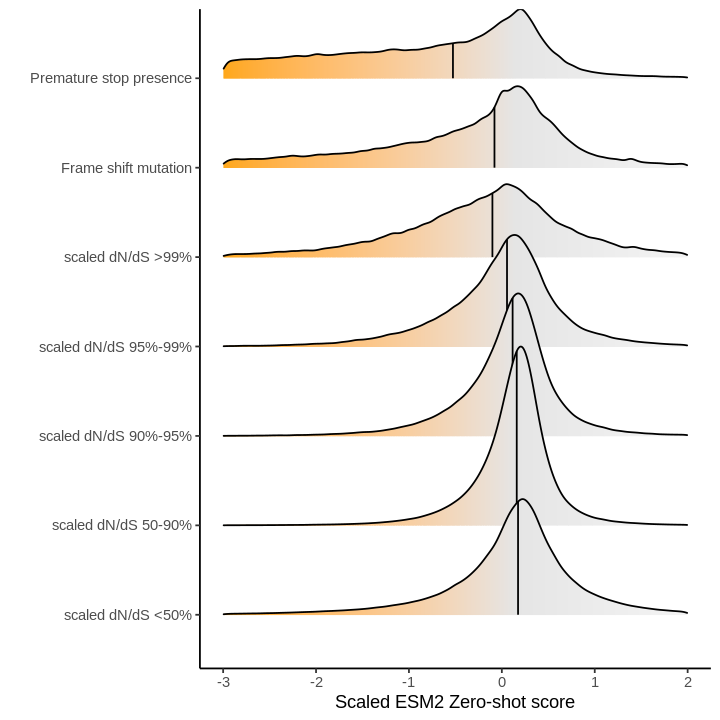

In [109]:
ggplot(testData_merged, aes(x = scaledScore, y = groups2,fill = ..x..)) +
  geom_density_ridges_gradient(scale = 2, rel_min_height = 0,quantiles = 2,quantile_lines = T) + 
  scale_fill_gradient2(name = "Zero-shot scores", low = "orange", mid = "grey90", high = "white", 
                       midpoint = median(testData_merged$scaledScore)) +
  scale_y_discrete(labels=c("1" = "scaled dN/dS <50%", "2" = "scaled dN/dS 50-90%","3" = "scaled dN/dS 90%-95%",
                            "4" = "scaled dN/dS 95%-99%","5" = "scaled dN/dS >99%","6" = "Frame shift mutation",
                            "7" = "Premature stop presence"))+
  xlab("Scaled ESM2 Zero-shot score") +
  ylab("") +
  xlim(c(-3,2)) +
  theme_classic() +
  theme(
    legend.position = "none",
    panel.spacing = unit(0.1, "lines"),
    strip.text.x = element_text(size = 8)
  )

Picking joint bandwidth of 0.0468



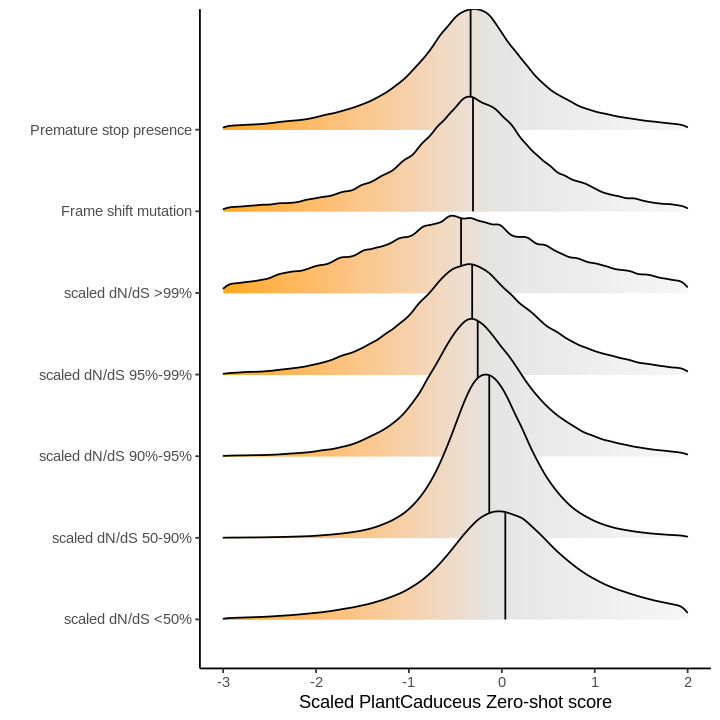

In [112]:
ggplot(testData_merged, aes(x = scaledScore_DNA, y = groups2,fill = ..x..)) +
  geom_density_ridges_gradient(scale = 2, rel_min_height = 0,quantiles = 2,quantile_lines = T) + 
  scale_fill_gradient2(name = "Zero-shot scores", low = "orange", mid = "grey90", high = "white", 
                       midpoint = median(testData_merged$scaledScore_DNA,na.rm = T)) +
  scale_y_discrete(labels=c("1" = "scaled dN/dS <50%", "2" = "scaled dN/dS 50-90%","3" = "scaled dN/dS 90%-95%",
                            "4" = "scaled dN/dS 95%-99%","5" = "scaled dN/dS >99%","6" = "Frame shift mutation",
                            "7" = "Premature stop presence"))+
  xlab("Scaled PlantCaduceus Zero-shot score") +
  ylab("") +
  xlim(c(-3,2)) +
  theme_classic() +
  theme(
    legend.position = "none",
    panel.spacing = unit(0.1, "lines"),
    strip.text.x = element_text(size = 8)
  )

In [111]:
median(testData_merged$scaledScore_DNA)

[1] NA

In [426]:
gc()

,used,(Mb),gc trigger,(Mb),max used,(Mb)
Ncells,26887264,1436.0,74490060,3978.2,93112574,4972.8
Vcells,12505479305,95409.3,29392793357,224249.3,25503639656,194577.4


In [932]:
testData_merged$pacbio = as.factor(grepl("pacbio",testData_merged$technology,ignore.case = T))

In [934]:
data.table::fwrite(testData_merged,"/workdir/sh2246/p_phyloGWAS/output/testData_merged.txt",sep = "\t",quote = F)

In [15]:
testData_merged = data.table::fread("/workdir/sh2246/p_phyloGWAS/output/testData_merged.txt",header = T,data.table = F,nThread = 20)

In [16]:
testData_merged$PMS = as.factor(testData_merged$PMS)
testData_merged$assemblyID = as.factor(testData_merged$assemblyID)
testData_merged$pacbio = as.factor(testData_merged$pacbio)

In [106]:
gc()

,used,(Mb),gc trigger,(Mb),max used,(Mb)
Ncells,22636652,1209,42165117,2251.9,42165117,2251.9
Vcells,6573386380,50151,11090889824,84616.8,11080626121,84538.5


In [108]:
testData_merged$groups2 = as.factor(testData_merged$groups2)

In [18]:
length(unique(testData_merged$assemblyID))

[1] 725

In [24]:
sum(is.na(metadata$technology))

[1] 33

In [33]:
dim(envDf)

[1] 759 326

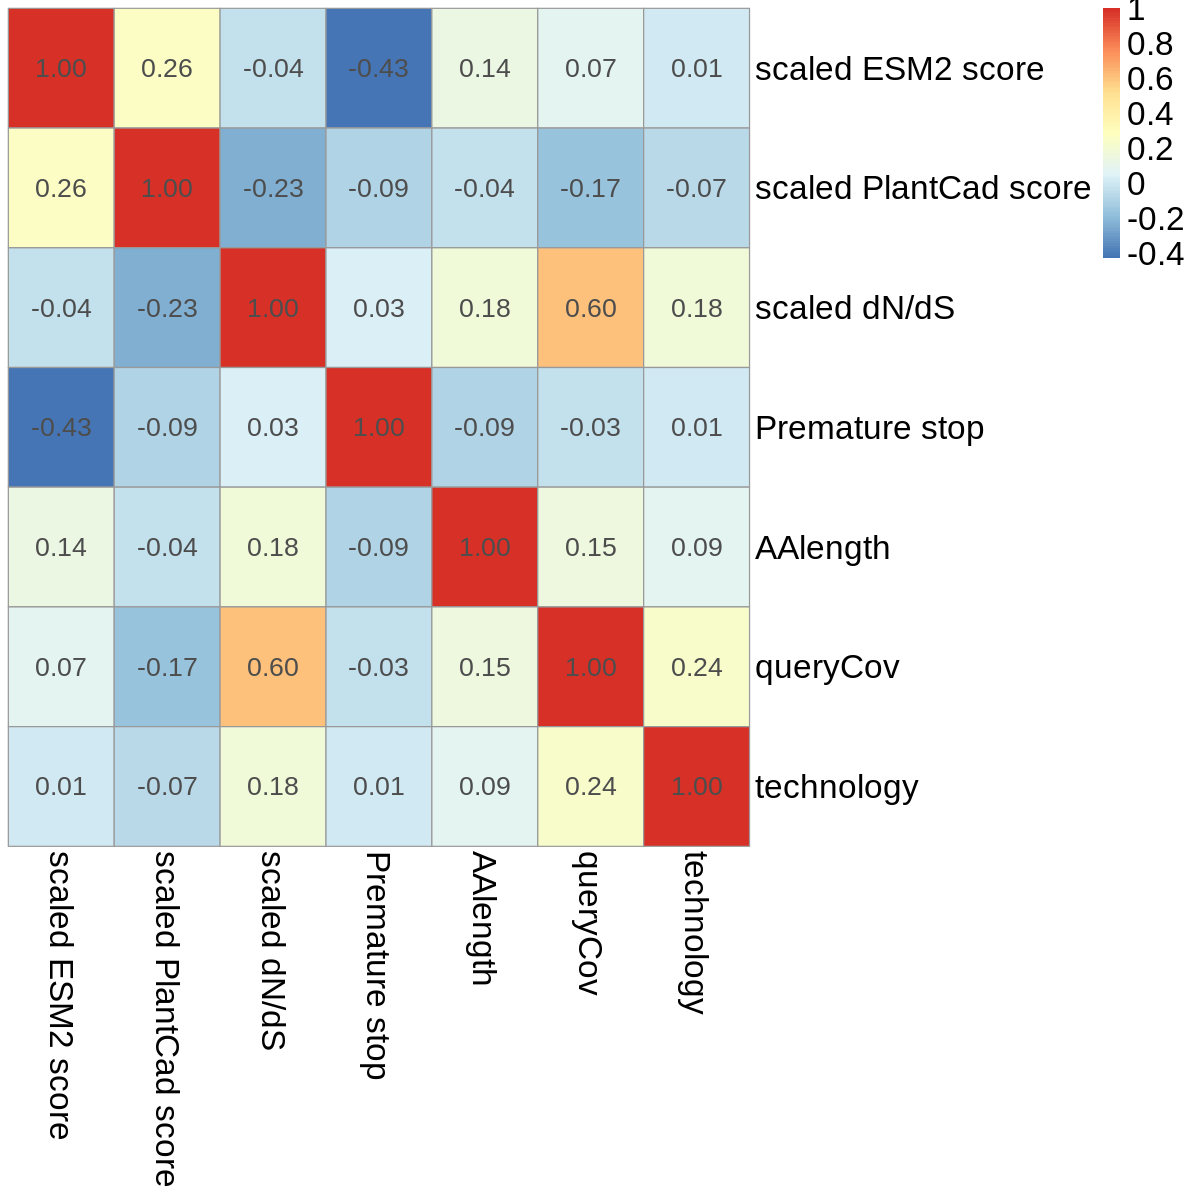

In [35]:
options(repr.plot.width=10, repr.plot.height=10)
rMat = cor(cbind(testData_merged$scaledScore,
                 testData_merged$scaledScore_DNA,
                 testData_merged$scaled.dn.ds,
                 testData_merged$PMS,
                 testData_merged$AAlength,
                 testData_merged$queryCov,
                 as.numeric(testData_merged$pacbio)),
           use = "complete")
colnames(rMat) = c("scaled ESM2 score","scaled PlantCad score","scaled dN/dS","Premature stop","AAlength","queryCov","technology")
rownames(rMat) = colnames(rMat)
pheatmap(rMat,cluster_row =F, cluster_col = F, display_number =T,fontsize = 20)

[1] 0.1363095

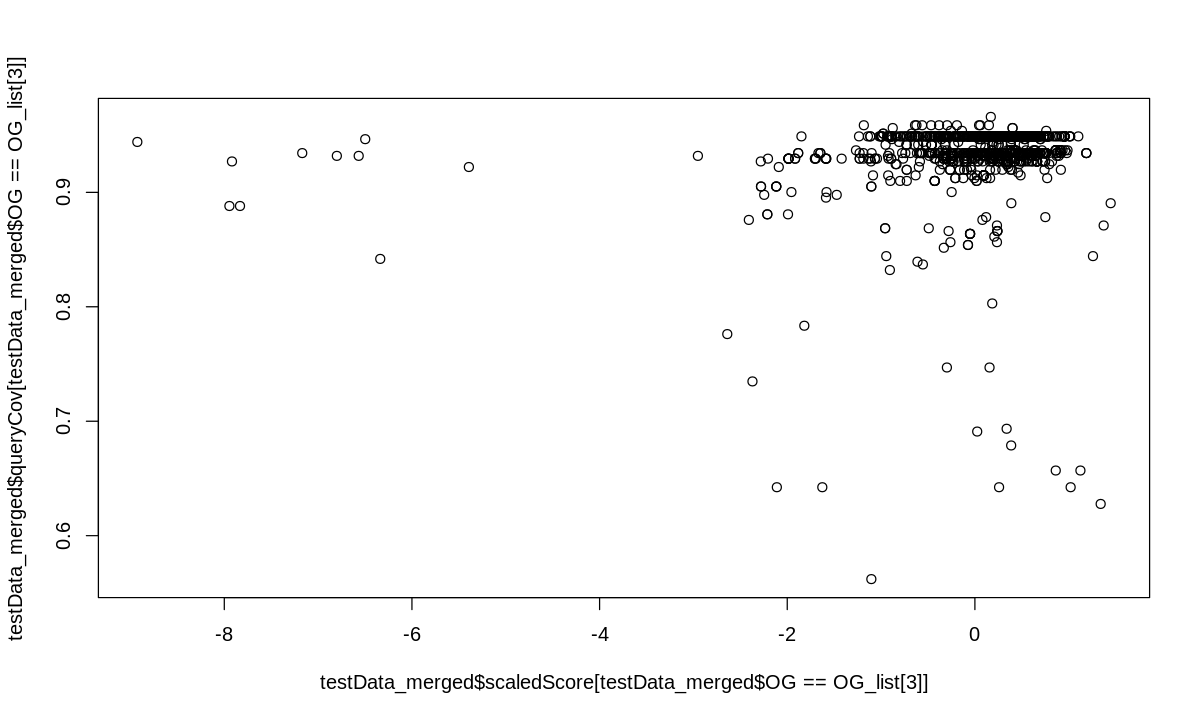

In [1184]:
cor(testData_merged$scaledScore[testData_merged$OG==OG_list[3]],
    testData_merged$queryCov[testData_merged$OG==OG_list[3]])
plot(testData_merged$scaledScore[testData_merged$OG==OG_list[3]],
    testData_merged$queryCov[testData_merged$OG==OG_list[3]])

In [1207]:
length(unique(testData_merged$OG))

[1] 19625

In [192]:
length(unique(testData_merged$assemblyID[testData_merged$lifeHistory=="annual"]))

[1] 243

In [195]:
table(metadata$lifeHistory[metadata$assemblyID%in%rownames(envDf)])


             annual annual or perennial           perennial 
                244                   6                 482 

In [203]:
tmp = read.table("/workdir/sh2246/p_phyloGWAS/data/annual_assemblies.txt",header = F)[,1]

In [204]:
length(tmp)

[1] 248

In [226]:
setdiff(tmp,metadata$assemblyID[metadata$lifeHistory%in%"annual"&!metadata$correctSpecies%in%c("Omit",NA)])

[1] "AN21TS37"

In [224]:
write.table(gsub("-|\\.","_",unique(metadata$assemblyID[metadata$lifeHistory%in%"annual"&!metadata$correctSpecies%in%c("Omit",NA)])),
            "/workdir/sh2246/p_phyloGWAS/data/annual_assemblies_20250203.txt",quote = F,row.names = F, col.names= F)

In [1206]:
gc()

,used,(Mb),gc trigger,(Mb),max used,(Mb)
Ncells,27481053,1467.7,74490060,3978.2,93112574,4972.8
Vcells,10587077337,80773.0,29392793357,224249.3,26354445001,201068.5


# Modeling

In [26]:
mappingFile = read.table("/workdir/sh2246/p_phyloGWAS/output/OGToPv_mapping_v2.txt")
mappingFile2 = read.table("/workdir/sh2246/p_phyloGWAS/output/OGToZm_mapping_v2.txt")

colnames(mappingFile) = c("PvID","OG")
colnames(mappingFile2) = c("ZmID","OG")

mappingFileMerged = merge(mappingFile,mappingFile2,by = "OG",all = T)

head(mappingFileMerged)

,OG,PvID,ZmID
,<chr>,<chr>,<chr>
1,OG0000062,Pavag10G051000.1,Zm00001eb181730_T001
2,OG0000098,Pavag07G174700.1,Zm00001eb313690_T001
3,OG0000106,Pavag06G183800.1,Zm00001eb429540_T001
4,OG0000124,Pavag09G171600.1,Zm00001eb428040_T001
5,OG0000150,Pavag03G414300.1,Zm00001eb267280_T001
6,OG0000152,Pavag03G317400.1,Zm00001eb352080_T002


In [27]:
ePCs = readRDS('/workdir/sh2246/p_phyloGWAS/output/ePC_20240827.rds')

# options(repr.plot.width=16, repr.plot.height=20)
# par(mfrow = c(5,4))
# for(i in 1:10){
#     par(mar = c(5,10,2,1))
#     topVar = which(rank(ePCs$variable.correlation[,i]^2,na.last = F) > 273)
#     barplot(sort(ePCs$variable.components[topVar,i]),main = paste0("envPC",i),horiz = T,
#             names.arg = rownames(ePCs$variable.correlation)[topVar],las =1,xlim = c(-1,1))
    
#     par(mar = c(5,5,2,1))
#     tmpCutoff = quantile(-log10(as.numeric(testRes_zs[,i+11])),.999,na.rm = T)
#     tmpCol = rep("grey",nrow(testRes_zs))
#     tmpCol[as.numeric(testRes_zs[,i+1])>0& -log10(as.numeric(testRes_zs[,i+11]))>tmpCutoff] = "red"
#     tmpCol[as.numeric(testRes_zs[,i+1])<0& -log10(as.numeric(testRes_zs[,i+11]))>tmpCutoff] = "blue"
#     qq(as.numeric(testRes_zs[,i+11]),main = paste0("envPC",i),ylim = c(0,15),
#        col = tmpCol[order(as.numeric(testRes_zs[,i+11]))])
#     print(sum(-log10(as.numeric(testRes_zs[,i+11]))>tmpCutoff,na.rm = T))
# }


In [28]:
asreml.options(maxit = 30,verbose = F)

In [319]:
test = fit_model_envPC1("OG0014615",data = testData_merged,phyloKMat)

ASReml Version 4.2 01/11/2024 11:26:39
          LogLik        Sigma2     DF     wall
 1     -238.4569     0.6079240    783   11:26:40
 2     -212.9488     0.5583259    783   11:26:40
 3     -169.3290     0.4748746    783   11:26:40
 4     -114.7713     0.3729797    783   11:26:40
 5     -67.58149     0.2805986    783   11:26:40
 6     -42.47378     0.2208648    783   11:26:40
 7     -31.17720     0.1835979    783   11:26:40
 8     -26.95223     0.1617836    783   11:26:40
 9     -25.63759     0.1499010    783   11:26:40
10     -25.28674     0.1438305    783   11:26:40
11     -25.20264     0.1408727    783   11:26:41
12     -25.18374     0.1394732    783   11:26:41
13     -25.17963     0.1388215    783   11:26:41
14     -25.17876     0.1385203    783   11:26:41
15     -25.17857     0.1383817    783   11:26:41
ASReml Version 4.2 01/11/2024 11:26:41
          LogLik        Sigma2     DF     wall
 1     -385.4353     0.9186730    783   11:26:41
ASReml Version 4.2 01/11/2024 11:26:46
     

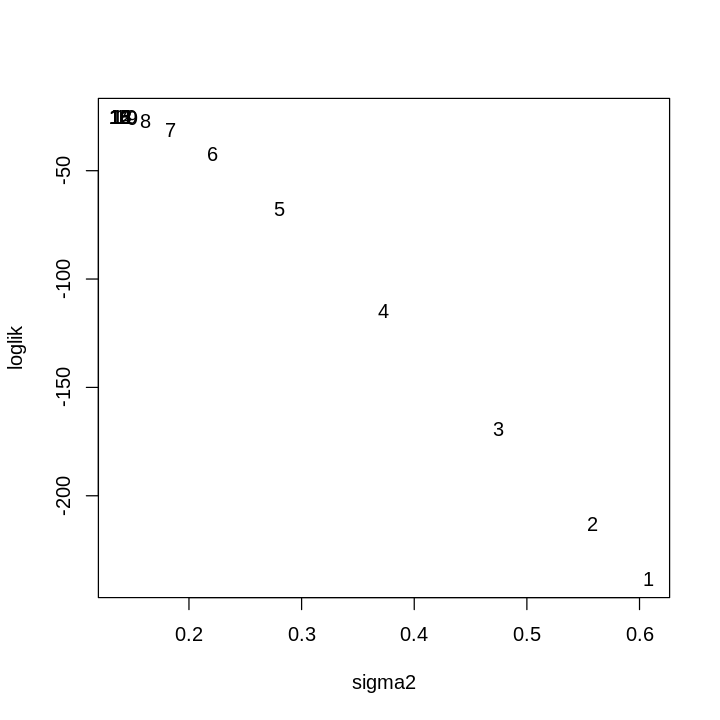

In [133]:
# options(repr.plot.width=6, repr.plot.height=6)
# plot(test$trace[2,],test$trace[1,],xlab = "sigma2",ylab = "loglik",type ='n')
# text(test$trace[2,],test$trace[1,],pch = 1:ncol(test$trace))

In [138]:
test
length(test)

OG               BIC_full            BIC_reduced 
           "OG0014615"     "61.1394526044613"     "70.4090085279512" 
                    LR                      p                geneVAE 
    "35.9627477945605" "2.94520943734067e-07"  "0.00401058961572023" 
              phyloVAE               totalVar      partialCoeff_dNdS 
   "0.762383268888519"      "1.0234895328714"   "-0.125040135954711" 
     partialCoeff_ESM2  partialCoeff_plantCad       partialCoeff_PMS 
  "-0.275219967989591"  "-0.0646548738189674"   "-0.483136932599587" 
         partialP_dNdS          partialP_ESM2      partialP_plantCad 
   "0.766339493713416" "3.04090650882216e-06"   "0.0819642145716822" 
          partialP_PMS 
"0.000853370900519401"

[1] 16

In [1603]:
asreml.options(maxit = 40,verbose = F)
testRes_envPC1 = mclapply(OG_list,function(x) try(fit_model_envPC1(x,data = testData_merged,phyloKMat),silent = T),mc.cores = 15)

testRes_envPC1 = t(simplify2array(testRes_envPC1[sapply(testRes_envPC1,length)==length(test)]))

# colnames(testRes_envPC1) = c("OG","LR","p","geneVAE","phyloVAE","totalVar",
#                    paste("partialCoeff",c("dNdS","ESM2","plantCad","PMS"),sep = "_"),
#                    paste("partialP",c("dNdS","ESM2","plantCad","PMS"),sep = "_"))
testRes_envPC1 = as.data.frame(testRes_envPC1)

testRes_envPC1 = merge(testRes_envPC1,mappingFileMerged,by = "OG",all.x = T)
write.table(testRes_envPC1,"/workdir/sh2246/p_phyloGWAS/output/ASREML_res_envPC1.txt",quote = F,sep = "\t",row.names = F)

In [41]:
testRes_envPC1 = read.table("/workdir/sh2246/p_phyloGWAS/output/ASREML_res_envPC1.txt",header =T)

In [ ]:
asreml.options(maxit = 40,verbose = F)
testRes_envPC2 = mclapply(OG_list,function(x) try(fit_model_envPC2(x,data = testData_merged,phyloKMat),silent = T),mc.cores = 20)

In [148]:
testRes_envPC2 = t(simplify2array(testRes_envPC2[sapply(testRes_envPC2,length)==length(test)]))

# colnames(testRes_envPC1) = c("OG","LR","p","geneVAE","phyloVAE","totalVar",
#                    paste("partialCoeff",c("dNdS","ESM2","plantCad","PMS"),sep = "_"),
#                    paste("partialP",c("dNdS","ESM2","plantCad","PMS"),sep = "_"))
testRes_envPC2 = as.data.frame(testRes_envPC2)

testRes_envPC2 = merge(testRes_envPC2,mappingFileMerged,by = "OG",all.x = T)
write.table(testRes_envPC2,"/workdir/sh2246/p_phyloGWAS/output/ASREML_res_envPC2.txt",quote = F,sep = "\t",row.names = F)

In [149]:
testRes_envPC2 = read.table("/workdir/sh2246/p_phyloGWAS/output/ASREML_res_envPC2.txt",header =T)

In [1607]:
head(testRes_envPC1)
dim(testRes_envPC1)

,OG,BIC_full,BIC_reduced,LR,p,geneVAE,phyloVAE,totalVar,partialCoeff_dNdS,partialCoeff_ESM2,partialCoeff_plantCad,partialCoeff_PMS,partialP_dNdS,partialP_ESM2,partialP_plantCad,partialP_PMS,PvID,ZmID
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
1,OG0000246,33.30317,15.64116,3.610472,0.46128072,-0.012318720,0.6434717,0.9839717,-0.002375294,-0.105888576,0.005867972,-0.17058679,0.98600988,0.08572491,0.5733314,0.2374009,Pavag05G225500.1,Zm00001eb127360_T001
2,OG0000272,-28.34167,-45.74616,9.961972,0.04107316,-0.001824986,0.7277979,1.1038084,0.047929613,0.043534182,0.002826433,0.07478297,0.36505777,0.01703899,0.7768902,0.6342108,Pavag05G135100.1,Zm00001eb169970_T004
3,OG0000306,41.54974,18.66428,4.234229,0.37523353,-0.003828358,0.7881800,1.0721099,-0.035452480,-0.009980682,-0.046558863,0.04033669,0.94500507,0.19597323,0.4869651,0.7186475,Pavag02G045500.2,Zm00001eb205990_T002
4,OG0000315,-23.20118,-40.02510,10.503897,0.03274335,-0.002058023,0.7370334,1.1164995,-0.070305404,0.040812480,0.003354488,0.18778864,0.00396748,0.17101665,0.9613564,0.2497359,Pavag01G255000.1,Zm00001eb026530_T001
5,OG0000317,33.72215,11.91813,5.392200,0.24936890,-0.002073998,0.7673949,1.0957517,0.014274711,-0.039472527,0.058715708,0.31644091,0.26837984,0.58709047,0.3792857,0.6039971,Pavag06G159000.1,Zm00001eb077610_T001
6,OG0000319,-16.73915,-38.56831,5.375972,0.25084869,0.001031449,0.7985087,1.0389424,-0.064279286,-0.035658210,0.019470587,-0.03137377,0.43775420,0.18453978,0.7683213,0.4857071,Pavag02G001400.1,Zm00001eb205000_T001


[1] 17287    18

In [150]:
head(testRes_envPC2)
dim(testRes_envPC2)

,OG,BIC_full,BIC_reduced,LR,p,geneVAE,phyloVAE,totalVar,partialCoeff_dNdS,partialCoeff_ESM2,partialCoeff_plantCad,partialCoeff_PMS,partialP_dNdS,partialP_ESM2,partialP_plantCad,partialP_PMS,PvID,ZmID
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
1,OG0000164,319.7436,295.9239,2.9930268,0.55899302,-0.0018011276,0.6964247,0.9741146,-0.046262339,0.016895026,-0.071021826,0.02983201,0.8449149,0.604690641,0.09412153,0.96465164,Pavag01G121200.1,Zm00001eb134090_T001
2,OG0000209,288.2906,275.7529,15.3339539,0.00405641,0.0096605863,0.7678405,0.9170821,0.004446292,-0.126854346,0.065749253,-0.18553926,0.6153379,0.004261109,0.01123050,0.09786484,Pavag07G222700.1,Zm00001eb039890_T001
3,OG0000229,434.6255,409.2864,2.6072037,0.62554756,-0.0057268279,0.8256734,1.0191647,0.032648543,-0.023085185,0.011135753,-0.09121184,0.1575938,0.711789923,0.48040540,0.35476551,Pavag06G240300.1,Zm00001eb431500_T001
4,OG0000246,179.0037,157.8822,0.1509095,0.99729252,-0.0131884741,0.5287264,0.9720083,-0.019062665,0.030723742,-0.051430461,0.05014185,0.5805919,0.646506625,0.75873711,0.83668487,Pavag05G225500.1,Zm00001eb127360_T001
5,OG0000272,469.3674,443.0604,1.0595339,0.90063829,-0.0005797972,0.6613132,0.9739500,0.002651624,-0.002458004,0.030735424,-0.04404165,0.4027092,0.452168572,0.26378981,0.99271264,Pavag05G135100.1,Zm00001eb169970_T004
6,OG0000277,368.2711,342.8857,1.9208482,0.75031417,-0.0010298736,0.7431491,1.0354098,0.030385502,0.004842432,0.007236604,0.08595108,0.2925378,0.741104765,0.52750991,0.57481999,PavagK045700.1,Zm00001eb168710_T001


[1] 18601    18

In [ ]:
# + PAV

In [39]:
test = fit_model_envPC5_v2("OG0021599",data = testData_merged,phyloKMat,envDf,TABASCO)

ASReml Version 4.2 02/12/2024 13:12:25
          LogLik        Sigma2     DF     wall
 1     -451.2977     0.8328407    991   13:12:26
 2     -430.4625     0.7820019    991   13:12:26
 3     -399.4167     0.7029149    991   13:12:26
 4     -364.6412     0.6076489    991   13:12:26
 5     -330.3809     0.5026701    991   13:12:26
 6     -309.6922     0.4242316    991   13:12:26
 7     -300.7140     0.3746067    991   13:12:26
 8     -297.8262     0.3468776    991   13:12:26
 9     -297.1051     0.3330059    991   13:12:27
10     -296.9554     0.3266577    991   13:12:27
11     -296.9276     0.3239125    991   13:12:27
12     -296.9227     0.3227599    991   13:12:27
13     -296.9218     0.3222824    991   13:12:27
ASReml Version 4.2 02/12/2024 13:12:27
          LogLik        Sigma2     DF     wall
 1     -507.1050     0.9658590    991   13:12:27
ASReml Version 4.2 02/12/2024 13:12:27
          LogLik        Sigma2     DF     wall
 1     -440.1910     0.8313343    996   13:12:28
 2     

In [40]:
test

OG                BIC_full             BIC_reduced 
            "OG0021599"       "614.51952937274"      "583.537033778928" 
                     LR                       p                 geneVAE 
     "3.55628080109864"     "0.614889263708214" "-0.000610476769615251" 
               phyloVAE                totalVar        partialCoeff_PAV 
    "0.660080212644498"     "0.974997547674202"     "0.215182102980484" 
      partialCoeff_dNdS       partialCoeff_ESM2   partialCoeff_plantCad 
  "-0.0197844246251631"   "-0.0188488541557738"    "0.0326814190123149" 
       partialCoeff_PMS            partialP_PAV           partialP_dNdS 
    "0.352879940142064"     "0.260624947579417"      "0.52235830826817" 
          partialP_ESM2       partialP_plantCad            partialP_PMS 
    "0.680500884318423"     "0.315535856969458"     "0.420387780720007"

In [44]:
asreml.options(maxit = 40,verbose = F)
testRes_envPC1_v2 = mclapply(OG_list,function(x) try(fit_model_envPC1_v2(x,data = testData_merged,phyloKMat,envDf,TABASCO),silent = T),mc.cores = 30)


In [324]:
asreml.options(maxit = 40,verbose = F)
testRes_envPC1_v2 = mclapply(OG_list,function(x) try(fit_model_envPC1_v2(x,data = testData_merged,phyloKMat,envDf,TABASCO),silent = T),mc.cores = 30)

testRes_envPC1_v2 = t(simplify2array(testRes_envPC1_v2[sapply(testRes_envPC1_v2,length)==length(test)]))

# colnames(testRes_envPC1) = c("OG","LR","p","geneVAE","phyloVAE","totalVar",
#                    paste("partialCoeff",c("dNdS","ESM2","plantCad","PMS"),sep = "_"),
#                    paste("partialP",c("dNdS","ESM2","plantCad","PMS"),sep = "_"))
testRes_envPC1_v2 = as.data.frame(testRes_envPC1_v2)

testRes_envPC1_v2 = merge(testRes_envPC1_v2,mappingFileMerged,by = "OG",all.x = T)
write.table(testRes_envPC1_v2,"/workdir/sh2246/p_phyloGWAS/output/ASREML_res_envPC1_v2.txt",quote = F,sep = "\t",row.names = F)

In [325]:
testRes_envPC1_v2 = read.table("/workdir/sh2246/p_phyloGWAS/output/ASREML_res_envPC1_v2.txt",header =T)

In [227]:
head(testRes_envPC1_v2)
dim(testRes_envPC1_v2)

,OG,BIC_full,BIC_reduced,LR,p,geneVAE,phyloVAE,totalVar,partialCoeff_dNdS,partialCoeff_ESM2,partialCoeff_plantCad,partialCoeff_PMS,partialCoeff_PAV,partialP_dNdS,partialP_ESM2,partialP_plantCad,partialP_PMS,partialP_PAV,PvID,ZmID
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
1,OG0000164,16.465255649393,-13.6475097851155,4.1748048782185,0.382865189913185,-0.00100462475823337,0.676064982114704,1.06567548070164,-0.020813900490702,0.0052592835446612,0.0267014936860881,-0.0157231347869892,-0.042264285924577,0.179615691611082,0.357401463187824,0.374799078716438,0.691520971795898,0.485145441009878,Pavag01G121200.1,Zm00001eb134090_T001
2,OG0000246,221.447509590417,192.398366128123,4.27290163945855,0.370330669434806,-0.00188856926229469,0.65317195987781,0.990129220404232,-0.0402498886777423,-0.0816632420710891,-0.0497014942002802,-0.20034870795377,0.0901412048642246,0.98628307086431,0.237979146049496,0.467302167029565,0.469487423380227,0.208141111385442,Pavag05G225500.1,Zm00001eb127360_T001
3,OG0000272,31.0072996489409,8.22422927185518,11.6239861411269,0.0203778179524595,-0.000765159946947907,0.703376827291608,1.09575941169621,0.0434340842336966,0.0431016637026434,0.00608544895810925,0.0409907028294956,0.175272866077896,0.696245254413237,0.0354759084294367,0.75882174194788,0.971893166888914,0.0495194139154934,Pavag05G135100.1,Zm00001eb169970_T004
4,OG0000306,75.3784664456762,48.0571090205488,6.8491862689418,0.144075932803466,0.000387269321189831,0.762950211515559,1.05521714979512,-0.00830614929383802,-0.0324639101810171,-0.0229904269542503,-0.0294602817813179,0.156130931757595,0.474117780325345,0.104261163007296,0.752845416027378,0.97084049457159,0.123159980769409,Pavag02G045500.2,Zm00001eb205990_T002
5,OG0000314,-21.7957644405525,-50.6630994676489,5.64637865869655,0.227159162207355,-0.000221658706940416,0.736760024581113,1.01430430104053,-0.0296278127562161,0.0146098047545049,-0.0261159455139311,0.0352301941402536,0.13938298983889,0.192209965386156,0.801372043253816,0.333717575368986,0.602907786849895,0.0774720538858964,PavagK222800.1,Zm00001eb164750_T001
6,OG0000315,27.7096766640939,7.60046682465084,14.2566093316195,0.00651953455940691,0.0016877737627712,0.711064463851734,1.10740331415314,-0.0854111545278985,0.0530356614364547,-0.0167485603291963,0.203762108587025,0.126579590536892,0.000955200086536712,0.240200538978467,0.546463529138186,0.262981322149251,0.161463255629039,Pavag01G255000.1,Zm00001eb026530_T001


[1] 17917    20

In [333]:
asreml.options(maxit = 40,verbose = F)
testRes_envPC2_v2 = mclapply(OG_list,function(x) try(fit_model_envPC2_v2(x,data = testData_merged,phyloKMat,envDf,TABASCO),silent = T),mc.cores = 20)

testRes_envPC2_v2 = t(simplify2array(testRes_envPC2_v2[sapply(testRes_envPC2_v2,length)==length(test)]))

# colnames(testRes_envPC2) = c("OG","LR","p","geneVAE","phyloVAE","totalVar",
#                    paste("partialCoeff",c("dNdS","ESM2","plantCad","PMS"),sep = "_"),
#                    paste("partialP",c("dNdS","ESM2","plantCad","PMS"),sep = "_"))
testRes_envPC2_v2 = as.data.frame(testRes_envPC2_v2)

testRes_envPC2_v2 = merge(testRes_envPC2_v2,mappingFileMerged,by = "OG",all.x = T)
write.table(testRes_envPC2_v2,"/workdir/sh2246/p_phyloGWAS/output/ASREML_res_envPC2_v2.txt",quote = F,sep = "\t",row.names = F)

testRes_envPC2_v2 = read.table("/workdir/sh2246/p_phyloGWAS/output/ASREML_res_envPC2_v2.txt",header =T)

In [357]:
asreml.options(maxit = 40,verbose = F)
testRes_envPC3_v2 = mclapply(OG_list,function(x) try(fit_model_envPC3_v2(x,data = testData_merged,phyloKMat,envDf,TABASCO),silent = T),mc.cores = 20)

testRes_envPC3_v2 = t(simplify2array(testRes_envPC3_v2[sapply(testRes_envPC3_v2,length)==length(test)]))

# colnames(testRes_envPC3) = c("OG","LR","p","geneVAE","phyloVAE","totalVar",
#                    paste("partialCoeff",c("dNdS","ESM2","plantCad","PMS"),sep = "_"),
#                    paste("partialP",c("dNdS","ESM2","plantCad","PMS"),sep = "_"))
testRes_envPC3_v2 = as.data.frame(testRes_envPC3_v2)

testRes_envPC3_v2 = merge(testRes_envPC3_v2,mappingFileMerged,by = "OG",all.x = T)
write.table(testRes_envPC3_v2,"/workdir/sh2246/p_phyloGWAS/output/ASREML_res_envPC3_v2.txt",quote = F,sep = "\t",row.names = F)

testRes_envPC3_v2 = read.table("/workdir/sh2246/p_phyloGWAS/output/ASREML_res_envPC3_v2.txt",header =T)

In [358]:
asreml.options(maxit = 40,verbose = F)
testRes_envPC4_v2 = mclapply(OG_list,function(x) try(fit_model_envPC4_v2(x,data = testData_merged,phyloKMat,envDf,TABASCO),silent = T),mc.cores = 20)

testRes_envPC4_v2 = t(simplify2array(testRes_envPC4_v2[sapply(testRes_envPC4_v2,length)==length(test)]))

# colnames(testRes_envPC4) = c("OG","LR","p","geneVAE","phyloVAE","totalVar",
#                    paste("partialCoeff",c("dNdS","ESM2","plantCad","PMS"),sep = "_"),
#                    paste("partialP",c("dNdS","ESM2","plantCad","PMS"),sep = "_"))
testRes_envPC4_v2 = as.data.frame(testRes_envPC4_v2)

testRes_envPC4_v2 = merge(testRes_envPC4_v2,mappingFileMerged,by = "OG",all.x = T)
write.table(testRes_envPC4_v2,"/workdir/sh2246/p_phyloGWAS/output/ASREML_res_envPC4_v2.txt",quote = F,sep = "\t",row.names = F)

testRes_envPC4_v2 = read.table("/workdir/sh2246/p_phyloGWAS/output/ASREML_res_envPC4_v2.txt",header =T)

In [359]:
asreml.options(maxit = 40,verbose = F)
testRes_envPC5_v2 = mclapply(OG_list,function(x) try(fit_model_envPC5_v2(x,data = testData_merged,phyloKMat,envDf,TABASCO),silent = T),mc.cores = 20)

testRes_envPC5_v2 = t(simplify2array(testRes_envPC5_v2[sapply(testRes_envPC5_v2,length)==length(test)]))

# colnames(testRes_envPC5) = c("OG","LR","p","geneVAE","phyloVAE","totalVar",
#                    paste("partialCoeff",c("dNdS","ESM2","plantCad","PMS"),sep = "_"),
#                    paste("partialP",c("dNdS","ESM2","plantCad","PMS"),sep = "_"))
testRes_envPC5_v2 = as.data.frame(testRes_envPC5_v2)

testRes_envPC5_v2 = merge(testRes_envPC5_v2,mappingFileMerged,by = "OG",all.x = T)
write.table(testRes_envPC5_v2,"/workdir/sh2246/p_phyloGWAS/output/ASREML_res_envPC5_v2.txt",quote = F,sep = "\t",row.names = F)

testRes_envPC5_v2 = read.table("/workdir/sh2246/p_phyloGWAS/output/ASREML_res_envPC5_v2.txt",header =T)

In [376]:
asreml.options(maxit = 40,verbose = F)
testRes_envPC6_v2 = mclapply(OG_list,function(x) try(fit_model_envPC6_v2(x,data = testData_merged,phyloKMat,envDf,TABASCO),silent = T),mc.cores = 20)

testRes_envPC6_v2 = t(simplify2array(testRes_envPC6_v2[sapply(testRes_envPC6_v2,length)==length(test)]))

# colnames(testRes_envPC6) = c("OG","LR","p","geneVAE","phyloVAE","totalVar",
#                    paste("partialCoeff",c("dNdS","ESM2","plantCad","PMS"),sep = "_"),
#                    paste("partialP",c("dNdS","ESM2","plantCad","PMS"),sep = "_"))
testRes_envPC6_v2 = as.data.frame(testRes_envPC6_v2)

testRes_envPC6_v2 = merge(testRes_envPC6_v2,mappingFileMerged,by = "OG",all.x = T)
write.table(testRes_envPC6_v2,"/workdir/sh2246/p_phyloGWAS/output/ASREML_res_envPC6_v2.txt",quote = F,sep = "\t",row.names = F)

testRes_envPC6_v2 = read.table("/workdir/sh2246/p_phyloGWAS/output/ASREML_res_envPC6_v2.txt",header =T)

In [377]:
asreml.options(maxit = 40,verbose = F)
testRes_envPC7_v2 = mclapply(OG_list,function(x) try(fit_model_envPC7_v2(x,data = testData_merged,phyloKMat,envDf,TABASCO),silent = T),mc.cores = 20)

testRes_envPC7_v2 = t(simplify2array(testRes_envPC7_v2[sapply(testRes_envPC7_v2,length)==length(test)]))

# colnames(testRes_envPC7) = c("OG","LR","p","geneVAE","phyloVAE","totalVar",
#                    paste("partialCoeff",c("dNdS","ESM2","plantCad","PMS"),sep = "_"),
#                    paste("partialP",c("dNdS","ESM2","plantCad","PMS"),sep = "_"))
testRes_envPC7_v2 = as.data.frame(testRes_envPC7_v2)

testRes_envPC7_v2 = merge(testRes_envPC7_v2,mappingFileMerged,by = "OG",all.x = T)
write.table(testRes_envPC7_v2,"/workdir/sh2246/p_phyloGWAS/output/ASREML_res_envPC7_v2.txt",quote = F,sep = "\t",row.names = F)

testRes_envPC7_v2 = read.table("/workdir/sh2246/p_phyloGWAS/output/ASREML_res_envPC7_v2.txt",header =T)

In [378]:
asreml.options(maxit = 40,verbose = F)
testRes_envPC8_v2 = mclapply(OG_list,function(x) try(fit_model_envPC8_v2(x,data = testData_merged,phyloKMat,envDf,TABASCO),silent = T),mc.cores = 20)

testRes_envPC8_v2 = t(simplify2array(testRes_envPC8_v2[sapply(testRes_envPC8_v2,length)==length(test)]))

# colnames(testRes_envPC8) = c("OG","LR","p","geneVAE","phyloVAE","totalVar",
#                    paste("partialCoeff",c("dNdS","ESM2","plantCad","PMS"),sep = "_"),
#                    paste("partialP",c("dNdS","ESM2","plantCad","PMS"),sep = "_"))
testRes_envPC8_v2 = as.data.frame(testRes_envPC8_v2)

testRes_envPC8_v2 = merge(testRes_envPC8_v2,mappingFileMerged,by = "OG",all.x = T)
write.table(testRes_envPC8_v2,"/workdir/sh2246/p_phyloGWAS/output/ASREML_res_envPC8_v2.txt",quote = F,sep = "\t",row.names = F)

testRes_envPC8_v2 = read.table("/workdir/sh2246/p_phyloGWAS/output/ASREML_res_envPC8_v2.txt",header =T)

In [382]:
asreml.options(maxit = 40,verbose = F)
testRes_envPC9_v2 = mclapply(OG_list,function(x) try(fit_model_envPC9_v2(x,data = testData_merged,phyloKMat,envDf,TABASCO),silent = T),mc.cores = 20)

testRes_envPC9_v2 = t(simplify2array(testRes_envPC9_v2[sapply(testRes_envPC9_v2,length)==length(test)]))

# colnames(testRes_envPC9) = c("OG","LR","p","geneVAE","phyloVAE","totalVar",
#                    paste("partialCoeff",c("dNdS","ESM2","plantCad","PMS"),sep = "_"),
#                    paste("partialP",c("dNdS","ESM2","plantCad","PMS"),sep = "_"))
testRes_envPC9_v2 = as.data.frame(testRes_envPC9_v2)

testRes_envPC9_v2 = merge(testRes_envPC9_v2,mappingFileMerged,by = "OG",all.x = T)
write.table(testRes_envPC9_v2,"/workdir/sh2246/p_phyloGWAS/output/ASREML_res_envPC9_v2.txt",quote = F,sep = "\t",row.names = F)

testRes_envPC9_v2 = read.table("/workdir/sh2246/p_phyloGWAS/output/ASREML_res_envPC9_v2.txt",header =T)

In [383]:
asreml.options(maxit = 40,verbose = F)
testRes_envPC10_v2 = mclapply(OG_list,function(x) try(fit_model_envPC10_v2(x,data = testData_merged,phyloKMat,envDf,TABASCO),silent = T),mc.cores = 20)

testRes_envPC10_v2 = t(simplify2array(testRes_envPC10_v2[sapply(testRes_envPC10_v2,length)==length(test)]))

# colnames(testRes_envPC10) = c("OG","LR","p","geneVAE","phyloVAE","totalVar",
#                    paste("partialCoeff",c("dNdS","ESM2","plantCad","PMS"),sep = "_"),
#                    paste("partialP",c("dNdS","ESM2","plantCad","PMS"),sep = "_"))
testRes_envPC10_v2 = as.data.frame(testRes_envPC10_v2)

testRes_envPC10_v2 = merge(testRes_envPC10_v2,mappingFileMerged,by = "OG",all.x = T)
write.table(testRes_envPC10_v2,"/workdir/sh2246/p_phyloGWAS/output/ASREML_res_envPC10_v2.txt",quote = F,sep = "\t",row.names = F)

testRes_envPC10_v2 = read.table("/workdir/sh2246/p_phyloGWAS/output/ASREML_res_envPC10_v2.txt",header =T)

In [48]:
sum(envDf$bio01_Annual_Mean_Temperature_quan50<15)
sum(envDf$bio12_Annual_Precipitation_quan50<500)

[1] 152

[1] 64

In [51]:
write.table(rownames(envDf)[envDf$bio01_Annual_Mean_Temperature_quan50<15],
            "/workdir/sh2246/p_phyloGWAS/output/coldAssembly.txt",quote = F,row.names = F,col.names = F)
write.table(rownames(envDf)[envDf$bio12_Annual_Precipitation_quan50<500],
            "/workdir/sh2246/p_phyloGWAS/output/aridAssembly.txt",quote = F,row.names = F,col.names = F)


In [96]:
avgOmegaPerOG = tapply(testData_merged$dn.ds,testData_merged$OG,mean,na.rm =T)
varOmegaPerOG = tapply(testData_merged$dn.ds,testData_merged$OG,function(x) sd(x,na.rm =T)/mean(x,na.rm =T))

In [71]:
PMScountPerOG = tapply(testData_merged$PMS,testData_merged$OG,function(x) sum(as.numeric(x)-1,na.rm =T))
FScountPerOG = tapply(testData_merged$Frameshift,testData_merged$OG,function(x) sum(as.numeric(x),na.rm =T))

In [97]:
summary(avgOmegaPerOG)
quantile(avgOmegaPerOG,c(0.9,0.99,.999))
summary(varOmegaPerOG)
quantile(varOmegaPerOG,c(0.9,0.99,.999))

    Min.  1st Qu.   Median     Mean  3rd Qu.     Max. 
0.004103 0.112817 0.165268 0.190737 0.238564 3.757749 

90%       99%     99.9% 
0.3301158 0.5745407 1.1867928

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
 0.1040  0.2289  0.2775  0.3024  0.3450  3.7989 

90%       99%     99.9% 
0.4251507 0.7641970 1.2628414

In [72]:
summary(PMScountPerOG)
summary(FScountPerOG)

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
   0.00   12.00   27.00   43.37   49.00 1859.00 

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
   0.00   13.00   26.00   40.48   46.00 1862.00 

In [91]:
summary(as.numeric(table(testData_merged$OG)))

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
   82.0   793.0   821.0   827.3   856.0  9826.0 

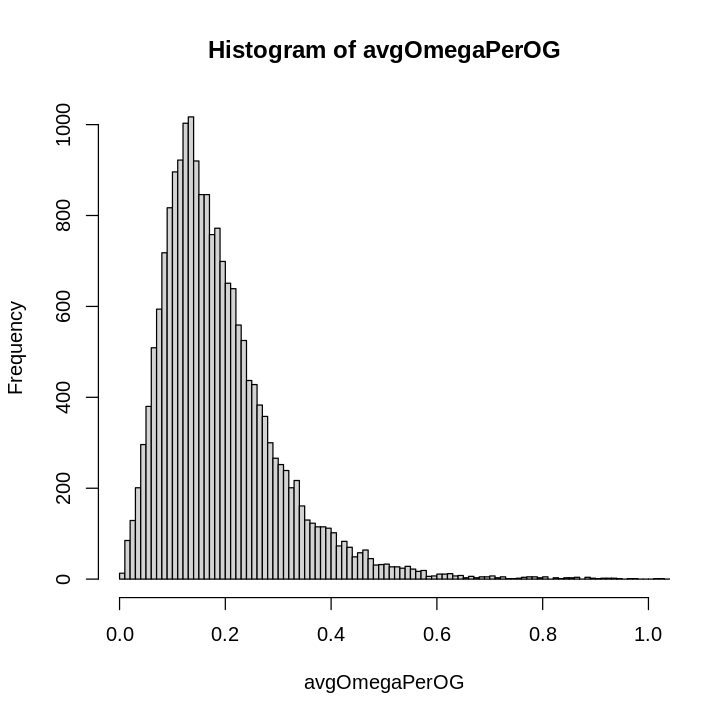

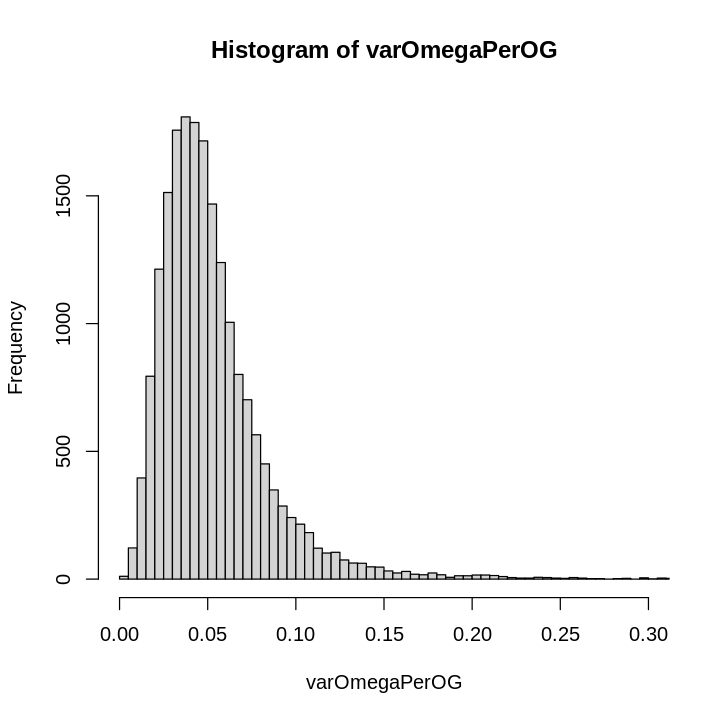

In [81]:
hist(avgOmegaPerOG,xlim = c(0,1),breaks = seq(0,4,0.01))
hist(varOmegaPerOG,xlim = c(0,0.3),breaks = seq(0,3,0.005))

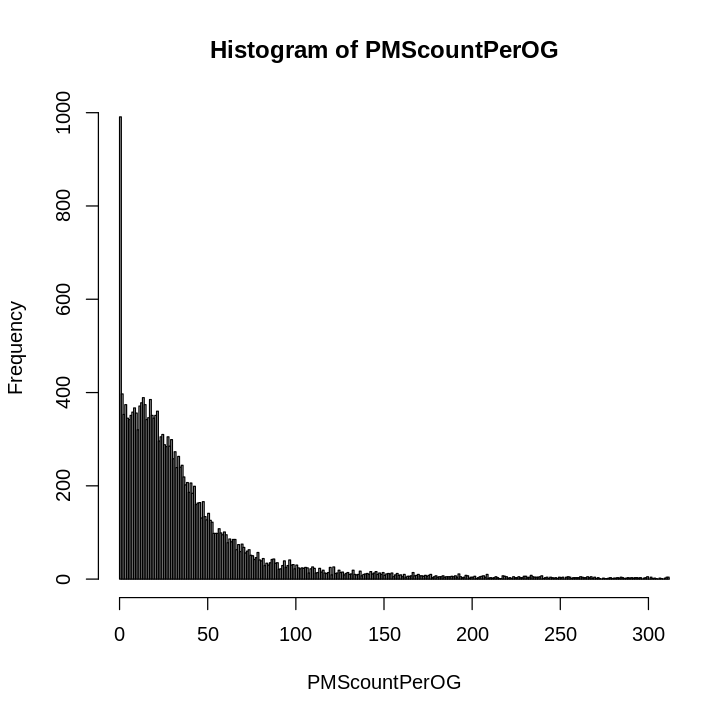

In [86]:
hist(PMScountPerOG,breaks = seq(0,2000,1),xlim = c(0,300))

In [335]:
head(testRes_envPC2_v2)

,OG,BIC_full,BIC_reduced,LR,p,geneVAE,phyloVAE,totalVar,partialCoeff_PAV,partialCoeff_dNdS,partialCoeff_ESM2,partialCoeff_plantCad,partialCoeff_PMS,partialP_PAV,partialP_dNdS,partialP_ESM2,partialP_plantCad,partialP_PMS,PvID,ZmID
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
1,OG0000164,431.1455,401.5127,4.654767,4.594468e-01,-0.001547397,0.6497034,0.9701048,0.2525949,-0.03078735,0.02574734,-0.069404948,0.02967790,0.03625812,0.95133542,5.484260e-01,0.10771071,0.82993652,Pavag01G121200.1,Zm00001eb134090_T001
2,OG0000185,547.1800,517.5336,5.049819,4.098306e-01,-0.001511870,0.7243491,1.0196197,0.5336026,0.05905503,0.01797935,0.079633699,0.01728614,0.78123726,0.32171332,7.435711e-01,0.10530743,0.95678253,Pavag03G228400.2,NA
3,OG0000190,367.3939,341.5065,9.397698,9.421465e-02,-0.006481192,0.8002598,0.9651592,-0.4455689,-0.01506688,-0.09749446,0.028475098,-0.09270523,0.27900968,0.44944559,6.056711e-03,0.74767166,0.48501192,Pavag02G078700.16,Zm00001eb062170_T001
4,OG0000202,381.3115,374.7751,28.586866,2.794115e-05,0.009881683,0.8252294,0.9755462,0.6496073,0.04893451,0.06669703,-0.027064408,-0.13155772,0.10377890,0.08152591,7.274048e-06,0.18807933,0.27724928,PavagK106900.1,Zm00001eb373050_T001
5,OG0000209,306.2264,286.1971,14.981464,1.044183e-02,0.007513352,0.7651046,0.9136767,-0.1222896,0.01864199,-0.12682874,0.058413493,-0.19663659,0.62429462,0.79756615,3.180135e-03,0.05965901,0.08906792,Pavag07G222700.1,Zm00001eb039890_T001
6,OG0000229,457.5338,425.8468,3.418392,6.357703e-01,-0.004262208,0.8053764,1.0115666,0.7986460,0.03913188,-0.02292889,0.005879769,-0.08822853,0.29319694,0.32993843,4.892773e-01,0.98201405,0.36012401,Pavag06G240300.1,Zm00001eb431500_T001


In [52]:
options(repr.plot.width=6, repr.plot.height=6)
qq(testRes_envPC1_v2$p)

ERROR: Error in qq(testRes_envPC1_v2$p): Input must be numeric.


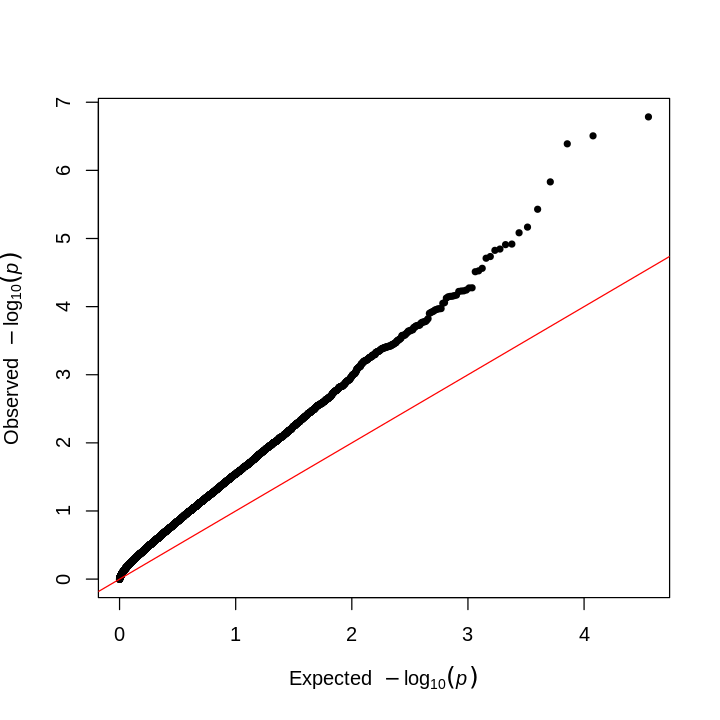

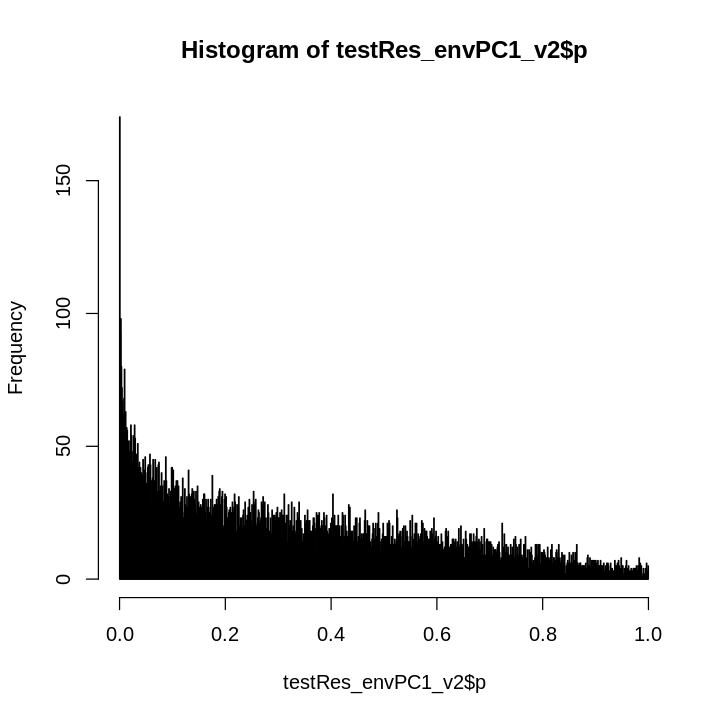

In [238]:
options(repr.plot.width=6, repr.plot.height=6)
qq(testRes_envPC1_v2$p)
hist(testRes_envPC1_v2$p,breaks = seq(0,1,0.001))

In [138]:
# quick check on adaptive ranges of PanAnd genomes
envDf_panand = envDf[grep("PanAnd|Sorghum_bicolor|Zm-B73",envDf$assemblyID),]

bio01_range = envDf_panand$bio01_Annual_Mean_Temperature_quan90-envDf_panand$bio01_Annual_Mean_Temperature_quan10

names(bio01_range) = envDf_panand$assemblyID

ploidycolors=c( '#FFC857', '#A997DF', '#E5323B', '#2E4052', '#97cddf')
ploidy = factor(c(4,10,6,10,10,10,4,10,2,4,10,10,2,2,2,10,10,4,2,2,2,6,4,4,2,4,6,4,6,2,8,10,4,4,10,10,10,10,10,2,2),
               levels = c(2,4,6,8,10))
mycol = ploidycolors[ploidy]
mycol

options(repr.plot.width=12, repr.plot.height=8)
par(mar= c(20,5,1,1))
barplot(sort(bio01_range),las=2,ylab = "Temperature adaptive range (90%-10%)",col = mycol)

options(repr.plot.width=6, repr.plot.height=6)
boxplot(sort(bio01_range)~ploidy,border = ploidycolors,col = NA,ylab = "Temperature adaptive range (90%-10%)",
        names=c('Diploid', 'Tetraploid', 'Hexaploid', 'Octaploid', 'Paleotetraploid'))

plot(as.numeric(ploidy),sort(bio01_range), pch = 19,col = mycol,ylab = "Temperature adaptive range (90%-10%)")

anova(lm(sort(bio01_range)~ploidy))

LSD_res = agricolae::LSD.test(sort(bio01_range),ploidy,36,12.39,p.adj = "BH")
LSD_res

In [134]:
sum(testRes_envPC1$p < 5e-3)
sum(p.adjust(testRes_envPC1$p,"BH")< 0.05)

[1] 549

[1] 93

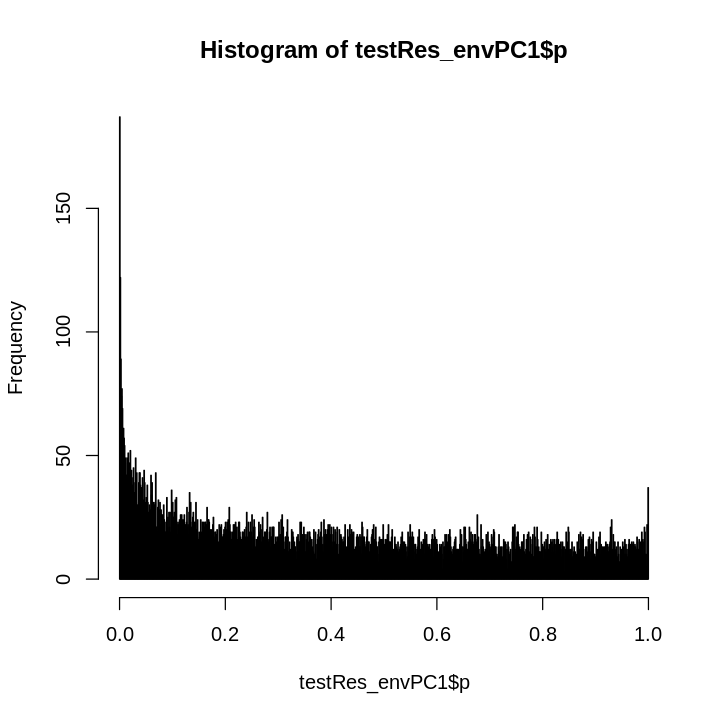

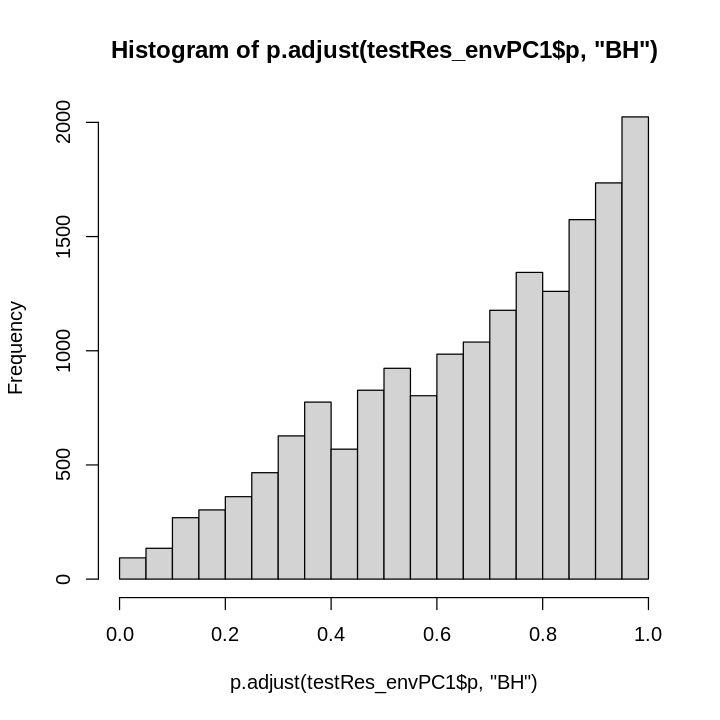

In [135]:
hist(testRes_envPC1$p,breaks = seq(0,1,0.001))
hist(p.adjust(testRes_envPC1$p,"BH"))

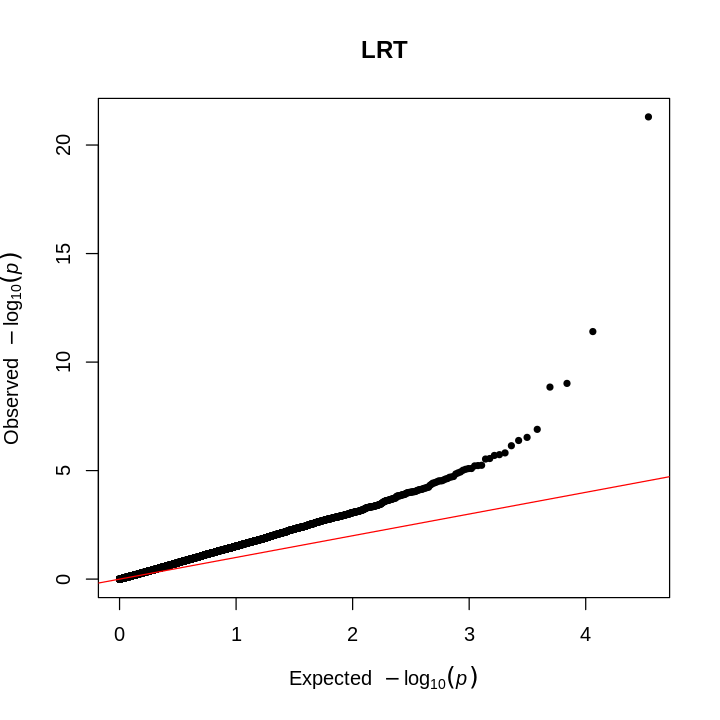

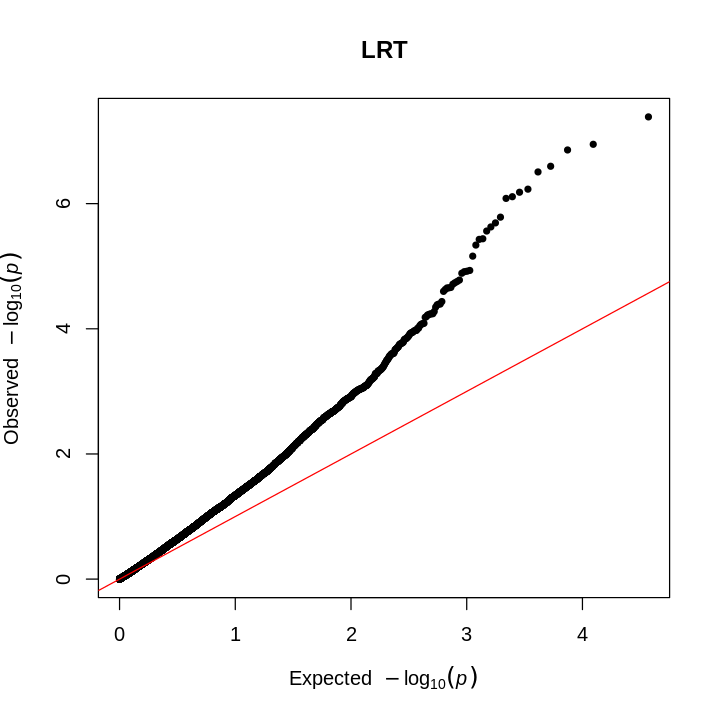

In [151]:
options(repr.plot.width=6, repr.plot.height=6)
qq(testRes_envPC1$p,main = "LRT")
qq(testRes_envPC2$p,main = "LRT")


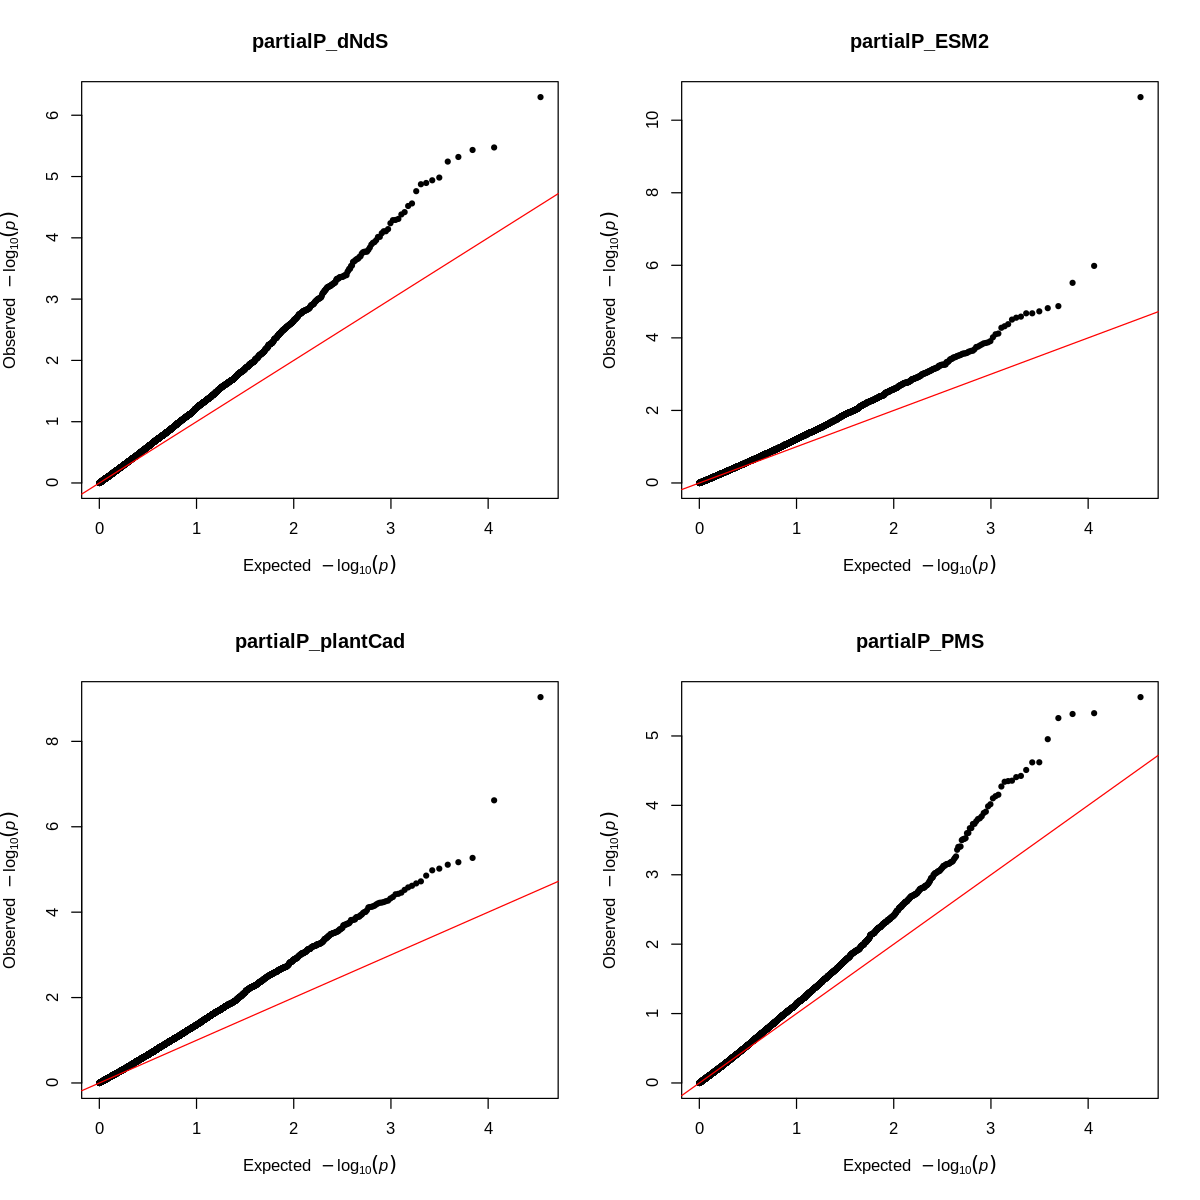

In [1611]:
options(repr.plot.width=10, repr.plot.height=10)
par(mfrow = c(2,2))
for(i in 1:4){
    qq(testRes_envPC1[,12+i],main = colnames(testRes_envPC1)[12+i])
}

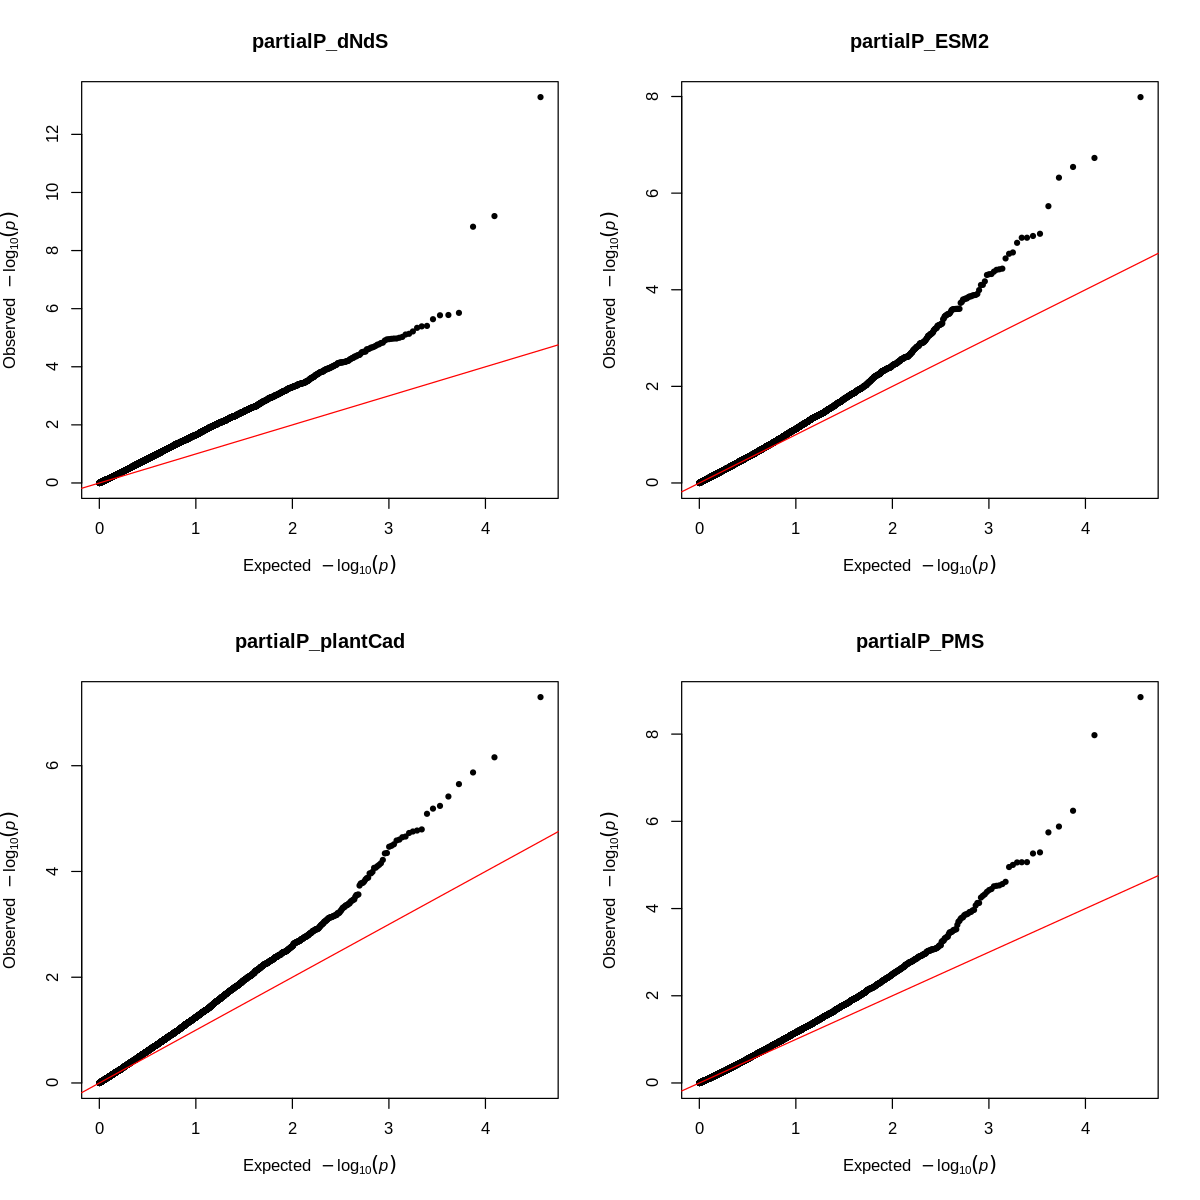

In [152]:
options(repr.plot.width=10, repr.plot.height=10)
par(mfrow = c(2,2))
for(i in 1:4){
    qq(testRes_envPC2[,12+i],main = colnames(testRes_envPC2)[12+i])
}

In [1471]:
testRes_envPC1[p.adjust(testRes_envPC1$p,"BH")< 0.05,]

,OG,LR,p,geneVAE,phyloVAE,totalVar,partialCoeff_dNdS,partialCoeff_ESM2,partialCoeff_plantCad,partialCoeff_PMS,partialP_dNdS,partialP_ESM2,partialP_plantCad,partialP_PMS,PvID,ZmID
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
73,OG0000514,104.75452,9.554331e-22,2.206031e-07,0.7259253,1.3919132,3.560061e-07,-2.245628e-06,1.078676e-06,2.524060e-01,9.961138e-01,9.846715e-01,9.922083e-01,1.436176e-02,PavagK110400.1,Zm00001eb349030_T001
82,OG0000533,187.41526,1.904052e-39,2.314379e-07,0.7995636,0.9952945,3.442460e-07,3.185236e-07,3.049773e-07,-1.111693e-07,9.965360e-01,9.944593e-01,9.969427e-01,9.997285e-01,Pavag08G162600.1,Zm00001eb032600_T002
94,OG0000563,19.97967,5.040355e-04,3.070817e-03,0.7287556,1.3054950,-3.492634e-02,-3.463343e-02,5.693255e-02,-6.784157e-01,2.528424e-01,1.107117e-01,1.553043e-01,3.170174e-04,NA,NA
116,OG0000619,26.36402,2.672169e-05,6.754371e-03,0.8199264,1.0808578,-8.317649e-02,-6.188743e-02,8.752240e-02,-1.027419e-01,3.687716e-06,5.378608e-01,1.963857e-04,2.124563e-01,Pavag08G072800.1,Zm00001eb132880_T002
213,OG0000843,23.30656,1.099632e-04,3.973981e-03,0.8408709,1.0810659,-4.101882e-03,-5.227828e-02,7.538575e-02,1.488499e-02,4.547797e-02,3.369313e-02,1.479300e-04,8.079185e-01,Pavag03G311200.1,Zm00001eb150340_T003
245,OG0000894,738.15761,1.902851e-158,4.359238e-05,0.8933077,1.0525296,-1.302150e-06,-1.245734e-06,2.718824e-06,-2.517516e-05,9.678675e-01,9.884438e-01,9.530063e-01,9.759980e-01,Pavag07G166300.1,Zm00001eb038250_T001
267,OG0000938,21.24823,2.827259e-04,4.020365e-03,0.8158196,1.0761421,1.111099e-02,5.258169e-02,-4.576072e-02,-1.421516e-01,4.997161e-01,2.156983e-03,7.888168e-03,1.125182e-01,Pavag01G075800.1,Zm00001eb057740_T001
270,OG0000945,22.89262,1.330367e-04,-1.138630e-03,0.7752019,1.0780433,-6.607684e-02,5.325899e-02,-3.945374e-02,-8.420046e-02,5.590039e-03,8.971215e-04,3.452305e-02,1.885340e-01,Pavag03G212800.1,Zm00001eb158340_T002
331,OG0001080,867.36706,1.957983e-186,5.368590e-05,0.8392932,1.0311581,1.624013e-05,-5.811683e-06,-6.581854e-06,1.049633e-05,9.978142e-01,9.933402e-01,9.987484e-01,9.871793e-01,Pavag01G075000.1,Zm00001eb326630_T002


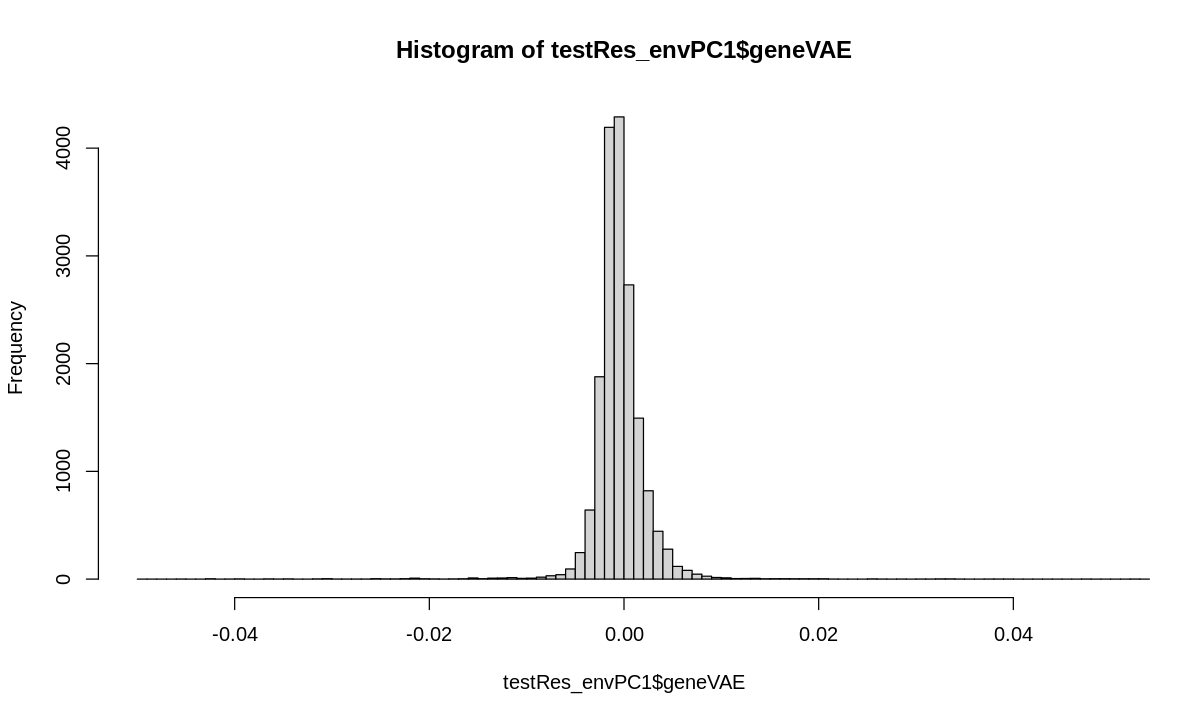

In [1539]:
hist(testRes_envPC1$geneVAE,breaks = seq(-0.05,0.2,0.001),xlim = c(-0.05,0.05))

In [1540]:
dataSubset = subset(testData_merged,OG =="OG0007756")

In [1543]:
cor(cbind(dataSubset$scaledScore,dataSubset$scaledScore_DNA,dataSubset$scaled.dn.ds,dataSubset$PMS),method = "spearman")

1.00000000,0.091627519,-0.3734755,-0.114823909
0.09162752,1.000000000,-0.5087952,-0.003333596
-0.37347548,-0.508795169,1.0000000,0.011630600
-0.11482391,-0.003333596,0.0116306,1.000000000


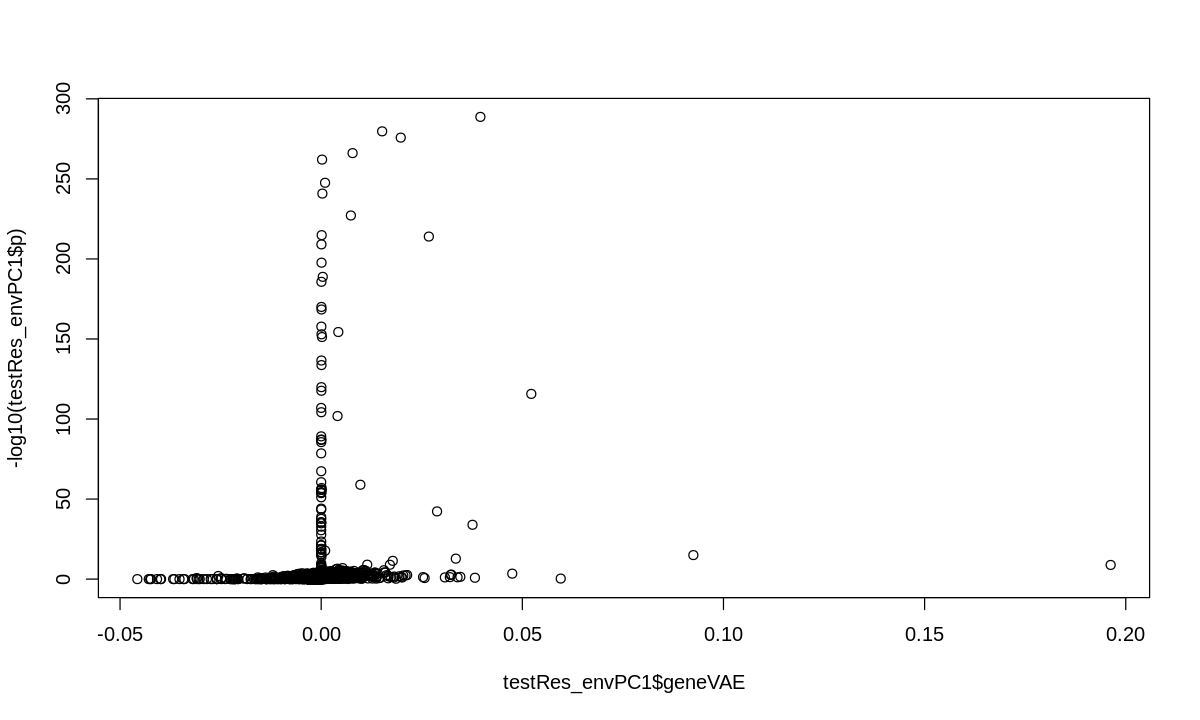

In [1538]:
plot(testRes_envPC1$geneVAE,-log10(testRes_envPC1$p))

In [1472]:
cor(cbind(testRes_envPC1$geneVAE,-log10(testRes_envPC1$p),-log10(testRes_envPC1$partialP_dNdS),
          -log10(testRes_envPC1$partialP_ESM2),-log10(testRes_envPC1$partialP_plantCad),
          -log10(testRes_envPC1$partialP_PMS)))


1.00000000,0.1245083256,0.084388288,0.197940615,0.1603781493,0.159383588
0.12450833,1.0000000000,-0.022810997,-0.002817171,0.0005221168,0.052297894
0.08438829,-0.0228109974,1.000000000,0.039390242,0.0335522960,0.006707022
0.19794061,-0.0028171711,0.039390242,1.000000000,0.0329482072,0.025136242
0.16037815,0.0005221168,0.033552296,0.032948207,1.0000000000,0.012916422
0.15938359,0.0522978937,0.006707022,0.025136242,0.0129164224,1.000000000


In [1612]:
cor(testRes_envPC1[,4:16],method = "spearman")

,LR,p,geneVAE,phyloVAE,totalVar,partialCoeff_dNdS,partialCoeff_ESM2,partialCoeff_plantCad,partialCoeff_PMS,partialP_dNdS,partialP_ESM2,partialP_plantCad,partialP_PMS
LR,1.00000000,-1.00000000,0.394073903,0.011252805,0.011174824,-0.012859914,-0.023441497,0.033130369,-0.1249045433,-0.166301830,-0.3863367550,-0.449825788,-0.386686787
p,-1.00000000,1.00000000,-0.394073568,-0.011253385,-0.011175618,0.012860057,0.023441545,-0.033129868,0.1249048199,0.166301802,0.3863371798,0.449826693,0.386687689
geneVAE,0.39407390,-0.39407357,1.000000000,0.030210686,0.042245394,0.050349515,0.001602241,0.027542973,0.0026036889,-0.063326078,-0.1541021626,-0.164737973,-0.140535507
phyloVAE,0.01125280,-0.01125338,0.030210686,1.000000000,0.144572950,-0.006705410,0.006440765,-0.066108538,-0.0107619659,-0.012680060,0.0213510395,-0.013544444,-0.010996189
totalVar,0.01117482,-0.01117562,0.042245394,0.144572950,1.000000000,-0.025676277,-0.024258983,-0.016998424,-0.0146105248,0.003432653,0.0311452131,-0.024309971,-0.008143213
partialCoeff_dNdS,-0.01285991,0.01286006,0.050349515,-0.006705410,-0.025676277,1.000000000,0.083759091,0.134668294,0.0302627044,0.001547821,-0.0038096219,0.011793805,-0.011006922
partialCoeff_ESM2,-0.02344150,0.02344154,0.001602241,0.006440765,-0.024258983,0.083759091,1.000000000,-0.236368593,0.4816396059,-0.010706741,-0.1283475619,0.004225239,0.112330168
partialCoeff_plantCad,0.03313037,-0.03312987,0.027542973,-0.066108538,-0.016998424,0.134668294,-0.236368593,1.000000000,-0.0370952031,-0.001067430,-0.0099357674,-0.031096972,-0.022989702
partialCoeff_PMS,-0.12490454,0.12490482,0.002603689,-0.010761966,-0.014610525,0.030262704,0.481639606,-0.037095203,1.0000000000,-0.006253779,0.0006223751,0.018088224,0.234698503
partialP_dNdS,-0.16630183,0.16630180,-0.063326078,-0.012680060,0.003432653,0.001547821,-0.010706741,-0.001067430,-0.0062537791,1.000000000,0.0146961720,0.020691587,0.011078257


In [1613]:
table(testRes_envPC1$LR<=0)
table(testRes_envPC1$geneVAE<=0)


FALSE  TRUE 
17269    18 


FALSE  TRUE 
 5996 11291 

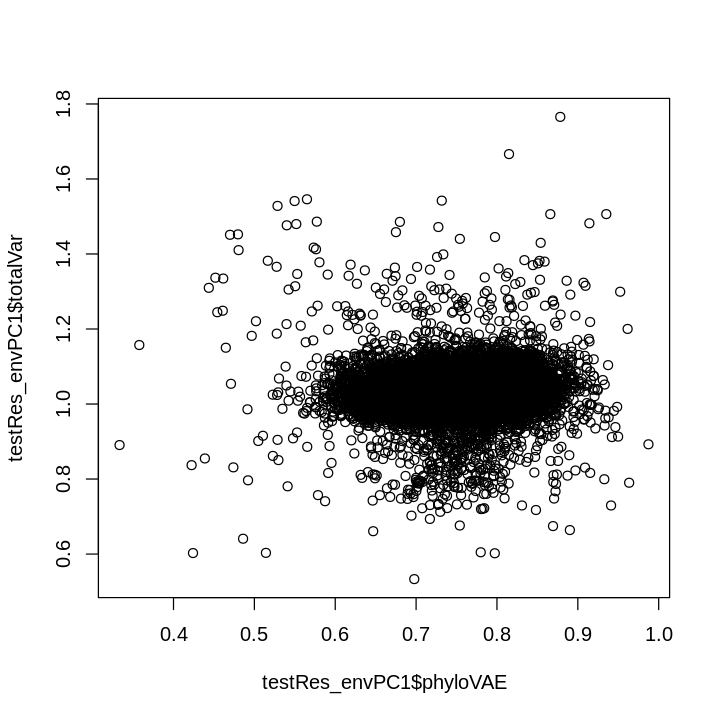

In [1523]:
options(repr.plot.width=6, repr.plot.height=6)
plot(testRes_envPC1$phyloVAE,testRes_envPC1$totalVar)

In [1428]:
testRes_envPC1[1,11:14]
metaseqR2::combine(testRes_envPC1[1,11:14])

,partialP_dNdS,partialP_ESM2,partialP_plantCad,partialP_PMS
,<dbl>,<dbl>,<dbl>,<dbl>
1,0.3131061,0.3659623,0.6142165,0.9397734


[1] 1

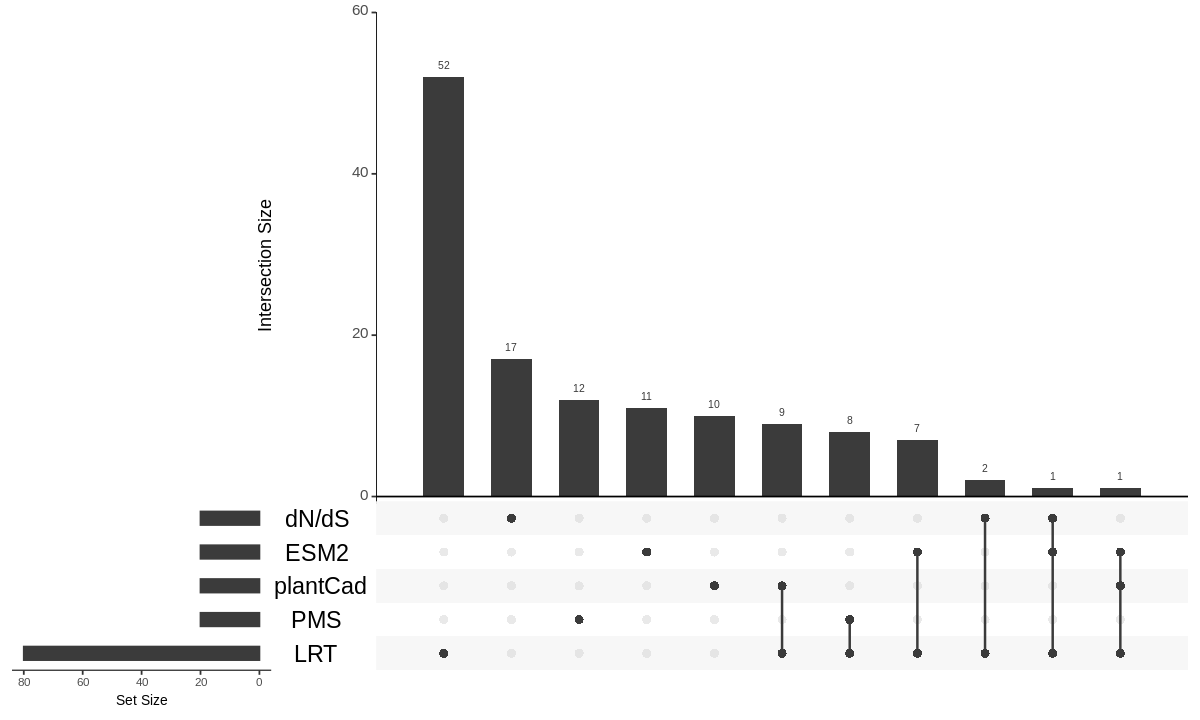

In [387]:
options(repr.plot.width=10, repr.plot.height=6)

envPC1Candidates = list(testRes_envPC1$OG[rank(testRes_envPC1$p) <= 200],
                        testRes_envPC1$OG[rank(testRes_envPC1$partialP_dNdS) <= 200],
                        testRes_envPC1$OG[rank(testRes_envPC1$partialP_ESM2) <= 200],
                        testRes_envPC1$OG[rank(testRes_envPC1$partialP_plantCad) <= 200],
                        testRes_envPC1$OG[rank(testRes_envPC1$partialP_PMS) <= 200])
names(envPC1Candidates) = c("LRT","dN/dS","ESM2","plantCad","PMS")
upset(fromList(envPC1Candidates), text.scale = c(1.3, 1.3, 1, 1, 2, 1))


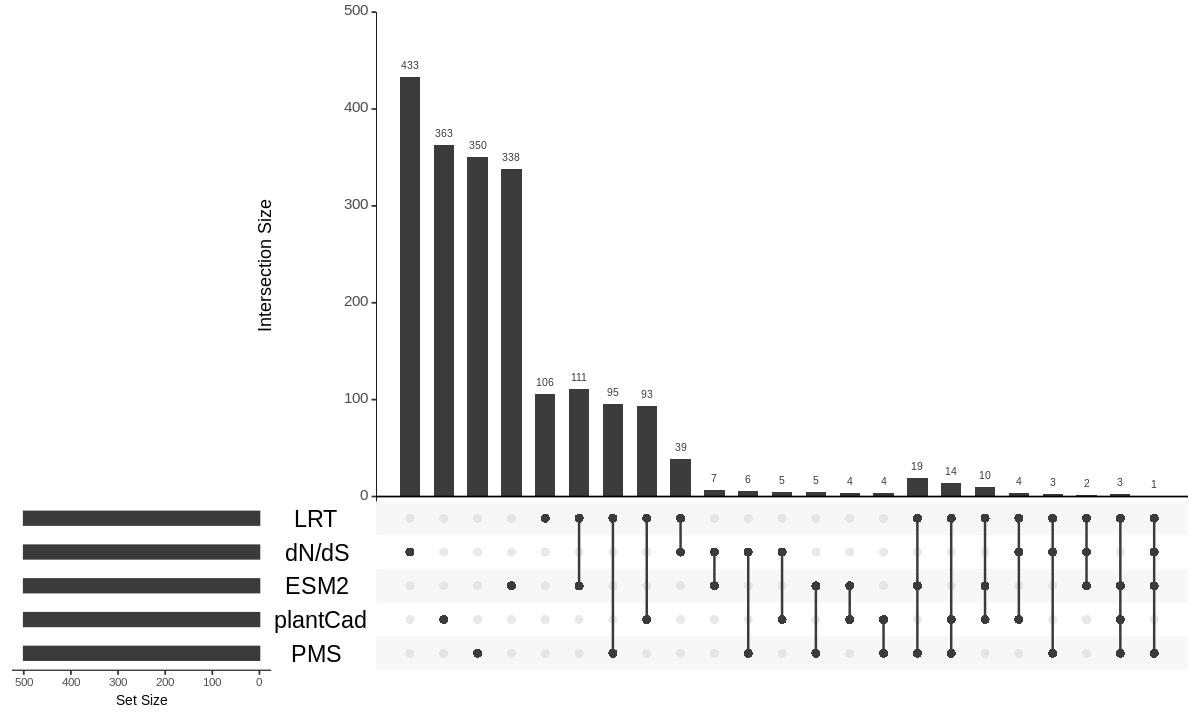

In [167]:
options(repr.plot.width=10, repr.plot.height=6)

envPC2Candidates = list(testRes_envPC2$OG[rank(testRes_envPC2$p) <= 500],
                        testRes_envPC2$OG[rank(testRes_envPC2$partialP_dNdS) <= 500],
                        testRes_envPC2$OG[rank(testRes_envPC2$partialP_ESM2) <= 500],
                        testRes_envPC2$OG[rank(testRes_envPC2$partialP_plantCad) <= 500],
                        testRes_envPC2$OG[rank(testRes_envPC2$partialP_PMS) <= 500])
names(envPC2Candidates) = c("LRT","dN/dS","ESM2","plantCad","PMS")
upset(fromList(envPC2Candidates), text.scale = c(1.3, 1.3, 1, 1, 2, 1))


In [ ]:
library()

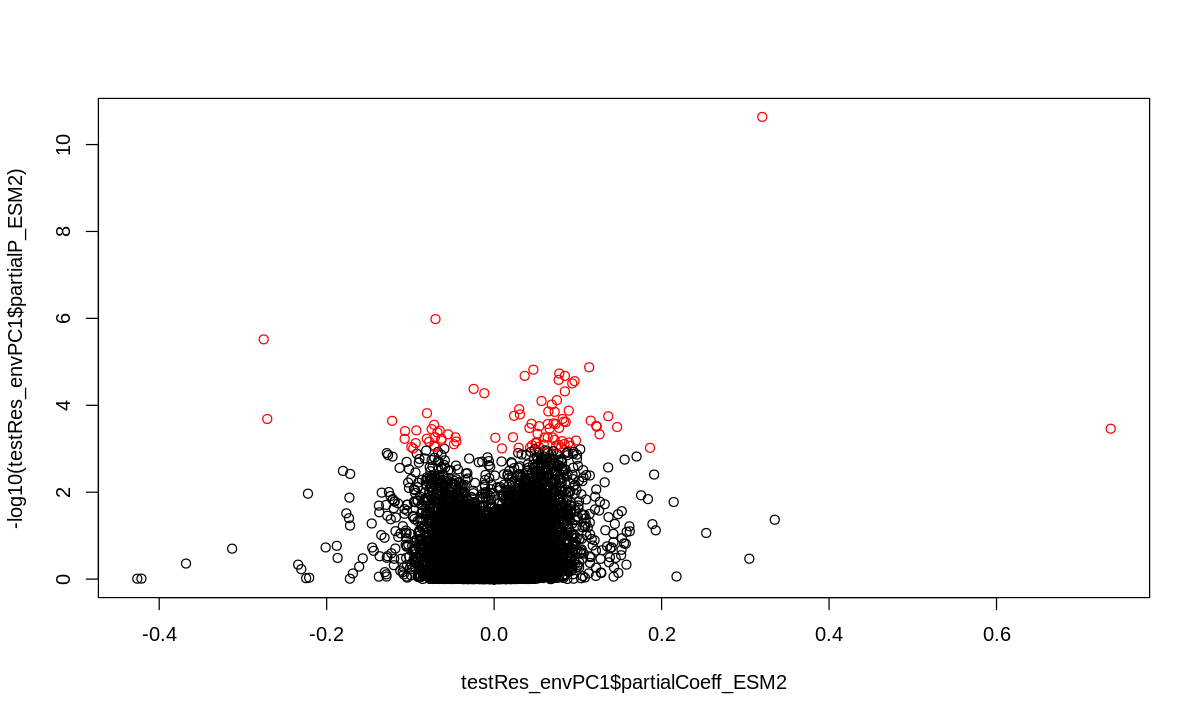

In [1483]:
plot(testRes_envPC1$partialCoeff_ESM2,-log10(testRes_envPC1$partialP_ESM2),col = ifelse(testRes_envPC1$partialP_ESM2<0.001,"red","black"))

In [ ]:
# ESM as response

In [1227]:
test = fit_model_zs(OG_list[7000],data = testData_merged,phyloKMat)

ASReml Version 4.2 21/10/2024 14:41:26
          LogLik        Sigma2     DF     wall
 1     -407.6223     0.9128549    757   14:41:26
 2     -404.0022     0.8926351    757   14:41:26
 3     -399.8103     0.8622366    757   14:41:26
 4     -397.3825     0.8330625    757   14:41:26
 5     -396.8017     0.8138990    757   14:41:26
 6     -396.7937     0.8113718    757   14:41:26


In [1228]:
test

"OG0008725"    "0.0531340201240846"    "0.0392671571661213" 
                                                                        
"-0.000356347566347594"   "-0.0419040205124497"    "0.0114277513903853" 
                                                                        
   "0.0567774295900624"    "0.0191312419801046"    "0.0682743155240142" 
                                                                envPC_1 
  "-0.0565814894784806"   "-0.0174525677991882"     "0.527866148946104" 
                envPC_2                 envPC_3                 envPC_4 
    "0.158677027892863"      "0.65557060481949"     "0.511229618746097" 
                envPC_5                 envPC_6                 envPC_7 
    "0.990329458212429"     "0.186485882240966"     "0.906441291367228" 
                envPC_8                 envPC_9                envPC_10 
    "0.182769433978152"     "0.122238213344606"     "0.638233544533062" 
                                                                        
    "-396.793671215632"     "0.347664378443904"     "0.811371792261358"

In [1369]:
gc()

,used,(Mb),gc trigger,(Mb),max used,(Mb)
Ncells,27983972,1494.6,74490060,3978.2,93112574,4972.8
Vcells,10588325651,80782.6,29392793357,224249.3,26354445001,201068.5


In [1229]:
asreml.options(maxit = 30,verbose = F)
testRes_zs = mclapply(OG_list,function(x) try(fit_model_zs_ori(x,data = testData_merged,phyloKMat),silent = T),mc.cores = 20)

testRes_zs = t(simplify2array(testRes_zs[sapply(testRes_zs,length)==24]))

colnames(testRes_zs) = c("OG",paste0("Coeff_envPC",1:10),paste0("Pval_envPC",1:10),"loglik",
                         "VarComp_phylo","residual")
testRes_zs = as.data.frame(testRes_zs)
head(testRes_zs)

# testRes_zs = merge(testRes_zs,mappingFileMerged,by = "OG",all.x = T)
# write.table(testRes_zs,"/workdir/sh2246/p_phyloGWAS/output/ASREML_res_zeroShotScoreModel_v2.txt",quote = F,sep = "\t",row.names = F)

,OG,Coeff_envPC1,Coeff_envPC2,Coeff_envPC3,Coeff_envPC4,Coeff_envPC5,Coeff_envPC6,Coeff_envPC7,Coeff_envPC8,Coeff_envPC9,⋯,Pval_envPC4,Pval_envPC5,Pval_envPC6,Pval_envPC7,Pval_envPC8,Pval_envPC9,Pval_envPC10,loglik,VarComp_phylo,residual
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,⋯,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
1,OG0000062,0.00819008166943646,0.0132610559211642,-0.0337978092208619,0.0325966121497373,0.0130823391387689,-0.00755825471544748,0.0025059358162453,0.0212471135450526,-0.00925108747400276,⋯,0.0161827506701755,0.470738823026534,0.859129507032395,0.93553709307585,0.451507645218179,0.57450314570679,0.893770855208954,-1547.11134132214,0.111367018187522,0.716198956285385
2,OG0000098,-0.00464913808336609,0.133580776716218,0.0542859047362971,0.0757720513203895,-0.0210879626086549,-0.00676102806734497,-0.0395085127224872,-0.129473367686963,0.0773854578775307,⋯,0.19085240250053,0.743769461219222,0.832872953542205,0.820939124391782,0.00398211047194985,0.0165765004833012,0.190755561373728,-587.711680524207,0.755718872094453,0.610977210990026
3,OG0000106,0.107469671525115,-0.0312524049974187,-0.0441285277369277,-0.0165937443656976,0.0230344891516721,0.00805821528300825,0.039979515154256,0.0472523292167223,-0.0133610494268073,⋯,0.961232435362189,0.479690250915448,0.965849431537955,0.146184122714908,0.259781228711235,0.546056011893018,0.840010040872827,-336.911095428796,0.606191837358924,0.494127227989117
4,OG0000124,0.112827154898167,0.0086547398397886,-0.0238137350713321,-0.0330324573407192,-0.0466233859822201,0.0531032036625294,0.045872332558725,-0.00789040832664936,-0.0992459842150095,⋯,0.175192301221823,0.161265250163246,0.29369581580563,0.142612900323412,0.507087990812742,0.00936861836827896,0.144238845129135,-3444.7926486275,0.578867216089263,1.72601814457833
5,OG0000150,0.0166054252193533,0.0145005028297669,0.000446920169506412,-0.0394673628674874,-0.0197236110187857,-0.0280177451586884,0.0249745279191285,0.00049543554122828,-0.0059011997961347,⋯,0.0364606583592193,0.147433262213347,0.155806971865989,0.0486423429161855,0.86195025499382,0.475898490496917,0.0214215088747477,-128.239238324818,0.0567383599870326,0.387939091482357
6,OG0000152,0.00734346059479864,-0.0220519647637262,0.0331888481591708,-0.0149543455980018,-0.00727745694715312,-0.0285634313852553,0.0156007181121511,-0.0116770268837622,-0.01994861658507,⋯,0.478301276475178,0.888696712525165,0.498186655836919,0.277555848186004,0.758361940653007,0.506706377591674,0.0803689118737261,-386.451990796787,0.0131605245505692,0.693354259570908


In [1230]:
asreml.options(maxit = 30,verbose = F)
testRes_zs2 = mclapply(OG_list,function(x) try(fit_model_zs(x,data = testData_merged,phyloKMat),silent = T),mc.cores = 20)

testRes_zs2 = t(simplify2array(testRes_zs2[sapply(testRes_zs2,length)==24]))

colnames(testRes_zs2) = c("OG",paste0("Coeff_envPC",1:10),paste0("Pval_envPC",1:10),"loglik",
                          "VarComp_phylo","residual")
testRes_zs2 = as.data.frame(testRes_zs2)
head(testRes_zs2)

testRes_zs2 = merge(testRes_zs2,mappingFileMerged,by = "OG",all.x = T)
write.table(testRes_zs2,"/workdir/sh2246/p_phyloGWAS/output/ASREML_res_zeroShotScoreModel_v2.txt",quote = F,sep = "\t",row.names = F)

,OG,Coeff_envPC1,Coeff_envPC2,Coeff_envPC3,Coeff_envPC4,Coeff_envPC5,Coeff_envPC6,Coeff_envPC7,Coeff_envPC8,Coeff_envPC9,⋯,Pval_envPC4,Pval_envPC5,Pval_envPC6,Pval_envPC7,Pval_envPC8,Pval_envPC9,Pval_envPC10,loglik,VarComp_phylo,residual
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,⋯,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
1,OG0000062,0.012041244840251,0.0133928028381674,-0.0334540593863057,0.0322275172262998,0.0129027105922445,-0.00725994675312487,0.00198546694150171,0.0214201307786474,-0.0110982419372847,⋯,0.0159709394338891,0.470169291741,0.860800277227914,0.941057496250904,0.444688733478778,0.573565921859656,0.891890194227554,-1540.72503628259,0.112745105852581,0.713776209494027
2,OG0000098,-0.0211516899066644,0.0934389153705875,0.0429466791355148,0.0456477176866775,-0.0031334464064348,0.00969406157485582,-0.0401335935238224,-0.109970986082848,0.0501998605589358,⋯,0.138137287104864,0.872477085515356,0.917812231911487,0.800669993786953,0.00123256583923648,0.0184635438636394,0.156213491849649,-499.961232822481,0.672160823643737,0.564640712022228
3,OG0000106,0.111374110398277,-0.0328356850127072,-0.0417457607233625,-0.0151720797562903,0.0211507474731101,0.00789950732154803,0.039847202424114,0.0398392927005307,-0.0121102195632581,⋯,0.962492757587262,0.47622656719575,0.953578305980308,0.145471821621064,0.257768004478231,0.542755926188909,0.83883912922013,-337.540919384016,0.600532100480174,0.49433871314771
4,OG0000124,0.0513180759702105,0.0355105877090783,-0.0106722752201272,-0.0360004003389826,-0.0440628759631505,0.0157659512150932,0.0464650141976668,-0.0344133286300382,-0.0651602126468595,⋯,0.0445870664328673,0.147827493693397,0.735176351263017,0.0439392462974816,0.123236028805754,0.0251721436522632,0.159851727683619,-3263.23166591706,0.138431904741662,1.6842801181493
5,OG0000150,0.0170737012440976,0.00749037654248859,0.00936413875801916,-0.0373411623236235,-0.00988616597768596,-0.0139759048931328,0.0357618232571204,0.00467053936178451,1.17931376259434e-05,⋯,0.025333295676063,0.122765840059238,0.130196420280101,0.0349483376811177,0.853810471765967,0.451440857638887,0.0140460570400608,-2.08117462323708,0.0553935588577089,0.343123128238971
6,OG0000152,-0.00027808316710283,-0.0200694991008055,0.0313820120859417,-0.0195496118690182,-0.008566954399323,-0.0291603755890037,0.0196998835617229,-0.0156690223387624,-0.0154890689047046,⋯,0.46443601405741,0.878071073000319,0.473605766250887,0.280459429891228,0.748689217550714,0.514232294793771,0.0722805602819572,-387.016477675955,0.00844468731673444,0.693335471872347


In [1255]:
testRes_zs2 = read.table("/workdir/sh2246/p_phyloGWAS/output/ASREML_res_zeroShotScoreModel_v2.txt",header = T)

In [262]:
png('/workdir/sh2246/p_phyloGWAS/output/ASREML_res_zeroShotScoreModel.png',width = 20,height = 25,units = 'cm',res = 600,pointsize = 6)
par(mfrow = c(5,4))
for(i in 1:10){
    par(mar = c(5,20,2,1))
    topVar = which(rank(ePCs$variable.correlation[,i]^2,na.last = F) > 273)
    barplot(sort(ePCs$variable.components[topVar,i]),main = paste0("envPC",i),horiz = T,
            names.arg = rownames(ePCs$variable.correlation)[topVar],las =1,xlim = c(-1,1))
    
    par(mar = c(5,5,2,1))
    tmpCutoff = quantile(-log10(as.numeric(testRes_zs[,i+11])),.999,na.rm = T)
    tmpCol = rep("grey",nrow(testRes_zs))
    tmpCol[as.numeric(testRes_zs[,i+1])>0& -log10(as.numeric(testRes_zs[,i+11]))>tmpCutoff] = "red"
    tmpCol[as.numeric(testRes_zs[,i+1])<0& -log10(as.numeric(testRes_zs[,i+11]))>tmpCutoff] = "blue"
    qq(as.numeric(testRes_zs[,i+11]),main = paste0("envPC",i),ylim = c(0,15),
       col = tmpCol[order(as.numeric(testRes_zs[,i+11]))])
#     print(sum(-log10(as.numeric(testRes_zs[,i+11]))>tmpCutoff,na.rm = T))
}
dev.off()

png 
  2

In [398]:
# plantCad model

In [740]:
test = fit_model_zs_dna("OG0000508",data = testData_merged,phyloKMat)
test

ASReml Version 4.2 25/09/2024 16:19:41
          LogLik        Sigma2     DF     wall
 1     -228.4942     0.5157144    977   16:19:41  (  1 restrained)
 2     -220.5419     0.5025290    977   16:19:41  (  1 restrained)
 3     -211.2454     0.4829792    977   16:19:41  (  1 restrained)
 4     -204.3908     0.4630372    977   16:19:41  (  1 restrained)
 5     -200.9095     0.4466325    977   16:19:41  (  1 restrained)
 6     -202.2554     0.4425735    977   16:19:41
 7     -201.4561     0.4407351    977   16:19:42
 8     -200.8618     0.4392084    977   16:19:42
 9     -200.5323     0.4382228    977   16:19:42
10     -200.4454     0.4379110    977   16:19:42
11     -200.4341     0.4378173    977   16:19:42


Warning message in asreml(fixed = scaledScore_DNA ~ envPC_1 + envPC_2 + envPC_3 + :
“Some components changed by more than 1% on the last iteration”


"OG0000508"   "0.0984133263525201"   "0.0244928924063498" 
                                                                     
 "0.00309647164725404"  "-0.0450856223163289"   "0.0802543896509952" 
                                                                     
 "0.00498220491185551"   "0.0183586940724357"   "0.0706423713559691" 
                                                             envPC_1 
 "0.00231045722860348"   "0.0234282548328852"   "0.0412784382029265" 
               envPC_2                envPC_3                envPC_4 
   "0.117521664621035"    "0.684529508646926"    "0.299593618081223" 
               envPC_5                envPC_6                envPC_7 
  "0.0040562315383299"     "0.80466987253968"    "0.716279883290949" 
               envPC_8                envPC_9               envPC_10 
   "0.030730027498451"    "0.898527999352758"    "0.354185577647319" 
                                                                     
   "-200.434081792673" "3.62139220774175e-07"    "0.459483312481201" 
               envPC_1                envPC_2                envPC_3 
  "0.0574034164306711"    "0.033770974432213"  "0.00227531881382527" 
               envPC_4                envPC_5                envPC_6 
  "0.0148314317703519"     "0.11383334051554" "0.000843036217969532" 
               envPC_7                envPC_8                envPC_9 
 "0.00182063827150534"   "0.0643426631966088" "0.000224147452138358" 
              envPC_10 
  "0.0118321015525821"

In [429]:
asreml.options(maxit = 30,verbose = F)
testRes_zs_dna = mclapply(OG_list,function(x) try(fit_model_zs_dna(x,data = testData_merged,phyloKMat),silent = T),mc.cores = 18)

testRes_zs_dna = t(simplify2array(testRes_zs_dna[sapply(testRes_zs_dna,length)==34]))

colnames(testRes_zs_dna) = c("OG",paste0("Coeff_envPC",1:10),paste0("Pval_envPC",1:10),"loglik","VarComp_tabasco",
                         "VarComp_phylo",paste0("VAE_envPC",1:10))
testRes_zs_dna = as.data.frame(testRes_zs_dna)
head(testRes_zs_dna)


testRes_zs_dna = merge(testRes_zs_dna,mappingFileMerged,by = "OG",all.x = T)
write.table(testRes_zs_dna,"/workdir/sh2246/p_phyloGWAS/output/ASREML_res_zeroShotScoreModel_plantCad_v2.txt",
            quote = F,sep = "\t",row.names = F)

In [438]:
testRes_zs_dna = read.table("/workdir/sh2246/p_phyloGWAS/output/ASREML_res_zeroShotScoreModel_plantCad_v2.txt",header = T)

In [ ]:
# dn/ds (scaled)

In [1197]:
test = fit_model("OG0000508",data = testData_merged,phyloKMat)
test

ASReml Version 4.2 18/10/2024 16:39:22
          LogLik        Sigma2     DF     wall
 1     -487.8132     0.8738524    977   16:39:22  (  2 restrained)
 2     -468.3180     0.8298891    977   16:39:22  (  1 restrained)
 3     -444.8599     0.7666757    977   16:39:22  (  1 restrained)
 4     -424.7619     0.7024312    977   16:39:23  (  1 restrained)
 5     -411.9274     0.6494572    977   16:39:23  (  1 restrained)
 6     -407.1787     0.6262243    977   16:39:23
 7     -405.7807     0.6189042    977   16:39:23
 8     -405.2417     0.6169074    977   16:39:23
 9     -405.0705     0.6162524    977   16:39:23
10     -405.0373     0.6160037    977   16:39:23
11     -405.0350     0.6159330    977   16:39:23


"OG0000508"  "-0.0211530395803039"  "-0.0745536283315414" 
                                                                     
 "-0.0454890830855713"   "0.0238479342198529"  "-0.0283635872553822" 
                                                                     
   "0.030709566814387"   "0.0341229388622387"  "-0.0530456075159732" 
                                                             envPC_1 
 "0.00541953205447825"  "-0.0134985784265212"    "0.841952439684881" 
               envPC_2                envPC_3                envPC_4 
  "0.0199123986666786"   "0.0900416192352096"    "0.786159759901892" 
               envPC_5                envPC_6                envPC_7 
   "0.437092224825122"    "0.418557232677052"     "0.20660157503956" 
               envPC_8                envPC_9               envPC_10 
   "0.209832968086626"     "0.88441641980532"    "0.667103033638281" 
                                                                     
   "-405.035037825391" "1.38449440685148e-09"     "0.97187771022221" 
                                              
"8.44138898685235e-06"   "0.0175668240812468"

In [592]:
asreml.options(maxit = 30,verbose = F)
testRes_dnds = mclapply(OG_list,function(x) try(fit_model_ori(x,data = testData_merged,phyloKMat),silent = T),mc.cores = 8)

testRes_dnds = t(simplify2array(testRes_dnds[sapply(testRes_dnds,length)==24]))

colnames(testRes_dnds) = c("OG",paste0("Coeff_envPC",1:10),paste0("Pval_envPC",1:10),"loglik","VarComp_tabasco",
                         "VarComp_phylo")
testRes_dnds = as.data.frame(testRes_dnds)
head(testRes_dnds)


# testRes_dnds = merge(testRes_dnds,mappingFileMerged,by = "OG",all.x = T)
# write.table(testRes_dnds,"/workdir/sh2246/p_phyloGWAS/output/ASREML_res_dndsModel_v2.txt",
#             quote = F,sep = "\t",row.names = F)

,OG,Coeff_envPC1,Coeff_envPC2,Coeff_envPC3,Coeff_envPC4,Coeff_envPC5,Coeff_envPC6,Coeff_envPC7,Coeff_envPC8,Coeff_envPC9,⋯,VAE_envPC1,VAE_envPC2,VAE_envPC3,VAE_envPC4,VAE_envPC5,VAE_envPC6,VAE_envPC7,VAE_envPC8,VAE_envPC9,VAE_envPC10
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,⋯,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
1,OG0000062,0.00234705250440447,0.0178177151323806,-0.0347095212297834,0.00625236186429894,-0.00497300499368903,0.0441752144583389,0.00350281434880024,-0.00405655076275019,-0.00706700872758339,⋯,0.00782750792500769,0.0713961596655472,0.321806517589225,0.00476502567686297,0.0127590043479347,0.386659467736689,0.00170952029808195,0.0037006675481701,0.00979276873005953,0.00270681360258194
2,OG0000098,0.0603905970080104,-0.0414836429160968,0.0422390848223422,0.0423333247370585,-0.00287732773104326,0.0385540079689642,-0.0196018925268855,0.0429328742829345,0.017102057846357,⋯,0.12801640729897,0.0920008224198254,0.129065136273679,0.205262769161443,0.00168758111640423,0.105356101939107,0.0455640479841915,0.0742530533687974,0.0146293747249896,0.0169816927978131
3,OG0000106,-0.147833598408102,0.00879051903175243,0.0247656887708529,0.0194077627522844,0.037362822082383,0.0305449912682104,-0.038302649784187,-0.0811495219544956,0.00762352005985307,⋯,0.349490704346444,3.75428131858888e-05,0.0292292215139307,0.000718109873681259,0.075412402840371,0.0705230132679085,0.054580412508453,0.245462412041102,0.00375250911431135,0.00717252719894005
4,OG0000124,-0.0269637878104123,0.00667751898915634,0.00123707129274882,-0.0145073072956133,0.0117666776747592,0.00064576369981609,0.0220838674684669,-0.0421994310068358,-0.00805036332379405,⋯,0.0290032731618918,0.00360320105665778,6.54784492368876e-06,0.0962098302452849,0.017897967641375,0.000490773833119106,0.163381852623942,0.236270221301726,0.0126381786451247,3.18481936400467e-06
5,OG0000150,0.0623651505394023,0.0240999971723658,0.0257344402713112,-0.0423522957483767,-0.0137192839461784,-0.0174535114432205,-0.00775592247481766,0.0123648749938107,-0.0216486809232503,⋯,0.094240111750976,0.0529186562454091,0.0648413623080233,0.0735233567824532,0.0109517943114364,0.0308750556023261,0.000724256379913257,0.0033180359209718,0.0276298868599425,0.0482977380954167
6,OG0000152,-0.0309398169202072,0.104620338644978,-0.00875512938111224,-0.00811078609895498,0.0606592255094429,-0.0564940275350625,-0.0338207955780332,0.0322688210097706,0.0822186681076749,⋯,0.000376172648246135,0.113119190503862,0.000297632069840801,0.00191785680012234,0.054527936413588,0.0226414060155866,0.0276019950409515,0.00486505385619703,0.0994633636643898,0.0596726667455427


In [592]:
asreml.options(maxit = 30,verbose = F)
testRes_dnds2 = mclapply(OG_list,function(x) try(fit_model(x,data = testData_merged,phyloKMat),silent = T),mc.cores = 8)

testRes_dnds2 = t(simplify2array(testRes_dnds2[sapply(testRes_dnds2,length)==26]))

colnames(testRes_dnds2) = c("OG",paste0("Coeff_envPC",1:10),paste0("Pval_envPC",1:10),"loglik",
                            "VarComp_tabasco","VarComp_queryCov","VarComp_pacbio","VarComp_phylo")
testRes_dnds2 = as.data.frame(testRes_dnds2)
head(testRes_dnds2)


testRes_dnds2 = merge(testRes_dnds2,mappingFileMerged,by = "OG",all.x = T)
write.table(testRes_dnds2,"/workdir/sh2246/p_phyloGWAS/output/ASREML_res_dndsModel_v2.txt",
            quote = F,sep = "\t",row.names = F)

,OG,Coeff_envPC1,Coeff_envPC2,Coeff_envPC3,Coeff_envPC4,Coeff_envPC5,Coeff_envPC6,Coeff_envPC7,Coeff_envPC8,Coeff_envPC9,⋯,VAE_envPC1,VAE_envPC2,VAE_envPC3,VAE_envPC4,VAE_envPC5,VAE_envPC6,VAE_envPC7,VAE_envPC8,VAE_envPC9,VAE_envPC10
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,⋯,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
1,OG0000062,0.00234705250440447,0.0178177151323806,-0.0347095212297834,0.00625236186429894,-0.00497300499368903,0.0441752144583389,0.00350281434880024,-0.00405655076275019,-0.00706700872758339,⋯,0.00782750792500769,0.0713961596655472,0.321806517589225,0.00476502567686297,0.0127590043479347,0.386659467736689,0.00170952029808195,0.0037006675481701,0.00979276873005953,0.00270681360258194
2,OG0000098,0.0603905970080104,-0.0414836429160968,0.0422390848223422,0.0423333247370585,-0.00287732773104326,0.0385540079689642,-0.0196018925268855,0.0429328742829345,0.017102057846357,⋯,0.12801640729897,0.0920008224198254,0.129065136273679,0.205262769161443,0.00168758111640423,0.105356101939107,0.0455640479841915,0.0742530533687974,0.0146293747249896,0.0169816927978131
3,OG0000106,-0.147833598408102,0.00879051903175243,0.0247656887708529,0.0194077627522844,0.037362822082383,0.0305449912682104,-0.038302649784187,-0.0811495219544956,0.00762352005985307,⋯,0.349490704346444,3.75428131858888e-05,0.0292292215139307,0.000718109873681259,0.075412402840371,0.0705230132679085,0.054580412508453,0.245462412041102,0.00375250911431135,0.00717252719894005
4,OG0000124,-0.0269637878104123,0.00667751898915634,0.00123707129274882,-0.0145073072956133,0.0117666776747592,0.00064576369981609,0.0220838674684669,-0.0421994310068358,-0.00805036332379405,⋯,0.0290032731618918,0.00360320105665778,6.54784492368876e-06,0.0962098302452849,0.017897967641375,0.000490773833119106,0.163381852623942,0.236270221301726,0.0126381786451247,3.18481936400467e-06
5,OG0000150,0.0623651505394023,0.0240999971723658,0.0257344402713112,-0.0423522957483767,-0.0137192839461784,-0.0174535114432205,-0.00775592247481766,0.0123648749938107,-0.0216486809232503,⋯,0.094240111750976,0.0529186562454091,0.0648413623080233,0.0735233567824532,0.0109517943114364,0.0308750556023261,0.000724256379913257,0.0033180359209718,0.0276298868599425,0.0482977380954167
6,OG0000152,-0.0309398169202072,0.104620338644978,-0.00875512938111224,-0.00811078609895498,0.0606592255094429,-0.0564940275350625,-0.0338207955780332,0.0322688210097706,0.0822186681076749,⋯,0.000376172648246135,0.113119190503862,0.000297632069840801,0.00191785680012234,0.054527936413588,0.0226414060155866,0.0276019950409515,0.00486505385619703,0.0994633636643898,0.0596726667455427


In [661]:
testRes_dnds2 = read.table("/workdir/sh2246/p_phyloGWAS/output/ASREML_res_dndsModel_v2.txt",header = T)

In [1279]:
wald.asreml(test)

,Df,Sum of Sq,Wald statistic,Pr(Chisq)
(Intercept),1,0.74813051,8.2327496,0.004114115
scaled.dn.ds,1,0.43168980,4.7505001,0.029289782
scaledScore,1,0.08767261,0.9647871,0.325983716
scaledScore_DNA,1,0.68697388,7.5597557,0.005968608
compdup,1,0.05307545,0.5840651,0.444723345
queryCov,1,0.01792317,0.1972343,0.656962560
pacbio,1,0.63958277,7.0382436,0.007978724
residual (MS),NA,0.09087250,NA,NA


In [ ]:
# multiVariate

In [1280]:
test = fit_model_multiVar("OG0000508",data = testData_merged,phyloKMat)

ASReml Version 4.2 25/10/2024 14:47:32
          LogLik        Sigma2     DF     wall
 1     -5965.385           1.0   9864   14:47:32  (  8 restrained)
 2     -5385.910           1.0   9864   14:47:32  ( 10 restrained)
 3     -4832.764           1.0   9864   14:47:32  (  4 restrained)
 4     -4567.279           1.0   9864   14:47:33  (  1 restrained)
 5     -4498.456           1.0   9864   14:47:33
 6     -4489.150           1.0   9864   14:47:33
 7     -4485.303           1.0   9864   14:47:33
 8     -4483.389           1.0   9864   14:47:33
 9     -4482.373           1.0   9864   14:47:33
10     -4481.807           1.0   9864   14:47:33
11     -4481.480           1.0   9864   14:47:34
12     -4481.286           1.0   9864   14:47:34
13     -4481.168           1.0   9864   14:47:34
14     -4481.095           1.0   9864   14:47:34
15     -4481.049           1.0   9864   14:47:34
16     -4481.020           1.0   9864   14:47:34
17     -4481.001           1.0   9864   14:47:34
18     -4

Warning message in asreml(fixed = cbind(envPC_1, envPC_2, envPC_3, envPC_4, envPC_5, :
“Some components changed by more than 1% on the last iteration”


ASReml Version 4.2 25/10/2024 14:47:36
          LogLik        Sigma2     DF     wall
 1     -5956.758           1.0   9867   14:47:36  (  8 restrained)
 2     -5376.550           1.0   9867   14:47:36  (  9 restrained)
 3     -4822.869           1.0   9867   14:47:37  (  4 restrained)
 4     -4556.457           1.0   9867   14:47:37  (  1 restrained)
 5     -4487.068           1.0   9867   14:47:37
 6     -4477.449           1.0   9867   14:47:37
 7     -4473.410           1.0   9867   14:47:37
 8     -4471.368           1.0   9867   14:47:37
 9     -4470.264           1.0   9867   14:47:37
10     -4469.634           1.0   9867   14:47:37
11     -4469.262           1.0   9867   14:47:38
12     -4469.035           1.0   9867   14:47:38
13     -4468.893           1.0   9867   14:47:38
14     -4468.803           1.0   9867   14:47:38
15     -4468.744           1.0   9867   14:47:38
16     -4468.706           1.0   9867   14:47:38
17     -4468.681           1.0   9867   14:47:38
18     -4

Warning message in asreml(fixed = cbind(envPC_1, envPC_2, envPC_3, envPC_4, envPC_5, :
“Some components changed by more than 1% on the last iteration”


In [1270]:
test$coefficients$fixed

,effect
trait_envPC_1,6.187703e-01
trait_envPC_2,6.527725e-01
trait_envPC_3,6.187557e-01
trait_envPC_4,6.467701e-01
trait_envPC_5,6.030496e-01
trait_envPC_6,6.624623e-01
trait_envPC_7,7.093733e-01
trait_envPC_8,6.825099e-01
trait_envPC_9,6.698815e-01
trait_envPC_10,6.865414e-01


In [1287]:
summary(test)$varcomp

,component,std.error,z.ratio,bound,%ch
,<dbl>,<dbl>,<dbl>,<chr>,<dbl>
"vm(assemblyID, phyloK_OG)",0.566593866,0.07033990,8.05508533,P,0.2
units:trait!R,1.000000000,NA,NA,F,0.0
units:trait!trait_envPC_1:envPC_1,0.741344078,0.03499936,21.18164377,P,0.0
units:trait!trait_envPC_2:envPC_1,-0.138844038,0.02777996,-4.99799217,P,0.0
units:trait!trait_envPC_2:envPC_2,0.943631351,0.04381794,21.53527212,P,0.0
units:trait!trait_envPC_3:envPC_1,-0.131117775,0.02741517,-4.78267192,P,0.1
units:trait!trait_envPC_3:envPC_2,-0.034182544,0.03060325,-1.11695807,P,0.1
units:trait!trait_envPC_3:envPC_3,0.923766894,0.04273107,21.61815710,P,0.0
units:trait!trait_envPC_4:envPC_1,-0.088286121,0.02780813,-3.17483175,P,0.1


In [1286]:
summary(test)$varcomp[1,1]/(summary(test)$varcomp[c(3,5,8,12,17,23,30,38,47,57),1] + summary(test)$varcomp[1,1])

[1] 0.4331963 0.3751718 0.3801723 0.3698145 0.3731439 0.3886195 0.4019986
 [8] 0.4122846 0.3651835 0.3624863

In [1257]:
test = fit_model_multiVar_ori("OG0000508",data = testData_merged,phyloKMat)
summary(test)

ERROR: Error in eval(parse(text = x), envir = data, enclos = asremlEnv): object 'trait' not found


In [940]:
asreml.options(maxit = 40,verbose = F)
testRes_multiVar = mclapply(OG_list,function(x) try(fit_model_multiVar(x,data = testData_merged,phyloKMat),silent = T),mc.cores = 15)

testRes_multiVar = t(simplify2array(testRes_multiVar[sapply(testRes_multiVar,length)==26]))

colnames(testRes_multiVar) = c("OG",paste0("Coeff_envPC",1:10),paste0("Pval_envPC",1:10),"loglik",
                               "VarComp_tabasco","VarComp_queryCov","VarComp_pacbio","VarComp_phylo")
testRes_multiVar = as.data.frame(testRes_multiVar)
head(testRes_multiVar)


testRes_multiVar = merge(testRes_multiVar,mappingFileMerged,by = "OG",all.x = T)
write.table(testRes_multiVar,"/workdir/sh2246/p_phyloGWAS/output/ASREML_res_multiVarModel_v2.txt",
            quote = F,sep = "\t",row.names = F)

,OG,Coeff_envPC1,Coeff_envPC2,Coeff_envPC3,Coeff_envPC4,Coeff_envPC5,Coeff_envPC6,Coeff_envPC7,Coeff_envPC8,Coeff_envPC9,⋯,Pval_envPC6,Pval_envPC7,Pval_envPC8,Pval_envPC9,Pval_envPC10,loglik,VarComp_tabasco,VarComp_queryCov,VarComp_pacbio,VarComp_phylo
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,⋯,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
1,OG0000062,-0.0120609694149699,-0.00299152454276533,0.000446662477966424,0.00933954510955052,0.00936351262766024,-0.0219540345246909,0.00147665401297533,0.00745259960541211,-0.00372988657452376,⋯,0.0930765120740651,0.996877451957716,0.646890668818622,0.749732145498824,0.892328026705136,-5418.87008193609,1.10432973102821e-08,0.0686869729723064,5.876830290615e-05,0.0136388270360673
2,OG0000098,-0.00959907405894288,0.0470073860858994,0.00200967453422275,0.00677241504609712,-0.00791928833762207,-0.00491539808326465,8.17554322601135e-06,-0.0580231960676554,0.0245473159305365,⋯,0.678489817235379,0.439197762532144,0.0106667938498664,0.142765372878628,0.723700744518293,-1943.96423944746,6.34456567473688e-10,0.512772940232748,0.443780462405468,0.00257115733480514
3,OG0000106,0.0795880779032241,0.00290009669615037,-0.0203367352435583,-0.0268260133394904,-0.0161451604546665,-0.0101620972638877,0.0301663322204906,0.0459228631636484,0.00114252294653818,⋯,0.485606113973818,0.139135046240176,0.0427916052485425,0.967073287631377,0.526989704800424,-1131.77170976132,9.49099935252766e-09,0.298015475813016,1.197538212194e-08,0.131382110003196
4,OG0000124,0.0312347457545578,0.02359483629856,-0.00152516630806279,-0.0121541447419535,-0.0137870802055745,0.0030168872247836,0.00127824507079125,0.00896543890184704,-0.00823764719236106,⋯,0.834336611045088,0.926593895566496,0.681637286273412,0.576884370168577,0.595142894605204,-7587.52693680773,1.29385975022995e-08,2.04577185488433e-07,0.0668698988270878,0.0153240061701191
5,OG0000150,-0.00858973809607527,0.00679393729370319,0.00382856675187744,-0.00554736469921618,-0.00873063933064621,-0.0032738290968867,0.0199192518872038,-0.000916225964421442,0.00711826774835046,⋯,0.885578982033747,0.163738538290364,0.987531585782602,0.589062613599646,0.068431609841485,-1937.68060571344,1.9828094418785e-10,0.481084743623883,0.502606106493673,0.000129483012013706
6,OG0000152,0.0642236901476121,-0.0540017520015559,0.03551009225982,-0.00156704384029563,-0.043190966972507,0.0360717026357966,0.0375049877336009,-0.00386006619235304,-0.0551900434598497,⋯,0.185790174450932,0.0591991182208619,0.99482464310483,0.0108081144598858,0.253966187704867,-1159.35160905259,1.19300434269519e-08,0.365981872535579,7.97128225436849e-09,0.0298570258938454


In [941]:
testRes_multiVar = read.table("/workdir/sh2246/p_phyloGWAS/output/ASREML_res_multiVarModel_v2.txt",header = T)

In [1022]:
asreml.options(maxit = 40,verbose = F)
testRes_multiVar2 = mclapply(OG_list,function(x) try(fit_model_multiVar_ori(x,data = testData_merged,phyloKMat),silent = T),mc.cores = 15)

testRes_multiVar2 = t(simplify2array(testRes_multiVar2[sapply(testRes_multiVar2,length)==24]))

colnames(testRes_multiVar2) = c("OG",paste0("Coeff_envPC",1:10),paste0("Pval_envPC",1:10),"loglik",
                               "VarComp_tabasco","VarComp_phylo")
testRes_multiVar2 = as.data.frame(testRes_multiVar2)
head(testRes_multiVar2)


# testRes_multiVar = merge(testRes_multiVar,mappingFileMerged,by = "OG",all.x = T)
# write.table(testRes_multiVar,"/workdir/sh2246/p_phyloGWAS/output/ASREML_res_multiVarModel_v2.txt",
#             quote = F,sep = "\t",row.names = F)

,OG,Coeff_envPC1,Coeff_envPC2,Coeff_envPC3,Coeff_envPC4,Coeff_envPC5,Coeff_envPC6,Coeff_envPC7,Coeff_envPC8,Coeff_envPC9,⋯,Pval_envPC4,Pval_envPC5,Pval_envPC6,Pval_envPC7,Pval_envPC8,Pval_envPC9,Pval_envPC10,loglik,VarComp_tabasco,VarComp_phylo
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,⋯,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
1,OG0000062,-0.00979894047851156,-0.000549249438882024,0.000651698489731962,0.00965833048287775,0.00756277385298951,-0.0212336293697512,0.00261110122813219,0.00832405420220096,-0.00368057458883612,⋯,0.319146100057438,0.490051351133007,0.111089102947092,0.933578281092637,0.611435298191127,0.754842034375858,0.882772771689464,-5422.96156078583,1.18298956813068e-08,0.0175990361574207
2,OG0000098,-0.00816489314023886,0.0577509686884934,0.00281223619350782,0.0145052893146084,-0.011087128437055,-0.0103445306210132,0.001542610073768,-0.0626256646107668,0.0301045528269254,⋯,0.847228009902162,0.741107539079149,0.4851716206426,0.343131207039709,0.00801946251467034,0.0830418757495062,0.837916453164362,-1972.18820476172,1.40871741337128e-08,0.063505490900734
3,OG0000106,0.0802671043780037,0.00467593041777058,-0.0206765025818939,-0.023584097880444,-0.0205956317527023,-0.00903205832555157,0.0319519144871951,0.0378600308221259,0.00231194775945333,⋯,0.434353416481701,0.313753717670365,0.506823734911106,0.0981153530344625,0.0919558885956097,0.917828168931533,0.413697034108867,-1137.84052196756,1.3539343293702e-08,0.181091302770333
4,OG0000124,0.0268979756597334,0.0319984909683882,-0.00489193146679299,-0.0101415998002261,-0.01737671555851,0.00422760998563791,0.0011751759151836,0.00585615200027857,-0.00828874015105988,⋯,0.347111629635894,0.21395516328214,0.776210033514318,0.911739896747929,0.822276650090986,0.573731869023315,0.580826132385058,-7592.73391864719,1.38364135934651e-08,0.0159213753816282
5,OG0000150,-0.00839680068788293,0.00851288636715865,-0.0131802842401329,-0.00266252496423157,-0.0161806493658943,-0.00745592349130199,0.0132223522949171,-0.00129270334679179,-0.000329296913491879,⋯,0.902117075259876,0.224957406603153,0.615659760726292,0.396921553073082,0.912643294824756,0.915236251014589,0.134922053585858,-2048.62636982272,4.1499195614764e-09,0.0153980248098726
6,OG0000152,0.0717474775350227,-0.054401985109016,0.0313984554398878,-0.00320136162583442,-0.0416802487058728,0.0404548490489732,0.0468821668712748,0.000782038230288582,-0.0573455154634422,⋯,0.90988146449005,0.0498300017448121,0.154959352471452,0.0214029100334654,0.867718404645462,0.00950347796489281,0.207468294957306,-1168.89828748675,7.4468158368398e-09,0.0599491158124703


In [593]:
gc()

,used,(Mb),gc trigger,(Mb),max used,(Mb)
Ncells,27544033,1471.1,74490060,3978.2,93112574,4972.8
Vcells,16430233581,125352.8,29392793357,224249.3,26354445001,201068.5


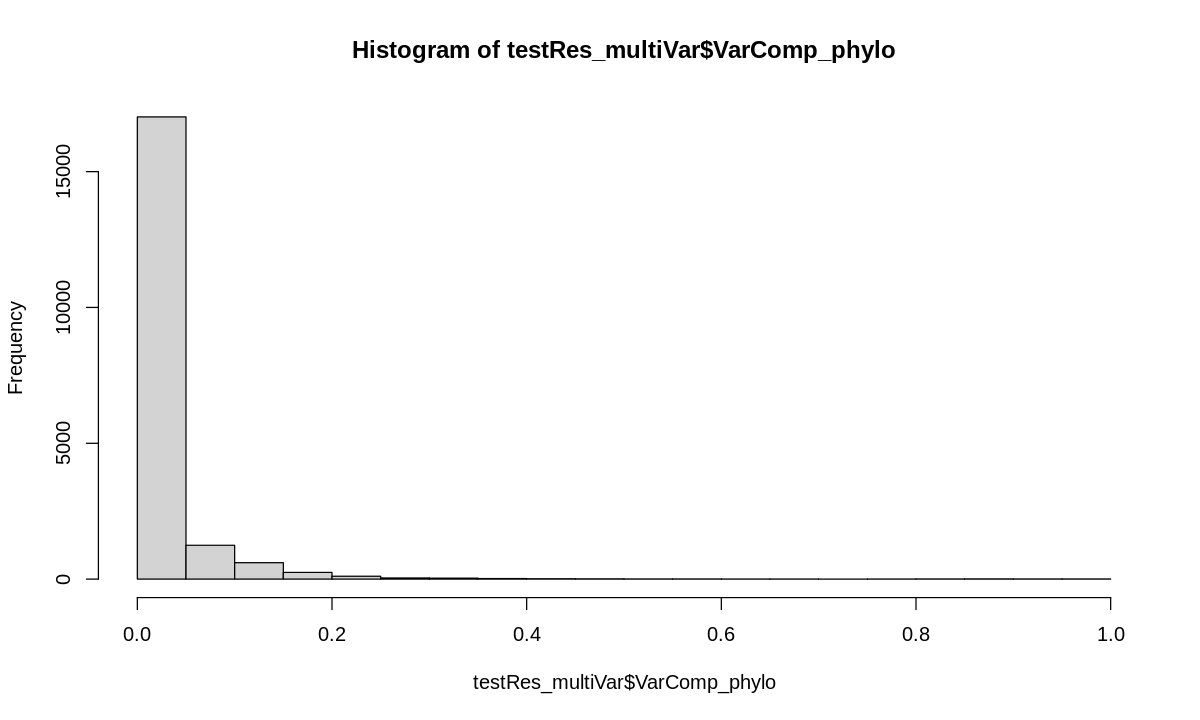

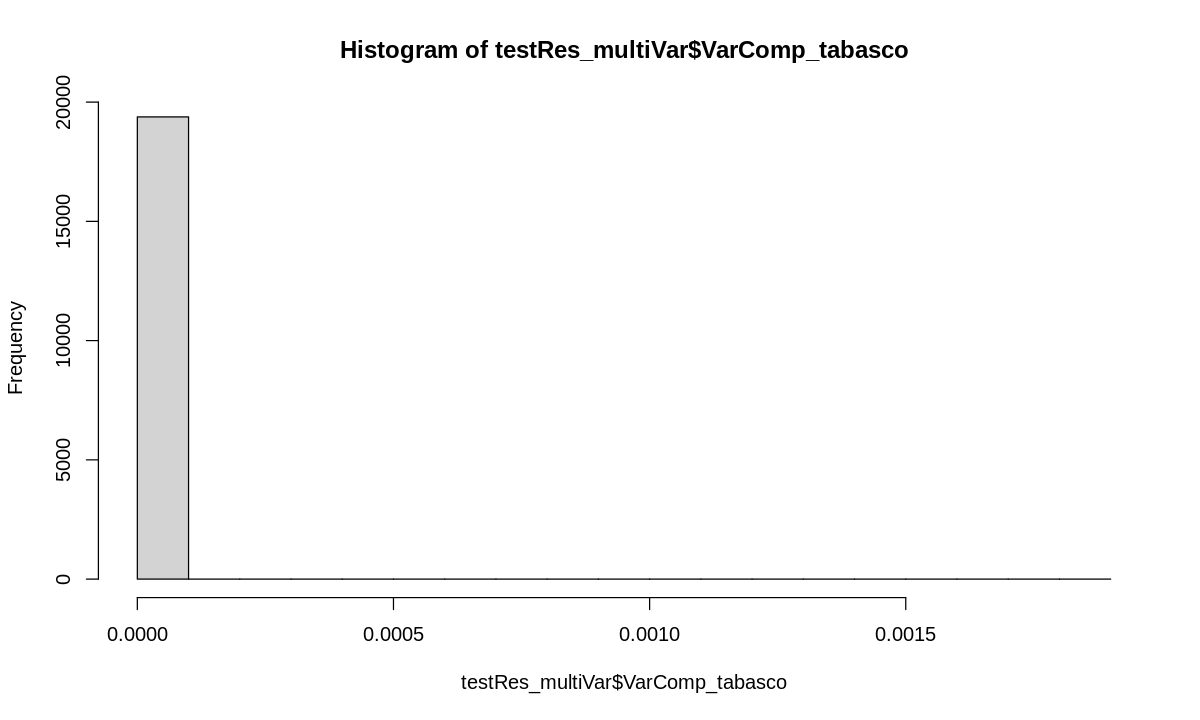

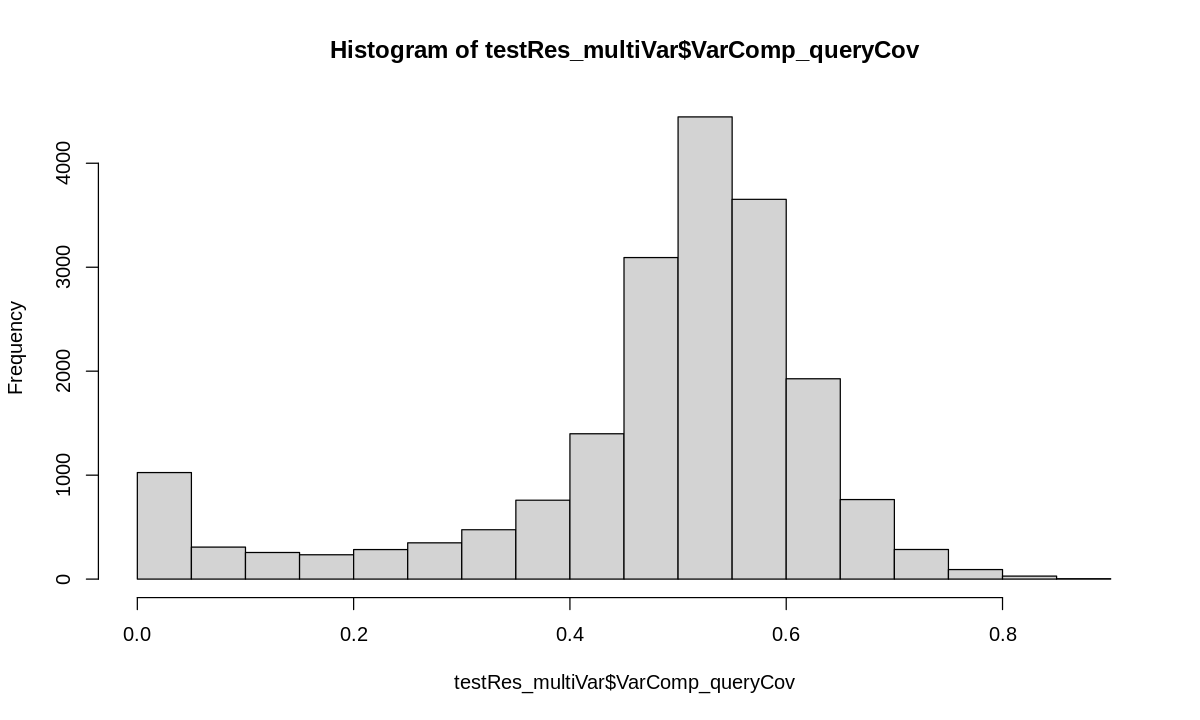

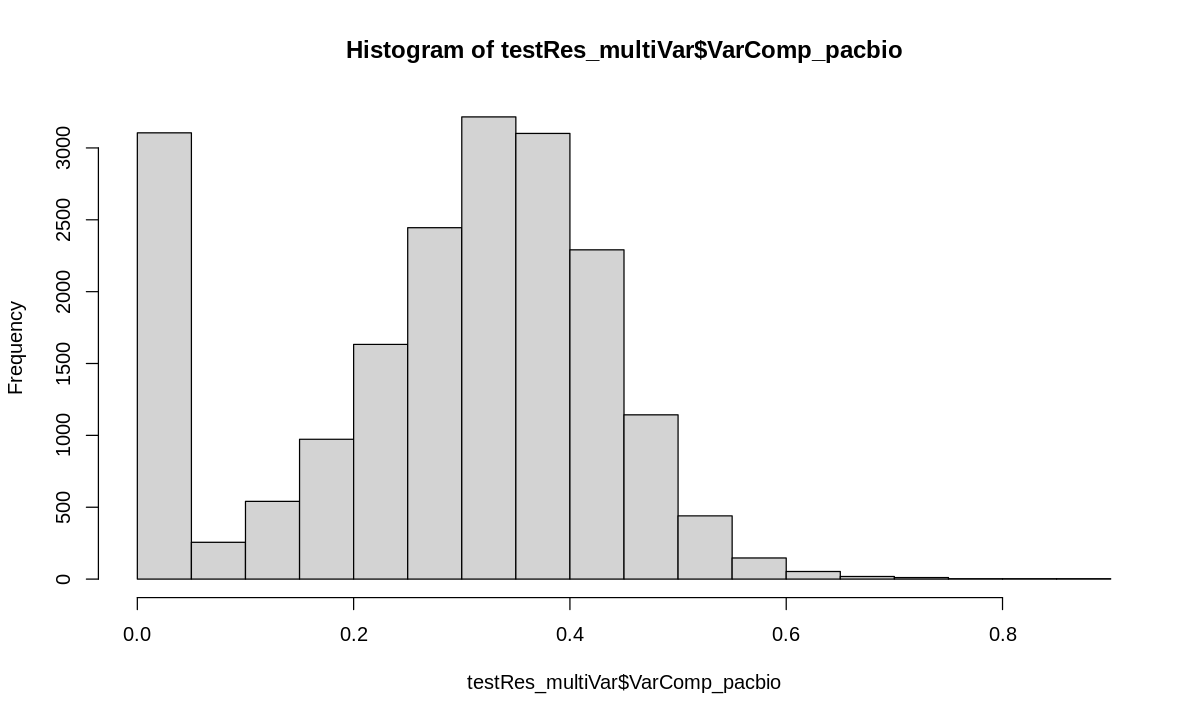

In [965]:
hist(testRes_multiVar$VarComp_phylo)
hist(testRes_multiVar$VarComp_tabasco)
hist(testRes_multiVar$VarComp_queryCov)
hist(testRes_multiVar$VarComp_pacbio)

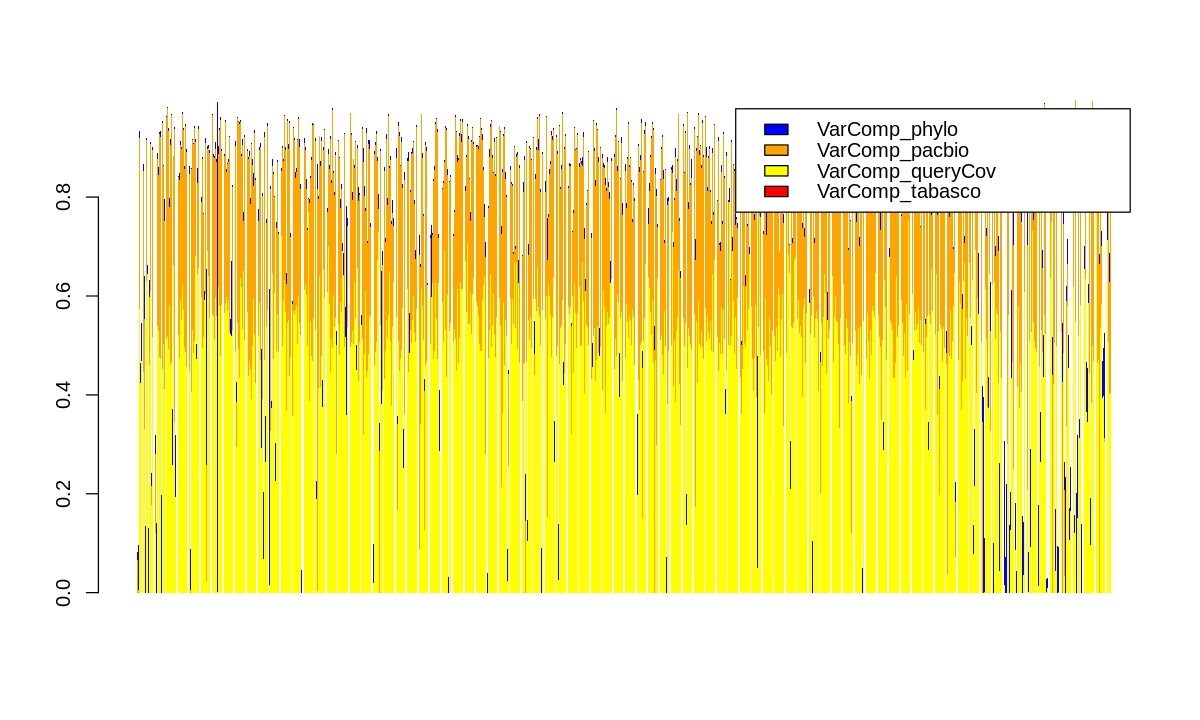

In [988]:
barplot(t(as.matrix(testRes_multiVar[,23:26],nrow(testRes_multiVar),4)),legend.text = T,border = NA,col = c("red","yellow","orange","blue"))

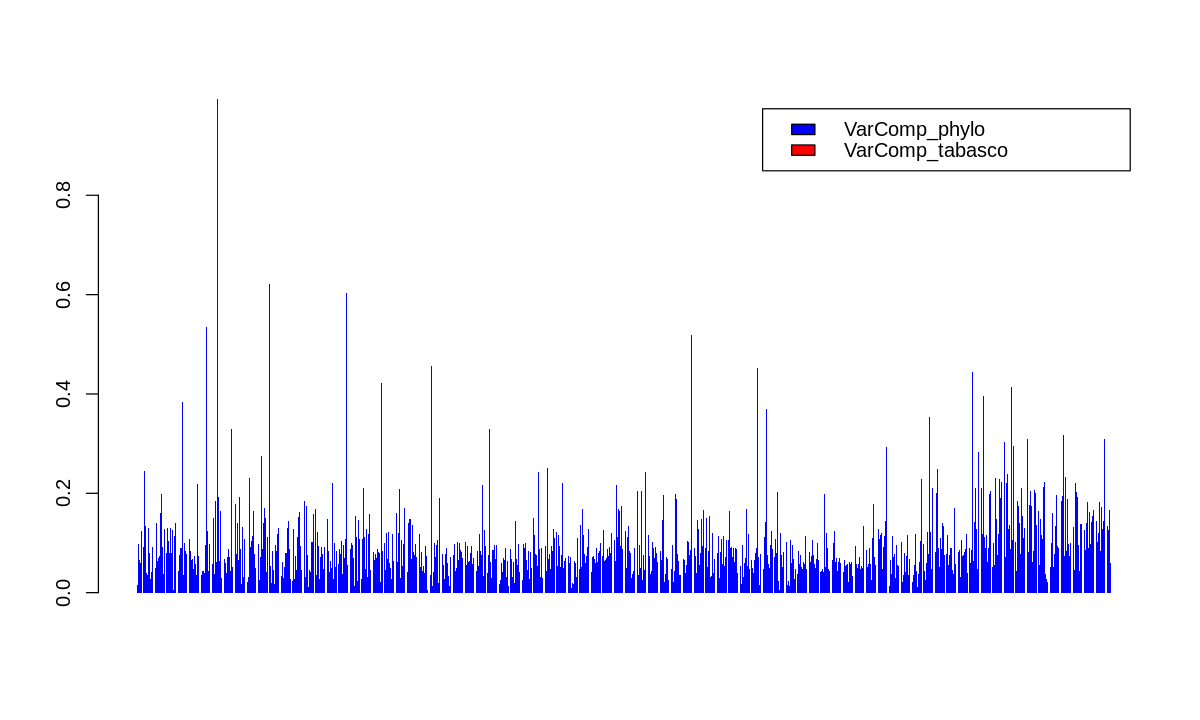

In [1038]:
barplot(t(as.matrix(testRes_multiVar2[,23:24],nrow(testRes_multiVar2),2)),legend.text = T,border = NA,col = c("red","blue"))

In [1030]:
colnames(testRes_multiVar)[23:26]
colnames(testRes_multiVar2)[24]

[1] "VarComp_tabasco"  "VarComp_queryCov" "VarComp_pacbio"   "VarComp_phylo"

[1] "VarComp_phylo"

In [1034]:
cor(testRes_multiVar[,26],as.numeric(testRes_multiVar2[,24]))

[1] 0.6472216

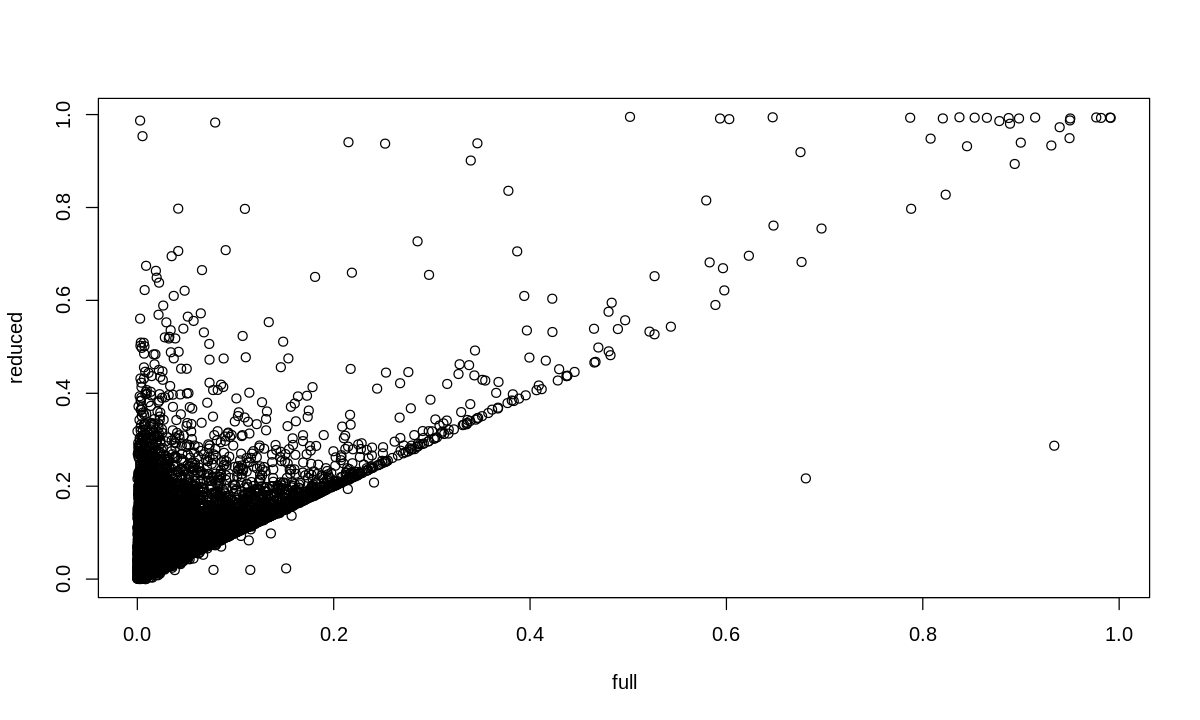

In [1028]:
plot(testRes_multiVar[,26],as.numeric(testRes_multiVar2[,24]),xlab = "full",ylab = "reduced")

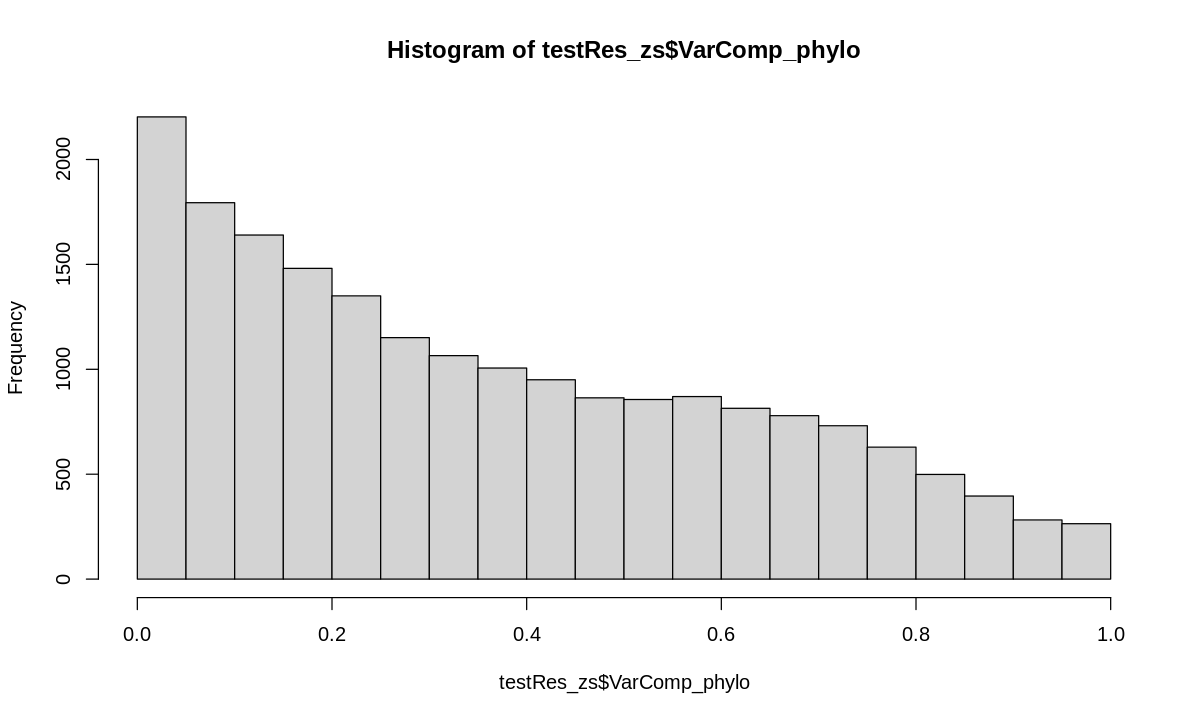

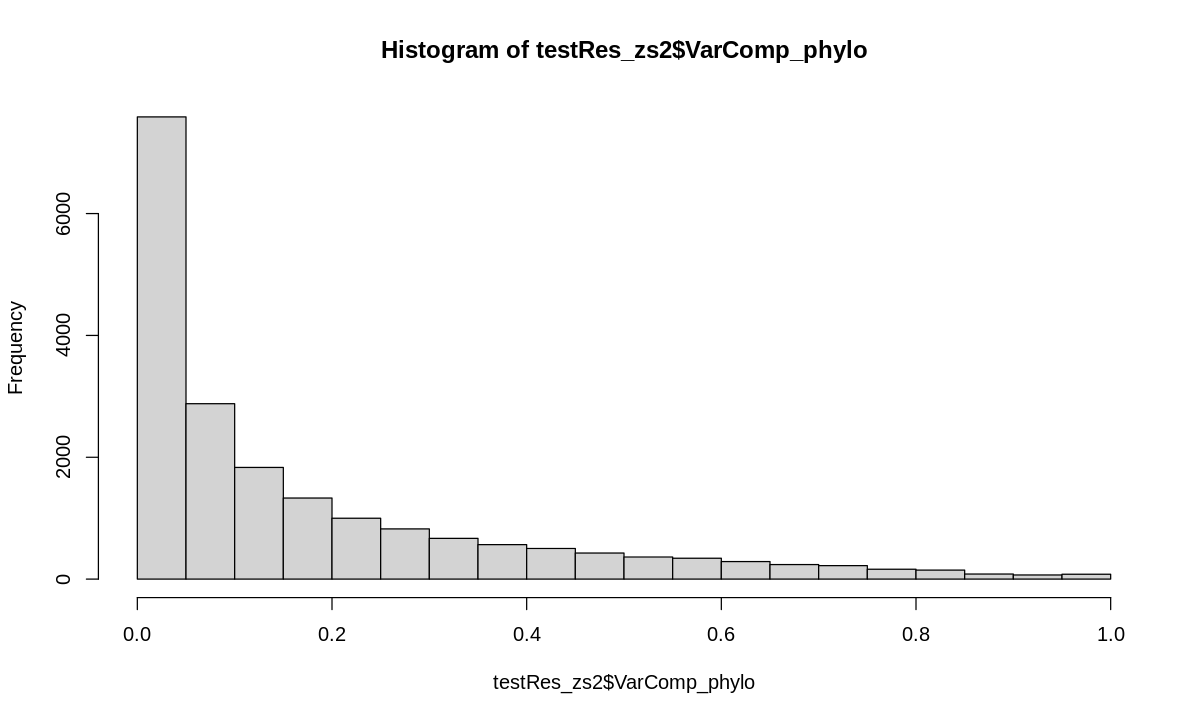

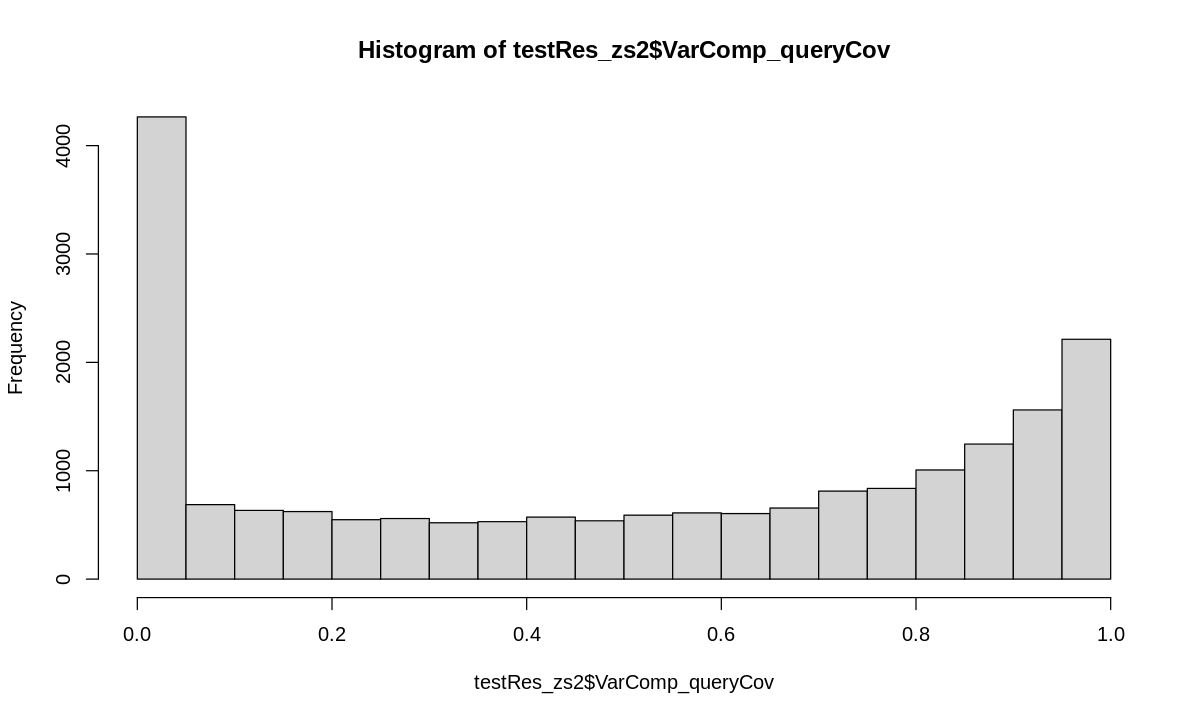

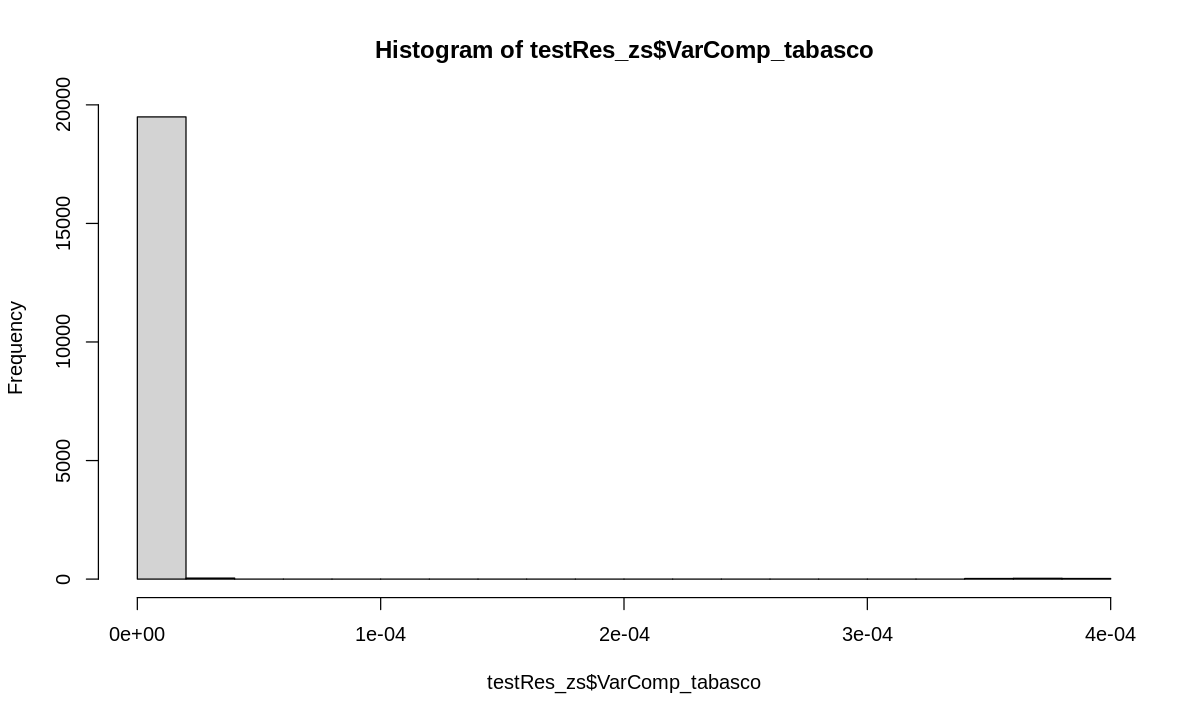

In [1117]:
hist(testRes_zs$VarComp_phylo)
hist(testRes_zs2$VarComp_phylo)
hist(testRes_zs2$VarComp_queryCov)
hist(testRes_zs$VarComp_tabasco)

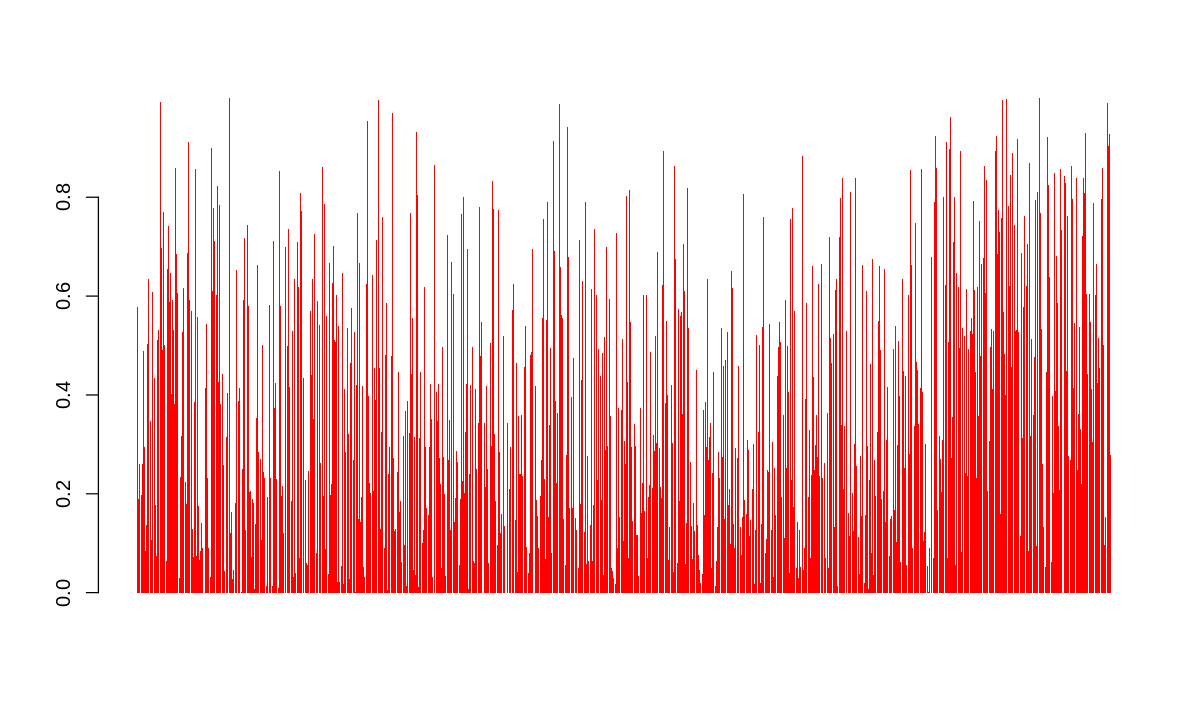

In [1239]:
options(repr.plot.width=10, repr.plot.height=6)
barplot(t(as.matrix(testRes_zs[,23],nrow(testRes_zs),2)),legend.text = T,border = NA,col = c("red","blue"))

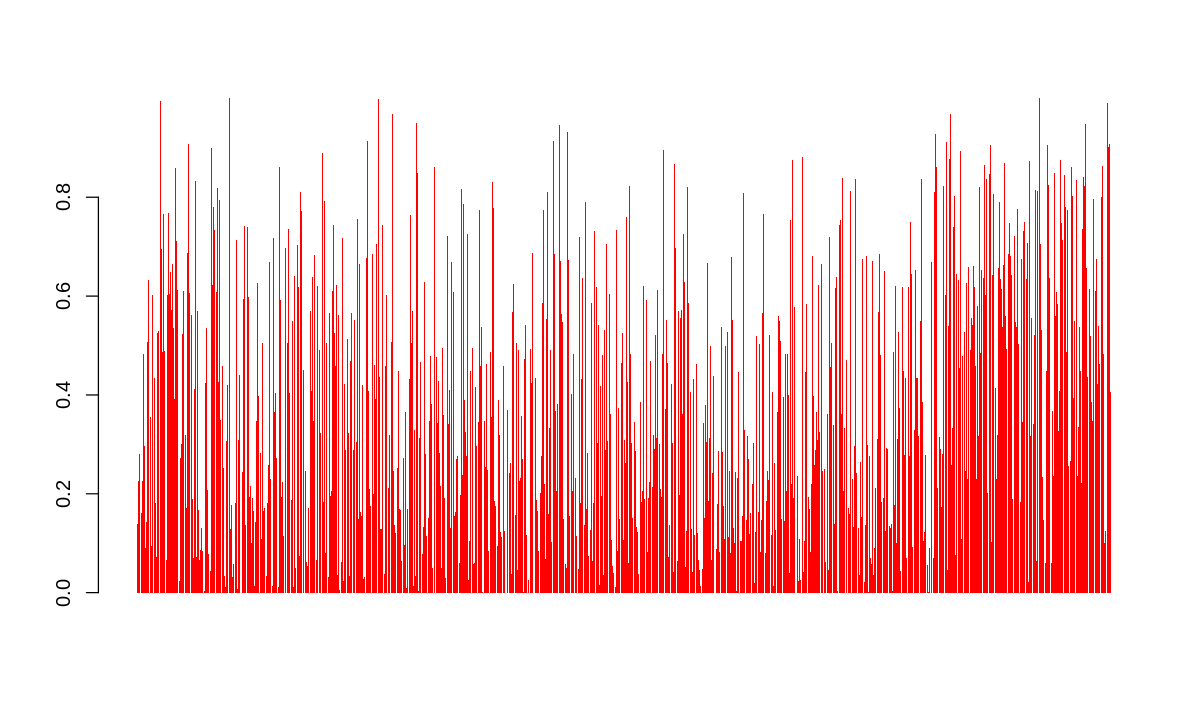

In [1240]:
barplot(t(as.matrix(testRes_zs2[,23],nrow(testRes_zs2),4)),legend.text = T,border = NA,col = c("red","yellow","orange","blue"))

In [1254]:
table((as.numeric(testRes_zs[,24])-as.numeric(testRes_zs2[,24]))>0)


FALSE  TRUE 
 3602 16021 

[1] "residual"

In [1243]:
cor(as.numeric(testRes_zs2[,23]),as.numeric(testRes_zs[,23]))

[1] 0.9598677

[1] 0.6664793

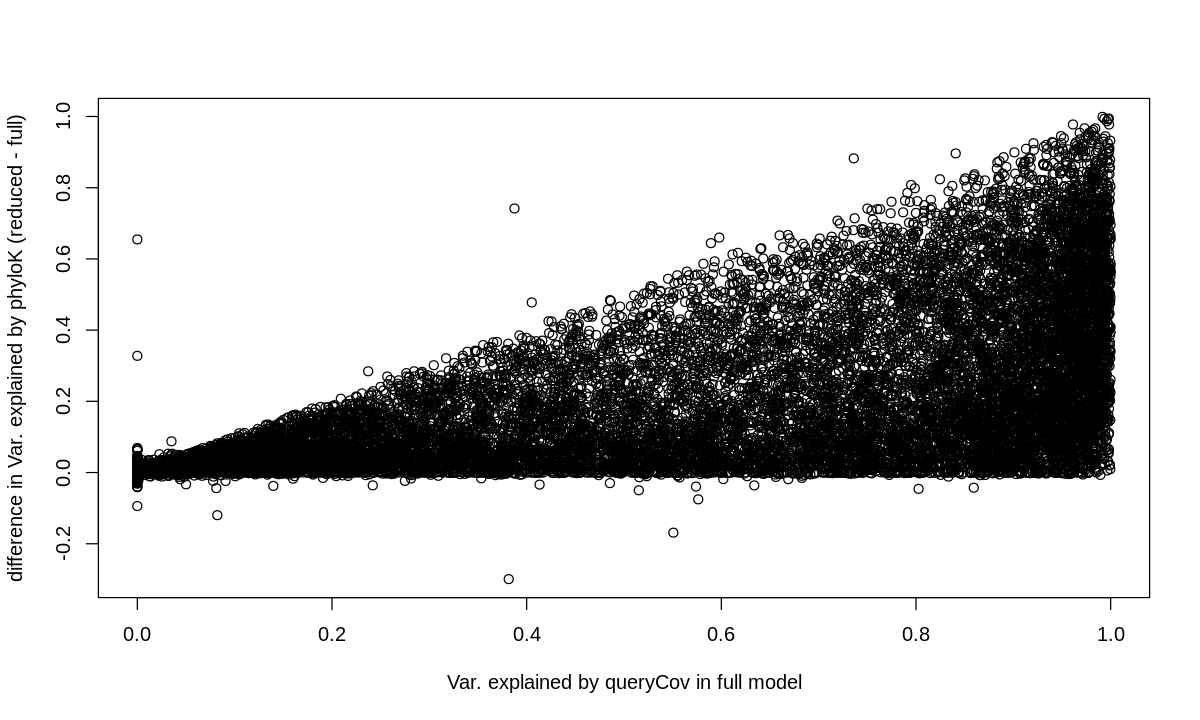

In [1141]:
cor(testRes_zs2[,24],testRes_zs[testRes_zs$OG%in%testRes_zs2$OG,24]-testRes_zs2[,26])
plot(testRes_zs2[,24],testRes_zs[testRes_zs$OG%in%testRes_zs2$OG,24]-testRes_zs2[,26],
     xlab = "Var. explained by queryCov in full model",
     ylab = "difference in Var. explained by phyloK (reduced - full)")

[1] 0.06432763

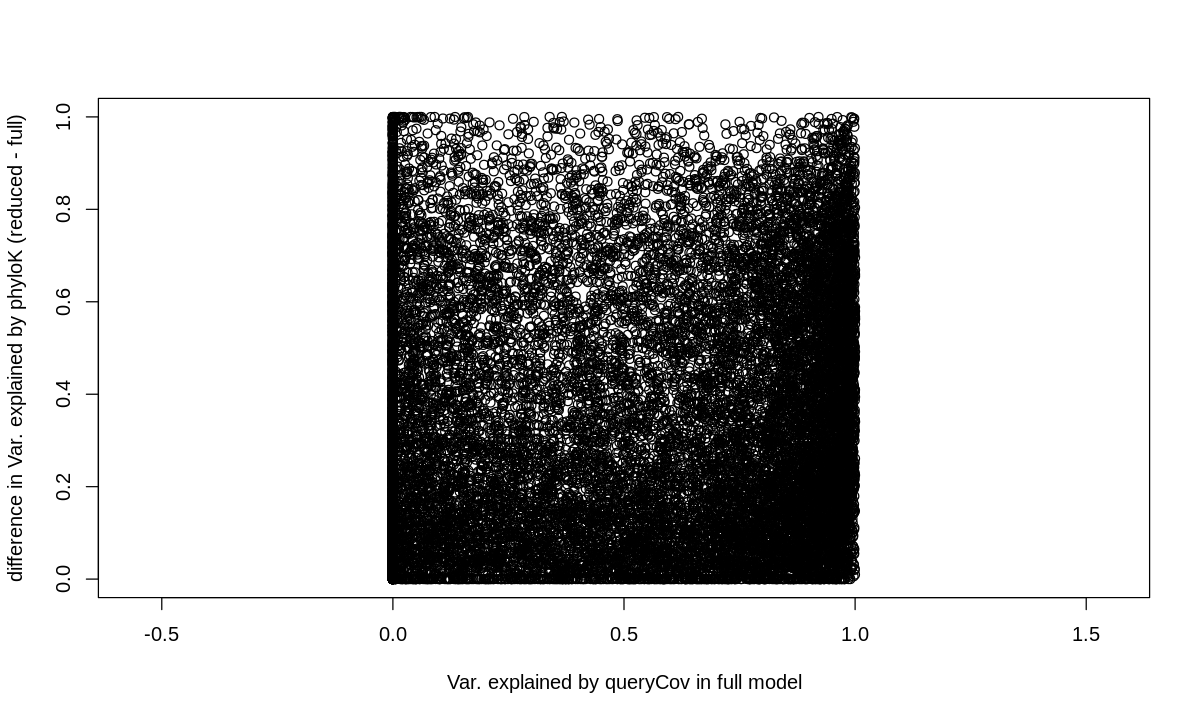

In [1139]:
cor(testRes_zs2[,24],testRes_zs[testRes_zs$OG%in%testRes_zs2$OG,24]-testRes_zs2[,23])
plot(testRes_zs2[,24],testRes_zs[testRes_zs$OG%in%testRes_zs2$OG,24]-testRes_zs2[,23],
     xlab = "Var. explained by queryCov in full model",ylab = "difference in Var. explained by phyloK (reduced - full)",
     asp = 1)

In [1102]:
dim(testRes_zs2)
dim(testRes_zs)

[1] 19614    28

[1] 19624    36

In [1052]:
mean(testRes_zs$VarComp_phylo)
mean(testRes_dnds$VarComp_phylo)
mean(testRes_zs_dna$VarComp_phylo)

[1] 0.3605445

[1] 0.5846718

[1] 0.4442233

In [1063]:
summary(tapply(testData_merged$scaledScore,testData_merged$OG,var))
summary(tapply(testData_merged$scaledScore_DNA,testData_merged$OG,var))
summary(tapply(testData_merged$scaled.dn.ds,testData_merged$OG,var))

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
0.03525 0.96753 1.00919 0.99543 1.04164 8.72896 

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max.    NA's 
0.01535 0.87379 0.93985 0.90557 0.98450 5.47099     243 

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
      1       1       1       1       1       1 

In [969]:
table(testData_merged$zeroShotScore > 2,testData_merged$queryCov > 0.5)
cor(testData_merged$zeroShotScore,testData_merged$queryCov,use="complete")

       
           FALSE     TRUE
  FALSE     6146   149766
  TRUE    699325 15380399

[1] 0.1130355

In [406]:
sapply(ls(), function(x) object.size(get(x)))

androK               avgZS_perTaxa 
                    2240744                       60800 
                     bg_RAO                    commonID 
                     155592                       57072 
                     compDF                     contTab 
                    1774168                        1216 
               df_collapsed                     envData 
                    4795984                     2066768 
                      envDf                      ePCIdx 
                    2127344                         208 
                       ePCs            eTraits_filtered 
                    2749856                     2075864 
                      exptd                      fg_RAO 
                     156696                        1496 
                  fit_model             fit_model_bio01 
                      30328                       30160 
         fit_model_bio01_zs             fit_model_bio12 
                      30160                       30160 
             fit_model_ePC1              fit_model_ePC2 
                      30160                       30160 
               fit_model_zs            fit_model_zs_dna 
                     134192                       36472 
                      fullK                fullK_subset 
                    4723184                     4723184 
                          i                           j 
                         56                          56 
                mappingFile                mappingFile2 
                    3144944                     3061648 
          mappingFileMerged                    metadata 
                    4782856                      339176 
                  model_tmp                       mycol 
                     553976                      137344 
                        obs                     OG_list 
                         56                     1413048 
                     phyloK               phyloK_subset 
                      13240                     4765800 
                  phyloKMat             plotTraitOnTree 
                    5117768                      164448 
                     pr_RAO                        pval 
                     473576                          56 
                        RAO                        rIdx 
                      24496                         704 
                    roc_RAO                        rsig 
                     473232                       49312 
                      spTre                spTre.rooted 
                     114560                      114536 
      spTre.rooted.filtered spTre.rooted.filtered.andro 
                     108888                       76192 
                    TABASCO              taxanomicGroup 
                      74056                      137968 
                       test                    testData 
                       4080                  5779520488 
            testData_merged                  testRes_zs 
                48491895432                     9663520 
           testRes_zs_andro                   tip_order 
                    9646272                       57072 
                 tip_order2                         tmp 
                      38576                        1024 
                     tmpCol                   tmpCutoff 
                     137472                         280 
                 tmpCutoff1                  tmpCutoff2 
                        280                         280 
                    tmpData                 tmpData_ebs 
                     961176                     3012032 
               tmpData_gdsl                tmpData_LEA3 
                    2808536                     2702448 
                tmpData_pap                    tooSmall 
                    2759104                       22144 
                     topVar                varExplained 
                         96                         176 
              varExplained1    

# Env. Variance explained by phyloK

In [177]:
library(ape)
library(ggtree)
library(geiger)



Attaching package: ‘ape’


The following objects are masked from ‘package:graph’:

    complement, degree, edges


The following object is masked from ‘package:dplyr’:

    where


Registered S3 methods overwritten by 'treeio':
  method              from    
  MRCA.phylo          tidytree
  MRCA.treedata       tidytree
  Nnode.treedata      tidytree
  Ntip.treedata       tidytree
  ancestor.phylo      tidytree
  ancestor.treedata   tidytree
  child.phylo         tidytree
  child.treedata      tidytree
  full_join.phylo     tidytree
  full_join.treedata  tidytree
  groupClade.phylo    tidytree
  groupClade.treedata tidytree
  groupOTU.phylo      tidytree
  groupOTU.treedata   tidytree
  is.rooted.treedata  tidytree
  nodeid.phylo        tidytree
  nodeid.treedata     tidytree
  nodelab.phylo       tidytree
  nodelab.treedata    tidytree
  offspring.phylo     tidytree
  offspring.treedata  tidytree
  parent.phylo        tidytree
  parent.treedata     tidytree
  root.treedata       tidyt

In [178]:
# load tree
spTre = read.tree("/workdir/sh2246/p_phyloGWAS/output/PoaceaeTree_angiosperm353_astral.nwk")
spTre.rooted = root(spTre,"ASM1935983v1")
spTre.rooted$edge.length[is.na(spTre.rooted$edge.length)] = 0.1

In [179]:
commonID = intersect(spTre.rooted$tip.label,rownames(ePCs$environmental.features))
eTraits_filtered = as.data.frame(ePCs$environmental.features[commonID,])
spTre.rooted.filtered = keep.tip(spTre.rooted,commonID)

In [271]:
source("/workdir/sh2246/p_phyloGWAS/src/S01_phyloK.R")

Warning message in file(file, "r"):
“cannot open file '/home/sh2246/Dropbox/postDoc/projects/p_phyloGWAS/data/test/test.tree.newick': No such file or directory”


ERROR: Error in file(file, "r"): cannot open the connection


In [150]:
envDf$assemblyID = as.factor(envDf$assemblyID)

In [183]:
fullK = phyloK(spTre.rooted.filtered)

In [184]:
fullK_subset <- fullK[rownames(fullK) %in% envDf$assemblyID,]
fullK_subset <- fullK_subset[,colnames(fullK_subset) %in% envDf$assemblyID]

In [1294]:
asreml.options(verbose = FALSE)
varExplained1 = c()
model_tmp <- asreml(fixed = envPC_1 ~ envPC_2 + envPC_3 + envPC_4 + envPC_5 + envPC_6 + envPC_7 + envPC_8 + envPC_9 + envPC_10,
                random = ~ vm(assemblyID, fullK_subset), ai.sing = TRUE, data = envDf)
varExplained1 = c(varExplained1,summary(model_tmp)$varcomp[1,1]/sum(summary(model_tmp)$varcomp[,1]))
model_tmp <- asreml(fixed = envPC_2 ~ envPC_1 + envPC_3 + envPC_4 + envPC_5 + envPC_6 + envPC_7 + envPC_8 + envPC_9 + envPC_10,
                random = ~ vm(assemblyID, fullK_subset), ai.sing = TRUE, data = envDf)
varExplained1 = c(varExplained1,summary(model_tmp)$varcomp[1,1]/sum(summary(model_tmp)$varcomp[,1]))
model_tmp <- asreml(fixed = envPC_3 ~ envPC_1 + envPC_2 + envPC_4 + envPC_5 + envPC_6 + envPC_7 + envPC_8 + envPC_9 + envPC_10,
                random = ~ vm(assemblyID, fullK_subset), ai.sing = TRUE, data = envDf)
varExplained1 = c(varExplained1,summary(model_tmp)$varcomp[1,1]/sum(summary(model_tmp)$varcomp[,1]))
model_tmp <- asreml(fixed = envPC_4 ~ envPC_2 + envPC_3 + envPC_1 + envPC_5 + envPC_6 + envPC_7 + envPC_8 + envPC_9 + envPC_10,
                random = ~ vm(assemblyID, fullK_subset), ai.sing = TRUE, data = envDf)
varExplained1 = c(varExplained1,summary(model_tmp)$varcomp[1,1]/sum(summary(model_tmp)$varcomp[,1]))

ASReml Version 4.2 25/10/2024 15:02:41
          LogLik        Sigma2     DF     wall
 1     -194.1172     0.5440194    749   15:02:41
 2     -164.3849     0.4931366    749   15:02:41
 3     -122.5517     0.4219579    749   15:02:41
 4     -78.28829     0.3433787    749   15:02:41
 5     -43.12232     0.2690210    749   15:02:41
 6     -28.72353     0.2220940    749   15:02:41
 7     -24.76079     0.1962385    749   15:02:41
 8     -24.02931     0.1843957    749   15:02:42
 9     -23.93630     0.1799926    749   15:02:42
10     -23.92710     0.1785829    749   15:02:42
11     -23.92629     0.1781618    749   15:02:42
ASReml Version 4.2 25/10/2024 15:02:42
          LogLik        Sigma2     DF     wall
 1     -342.9921     0.8100095    749   15:02:42
 2     -321.2936     0.7466046    749   15:02:42
 3     -291.5413     0.6553757    749   15:02:42
 4     -265.7126     0.5628454    749   15:02:43
 5     -250.3342     0.4817451    749   15:02:43
 6     -246.4421     0.4376176    749   15:0

In [1295]:
varExplained1

[1] 0.9009030 0.7899996 0.7050339 0.6196001

In [140]:
envDf$assemblyID = as.factor(envDf$assemblyID)

In [141]:
model_tmp <- asreml(fixed = envPC_1 ~ 1,
                random = ~ vm(assemblyID, phyloKMat), ai.sing = TRUE, data = envDf)


ASReml Version 4.2 30/10/2024 13:44:29
          LogLik        Sigma2     DF     wall
 1     -228.8043     0.6414226    758   13:44:29
 2     -208.2341     0.5960414    758   13:44:29
 3     -175.4816     0.5219847    758   13:44:30
 4     -137.8600     0.4321187    758   13:44:30
 5     -108.1583     0.3475589    758   13:44:30
 6     -96.17042     0.2958701    758   13:44:30
 7     -92.86257     0.2684107    758   13:44:30
 8     -92.24004     0.2561706    758   13:44:30
 9     -92.15551     0.2515746    758   13:44:30
10     -92.14610     0.2500280    758   13:44:30
11     -92.14514     0.2495324    758   13:44:30


In [142]:
summary(model_tmp)$varcomp

,component,std.error,z.ratio,bound,%ch
,<dbl>,<dbl>,<dbl>,<chr>,<dbl>
"vm(assemblyID, phyloKMat)",2.0862223,0.28229469,7.390229,P,0.2
units!R,0.2495324,0.01824003,13.680482,P,0.0


In [146]:
(var(envDf$envPC_1)-0.2495324)/var(envDf$envPC_1)

[1] 0.7479201

In [1338]:
var(envDf$envPC_4)

[1] 1.004693

In [186]:
taxanomicGroup = read.csv("/workdir/sh2246/p_phyloGWAS/data/Poaceae_taxonomic_groups.csv",header = T)

In [187]:
head(taxanomicGroup)

,assemblyID,Species,clade,subfamily,tribe
,<chr>,<chr>,<chr>,<chr>,<chr>
1,ASM2160514v1,Aegilops bicornis,BOP,Pooideae,Triticeae
2,Aegilops_cylindrica,Aegilops cylindrica,BOP,Pooideae,Triticeae
3,SRR2219562,Aegilops geniculata,BOP,Pooideae,Triticeae
4,ASM2160520v1,Aegilops longissima,BOP,Pooideae,Triticeae
5,aegilops_longissima_6782_assembly,Aegilops longissima,BOP,Pooideae,Triticeae
6,Aegilops_markgrafii,Aegilops markgrafii,BOP,Pooideae,Triticeae


In [188]:
table(taxanomicGroup$subfamily)
table(taxanomicGroup$tribe)


Anomochlooideae   Arundinoideae    Bambusoideae   Chloridoideae      Oryzoideae 
              1               4              24              33              38 
    Panicoideae      Pharoideae        Pooideae 
            598               1             106 


  Andropogoneae   Arundinarieae       Bambuseae   Brachypodieae         Bromeae 
            556              11              10               7               3 
    Cynodonteae   Eragrostideae       Molinieae         Olyreae         Oryzeae 
             20               4               4               3              38 
       Paniceae       Paspaleae         Phareae           Poeae         Stipeae 
             39               3               1              45               1 
Streptochaeteae    Triraphideae       Triticeae        Zoysieae 
              1               1              50               8 

In [189]:
spTre.rooted.filtered.andro = keep.tip(spTre.rooted,intersect(taxanomicGroup[taxanomicGroup[,5] == "Andropogoneae",1],commonID))

In [828]:
head(taxanomicGroup)

,assemblyID,Species,clade,subfamily,tribe
,<chr>,<chr>,<chr>,<chr>,<chr>
1,ASM2160514v1,Aegilops bicornis,BOP,Pooideae,Triticeae
2,Aegilops_cylindrica,Aegilops cylindrica,BOP,Pooideae,Triticeae
3,SRR2219562,Aegilops geniculata,BOP,Pooideae,Triticeae
4,ASM2160520v1,Aegilops longissima,BOP,Pooideae,Triticeae
5,aegilops_longissima_6782_assembly,Aegilops longissima,BOP,Pooideae,Triticeae
6,Aegilops_markgrafii,Aegilops markgrafii,BOP,Pooideae,Triticeae


In [170]:
table(metadata$lifeHistory)
nrow(metadata)


             annual annual or perennial           perennial 
                253                   7                 513 

[1] 807

In [836]:
table(metadata$lifeHistory[grep("PacBio",metadata$technology,ignore.case = T)])


             annual annual or perennial           perennial 
                 72                   1                  78 

In [833]:
table(taxanomicGroup[,5][taxanomicGroup[,1]%in%metadata[grep("PacBio",metadata$technology,ignore.case = T),1]])


Andropogoneae     Bambuseae Brachypodieae       Bromeae   Cynodonteae 
           54             1             1             3            11 
Eragrostideae     Molinieae       Oryzeae      Paniceae     Paspaleae 
            3             3            19            21             3 
      Phareae         Poeae       Stipeae     Triticeae      Zoysieae 
            1            11             1            19             2 

In [865]:
table(metadata[grep("PacBio",metadata$technology,ignore.case = T),]$lifeHistory[metadata[grep("PacBio",metadata$technology,ignore.case = T),1]%in%taxanomicGroup[taxanomicGroup[,5] == "Andropogoneae",1]])


   annual perennial 
       19        33 

In [866]:
table(metadata[grep("PacBio",metadata$technology,ignore.case = T),]$lifeHistory[metadata[grep("PacBio",metadata$technology,ignore.case = T),1]%in%taxanomicGroup[taxanomicGroup[,5] == "Paniceae",1]])


   annual perennial 
       12         9 

In [880]:
metadata[grep("PacBio",metadata$technology,ignore.case = T),1]

[1] "Aet_v5.0"                             
  [2] "ASM3246443v1"                         
  [3] "ASEM_AUS1_V1.0"                       
  [4] "TAN1-04B"                             
  [5] "RSA5-3"                               
  [6] "ZAM1505-10"                           
  [7] "Alomy_genome_v1"                      
  [8] "DE01087.PacbioCLRassembly"            
  [9] "Ab-Traiperm_572-DRAFT-PanAnd-1.0"     
 [10] "Ac-Pasquet1232-DRAFT-PanAnd-1.0"      
 [11] "Ag-CAM1351-DRAFT-PanAnd-1.0"          
 [12] "Av-Kellogg1287_8-REFERENCE-PanAnd-1.0"
 [13] "RSPBVictoria1.0"                      
 [14] "Bl-K1279B-DRAFT-PanAnd-1.0"           
 [15] "Bhybridum_463_v1.0"                   
 [16] "lpBroSter1.1"                         
 [17] "lpBroSter1.1_alternate_haplotype"     
 [18] "Bromus_tectorum"                      
 [19] "ASM2073952v1"                         
 [20] "ASM2073957v1"                         
 [21] "ASM3693692v1"                         
 [22] "Cs-KelloggPI219580-DRAFT-PanAnd-1.0"  
 [23] "ASM972507v1"                          
 [24] "ASM976338v1"                          
 [25] "Adlay_draft_genome_1.0"               
 [26] "Cc-PI314907-DRAFT-PanAnd-1.0"         
 [27] "Cr-AUB069-DRAFT-PanAnd-1.0"           
 [28] "ASM711570v1"                          
 [29] "mabamboo_1.0"                         
 [30] "DiExil"                               
 [31] "ASM2511822v1"                         
 [32] "ASM3323972v1"                         
 [33] "Eleusine_coracana_v1.0"               
 [34] "Ragi_PR202_v._2.0"                    
 [35] "ASM3037835v1"                         
 [36] "ASM3041176v1"                         
 [37] "Et-Layton_Zhong168-DRAFT-PanAnd-1.0"  
 [38] "CERZOS_EC1.0"                         
 [39] "MSU_Enin_2.1"                         
 [40] "Salk_teff_dabbi_3.0"                  
 [41] "Festuca_brevipila"                    
 [42] "Hp-KelloggPI404118-DRAFT-PanAnd-1.0"  
 [43] "Hc-AUB53_1-DRAFT-PanAnd-1.0"          
 [44] "FB19_011_3"                           
 [45] "A17"                                  
 [46] "FB19_001_1"                           
 [47] "FB19_028_3"                           
 [48] "A42"                                  
 [49] "ASM2249601v1"                         
 [50] "Hvulgare_HOR_13663_BPGv2"             
 [51] "Hvulgare_HOR_4224_BPGv2"              
 [52] "Hvulgare_HOR_19184_BPGv2"             
 [53] "Hvulgare_FT262_BPGv2"                 
 [54] "Ir-Pasquet1136-DRAFT-PanAnd-1.0"      
 [55] "ASM2203655v1"                         
 [56] "ASM1932011v1"                         
 [57] "lpNeoColu1.0.hap1"                    
 [58] "lpNeoColu1.0.hap2"                    
 [59] "Oropetium_capense"                    
 [60] "Oropetium_genomic_20141112"           
 [61] "ObarRS3"                              
 [62] "ObraRS2"                              
 [63] "ASM3077008v1"                         
 [64] "OcoaRS1"                              
 [65] "OglaRS2"                              
 [66] "OgluRS3"                              
 [67] "ASM980554v1"                          
 [68] "OmerRS3"                              
 [69] "ASM155179v1"                          
 [70] "ASM399144v1"                          
 [71] "OnivRS2"                              
 [72] "OpunRS2"                              
 [73] "O._rufipogonIRGC106523RS1"            
 [74] "ASM155180v1"                          
 [75] "ZS97RS3"                              
 [76] "AzucenaRS1"                           
 [77] "Os132424RS1"                          
 [78] "Os132278RS1"                          
 [79] "PHallii_v3.1"                         
 [80] "PhalliiHAL_v2.1"                      
 [81] "BC332"                                
 [82] "BC477"                                
 [83] "BC404"                                
 [84] "BC382"                                
 [85] "BC100"                                
 [86] "P.virgatum_v5"                        
 [87] "ASM2253091v1"                         


In [835]:
metadata[grep("PacBio",metadata$technology,ignore.case = T),][metadata[grep("PacBio",metadata$technology,ignore.case = T),1]%in%taxanomicGroup[taxanomicGroup[,5] == "Andropogoneae",1],]

,assemblyID,tracker_sample_name,correctSpecies,CorrectEcotype,Species,genotype_info,altName,lifeHistory,technology,source,notes
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
46,Ab-Traiperm_572-DRAFT-PanAnd-1.0,NA,Andropogon burmanicus,Traiperm_572,Andropogon burmanicus,NA,NA,perennial,PacBio,PanAnd,
50,Ac-Pasquet1232-DRAFT-PanAnd-1.0,NA,Andropogon chinensis,Pasquet1232,Andropogon chinensis,NA,NA,perennial,PacBio,PanAnd,
64,Ag-CAM1351-DRAFT-PanAnd-1.0,NA,Andropogon gerardii,CAM1351,Andropogon gerardii,NA,NA,perennial,PacBio,PanAnd,
105,Av-Kellogg1287_8-REFERENCE-PanAnd-1.0,NA,Anatherum virginicum,Kellogg1287,Anatherum virginicum,NA,Andropogon virginicus,perennial,PacBio,PanAnd,
168,Bl-K1279B-DRAFT-PanAnd-1.0,NA,Bothriochloa laguroides,K1279B,Bothriochloa laguroides,NA,NA,perennial,PacBio,PanAnd,
218,Cs-KelloggPI219580-DRAFT-PanAnd-1.0,NA,Chrysopogon serrulatus,Kellogg PI219580,Chrysopogon serrulatus,NA,NA,perennial,PacBio,PanAnd,
225,ASM972507v1,NA,Coix aquatica,Daheishan,Coix aquatica,Daheishan,NA,annual,PacBio Sequel,NCBI,
227,ASM976338v1,NA,Coix lacryma-jobi,lacryma-jobi_BJ,Coix lacryma-jobi,lacryma-jobi_BJ,NA,annual,Illumina HiSeq; PacBio RSII; PacBio Sequel,NCBI,
228,Adlay_draft_genome_1.0,NA,Coix lacryma-jobi,ma-yuen_Johyun,Coix lacryma-jobi,ma-yuen_Johyun,NA,annual,PacBio RSII,NCBI,


In [871]:
metadata[grep("PacBio",metadata$technology,ignore.case = T),][metadata[grep("PacBio",metadata$technology,ignore.case = T),1]%in%taxanomicGroup[taxanomicGroup[,5] == "Poeae",1],]

,assemblyID,tracker_sample_name,correctSpecies,CorrectEcotype,Species,genotype_info,altName,lifeHistory,technology,source,notes
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
24,Alomy_genome_v1,NA,Alopecurus myosuroides,Rothamsted,Alopecurus myosuroides,Rothamsted,NA,annual,PacBio Sequel,NCBI,
25,DE01087.PacbioCLRassembly,NA,Alopecurus myosuroides,NA,Alopecurus myosuroides,NA,NA,annual,PacBio Sequel I,NCBI,
142,RSPBVictoria1.0,NA,Avena sativa,Victoria,Avena sativa,Victoria,NA,annual,PacBio,NCBI,
255,ASM711570v1,NA,Dactylis glomerata,Dgl,Dactylis glomerata,Dgl,NA,perennial,PacBio Sequel,NCBI,
341,Festuca_brevipila,NA,Festuca brevipila,NA,Festuca brevipila,NA,NA,perennial,Pacbio,CoGE,
547,FRR_PoAnn_1.0,NA,Poa annua,MN234,Poa annua,MN234,NA,annual,PacBio RSII,NCBI,
548,Poa_infirma,NA,Poa infirma,NA,Poa infirma,NA,NA,annual,Pacbio,CoGE,
549,Pp-Kellogg1297-DRAFT-PanAnd-1.0,NA,Poa pratensis,Angustifolia,Poa pratensis,Angustifolia,NA,perennial,PacBio,PanAnd,
550,Poa_pratensis_v1,NA,Poa pratensis,NA,Poa pratensis,NA,NA,perennial,PacBio SEQUEL; Bionano,NCBI,


In [928]:
table(grepl("PacBio",metadata$technology,ignore.case = T),metadata$lifeHistory)

       
        annual annual or perennial perennial
  FALSE    181                   6       435
  TRUE      72                   1        78

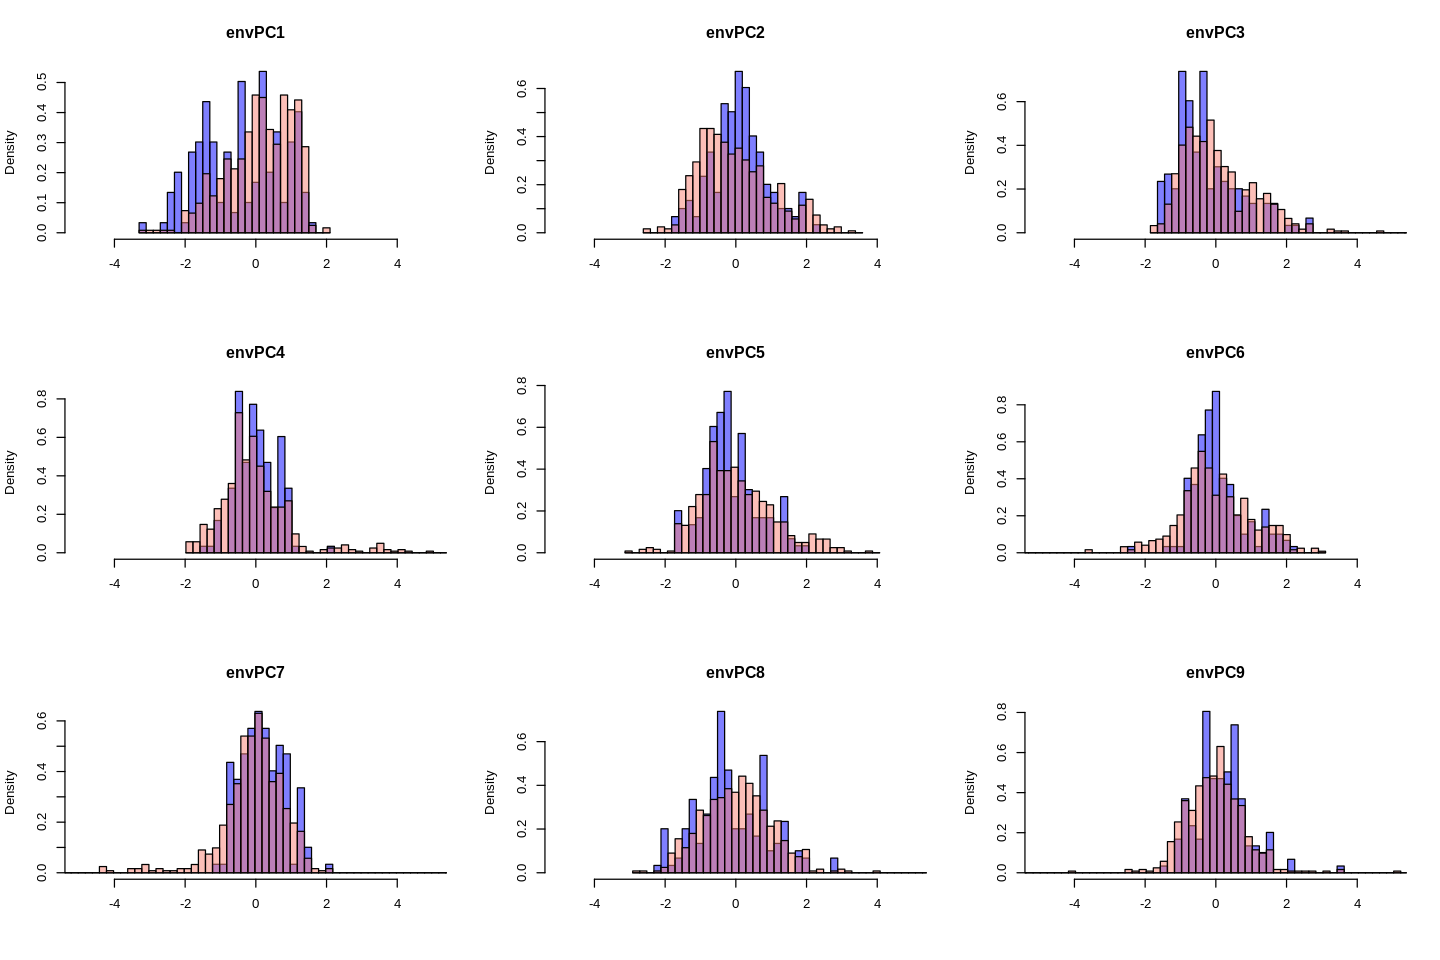

In [926]:
options(repr.plot.width=12, repr.plot.height=8)

par(mfrow = c(3,3))
for (i in 1:9){
    hist(envData[metadata[grep("PacBio",metadata$technology,ignore.case = T),1],285+i], 
         col = alpha("blue",.5),main = paste0("envPC",i),xlab = "",xlim = c(-5,5),
         breaks = seq(min(envData[,285+i])-.01,max(envData[,285+i])*1.1,0.2),freq = F)
    hist(envData[metadata[-grep("PacBio",metadata$technology,ignore.case = T),1],285+i],
         add = T, col = alpha("salmon",.5),
         breaks = seq(min(envData[,285+i])-.01,max(envData[,285+i])*1.1,0.2),freq = F)
}


In [862]:
summary(envData[,285+i])
max(envData[,285+i])
seq(min(envData[,285+i])-.01,max(envData[,285+i])*1.1,by = 0.1)

     Min.   1st Qu.    Median      Mean   3rd Qu.      Max. 
-3.292110 -0.661530  0.132420  0.008446  0.847225  2.057440 

[1] 2.05744

[1] -3.30211 -3.20211 -3.10211 -3.00211 -2.90211 -2.80211 -2.70211 -2.60211
 [9] -2.50211 -2.40211 -2.30211 -2.20211 -2.10211 -2.00211 -1.90211 -1.80211
[17] -1.70211 -1.60211 -1.50211 -1.40211 -1.30211 -1.20211 -1.10211 -1.00211
[25] -0.90211 -0.80211 -0.70211 -0.60211 -0.50211 -0.40211 -0.30211 -0.20211
[33] -0.10211 -0.00211  0.09789  0.19789  0.29789  0.39789  0.49789  0.59789
[41]  0.69789  0.79789  0.89789  0.99789  1.09789  1.19789  1.29789  1.39789
[49]  1.49789  1.59789  1.69789  1.79789  1.89789  1.99789  2.09789  2.19789

In [922]:
cont_tab = table(grepl("pacbio",testData_merged$technology,ignore.case = T),testData_merged$PMS)
cont_tab
fisher.test(cont_tab)
cont_tab[,2]/rowSums(cont_tab)

       
               0        1
  FALSE 11324484   616276
  TRUE   4059959   234917


	Fisher's Exact Test for Count Data

data:  cont_tab
p-value < 2.2e-16
alternative hypothesis: true odds ratio is not equal to 1
95 percent confidence interval:
 1.058062 1.068480
sample estimates:
odds ratio 
  1.063256 


FALSE       TRUE 
0.05161112 0.05469704

FALSE      TRUE 
0.1386234 0.1584419

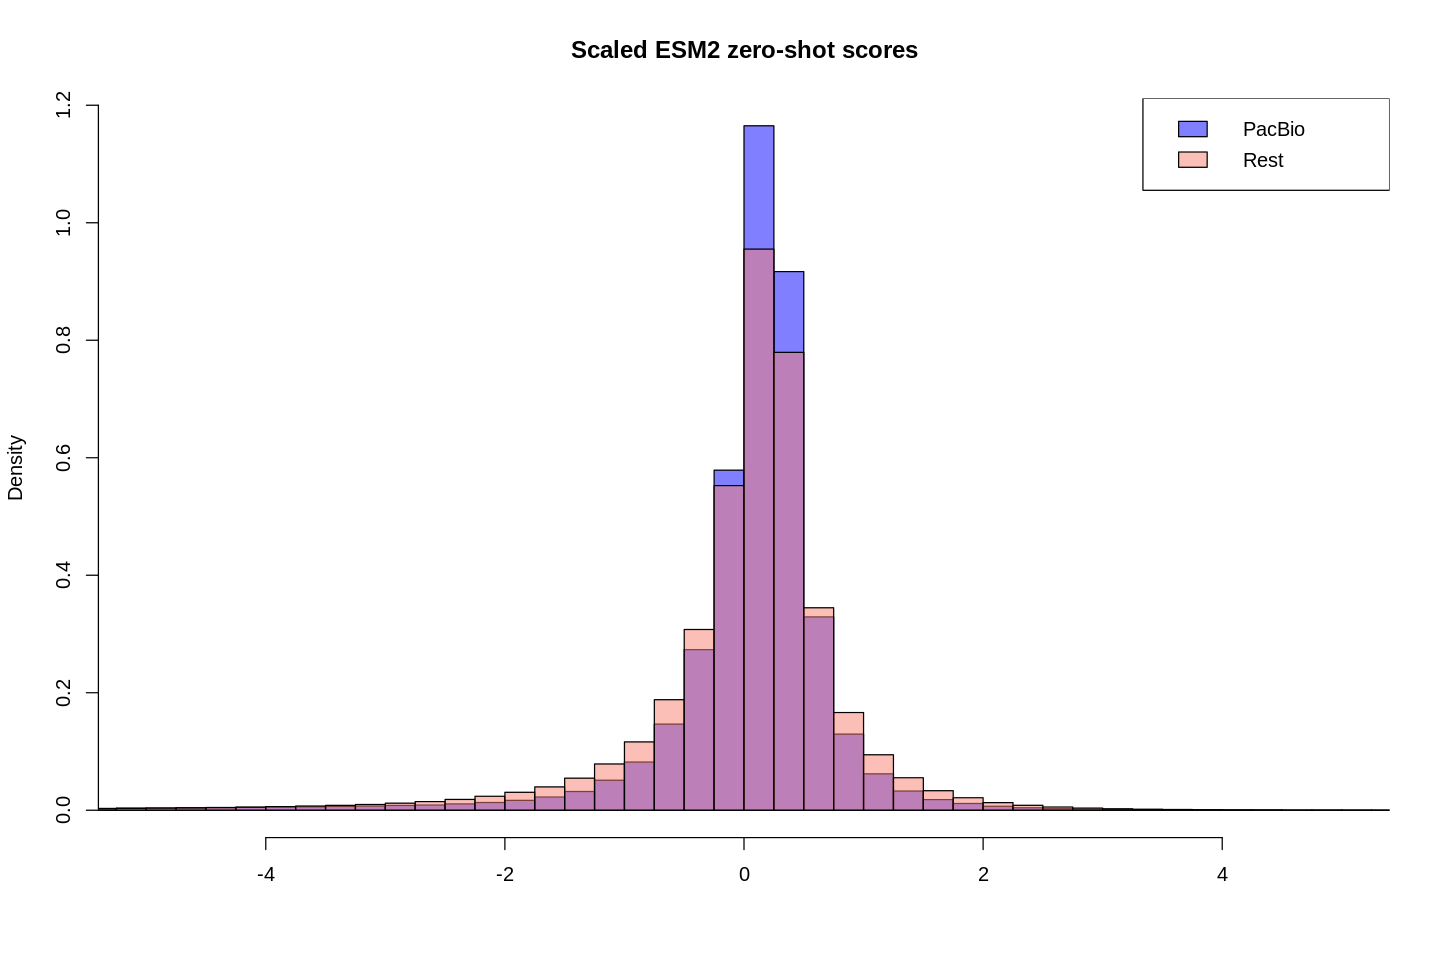

In [919]:
hist(testData_merged$scaledScore[grepl("pacbio",testData_merged$technology,ignore.case = T)],freq = F,
     col = alpha("blue",.5),breaks = seq(-40,30,.25),xlim = c(-5,5),
     main = "Scaled ESM2 zero-shot scores",xlab= "")
hist(testData_merged$scaledScore[!grepl("pacbio",testData_merged$technology,ignore.case = T)],freq = F,add = T,
     col = alpha("salmon",.5),breaks = seq(-60,30,.25))
legend("topright",fill = alpha(c("blue","salmon"),.5),legend = c("PacBio","Rest"))
tapply(testData_merged$scaledScore,grepl("pacbio",testData_merged$technology,ignore.case = T),median)

FALSE        TRUE 
-0.04164193 -0.14713828

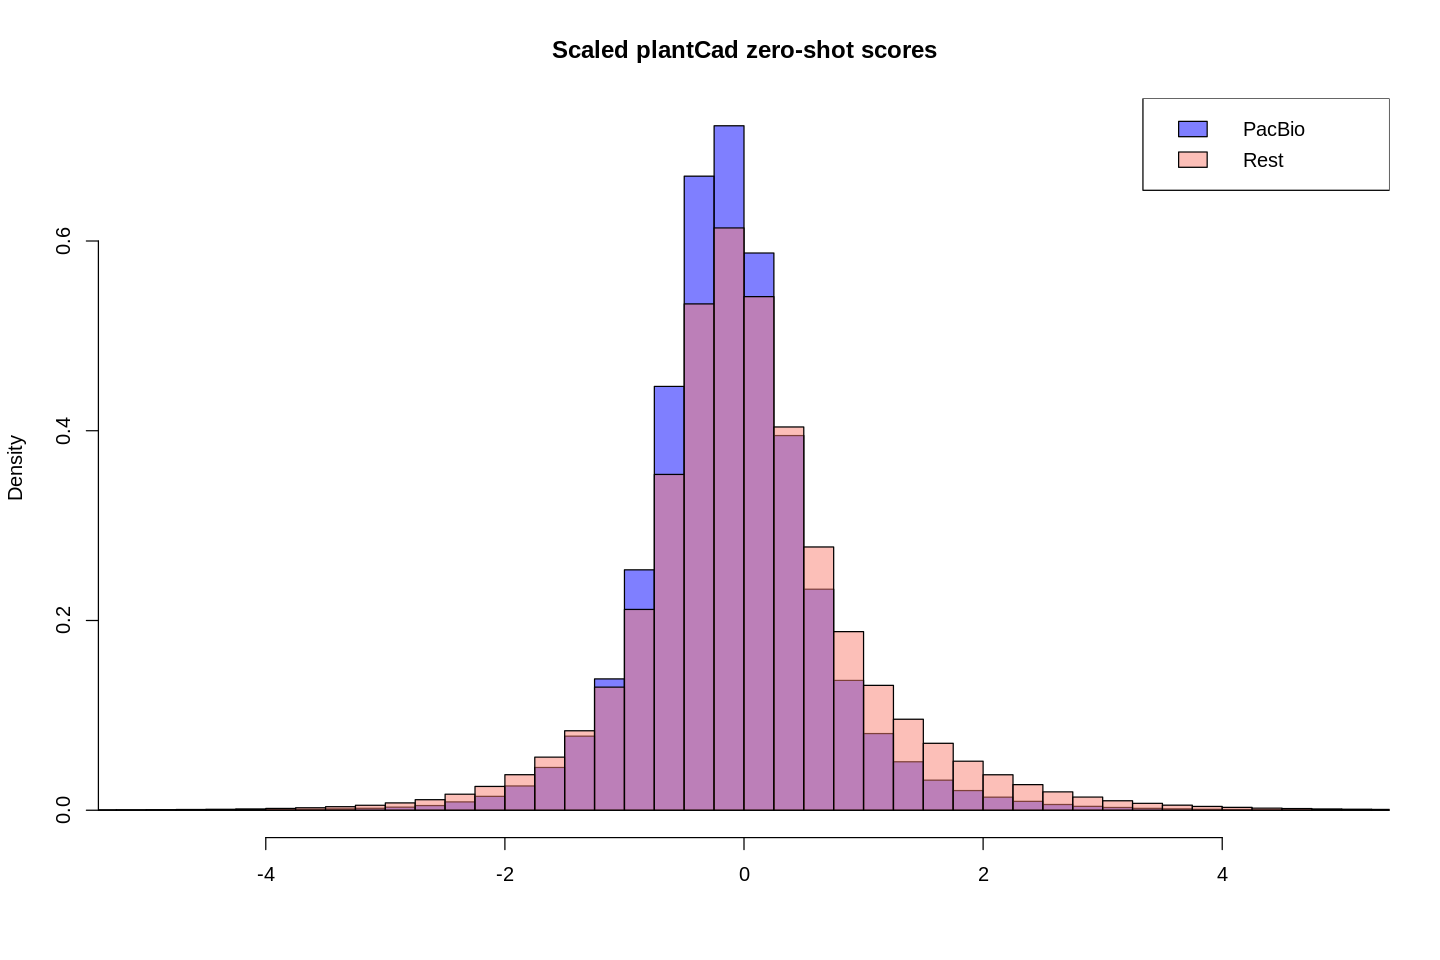

In [920]:
hist(testData_merged$scaledScore_DNA[grepl("pacbio",testData_merged$technology,ignore.case = T)],freq = F,
     col = alpha("blue",.5),breaks = seq(-40,30,.25),xlim = c(-5,5),
     main = "Scaled plantCad zero-shot scores",xlab = "")
hist(testData_merged$scaledScore_DNA[!grepl("pacbio",testData_merged$technology,ignore.case = T)],freq = F,add = T,
     col = alpha("salmon",.5),breaks = seq(-60,30,.25))
legend("topright",fill = alpha(c("blue","salmon"),.5),legend = c("PacBio","Rest"))
tapply(testData_merged$scaledScore_DNA,grepl("pacbio",testData_merged$technology,ignore.case = T),median,na.rm = T)

1         2 
0.1571319 0.1384463

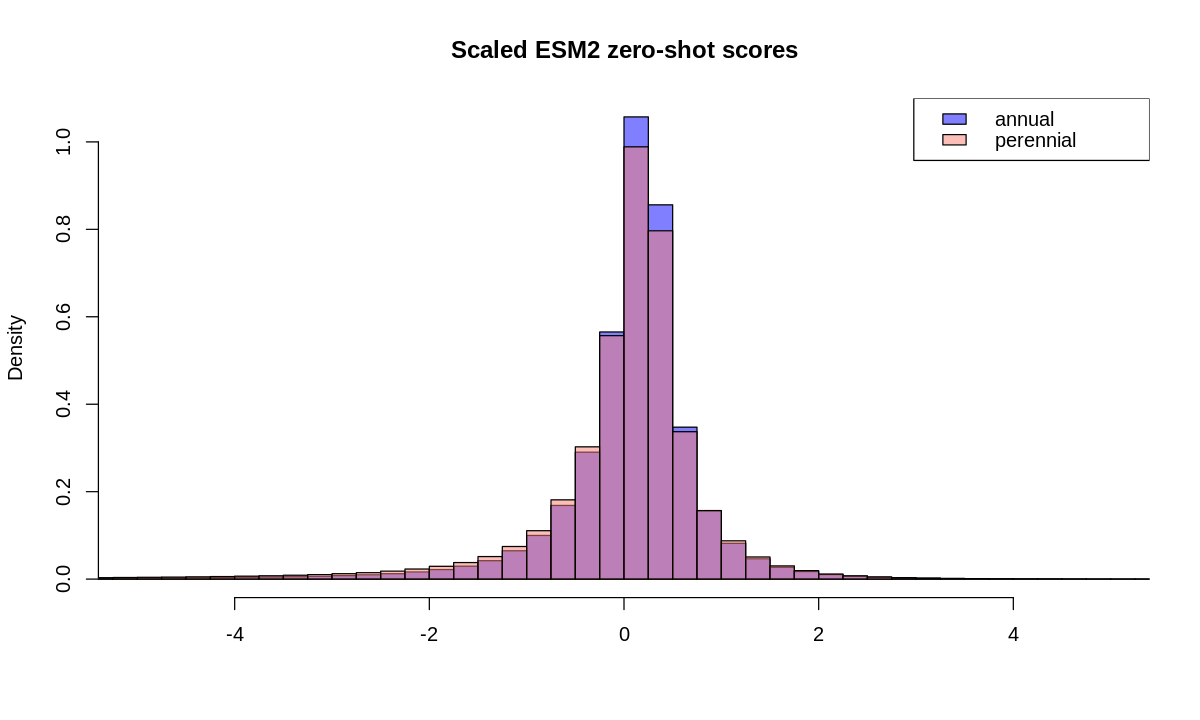

In [1210]:
hist(testData_merged$scaledScore[testData_merged$lifeHistoryNumeric==1],freq = F,
     col = alpha("blue",.5),breaks = seq(-40,30,.25),xlim = c(-5,5),
     main = "Scaled ESM2 zero-shot scores",xlab = "")
hist(testData_merged$scaledScore[testData_merged$lifeHistoryNumeric==2],freq = F,add = T,
     col = alpha("salmon",.5),breaks = seq(-60,30,.25))
legend("topright",fill = alpha(c("blue","salmon"),.5),legend = c("annual","perennial"))
tapply(testData_merged$scaledScore,testData_merged$lifeHistoryNumeric,median,na.rm = T)

1           2 
-0.12744170 -0.04715556

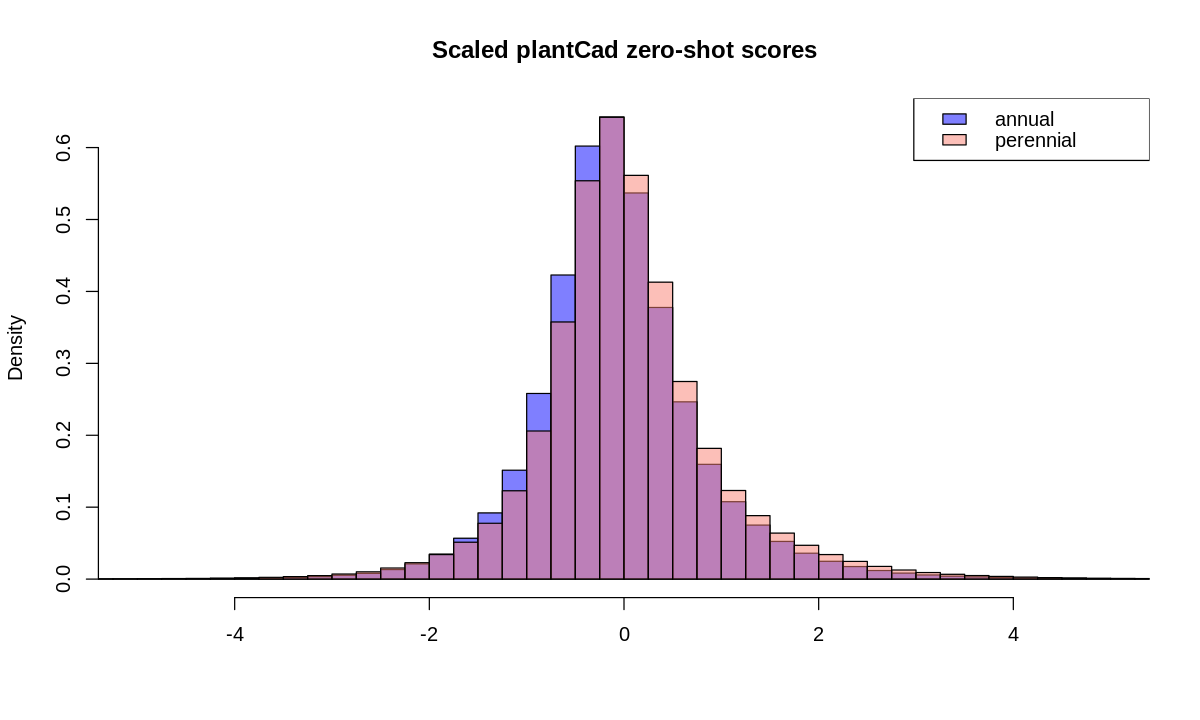

In [1209]:
hist(testData_merged$scaledScore_DNA[testData_merged$lifeHistoryNumeric==1],freq = F,
     col = alpha("blue",.5),breaks = seq(-40,30,.25),xlim = c(-5,5),
     main = "Scaled plantCad zero-shot scores",xlab = "")
hist(testData_merged$scaledScore_DNA[testData_merged$lifeHistoryNumeric==2],freq = F,add = T,
     col = alpha("salmon",.5),breaks = seq(-60,30,.25))
legend("topright",fill = alpha(c("blue","salmon"),.5),legend = c("annual","perennial"))
tapply(testData_merged$scaledScore_DNA,testData_merged$lifeHistoryNumeric,median,na.rm = T)

FALSE      TRUE 
0.1553069 0.1720560

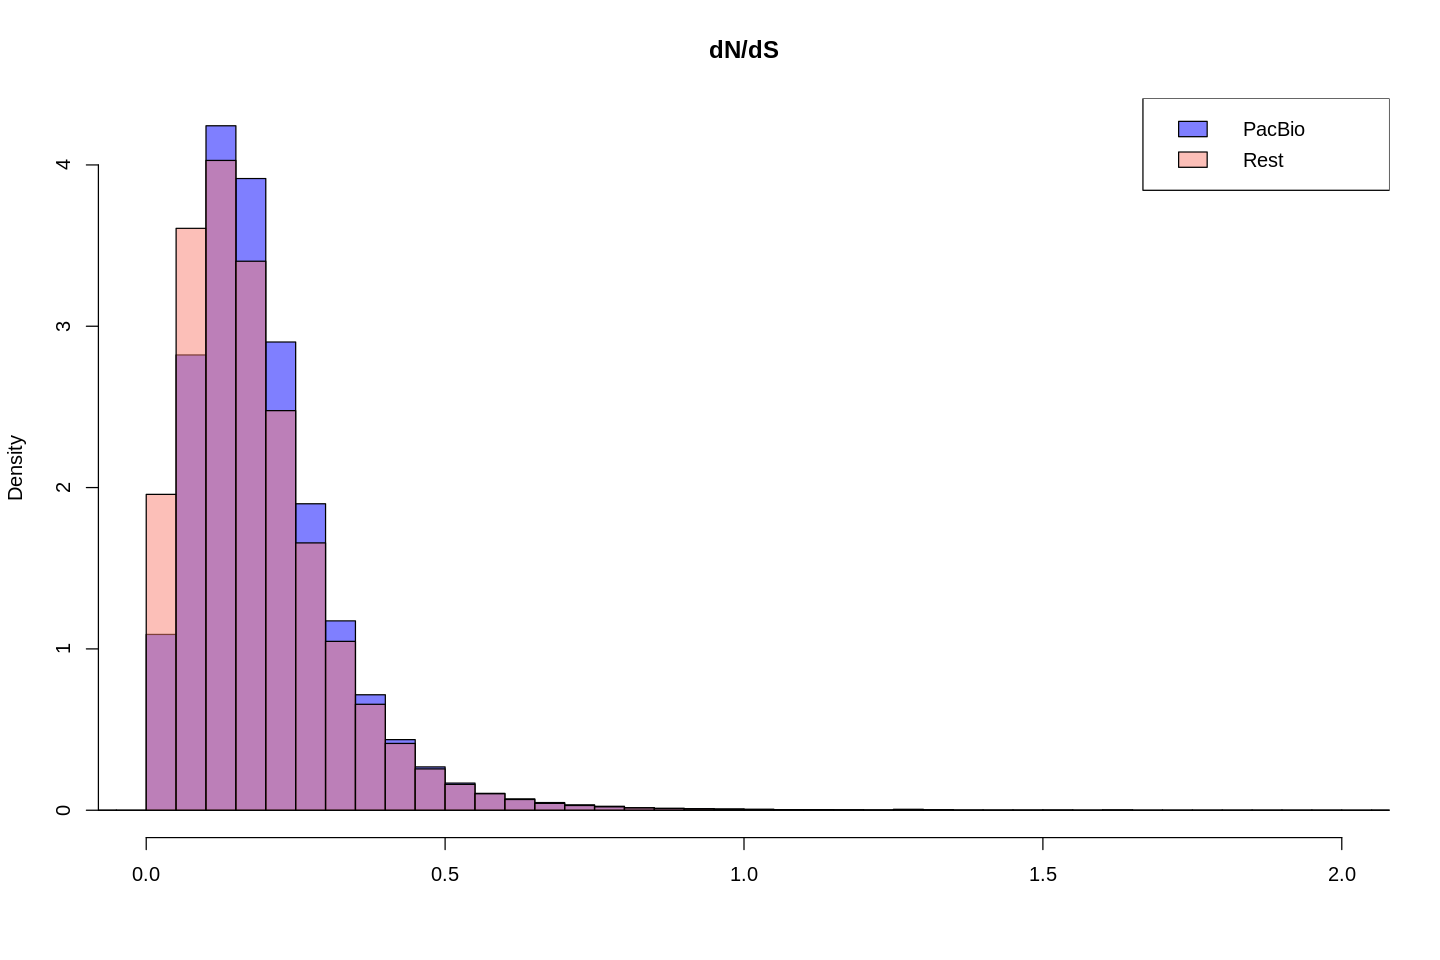

In [921]:
hist(testData_merged$dn.ds[grepl("pacbio",testData_merged$technology,ignore.case = T)],freq = F,
     col = alpha("blue",.5),breaks = seq(-40,30,.05),xlim = c(0,2),
     main = "dN/dS",xlab = "")
hist(testData_merged$dn.ds[!grepl("pacbio",testData_merged$technology,ignore.case = T)],freq = F,add = T,
     col = alpha("salmon",.5),breaks = seq(-60,30,.05))
legend("topright",fill = alpha(c("blue","salmon"),.5),legend = c("PacBio","Rest"))
tapply(testData_merged$dn.ds,grepl("pacbio",testData_merged$technology,ignore.case = T),median)

In [908]:
gc()

,used,(Mb),gc trigger,(Mb),max used,(Mb)
Ncells,27020748,1443.1,74490060,3978.2,93112574,4972.8
Vcells,10570462998,80646.3,29392793357,224249.3,26354445001,201068.5


In [900]:
summary(testData_merged$scaledScore)

     Min.   1st Qu.    Median      Mean   3rd Qu.      Max. 
-57.71597  -0.19071   0.14471  -0.00459   0.38820  29.91821 

In [190]:
androK = phyloK(spTre.rooted.filtered.andro)

In [191]:
varExplained2 = c()
model_tmp <- asreml(fixed = envPC_1 ~ envPC_2 + envPC_3 + envPC_4 + envPC_5 + envPC_6 + envPC_7 + envPC_8 + envPC_9 + envPC_10,
                random = ~ vm(assemblyID, androK), ai.sing = TRUE, data = envDf[rownames(androK),])
varExplained2 = c(varExplained2,summary(model_tmp)$varcomp[1,2]/sum(summary(model_tmp)$varcomp[,2]))
model_tmp <- asreml(fixed = envPC_2 ~ envPC_1 + envPC_3 + envPC_4 + envPC_5 + envPC_6 + envPC_7 + envPC_8 + envPC_9 + envPC_10,
                random = ~ vm(assemblyID, androK), ai.sing = TRUE, data = envDf[rownames(androK),])
varExplained2 = c(varExplained2,summary(model_tmp)$varcomp[1,2]/sum(summary(model_tmp)$varcomp[,2]))
model_tmp <- asreml(fixed = envPC_3 ~ envPC_1 + envPC_2 + envPC_4 + envPC_5 + envPC_6 + envPC_7 + envPC_8 + envPC_9 + envPC_10,
                random = ~ vm(assemblyID, androK), ai.sing = TRUE, data = envDf[rownames(androK),])
varExplained2 = c(varExplained2,summary(model_tmp)$varcomp[1,2]/sum(summary(model_tmp)$varcomp[,2]))
model_tmp <- asreml(fixed = envPC_4 ~ envPC_2 + envPC_3 + envPC_1 + envPC_5 + envPC_6 + envPC_7 + envPC_8 + envPC_9 + envPC_10,
                random = ~ vm(assemblyID, androK), ai.sing = TRUE, data = envDf[rownames(androK),])
varExplained2 = c(varExplained2,summary(model_tmp)$varcomp[1,2]/sum(summary(model_tmp)$varcomp[,2]))

ASReml Version 4.2 16/09/2024 14:50:03
          LogLik        Sigma2     DF     wall
 1     -54.47663     0.3786454    510   14:50:03
 2     -48.57932     0.3588608    510   14:50:03
 3     -40.64791     0.3278912    510   14:50:03
 4     -34.15907     0.2944270    510   14:50:03
 5     -30.64397     0.2643829    510   14:50:03
 6     -29.81973     0.2486049    510   14:50:04
 7     -29.69787     0.2421698    510   14:50:04
 8     -29.68518     0.2400326    510   14:50:04
 9     -29.68407     0.2393964    510   14:50:04
ASReml Version 4.2 16/09/2024 14:50:04
          LogLik        Sigma2     DF     wall
 1     -213.9138     0.7084448    510   14:50:04
 2     -207.8579     0.6727293    510   14:50:04
 3     -200.7637     0.6216253    510   14:50:04
 4     -195.7906     0.5697995    510   14:50:04
 5     -193.5873     0.5259028    510   14:50:04
 6     -193.2726     0.5074489    510   14:50:04
 7     -193.2538     0.5026773    510   14:50:04
 8     -193.2532     0.5018189    510   14:5

In [192]:
varExplained2

[1] 0.7886865 0.7395381 0.7050602 0.6317960

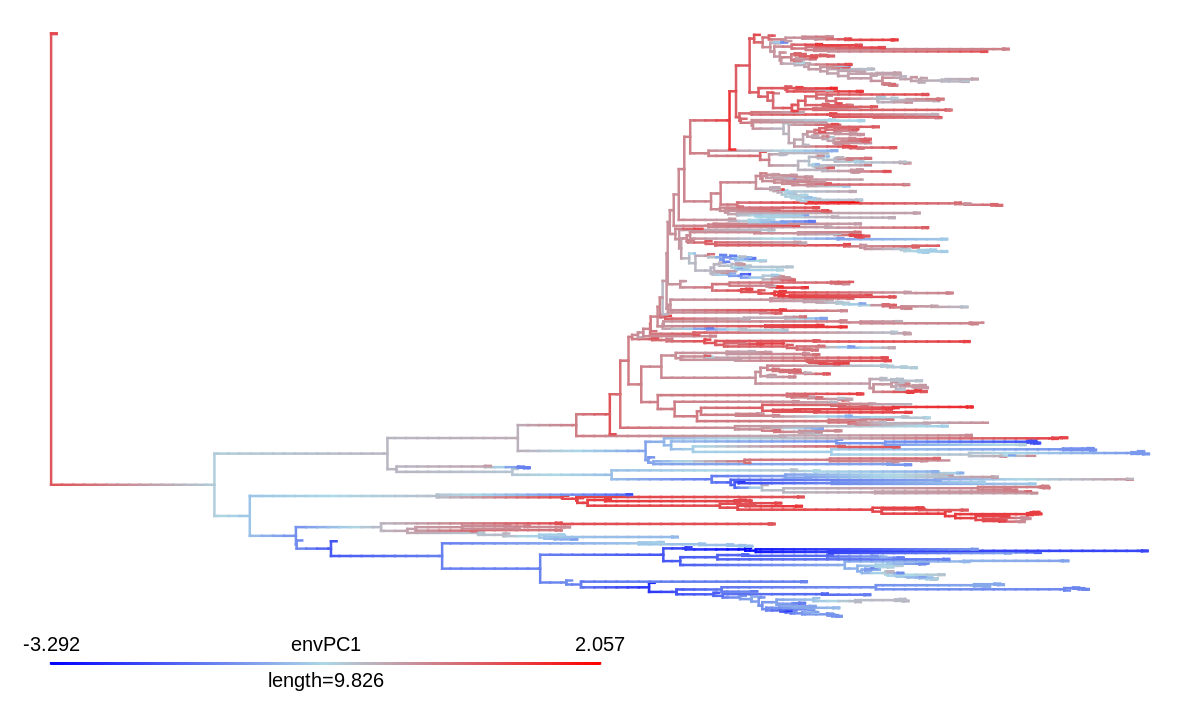

In [193]:
plotTraitOnTree(envDf$envPC_1,
                commonID,spTre.rooted.filtered,visible_tip_labels = F,
                legend.title = "envPC1",col = c("blue","lightblue","red"))


In [194]:
library(pheatmap)

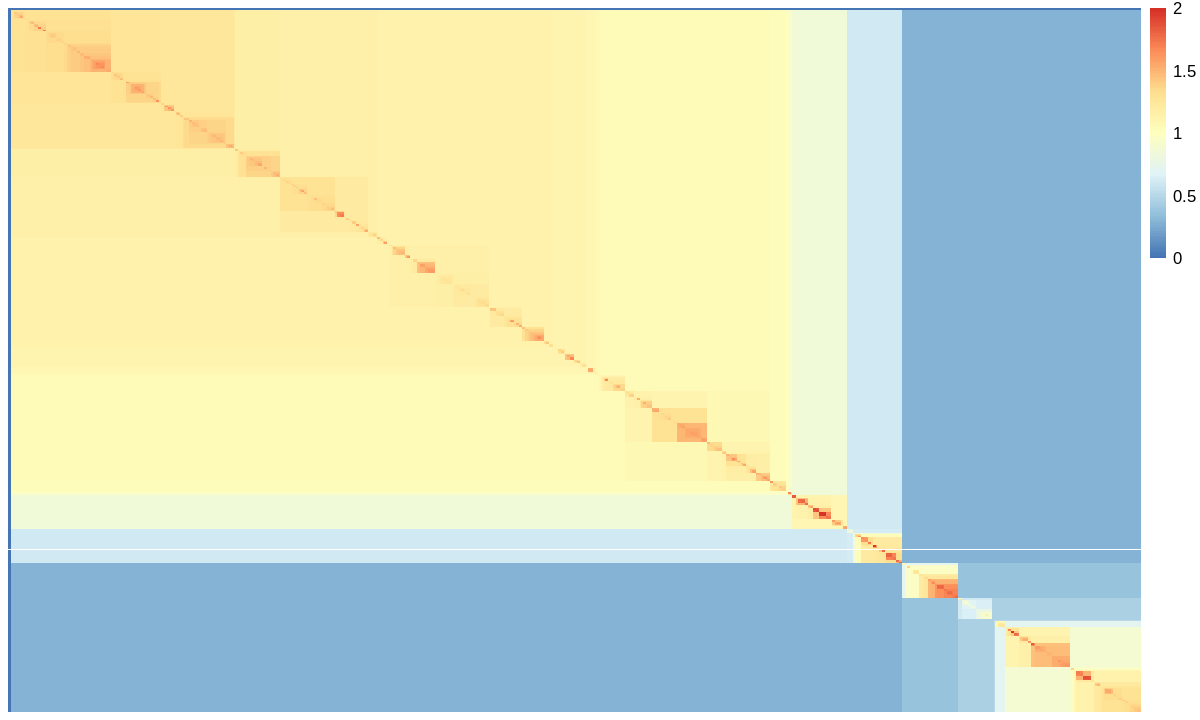

In [195]:
tip_order <- spTre.rooted.filtered$tip.label[spTre.rooted.filtered$edge[spTre.rooted.filtered$edge[, 2] <= length(spTre.rooted.filtered$tip.label), 2]]

pheatmap(fullK[rev(tip_order),rev(tip_order)],
         cluster_rows = F,cluster_cols = F,show_rownames = F,show_colnames = F)

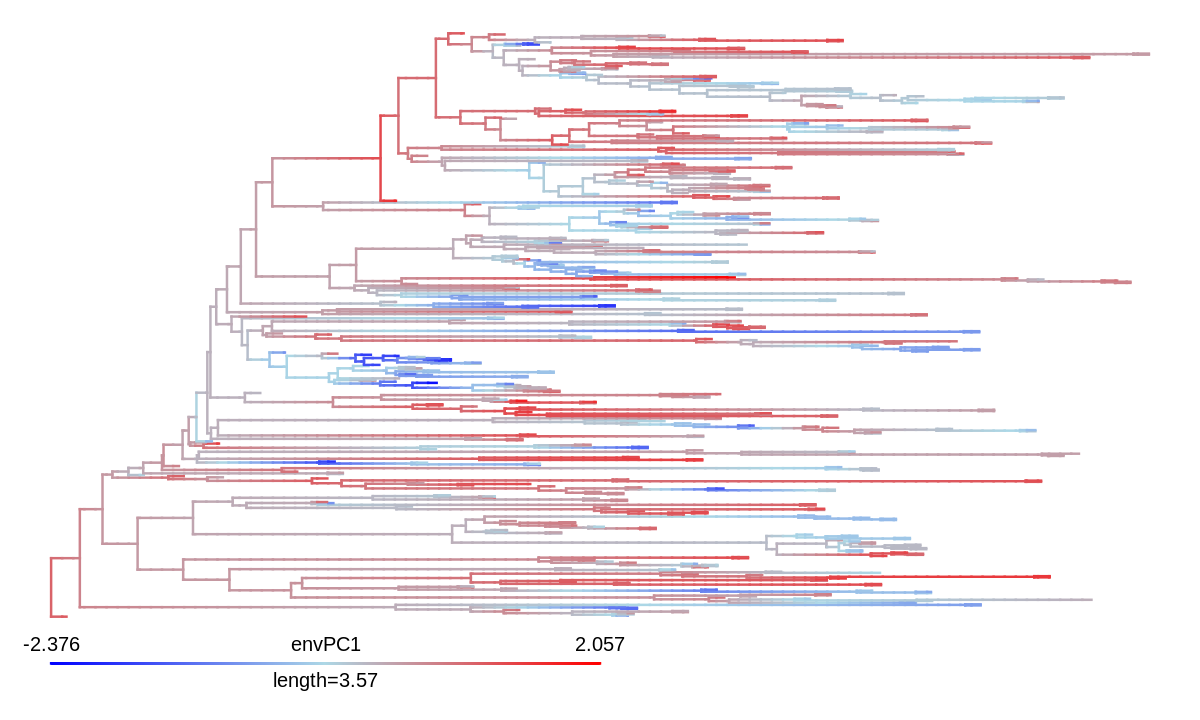

In [196]:
plotTraitOnTree(envDf[intersect(commonID,spTre.rooted.filtered.andro$tip.label),]$envPC_1,
                intersect(commonID,spTre.rooted.filtered.andro$tip.label),
                spTre.rooted.filtered.andro,visible_tip_labels = F,
                legend.title = "envPC1",col = c("blue","lightblue","red"))


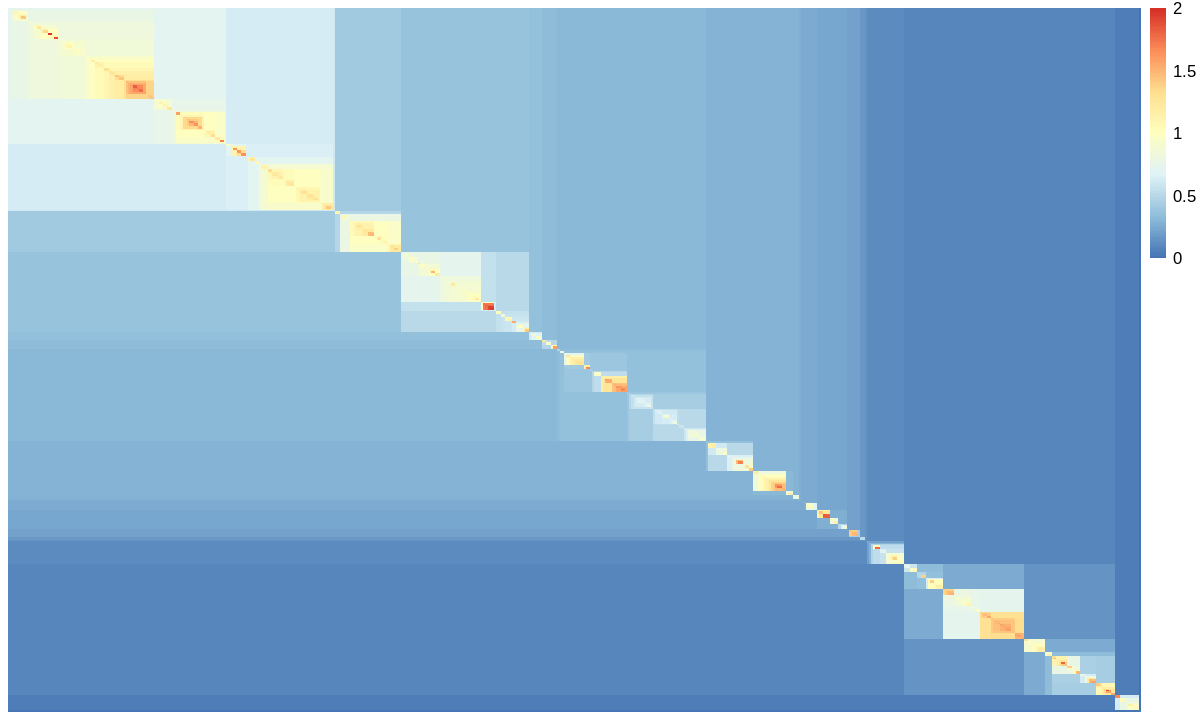

In [197]:
tip_order2 <- spTre.rooted.filtered.andro$tip.label[spTre.rooted.filtered.andro$edge[spTre.rooted.filtered.andro$edge[, 2] <= length(spTre.rooted.filtered.andro$tip.label), 2]]

pheatmap(androK[rev(tip_order2),rev(tip_order2)],
         cluster_rows = F,cluster_cols = F,show_rownames = F,show_colnames = F)

In [950]:
testData_merged_andro =  subset(testData_merged,assemblyID%in%rownames(androK))

In [951]:
gc()

,used,(Mb),gc trigger,(Mb),max used,(Mb)
Ncells,27019663,1443.1,74490060,3978.2,93112574,4972.8
Vcells,10583087415,80742.6,29392793357,224249.3,26354445001,201068.5


# andro-specific model

In [273]:
asreml.options(maxit = 30,verbose = F)
testRes_zs_andro = mclapply(OG_list,function(x) try(fit_model_zs(x,data = testData_merged_andro,androK),silent = T),mc.cores = 15)

In [275]:
testRes_zs_andro = t(simplify2array(testRes_zs_andro[sapply(testRes_zs_andro,length)==34]))

In [276]:
colnames(testRes_zs_andro) = c("OG",paste0("Coeff_envPC",1:10),paste0("Pval_envPC",1:10),"loglik","VarComp_tabasco",
                         "VarComp_phylo",paste0("VAE_envPC",1:10))
testRes_zs_andro = as.data.frame(testRes_zs_andro)
head(testRes_zs_andro)


,OG,Coeff_envPC1,Coeff_envPC2,Coeff_envPC3,Coeff_envPC4,Coeff_envPC5,Coeff_envPC6,Coeff_envPC7,Coeff_envPC8,Coeff_envPC9,⋯,VAE_envPC1,VAE_envPC2,VAE_envPC3,VAE_envPC4,VAE_envPC5,VAE_envPC6,VAE_envPC7,VAE_envPC8,VAE_envPC9,VAE_envPC10
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,⋯,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
1,OG0000062,-0.00502365543342872,0.0260155074408829,-0.0453860819690749,0.01998391891757,0.00734325471743892,0.0108625421538762,0.0116528905290204,0.00325574861669948,-0.0134615621172438,⋯,0.000221062702611529,0.0647504660131415,0.194326095177631,0.0324382852288119,0.0017925842037351,0.00935346521877611,0.00546508922396606,0.000616800946362224,0.0155697205871832,0.00844461593002937
2,OG0000098,-0.0122724976072968,0.0391437197344102,0.00994579028556352,0.052664809261759,0.00151222875570469,0.0166677289573302,-0.0119877842810152,-0.0809753163979561,0.0478687402510686,⋯,0.079522508641305,0.0144544851994358,0.00219926552978026,0.00395034716478644,0.0109429406566301,0.0173344932264856,0.0258377888162811,0.144664296535676,0.156545031750515,0.235156167069305
3,OG0000106,0.056665201730762,-0.0106408420580694,-0.0186916429053125,0.0272185118416802,0.0118829587809323,0.0266132432255043,0.00813367854999639,0.00490127187210067,0.0113215433340591,⋯,0.371220367067783,0.0086521131072783,0.0903326587133791,0.0878868910561935,0.0187069640971984,0.122526819791086,0.00751033208794854,0.00538631582008821,0.021043623854265,0.0150055149421847
4,OG0000124,0.0461081432572054,0.0117912795783985,-0.00140868939292175,-0.00622492781255963,-0.0430879529214008,-0.00543963904604842,0.0503547745889108,-0.055160744518904,-0.0209318231059044,⋯,0.0627885853661869,0.00090862805701323,0.00192972262490055,0.00736191469872453,0.10097700794484,0.000365842492129083,0.191433867574778,0.125826708227785,0.0117516278563546,0.13002204770642
5,OG0000150,-0.000845299171701199,0.00217912958356368,0.00529786752585954,-0.00160698953505924,0.00268873735339031,-0.00509400150680442,-0.00684141419148071,0.0115701669998309,-0.00740030038927154,⋯,0.00179022463211863,0.00154189798595938,0.00445373830887673,0.000138754987534955,0.000176004651203111,0.00273401710805451,0.00721009383725115,0.00281197373732388,0.00508287222104551,0.00248013247361605
6,OG0000152,-0.019147069016099,-0.0127298110856249,0.00256216209451951,-0.0143948520982086,0.00779490988759586,-0.00589198666113868,-0.0151411484509159,0.018468333353888,-0.0181592057980688,⋯,0.0576761094675101,0.00320321469342543,0.00492615342407687,0.00761278917610266,0.00475879634058167,0.00572372063464533,0.0376086967338596,0.00762799533654581,0.0341213588151599,0.00169904856657315


In [293]:
testRes_zs_andro = merge(testRes_zs_andro,mappingFileMerged,by = "OG",all.x = T)

In [295]:
write.table(testRes_zs_andro,"/workdir/sh2246/p_phyloGWAS/output/ASREML_res_zeroShotScoreModel_andro_v2.txt",quote = F,sep = "\t",row.names = F)

In [296]:
testRes_zs_andro = read.table("/workdir/sh2246/p_phyloGWAS/output/ASREML_res_zeroShotScoreModel_andro_v2.txt",header = T)

In [440]:
asreml.options(maxit = 30,verbose = F)
testRes_zs_dna_andro = mclapply(OG_list,function(x) try(fit_model_zs_dna(x,data = testData_merged_andro,androK),silent = T),mc.cores = 8)

In [441]:
testRes_zs_dna_andro = t(simplify2array(testRes_zs_dna_andro[sapply(testRes_zs_dna_andro,length)==34]))

In [ ]:
colnames(testRes_zs_dna_andro) = c("OG",paste0("Coeff_envPC",1:10),paste0("Pval_envPC",1:10),"loglik","VarComp_tabasco",
                         "VarComp_phylo",paste0("VAE_envPC",1:10))
testRes_zs_dna_andro = as.data.frame(testRes_zs_dna_andro)
head(testRes_zs_dna_andro)

In [ ]:
testRes_zs_dna_andro = merge(testRes_zs_dna_andro,mappingFileMerged,by = "OG",all.x = T)

write.table(testRes_zs_dna_andro,"/workdir/sh2246/p_phyloGWAS/output/ASREML_res_zeroShotScoreModel_andro_plantCad_v2.txt",quote = F,sep = "\t",row.names = F)

In [546]:
testRes_zs_dna_andro = read.table("/workdir/sh2246/p_phyloGWAS/output/ASREML_res_zeroShotScoreModel_andro_plantCad_v2.txt",header = T)

In [594]:
asreml.options(maxit = 30,verbose = F)
testRes_dnds_andro = mclapply(OG_list,function(x) try(fit_model(x,data = testData_merged_andro,phyloKMat),silent = T),mc.cores = 8)

testRes_dnds_andro = t(simplify2array(testRes_dnds_andro[sapply(testRes_dnds_andro,length)==34]))

colnames(testRes_dnds_andro) = c("OG",paste0("Coeff_envPC",1:10),paste0("Pval_envPC",1:10),"loglik","VarComp_tabasco",
                         "VarComp_phylo",paste0("VAE_envPC",1:10))
testRes_dnds_andro = as.data.frame(testRes_dnds_andro)
head(testRes_dnds_andro)


testRes_dnds_andro = merge(testRes_dnds_andro,mappingFileMerged,by = "OG",all.x = T)
write.table(testRes_dnds_andro,"/workdir/sh2246/p_phyloGWAS/output/ASREML_res_dndsModel_andro_v2.txt",
            quote = F,sep = "\t",row.names = F)

,OG,Coeff_envPC1,Coeff_envPC2,Coeff_envPC3,Coeff_envPC4,Coeff_envPC5,Coeff_envPC6,Coeff_envPC7,Coeff_envPC8,Coeff_envPC9,⋯,VAE_envPC1,VAE_envPC2,VAE_envPC3,VAE_envPC4,VAE_envPC5,VAE_envPC6,VAE_envPC7,VAE_envPC8,VAE_envPC9,VAE_envPC10
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,⋯,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
1,OG0000062,0.00334486703368936,0.00604454100226454,-0.0383101092809256,0.00749686841985928,0.0209811372991295,0.040809152680016,-0.0152349545444201,0.0172066407891785,-0.0302571497351052,⋯,0.0154548374772325,0.0488086443932617,0.27455822402801,0.0148035983279786,0.0197722358125881,0.216262381529272,0.0468567647158316,0.00226694018935003,0.114771668130257,0.112975532627046
2,OG0000098,0.155846825873421,-0.0893847379696191,0.0137335059705882,0.0319883473776522,-0.0536394949823871,0.0727003339024635,-0.00465247531007135,0.0852220893954043,0.0136574093344888,⋯,0.242015848360145,0.206029360587625,0.00382520805450615,0.0867342200626513,0.114344720047355,0.166160438294653,0.0152611166847371,0.127486277910469,0.00593348705642453,0.00109673701899706
3,OG0000106,-0.108972024804261,-0.0806831534291955,-0.0155618290879787,-0.0150935532728702,0.0721883884029333,0.007749492624741,-0.0108469763594823,-0.015439216305681,-0.0260335662561105,⋯,0.355805056151194,0.230509464322602,0.00298640668769676,0.0139690283610275,0.27648683956247,0.000240338366048813,0.000324613814121131,0.0183155352559264,0.0465548033553488,0.00278943536288148
4,OG0000124,-0.0323641297437637,-0.00902672665755231,0.0109647831894902,-0.00925448451875237,0.0186186562879541,0.0329110740346263,0.0146127397953906,-0.0132708789819435,-0.0284771752969045,⋯,0.128027076900822,0.0107070766201134,0.0332483685695153,0.0162284123934514,0.0360272924888712,0.223145092226392,0.0645774944167535,0.0921424546803247,0.192652427139249,0.00223683690102432
5,OG0000150,0.0597393759940718,0.00565331882769255,0.0235565256402371,-0.026896415098364,-0.00251452532197572,-0.00576135800351822,-0.0211456707010998,-0.00131317828816983,-0.0342651049627616,⋯,0.232954452441227,0.0133658919885485,0.155685274964267,0.0750901870367804,0.00490929174807023,0.021544702272377,0.0212698693950635,0.0115762147479148,0.151860799101448,0.00976478020705792
6,OG0000152,-0.00166227568668709,0.130815413368038,-0.00746687074360842,0.0259109698703186,0.0425284718504829,-0.0368455223778472,-0.0297406578212923,0.00926757737850873,0.0646883274780913,⋯,0.00600506156616233,0.217329681224974,0.0085726098145336,0.00614862861745159,0.0411677311347657,0.00730584094643454,0.0637071237620211,0.00500869345794194,0.0885103844188249,0.105653568692781


In [660]:
testRes_dnds_andro = read.table("/workdir/sh2246/p_phyloGWAS/output/ASREML_res_dndsModel_andro_v2.txt",header = T)

In [952]:
asreml.options(maxit = 30,verbose = F)
testRes_multiVar_andro = mclapply(OG_list,function(x) try(fit_model_multiVar(x,data = testData_merged_andro,phyloKMat),silent = T),mc.cores = 8)

testRes_multiVar_andro = t(simplify2array(testRes_multiVar_andro[sapply(testRes_multiVar_andro,length)==26]))

colnames(testRes_multiVar_andro) = c("OG",paste0("Coeff_envPC",1:10),paste0("Pval_envPC",1:10),"loglik",
                               "VarComp_tabasco","VarComp_queryCov","VarComp_pacbio","VarComp_phylo")
testRes_multiVar_andro = as.data.frame(testRes_multiVar_andro)

testRes_multiVar_andro = merge(testRes_multiVar_andro,mappingFileMerged,by = "OG",all.x = T)
write.table(testRes_multiVar_andro,"/workdir/sh2246/p_phyloGWAS/output/ASREML_res_multiVarModel_andro_v2.txt",
            quote = F,sep = "\t",row.names = F)

In [953]:
testRes_multiVar_andro = read.table("/workdir/sh2246/p_phyloGWAS/output/ASREML_res_multiVarModel_andro_v2.txt",header = T)

In [954]:
head(testRes_multiVar_andro)

,OG,Coeff_envPC1,Coeff_envPC2,Coeff_envPC3,Coeff_envPC4,Coeff_envPC5,Coeff_envPC6,Coeff_envPC7,Coeff_envPC8,Coeff_envPC9,⋯,Pval_envPC8,Pval_envPC9,Pval_envPC10,loglik,VarComp_tabasco,VarComp_queryCov,VarComp_pacbio,VarComp_phylo,PvID,ZmID
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
1,OG0000062,-0.034201512,0.006477252,0.010194709,0.0067045046,-0.008945677,-0.006880024,0.014862205,-0.017289358,0.01796562,⋯,0.5613931,0.2305197,0.3220121,-2699.3091,1.264060e-08,1.998654e-07,9.049733e-05,0.0218953152,Pavag10G051000.1,Zm00001eb181730_T001
2,OG0000098,-0.017984914,0.040973397,0.003717048,-0.0024755748,0.001459268,-0.015973318,0.006958790,-0.045944702,0.02497245,⋯,0.0795677,0.1158959,0.6188641,-592.1309,1.175435e-08,5.829951e-02,3.278005e-08,0.0567883258,Pavag07G174700.1,Zm00001eb313690_T001
3,OG0000106,0.041682715,0.035848083,-0.002296037,0.0041703467,-0.035843398,-0.003120283,0.009879021,0.005079482,0.01849763,⋯,0.6390831,0.2304461,0.2931705,-129.3035,8.606717e-09,1.294378e-01,8.606717e-09,0.1794540000,Pavag06G183800.1,Zm00001eb429540_T001
4,OG0000124,0.034893179,0.016437501,-0.002153629,-0.0006740157,-0.022601740,-0.006623921,0.002812349,-0.004752485,0.01115255,⋯,0.9454492,0.2979159,0.2486302,-1685.1439,1.247778e-08,1.247778e-08,3.443205e-04,0.0107785921,Pavag09G171600.1,Zm00001eb428040_T001
5,OG0000150,-0.006963573,-0.003118002,0.009598185,0.0018883620,0.012267560,0.011396130,0.006223621,0.013662176,-0.00121436,⋯,0.3159836,0.8697979,0.6844405,-564.4173,1.386159e-10,4.890243e-01,4.988163e-01,0.0000443319,Pavag03G414300.1,Zm00001eb267280_T001
6,OG0000152,0.001480688,-0.021643545,0.028287764,-0.0081500603,-0.008733387,0.016819083,-0.002774904,0.021571996,-0.02378929,⋯,0.5262822,0.1331388,0.1732064,-174.3693,1.196508e-08,3.033652e-01,7.735525e-09,0.0069439282,Pavag03G317400.1,Zm00001eb352080_T002


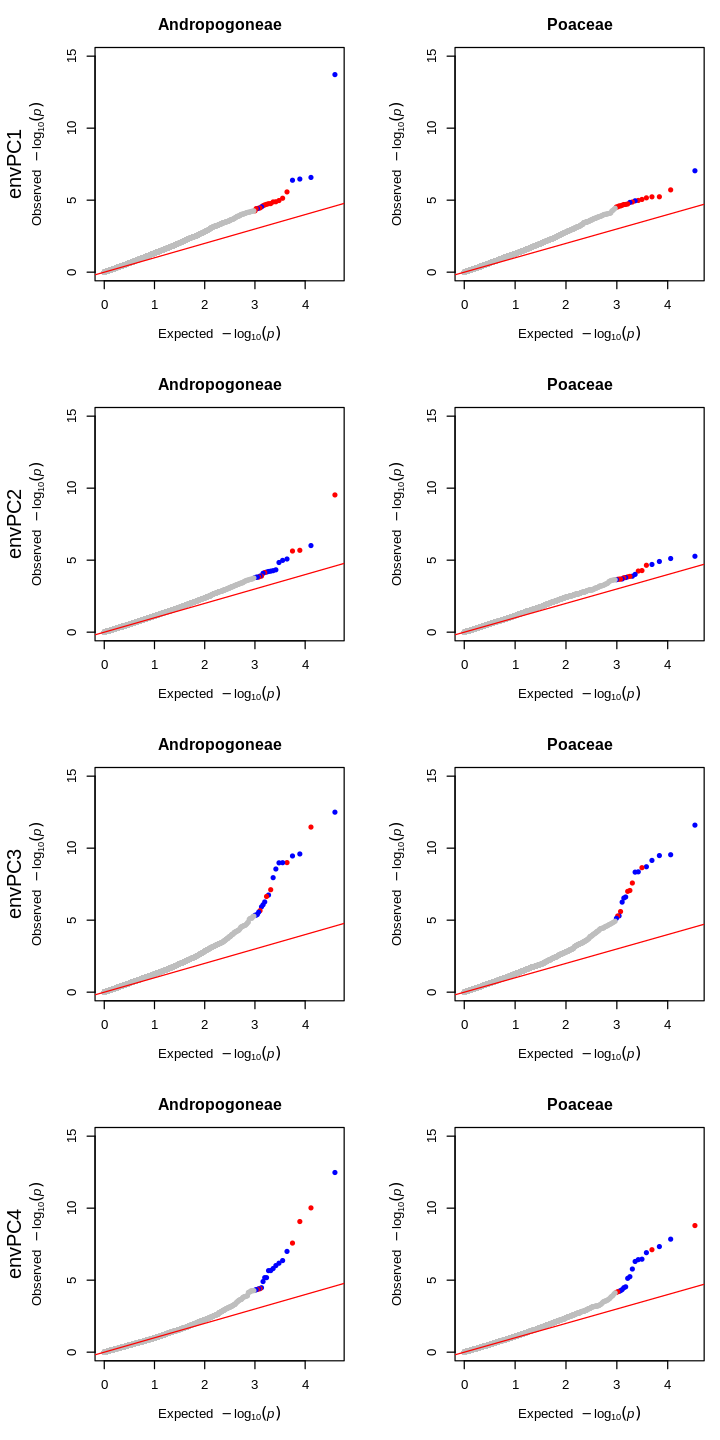

In [279]:
options(repr.plot.width=6, repr.plot.height=12)
par(mfrow = c(4,2),mar = c(5,6,3,1))
for (i in 1:4){
    tmpCutoff = quantile(-log10(as.numeric(testRes_zs_andro[,i+11])),.999,na.rm = T)
    tmpCol = rep("grey",nrow(testRes_zs_andro))
    tmpCol[as.numeric(testRes_zs_andro[,i+1])>0& -log10(as.numeric(testRes_zs_andro[,i+11]))>tmpCutoff] = "red"
    tmpCol[as.numeric(testRes_zs_andro[,i+1])<0& -log10(as.numeric(testRes_zs_andro[,i+11]))>tmpCutoff] = "blue"
    qq(as.numeric(testRes_zs_andro[,i+11]),main = "Andropogoneae",ylim = c(0,15),
       col = tmpCol[order(as.numeric(testRes_zs_andro[,i+11]))])
    mtext(paste0("envPC",i),2,line = 4.5)
    tmpCutoff = quantile(-log10(as.numeric(testRes_zs_out[,i+11])),.999,na.rm = T)
    tmpCol = rep("grey",nrow(testRes_zs_out))
    tmpCol[as.numeric(testRes_zs_out[,i+1])>0& -log10(as.numeric(testRes_zs_out[,i+11]))>tmpCutoff] = "red"
    tmpCol[as.numeric(testRes_zs_out[,i+1])<0& -log10(as.numeric(testRes_zs_out[,i+11]))>tmpCutoff] = "blue"
    qq(as.numeric(testRes_zs_out[,i+11]),main = "Poaceae",ylim = c(0,15),
       col = tmpCol[order(as.numeric(testRes_zs_out[,i+11]))])
}


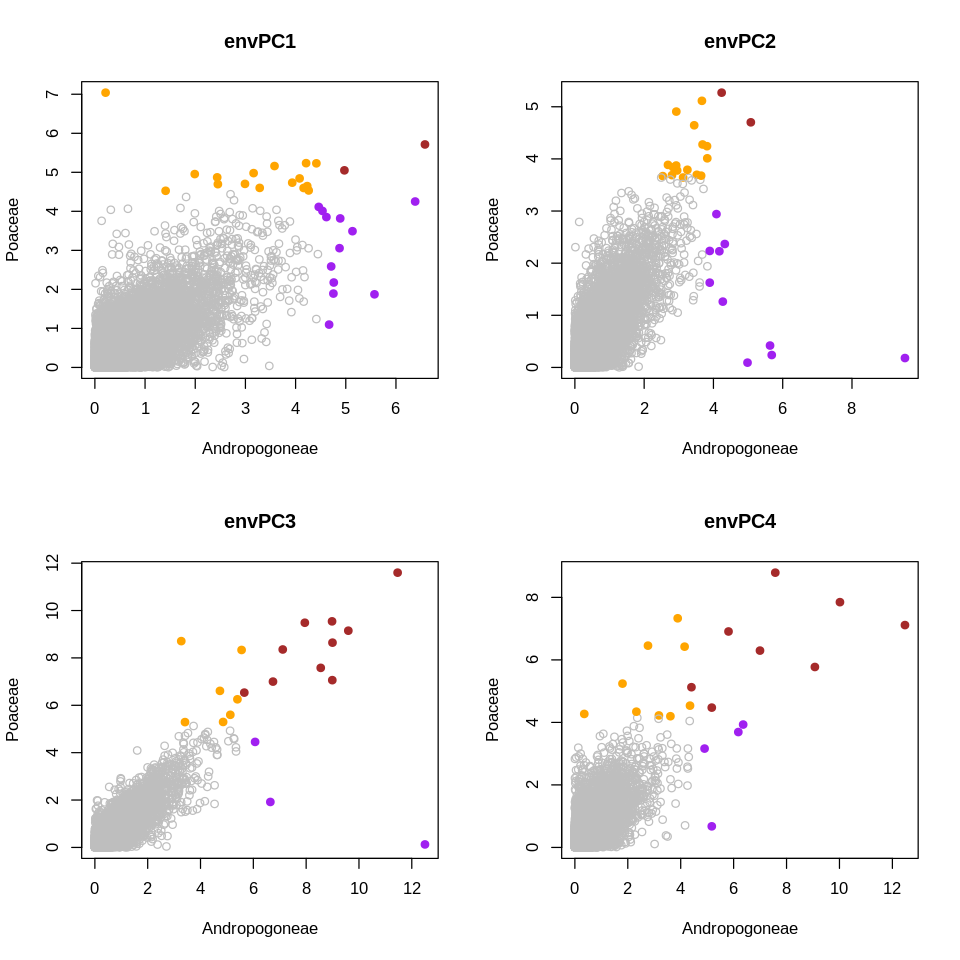

In [280]:
options(repr.plot.width=8, repr.plot.height=8)
par(mfrow = c(2,2))
for (i in 1:4){
    compDF = merge(testRes_zs_andro[,c(1,i+1,i+11)],testRes_zs_out[,c(1,i+1,i+11)],by = "OG")

    for (j in 2:5){
        compDF[,j] = as.numeric(compDF[,j])
    }


    tmpCutoff1 = quantile(-log10(as.numeric(testRes_zs_andro[,i+11])),.999,na.rm = T)
    tmpCutoff2 = quantile(-log10(as.numeric(testRes_zs_out[,i+11])),.999,na.rm = T)

    mycol = rep("grey",nrow(compDF))
    mycol[-log10(compDF[,3])<tmpCutoff1&-log10(compDF[,5])>tmpCutoff2] = "orange"
    mycol[-log10(compDF[,3])>tmpCutoff1&-log10(compDF[,5])<tmpCutoff2] = "purple"
    mycol[-log10(compDF[,3])>tmpCutoff1&-log10(compDF[,5])>tmpCutoff2] = "brown"

    plot(-log10(compDF[,c(3,5)]),col = mycol,xlab = "Andropogoneae",ylab = "Poaceae",main = paste0("envPC",i),
         pch = ifelse(-log10(compDF[,3])>tmpCutoff1|-log10(compDF[,5])>tmpCutoff2,19,1))
#     plot(compDF[,c(2,4)],col = mycol,xlab = "Andropogoneae",ylab = "Poaceae",main = paste0("envPC",i),
#          pch = ifelse(-log10(compDF[,3])>tmpCutoff1|-log10(compDF[,5])>tmpCutoff2,19,1))
}


# enrichment of RAOs

In [157]:
RAO = read.table("/workdir/sh2246/p_phyloGWAS/output/Yeaman2024RAO_OGID.txt")

In [158]:
length(unique(RAO[,2]))

[1] 185

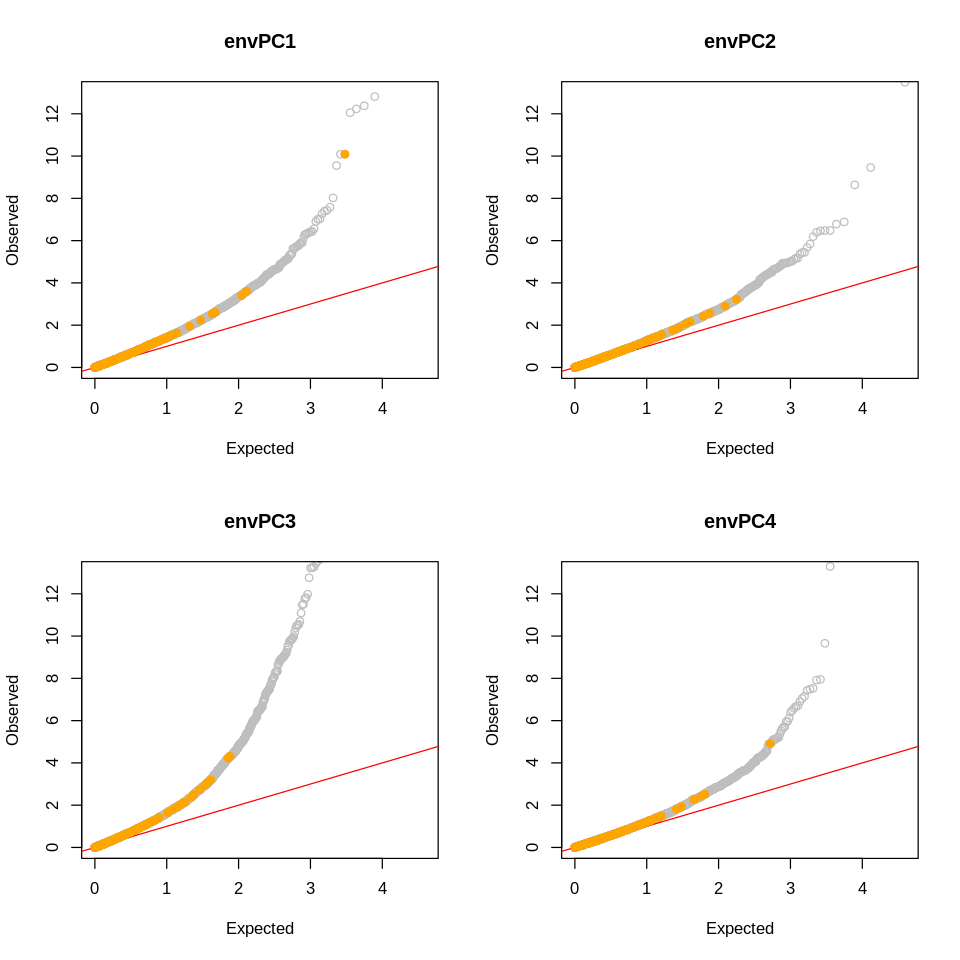

In [1238]:
options(repr.plot.width=8, repr.plot.height=8)
par(mfrow= c(2,2))
for(i in 1:4){   
    exptd = -log10(ppoints(nrow(testRes_zs2)))
    plot(exptd,sort(-log10(as.numeric(testRes_zs2[,i+11])),decreasing = T),
         xlab = "Expected",ylab ="Observed",col ="grey",main = paste0("envPC",i),ylim = c(0,13))
    abline(a = 0, b=1,col = "red")
    points(exptd[testRes_zs2$OG[order(as.numeric(testRes_zs2[,i+11]))]%in%RAO[,2]],
           sort(-log10(as.numeric(testRes_zs2[testRes_zs2$OG%in%RAO[,2],i+11])),decreasing = T),
           col ="orange",pch = 19)
}

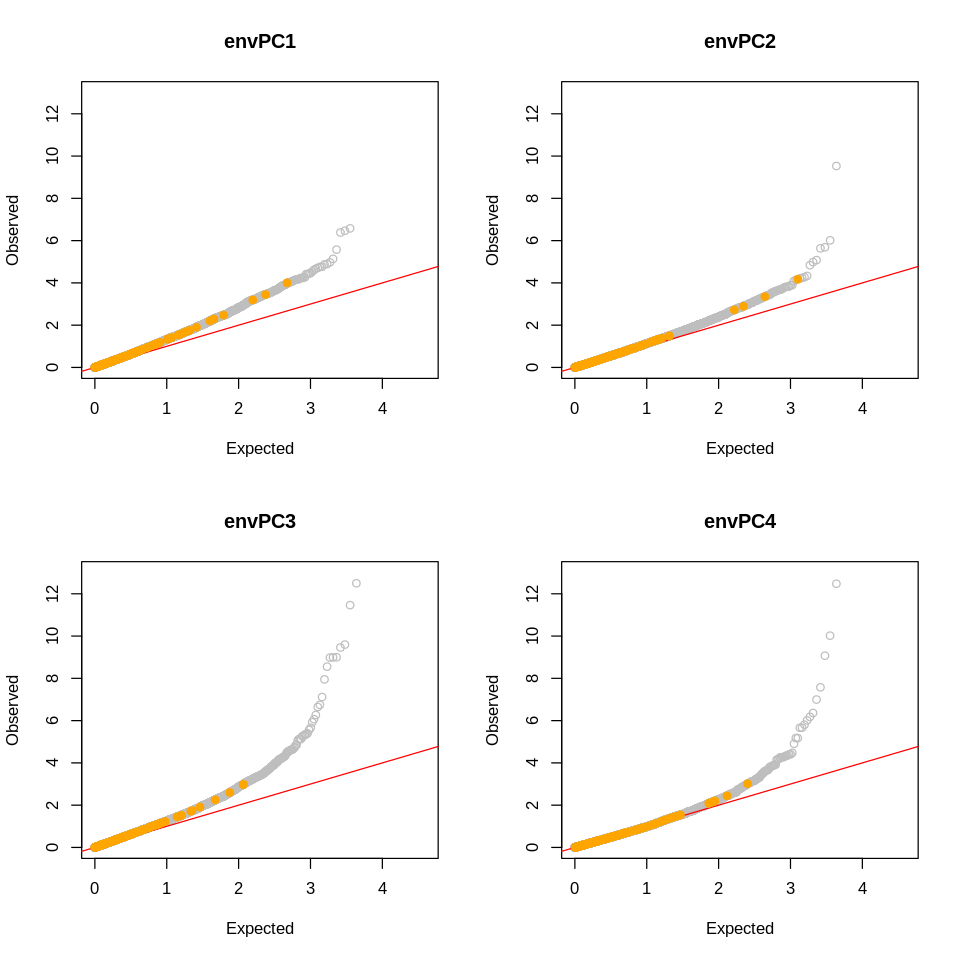

In [282]:
options(repr.plot.width=8, repr.plot.height=8)
par(mfrow= c(2,2))
for(i in 1:4){   
    exptd = -log10(ppoints(nrow(testRes_zs_andro)))
    plot(exptd,sort(-log10(as.numeric(testRes_zs_andro[,i+11])),decreasing = T),
         xlab = "Expected",ylab ="Observed",col ="grey",main = paste0("envPC",i),ylim = c(0,13))
    abline(a = 0, b=1,col = "red")
    points(exptd[testRes_zs_andro$OG[order(as.numeric(testRes_zs_andro[,i+11]))]%in%RAO[,2]],
           sort(-log10(as.numeric(testRes_zs_andro[testRes_zs_andro$OG%in%RAO[,2],i+11])),decreasing = T),
           col ="orange",pch = 19)
}

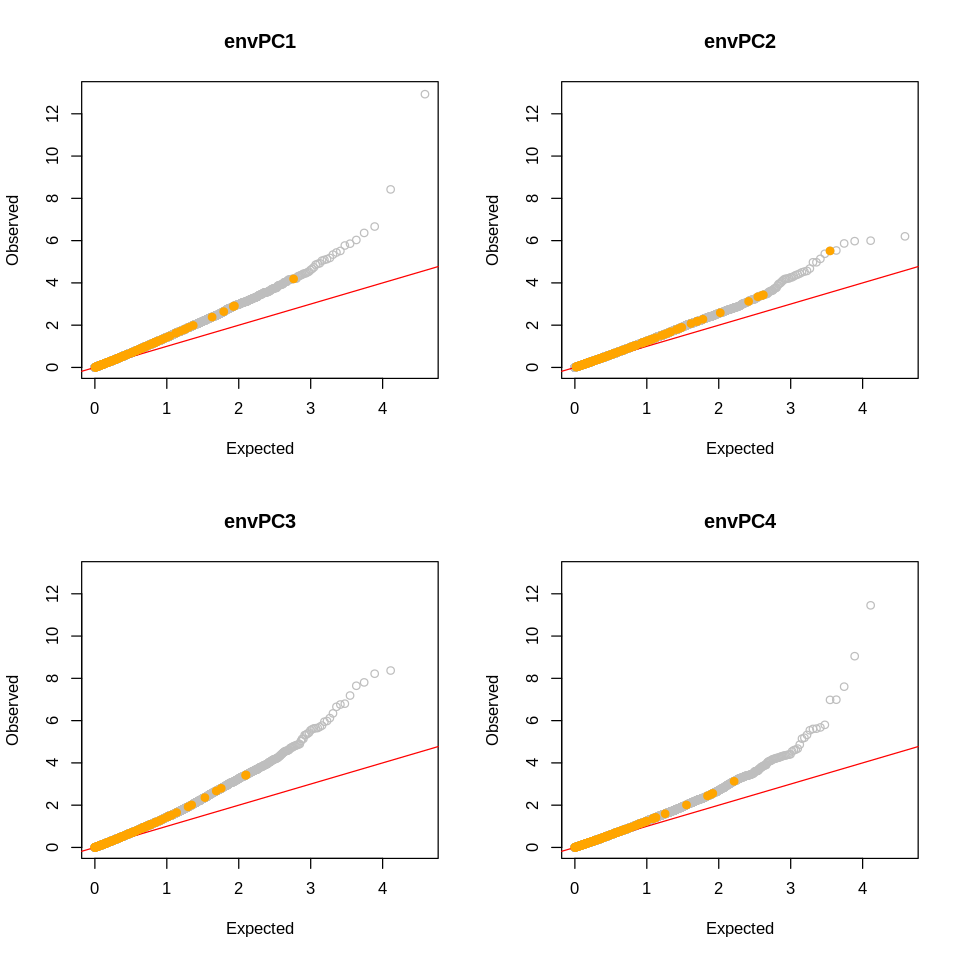

In [439]:
options(repr.plot.width=8, repr.plot.height=8)
par(mfrow= c(2,2))
for(i in 1:4){   
    exptd = -log10(ppoints(nrow(testRes_zs_dna)))
    plot(exptd,sort(-log10(testRes_zs_dna[,i+11]),decreasing = T),
         xlab = "Expected",ylab ="Observed",col ="grey",main = paste0("envPC",i),ylim = c(0,13))
    abline(a = 0, b=1,col = "red")
    points(exptd[testRes_zs_dna$OG[order(testRes_zs_dna[,i+11])]%in%RAO[,2]],
           sort(-log10(testRes_zs_dna[testRes_zs_dna$OG%in%RAO[,2],i+11]),decreasing = T),
           col ="orange",pch = 19)
}

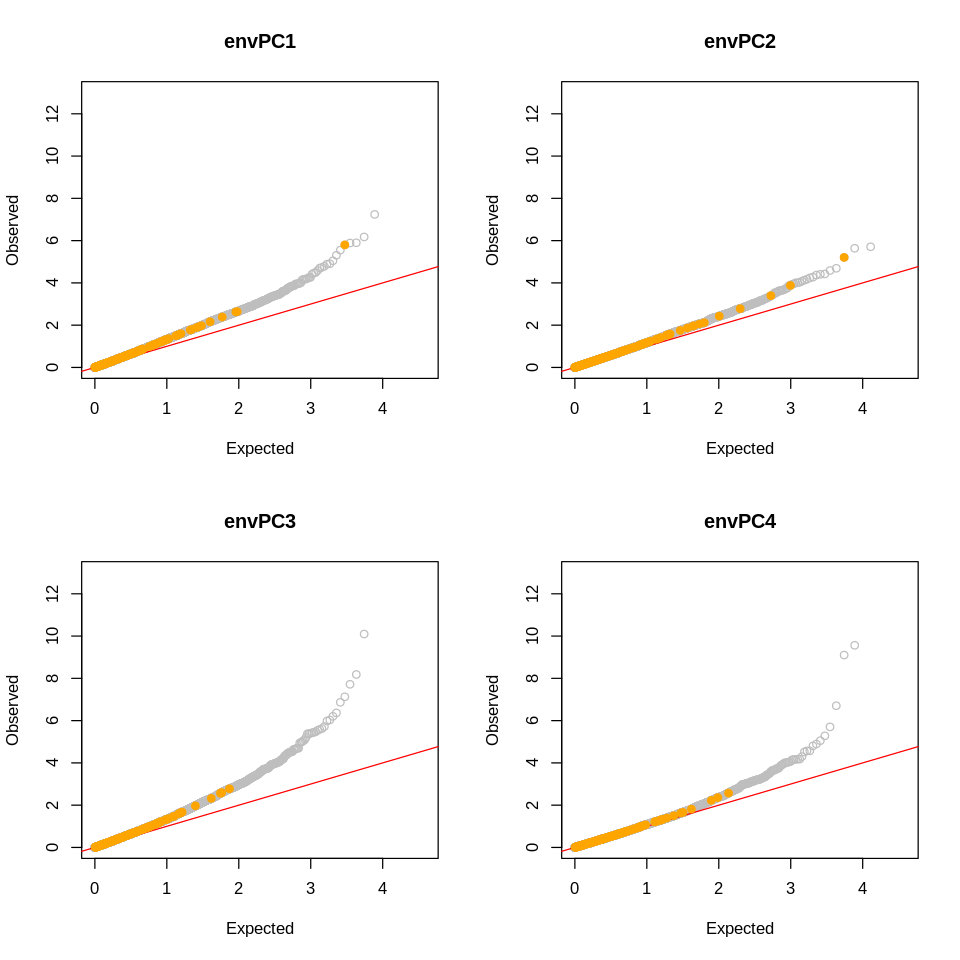

In [444]:
options(repr.plot.width=8, repr.plot.height=8)
par(mfrow= c(2,2))
for(i in 1:4){   
    exptd = -log10(ppoints(nrow(testRes_zs_dna_andro)))
    plot(exptd,sort(-log10(as.numeric(testRes_zs_dna_andro[,i+11])),decreasing = T),
         xlab = "Expected",ylab ="Observed",col ="grey",main = paste0("envPC",i),ylim = c(0,13))
    abline(a = 0, b=1,col = "red")
    points(exptd[testRes_zs_dna_andro$OG[order(as.numeric(testRes_zs_dna_andro[,i+11]))]%in%RAO[,2]],
           sort(-log10(as.numeric(testRes_zs_dna_andro[testRes_zs_dna_andro$OG%in%RAO[,2],i+11])),decreasing = T),
           col ="orange",pch = 19)
}

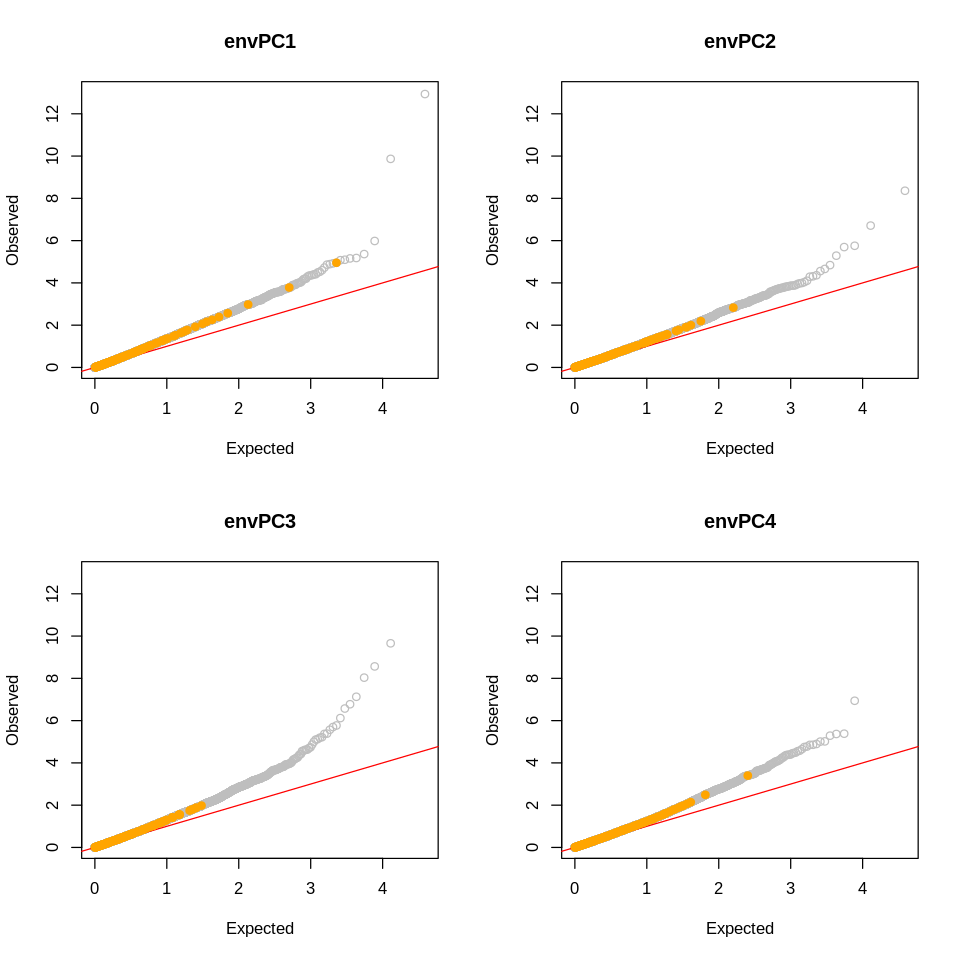

In [942]:
options(repr.plot.width=8, repr.plot.height=8)
par(mfrow= c(2,2))
for(i in 1:4){   
    exptd = -log10(ppoints(nrow(testRes_multiVar)))
    plot(exptd,sort(-log10(as.numeric(testRes_multiVar[,i+11])),decreasing = T),
         xlab = "Expected",ylab ="Observed",col ="grey",main = paste0("envPC",i),ylim = c(0,13))
    abline(a = 0, b=1,col = "red")
    points(exptd[testRes_multiVar$OG[order(as.numeric(testRes_multiVar[,i+11]))]%in%RAO[,2]],
           sort(-log10(as.numeric(testRes_multiVar[testRes_multiVar$OG%in%RAO[,2],i+11])),decreasing = T),
           col ="orange",pch = 19)
}

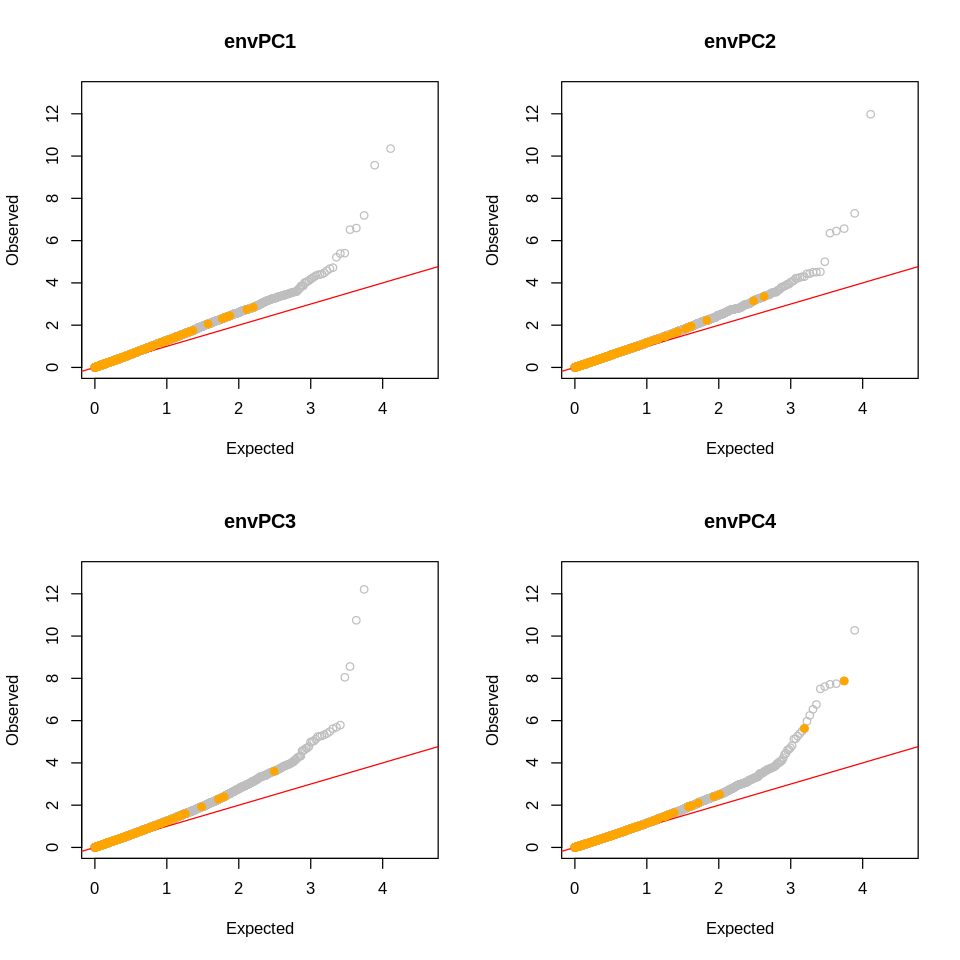

In [955]:
options(repr.plot.width=8, repr.plot.height=8)
par(mfrow= c(2,2))
for(i in 1:4){   
    exptd = -log10(ppoints(nrow(testRes_multiVar_andro)))
    plot(exptd,sort(-log10(as.numeric(testRes_multiVar_andro[,i+11])),decreasing = T),
         xlab = "Expected",ylab ="Observed",col ="grey",main = paste0("envPC",i),ylim = c(0,13))
    abline(a = 0, b=1,col = "red")
    points(exptd[testRes_multiVar_andro$OG[order(as.numeric(testRes_multiVar_andro[,i+11]))]%in%RAO[,2]],
           sort(-log10(as.numeric(testRes_multiVar_andro[testRes_multiVar_andro$OG%in%RAO[,2],i+11])),decreasing = T),
           col ="orange",pch = 19)
}

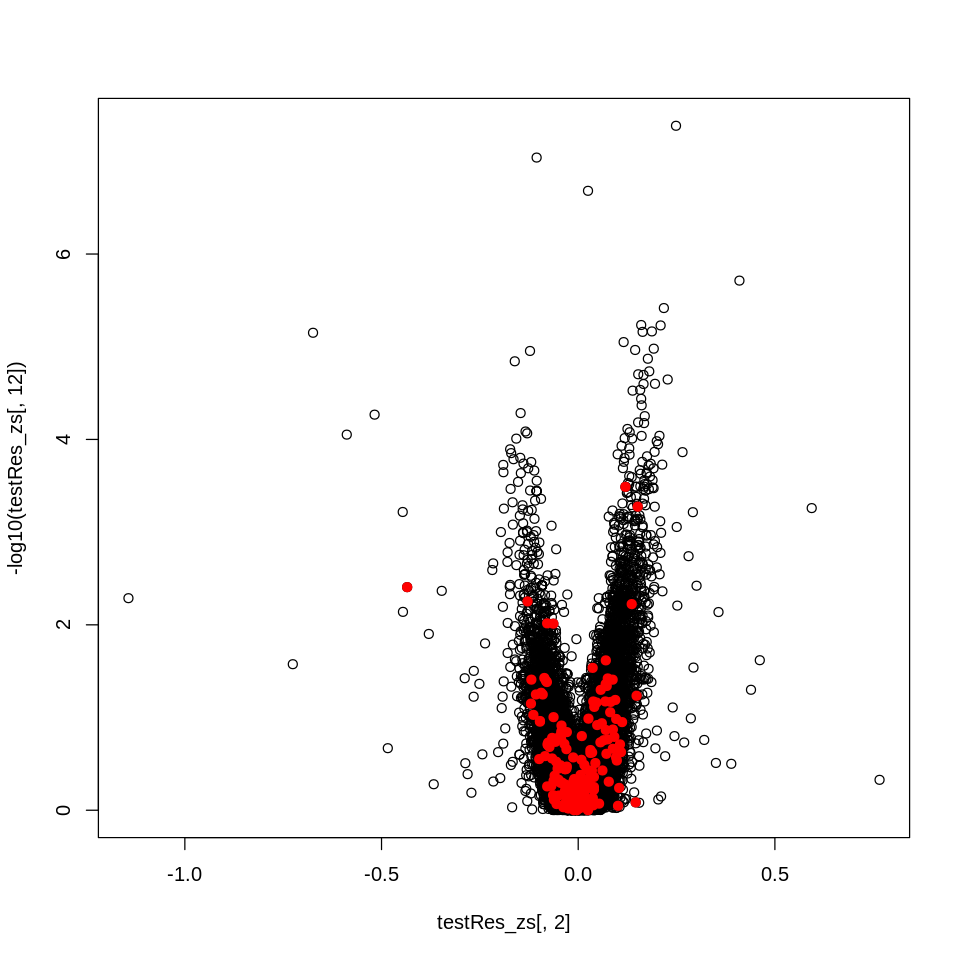

In [162]:
plot(testRes_zs[,2],-log10(testRes_zs[,12]))
points(testRes_zs[testRes_zs$OG%in%RAO[,2],2],-log10(testRes_zs[testRes_zs$OG%in%RAO[,2],12]),col = "red",pch =19)

In [160]:
library(PRROC)

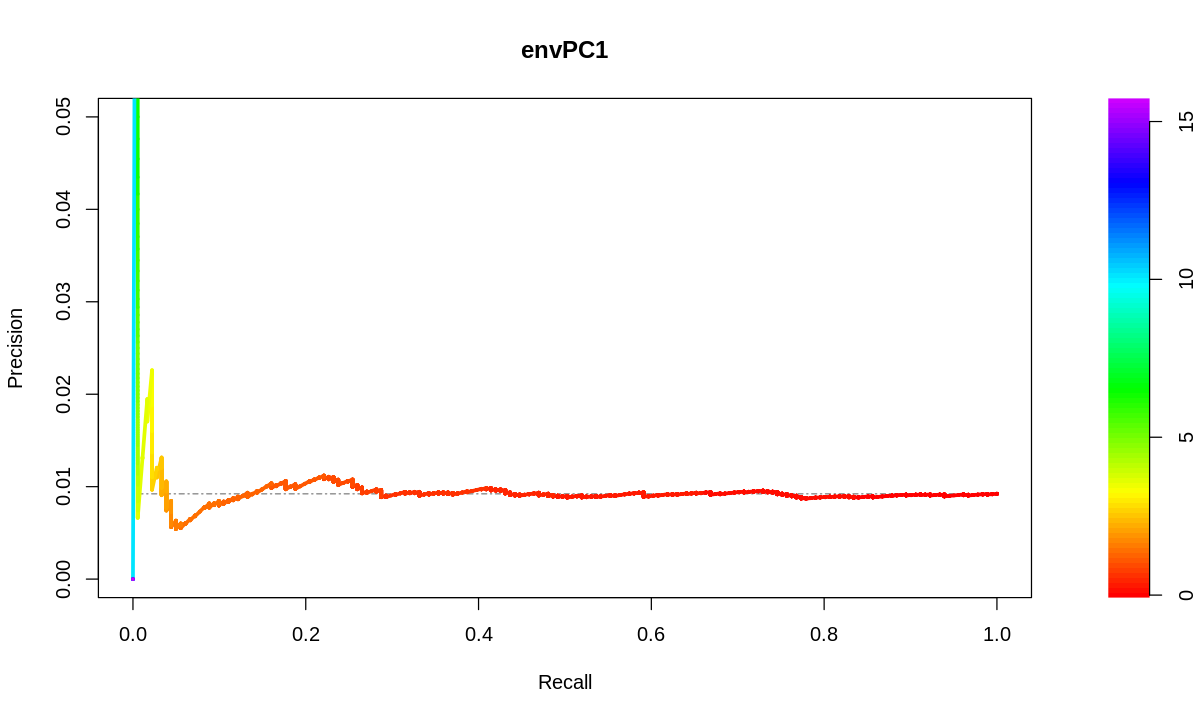

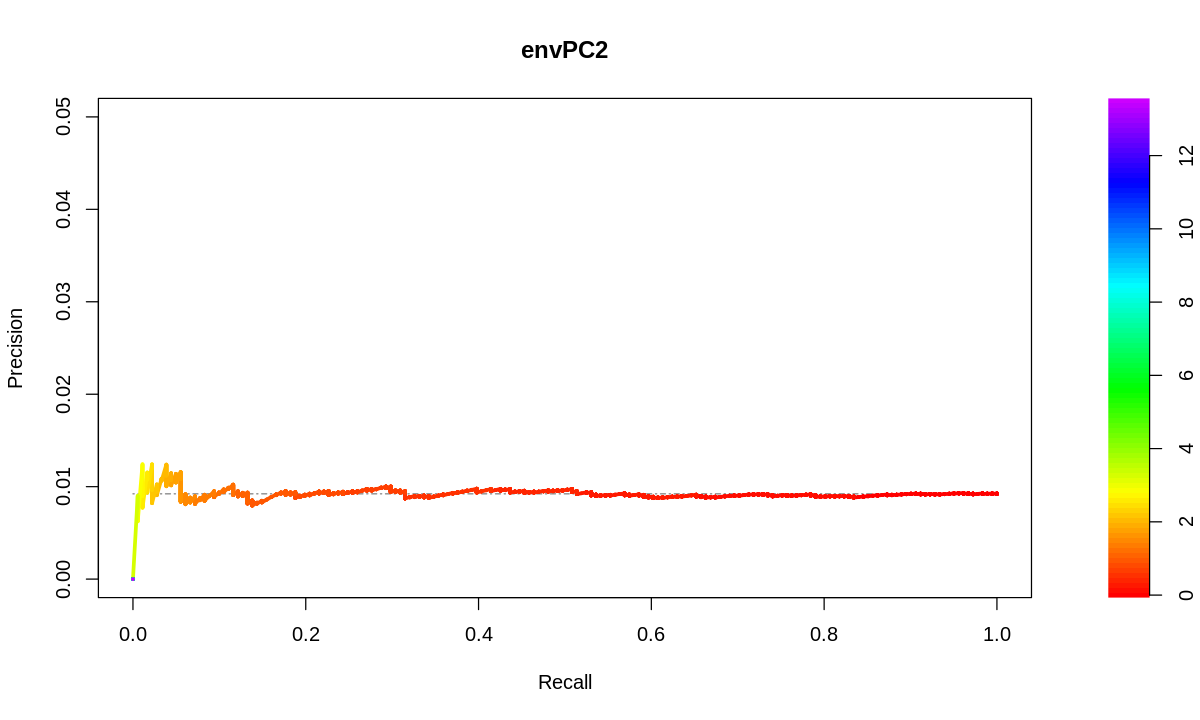

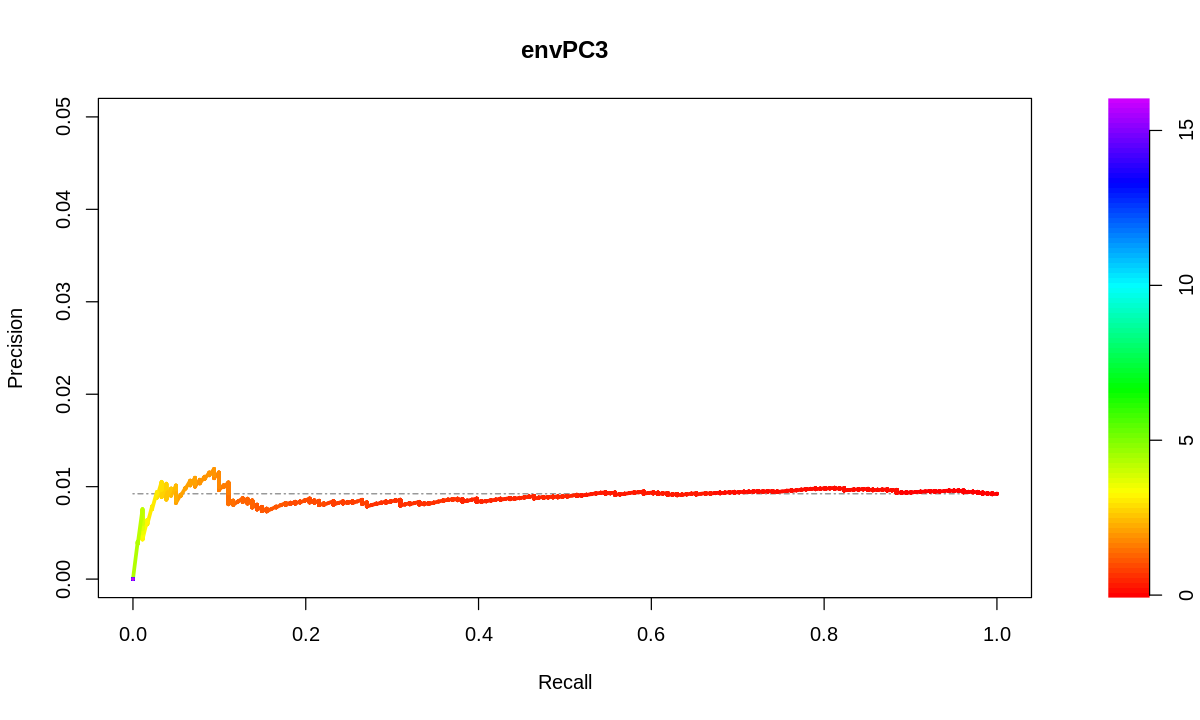

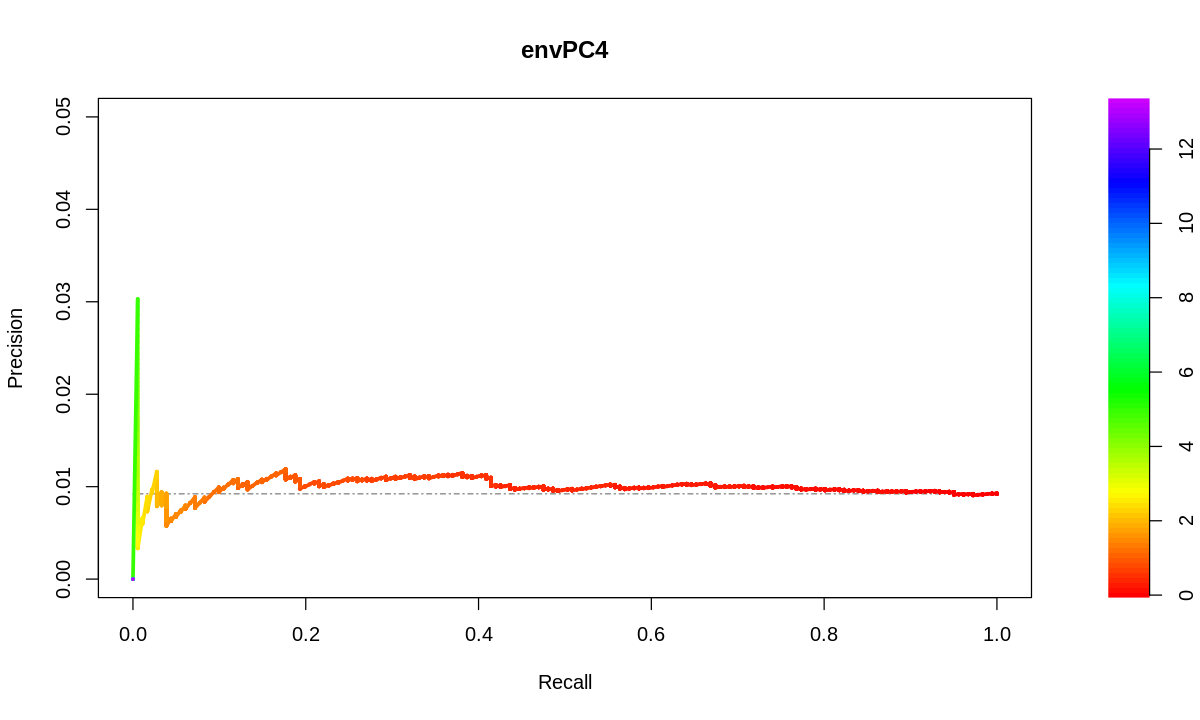

In [1235]:
options(repr.plot.width=10, repr.plot.height=6)
for(i in 1:4){
    fg_RAO = -log10(as.numeric(testRes_zs2[,i+11]))[testRes_zs2$OG%in%RAO[,2]]
    bg_RAO = -log10(as.numeric(testRes_zs2[,i+11]))[!testRes_zs2$OG%in%RAO[,2]]

    pr_RAO = pr.curve(scores.class0 = fg_RAO, scores.class1 = bg_RAO[bg_RAO!=Inf], curve = T,rand.compute = T)
    roc_RAO = roc.curve(scores.class0 = fg_RAO, scores.class1 = bg_RAO[bg_RAO!=Inf], curve = T,rand.compute = T)

    plot(pr_RAO,rand.plot = T,ylim = c(0,0.05),auc.main =F,main = paste0("envPC",i))

}


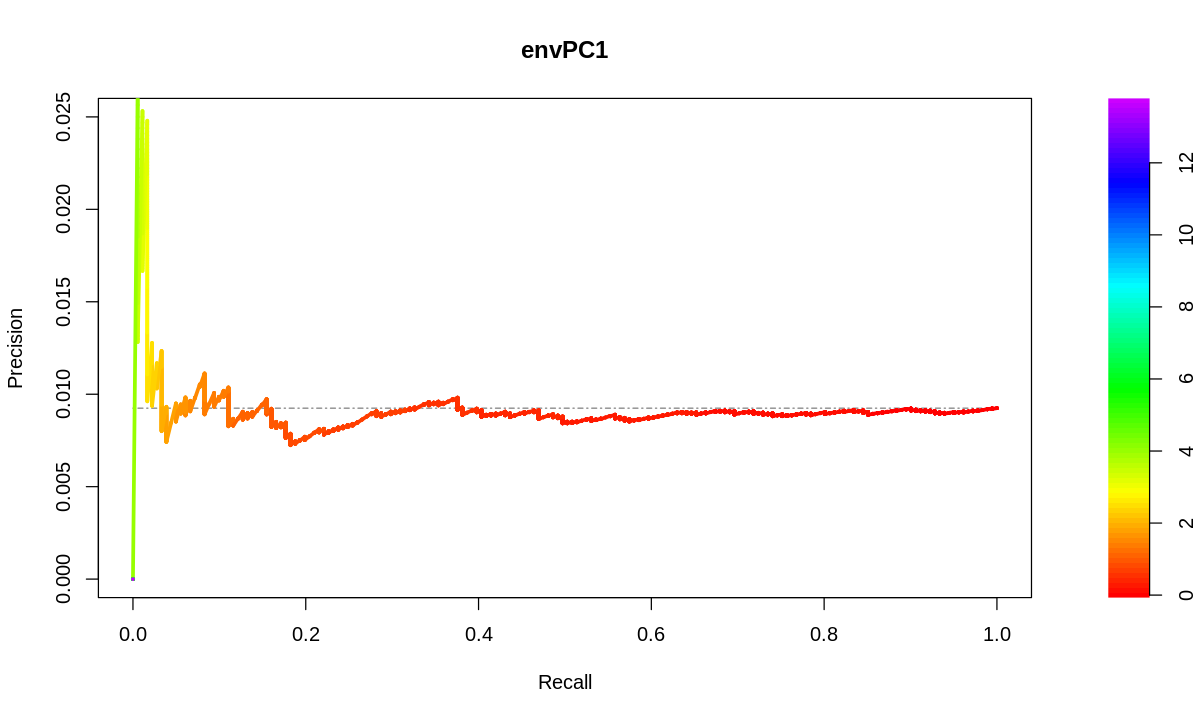

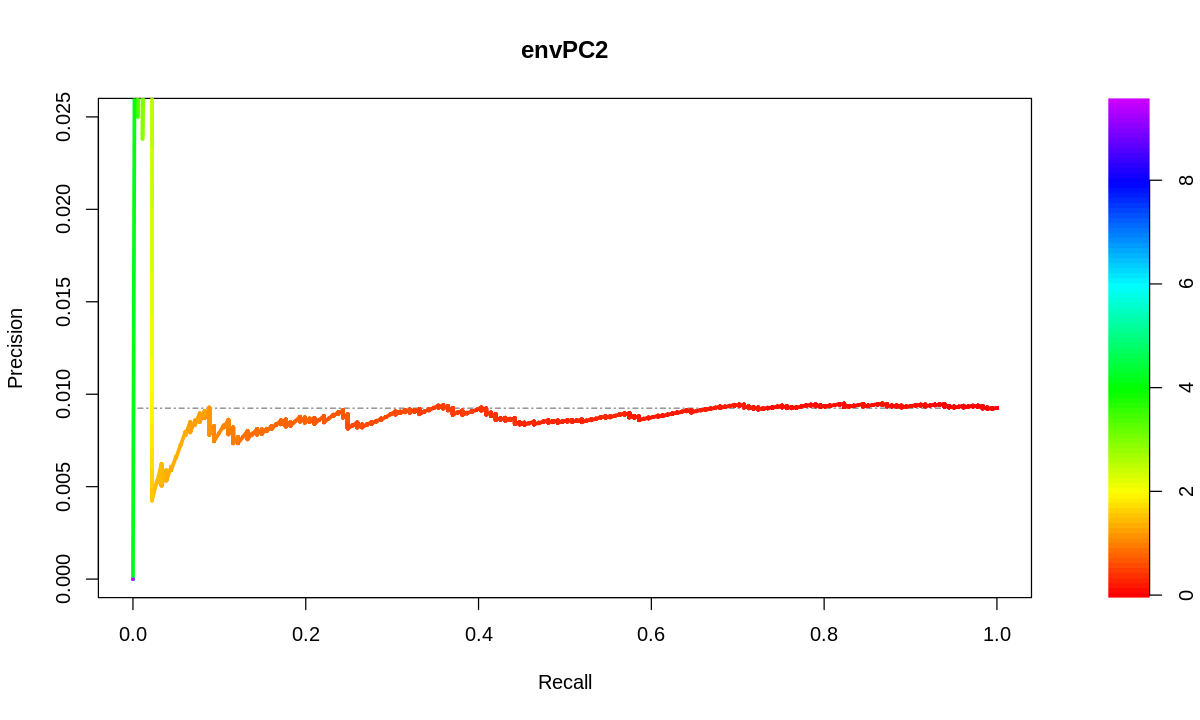

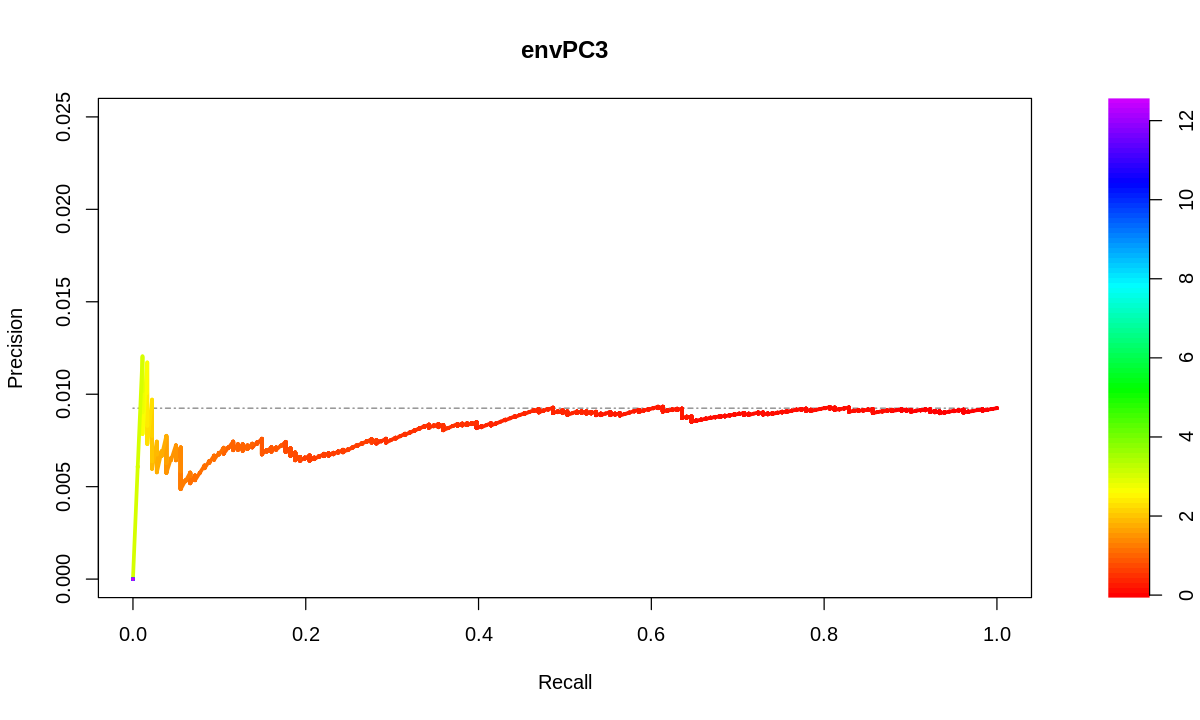

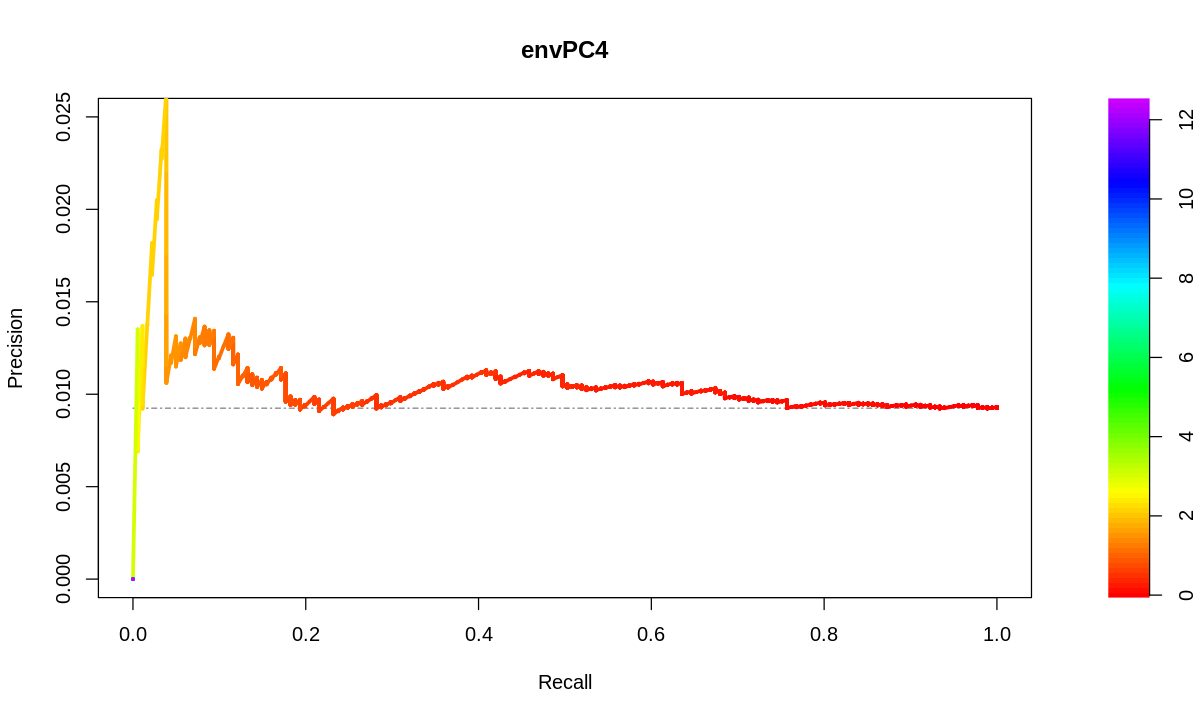

In [456]:
options(repr.plot.width=10, repr.plot.height=6)
for(i in 1:4){
    fg_RAO = -log10(as.numeric(testRes_zs_andro[,i+11]))[testRes_zs_andro$OG%in%RAO[,2]]
    bg_RAO = -log10(as.numeric(testRes_zs_andro[,i+11]))[!testRes_zs_andro$OG%in%RAO[,2]]

    pr_RAO = pr.curve(scores.class0 = fg_RAO, scores.class1 = bg_RAO[bg_RAO!=Inf], curve = T,rand.compute = T)
    roc_RAO = roc.curve(scores.class0 = fg_RAO, scores.class1 = bg_RAO[bg_RAO!=Inf], curve = T,rand.compute = T)

    plot(pr_RAO,rand.plot = T,ylim = c(0,0.025),auc.main =F,main = paste0("envPC",i))

}


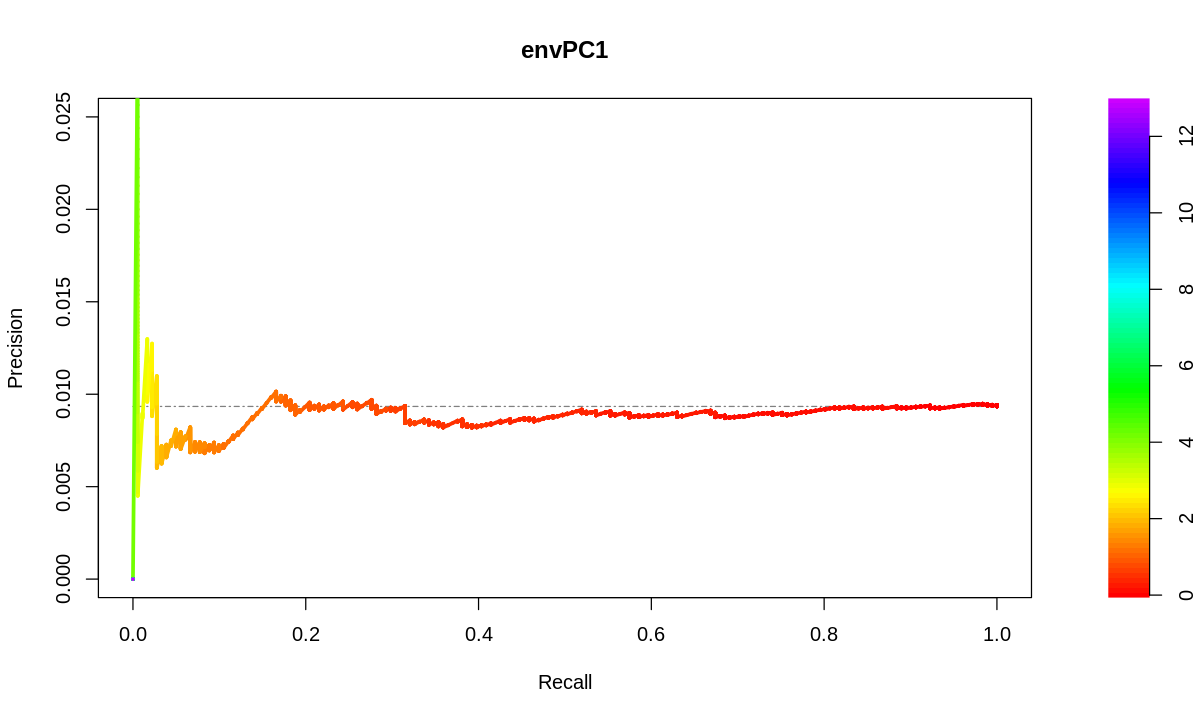

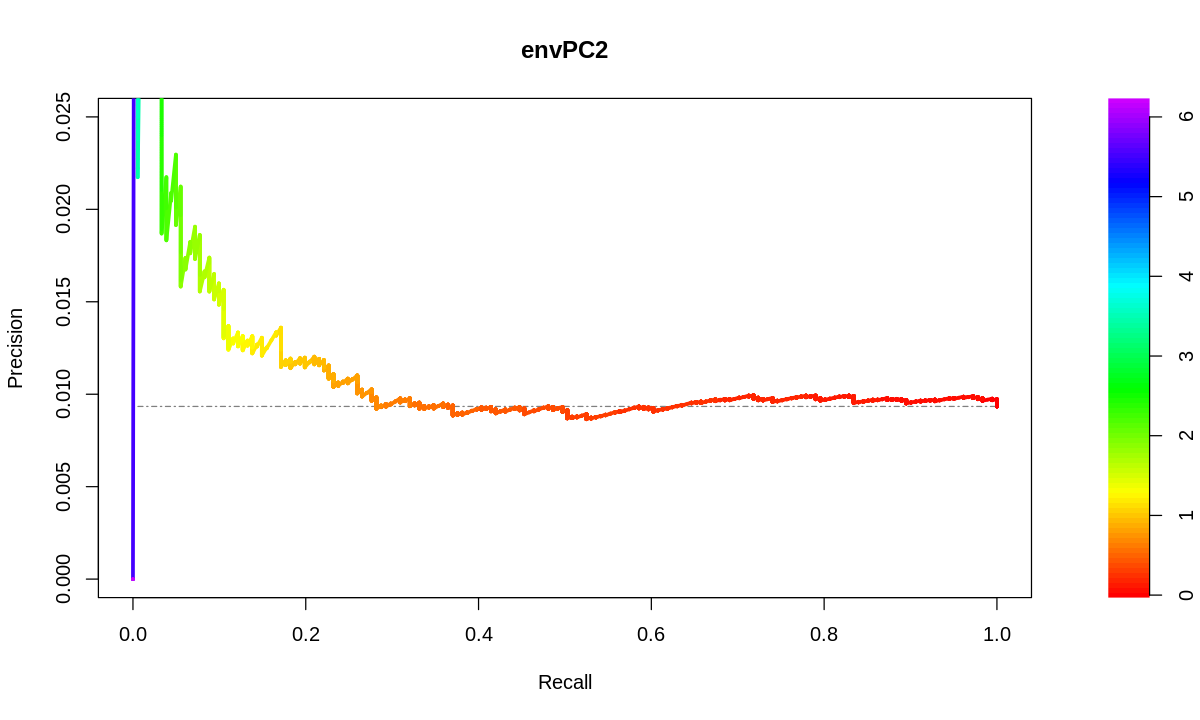

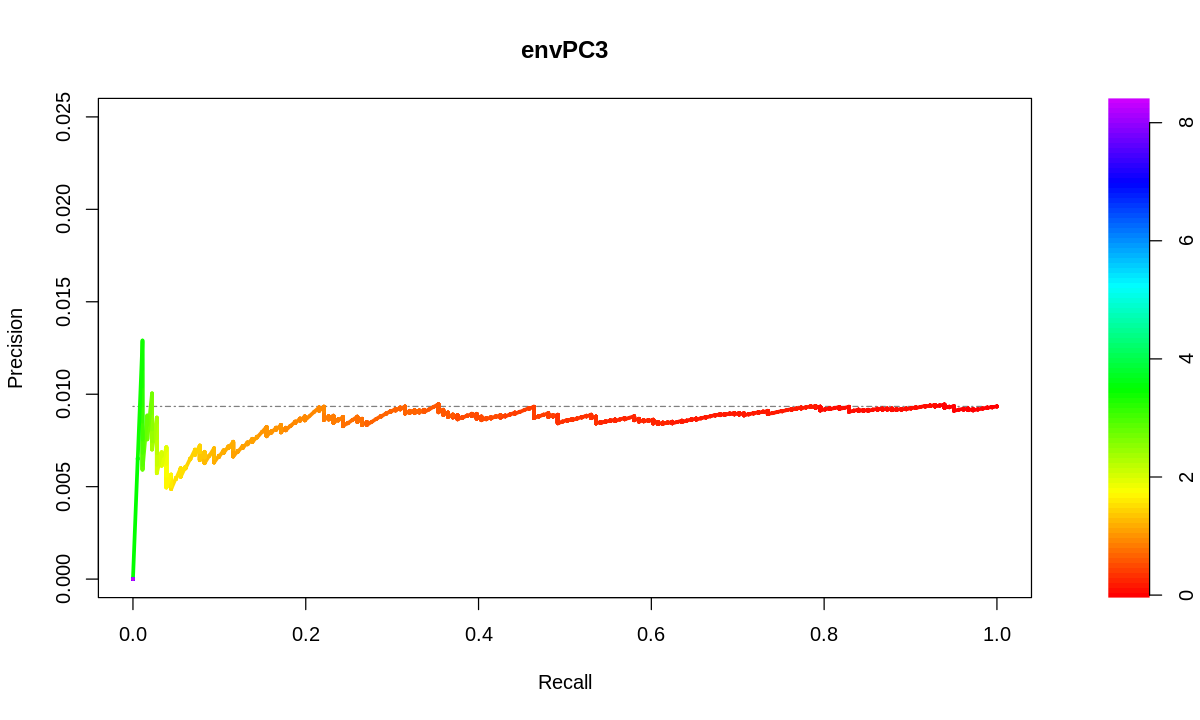

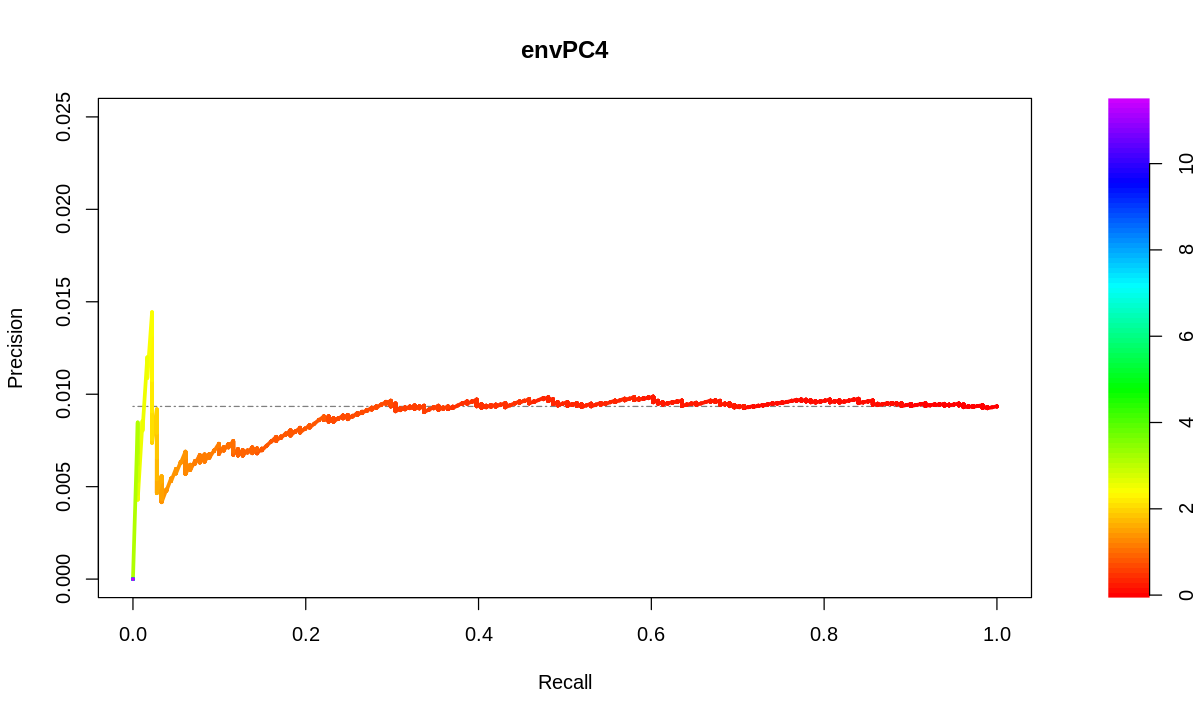

In [457]:
options(repr.plot.width=10, repr.plot.height=6)
for(i in 1:4){
    fg_RAO = -log10(as.numeric(testRes_zs_dna[,i+11]))[testRes_zs_dna$OG%in%RAO[,2]]
    bg_RAO = -log10(as.numeric(testRes_zs_dna[,i+11]))[!testRes_zs_dna$OG%in%RAO[,2]]

    pr_RAO = pr.curve(scores.class0 = fg_RAO, scores.class1 = bg_RAO[bg_RAO!=Inf], curve = T,rand.compute = T)
    roc_RAO = roc.curve(scores.class0 = fg_RAO, scores.class1 = bg_RAO[bg_RAO!=Inf], curve = T,rand.compute = T)

    plot(pr_RAO,rand.plot = T,ylim = c(0,0.025),auc.main =F,main = paste0("envPC",i))

}


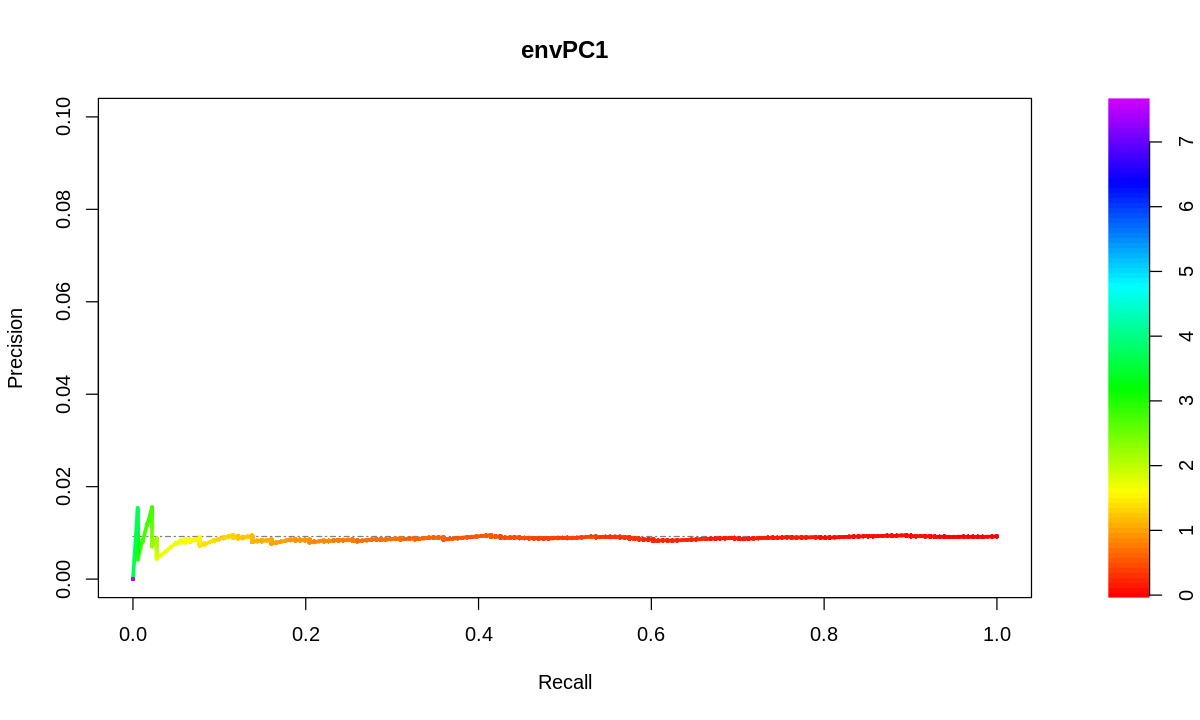

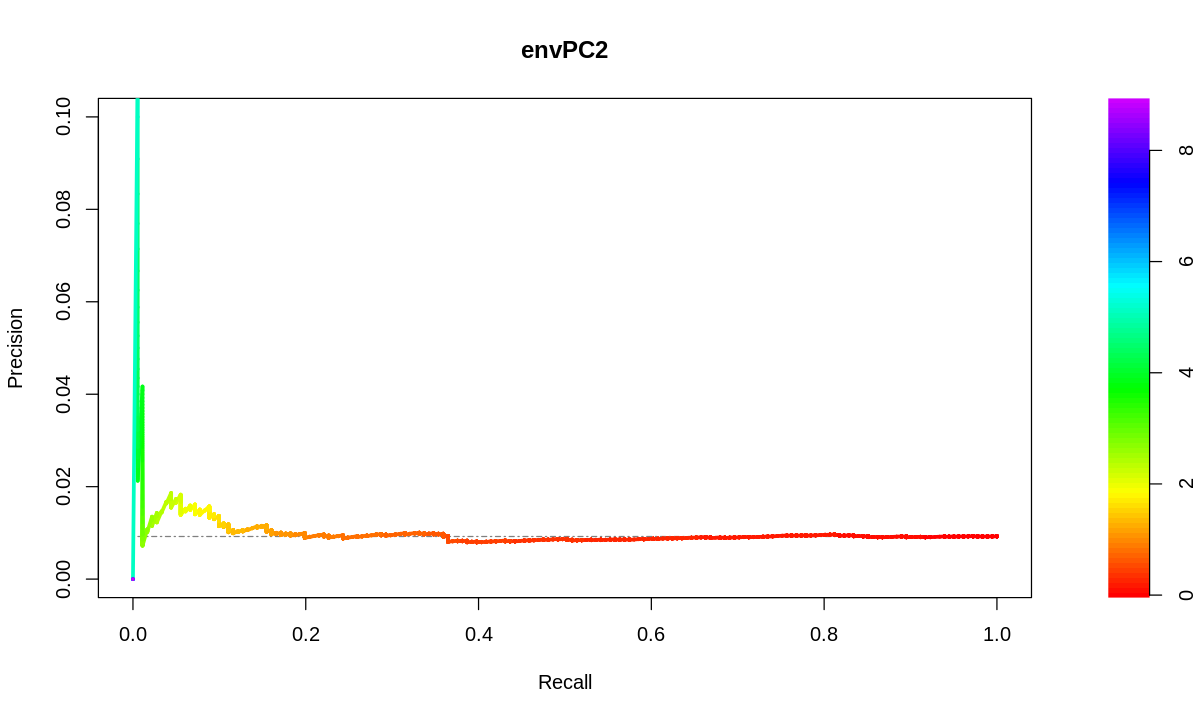

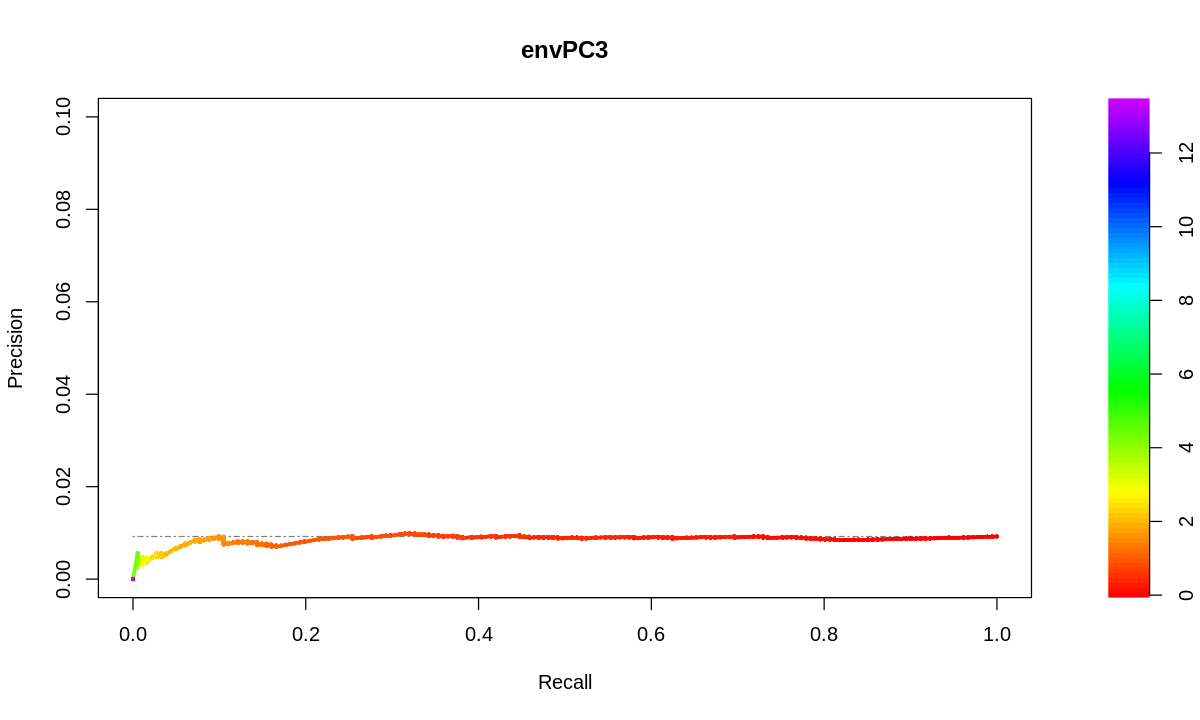

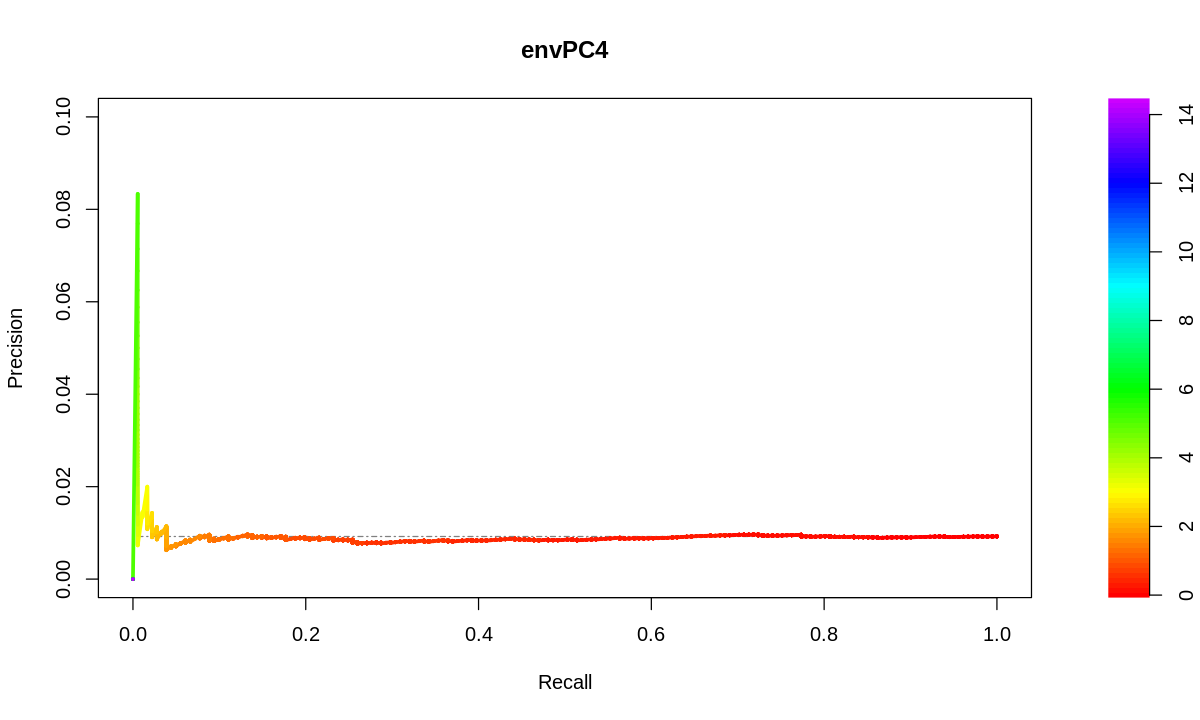

In [675]:
options(repr.plot.width=10, repr.plot.height=6)
for(i in 1:4){
    fg_RAO = -log10(as.numeric(testRes_dnds[,i+11]))[testRes_dnds$OG%in%RAO[,2]]
    bg_RAO = -log10(as.numeric(testRes_dnds[,i+11]))[!testRes_dnds$OG%in%RAO[,2]]

    pr_RAO = pr.curve(scores.class0 = fg_RAO, scores.class1 = bg_RAO[bg_RAO!=Inf], curve = T,rand.compute = T)
    roc_RAO = roc.curve(scores.class0 = fg_RAO, scores.class1 = bg_RAO[bg_RAO!=Inf], curve = T,rand.compute = T)

    plot(pr_RAO,rand.plot = T,ylim = c(0,0.1),auc.main =F,main = paste0("envPC",i))

}


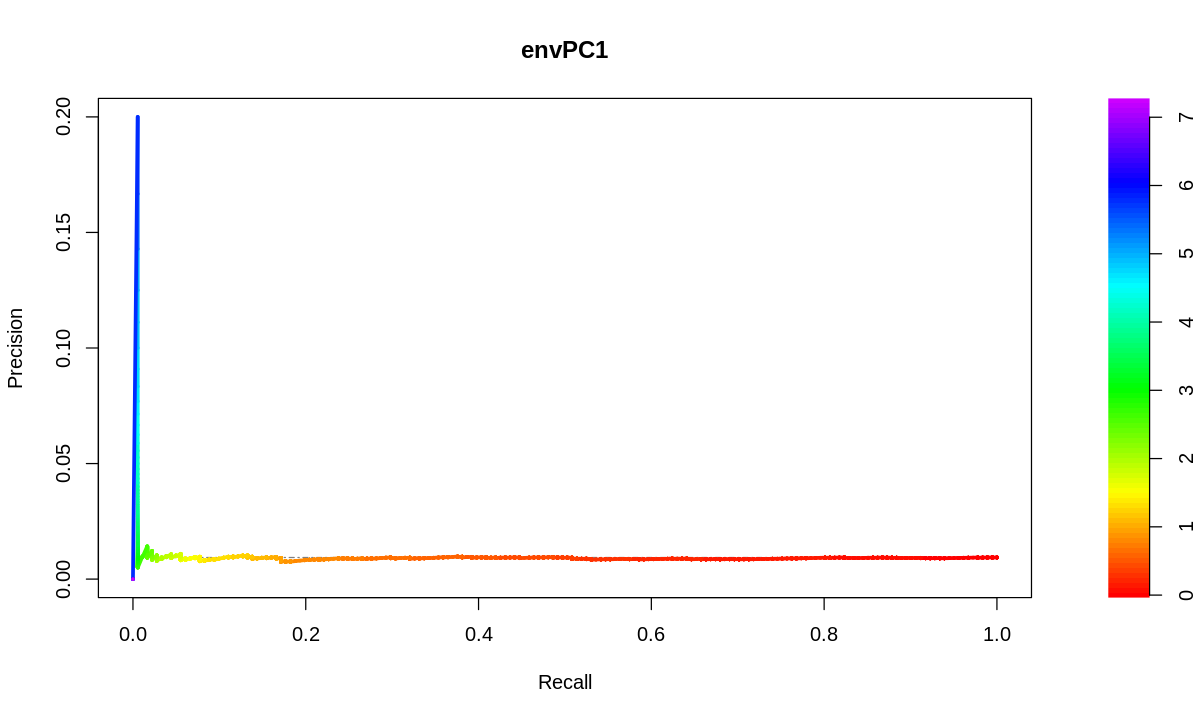

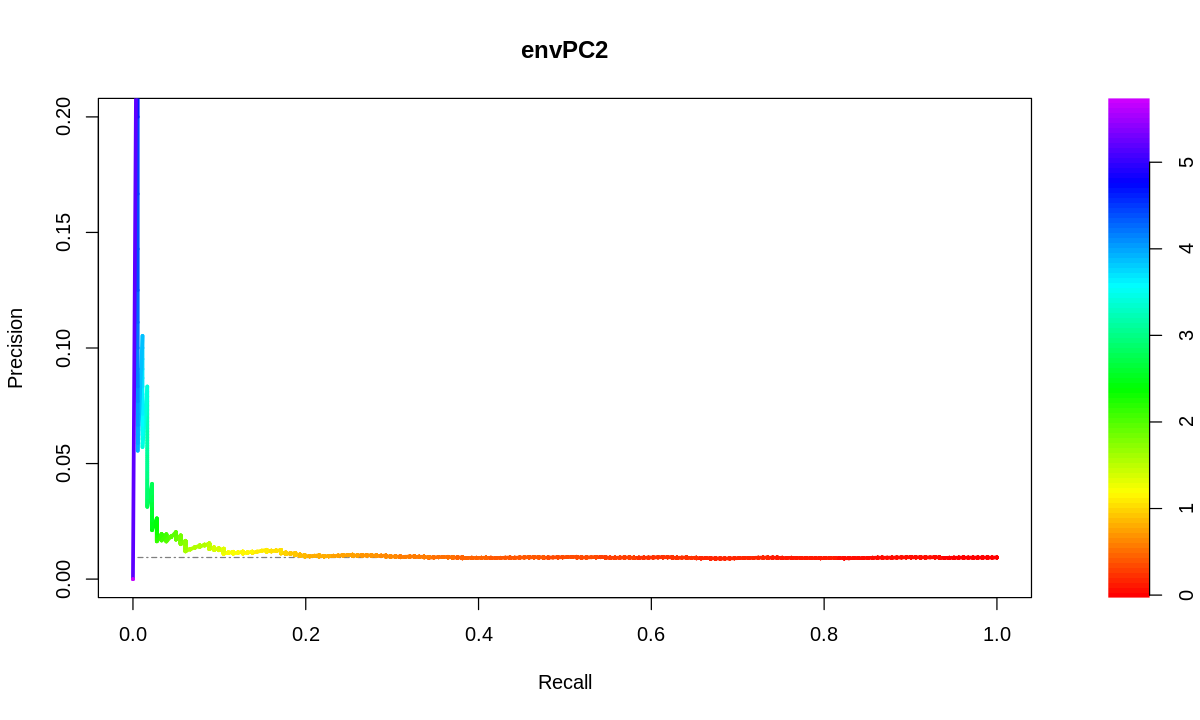

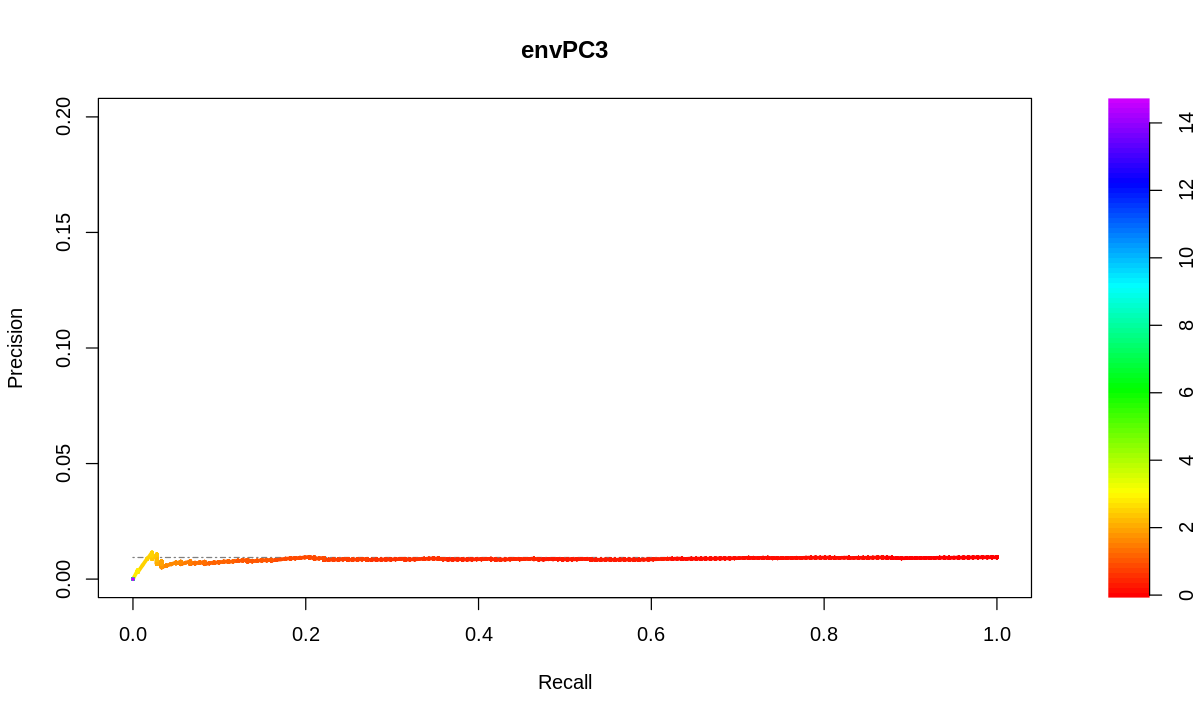

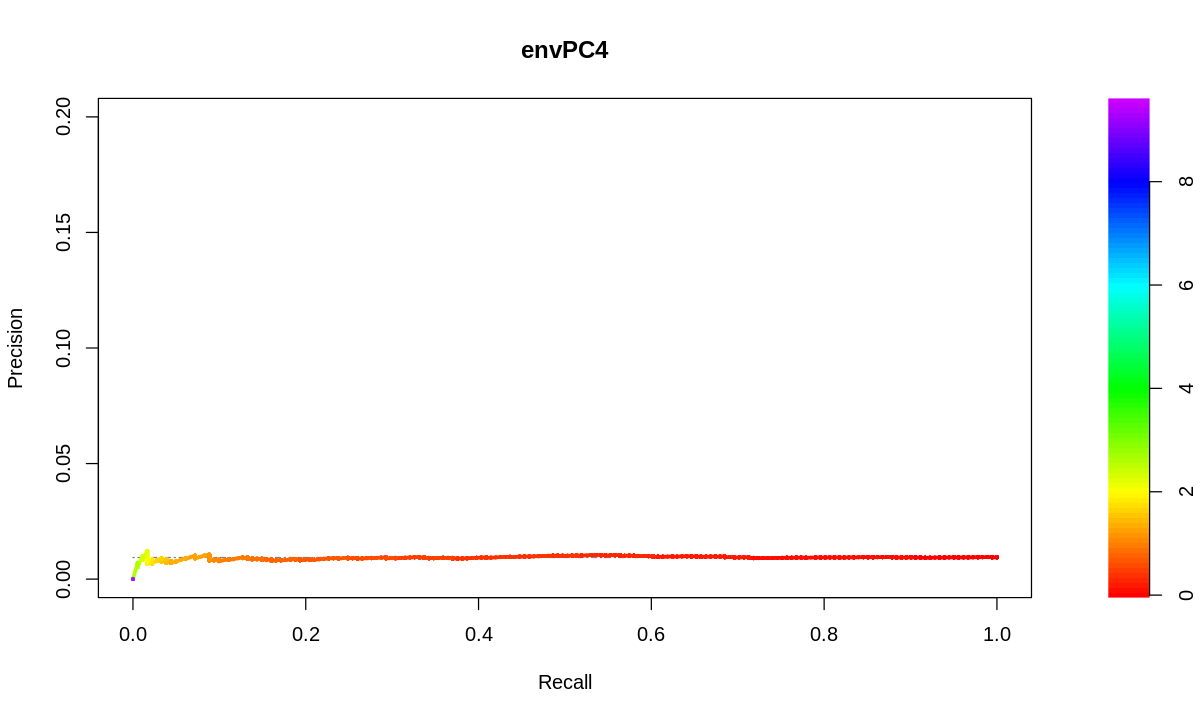

In [604]:
options(repr.plot.width=10, repr.plot.height=6)
for(i in 1:4){
    fg_RAO = -log10(as.numeric(testRes_zs_dna_andro[,i+11]))[testRes_zs_dna_andro$OG%in%RAO[,2]]
    bg_RAO = -log10(as.numeric(testRes_zs_dna_andro[,i+11]))[!testRes_zs_dna_andro$OG%in%RAO[,2]]

    pr_RAO = pr.curve(scores.class0 = fg_RAO, scores.class1 = bg_RAO[bg_RAO!=Inf], curve = T,rand.compute = T)
    roc_RAO = roc.curve(scores.class0 = fg_RAO, scores.class1 = bg_RAO[bg_RAO!=Inf], curve = T,rand.compute = T)

    plot(pr_RAO,rand.plot = T,ylim = c(0,0.2),auc.main =F,main = paste0("envPC",i))

}


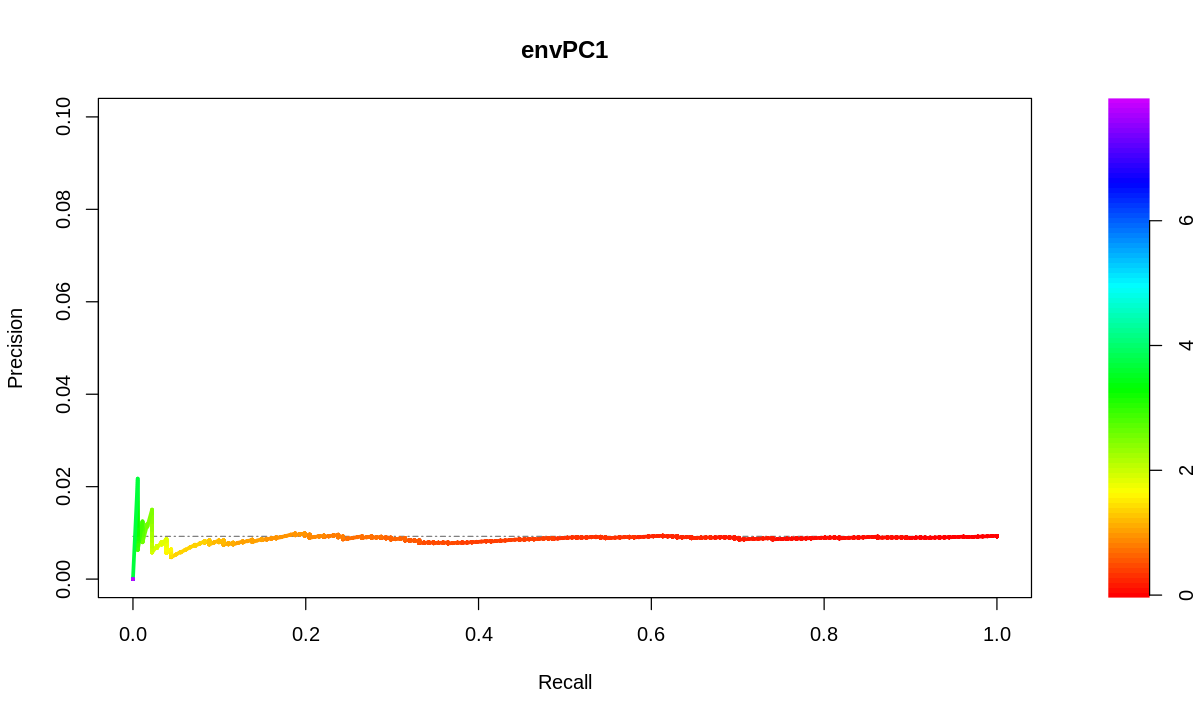

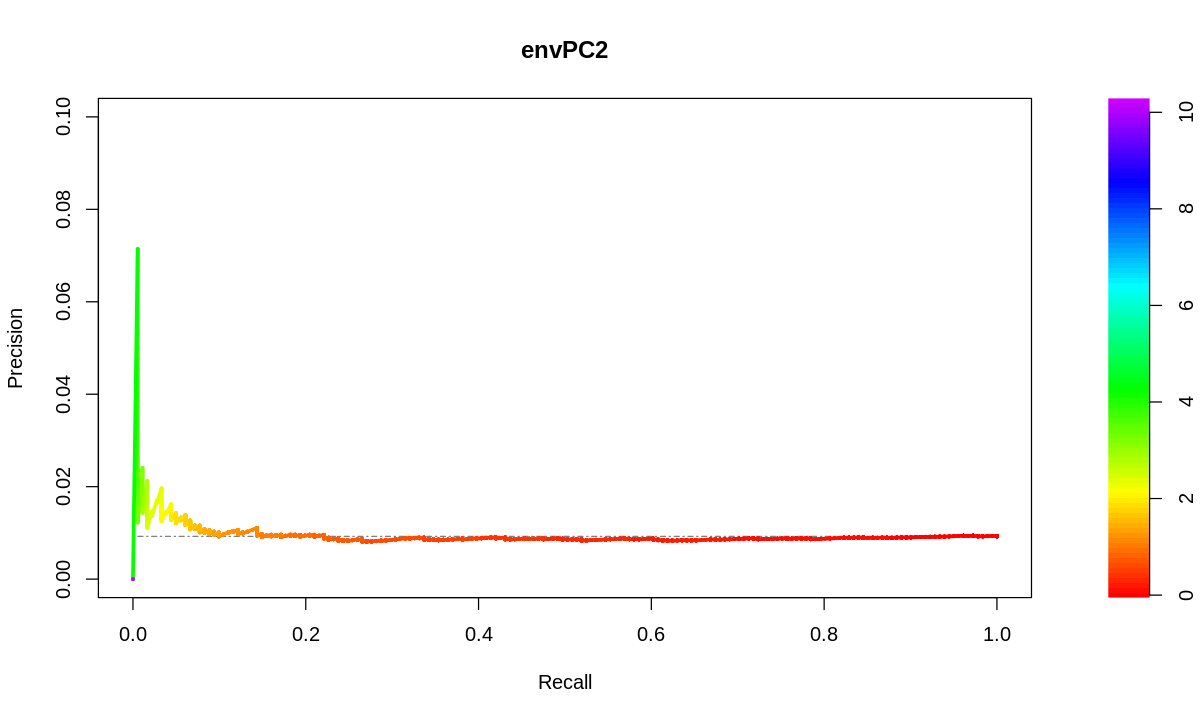

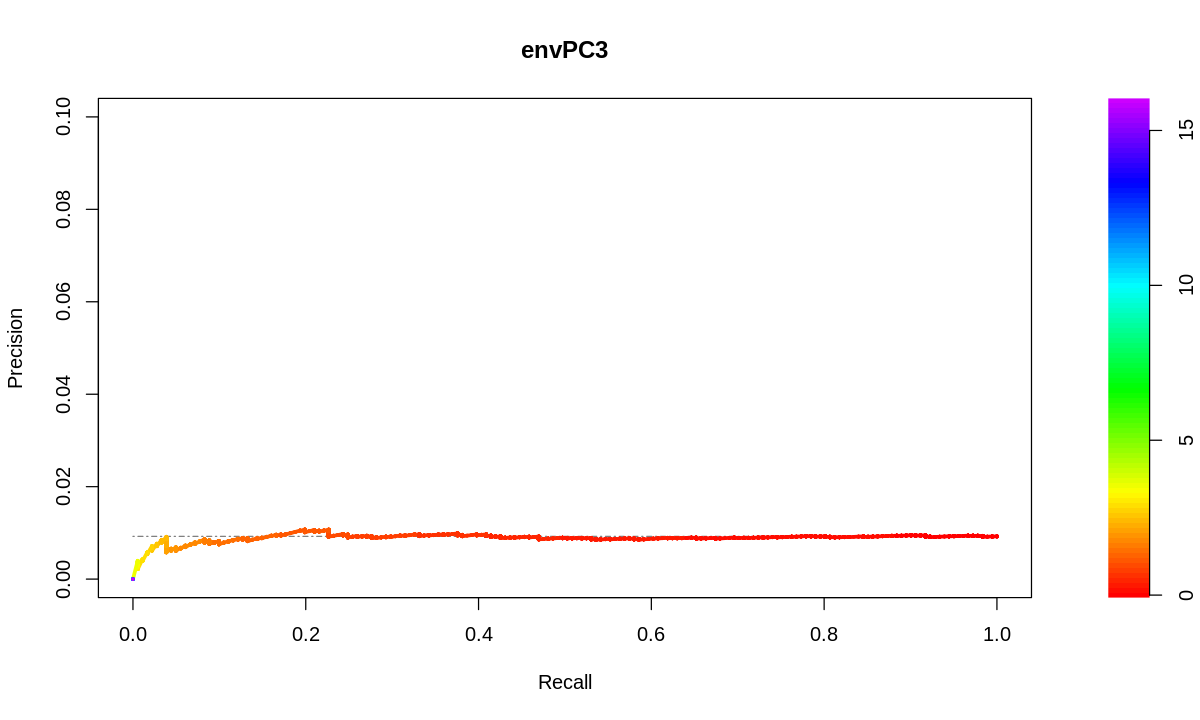

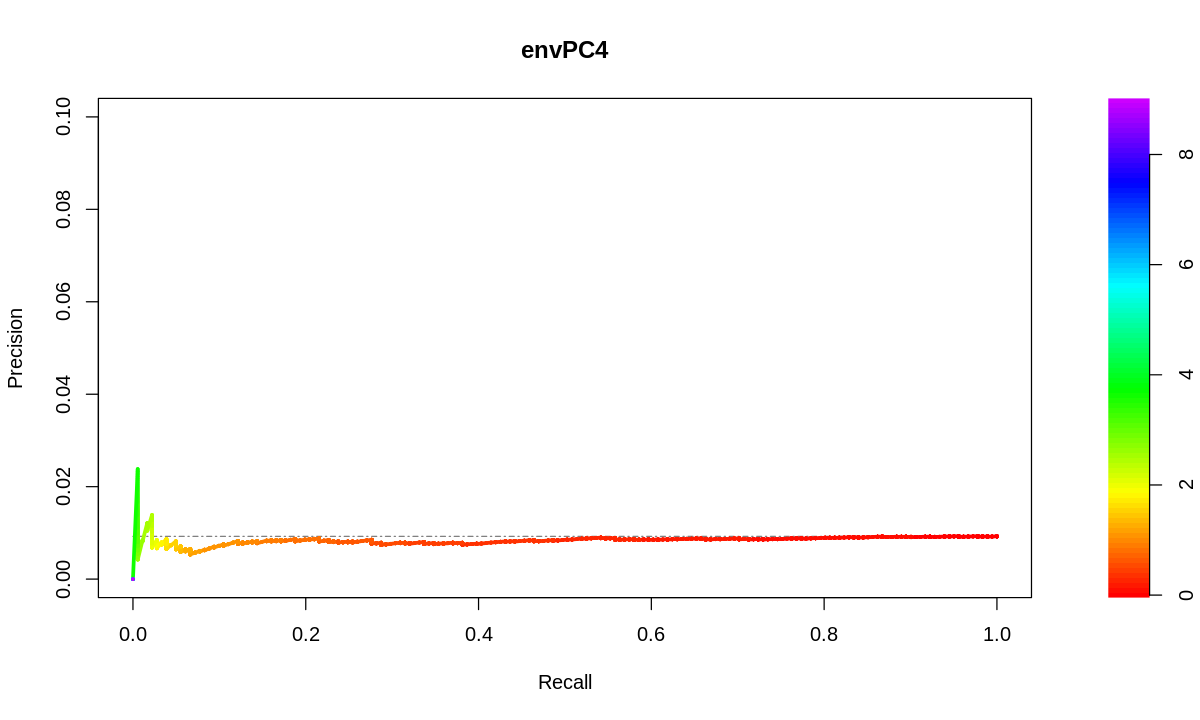

In [671]:
options(repr.plot.width=10, repr.plot.height=6)
for(i in 1:4){
    fg_RAO = -log10(as.numeric(testRes_dnds_andro[,i+11]))[testRes_dnds_andro$OG%in%RAO[,2]]
    bg_RAO = -log10(as.numeric(testRes_dnds_andro[,i+11]))[!testRes_dnds_andro$OG%in%RAO[,2]]

    pr_RAO = pr.curve(scores.class0 = fg_RAO, scores.class1 = bg_RAO[bg_RAO!=Inf], curve = T,rand.compute = T)
    roc_RAO = roc.curve(scores.class0 = fg_RAO, scores.class1 = bg_RAO[bg_RAO!=Inf], curve = T,rand.compute = T)

    plot(pr_RAO,rand.plot = T,ylim = c(0,0.1),auc.main =F,main = paste0("envPC",i))

}


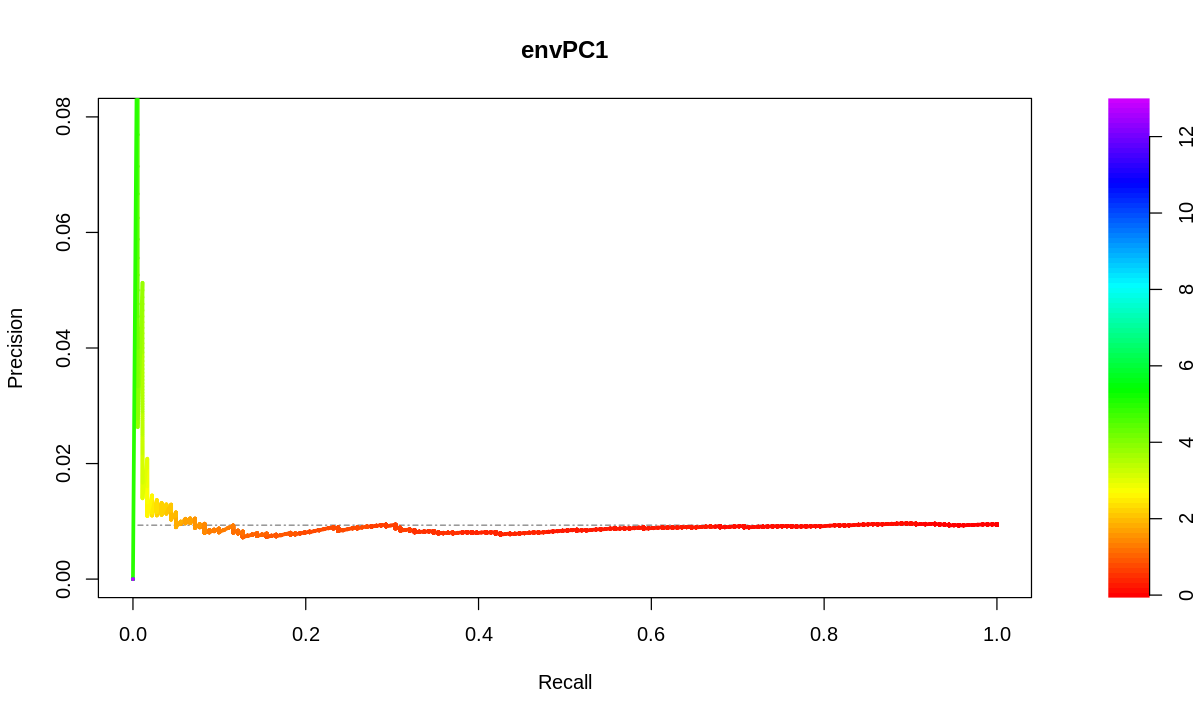

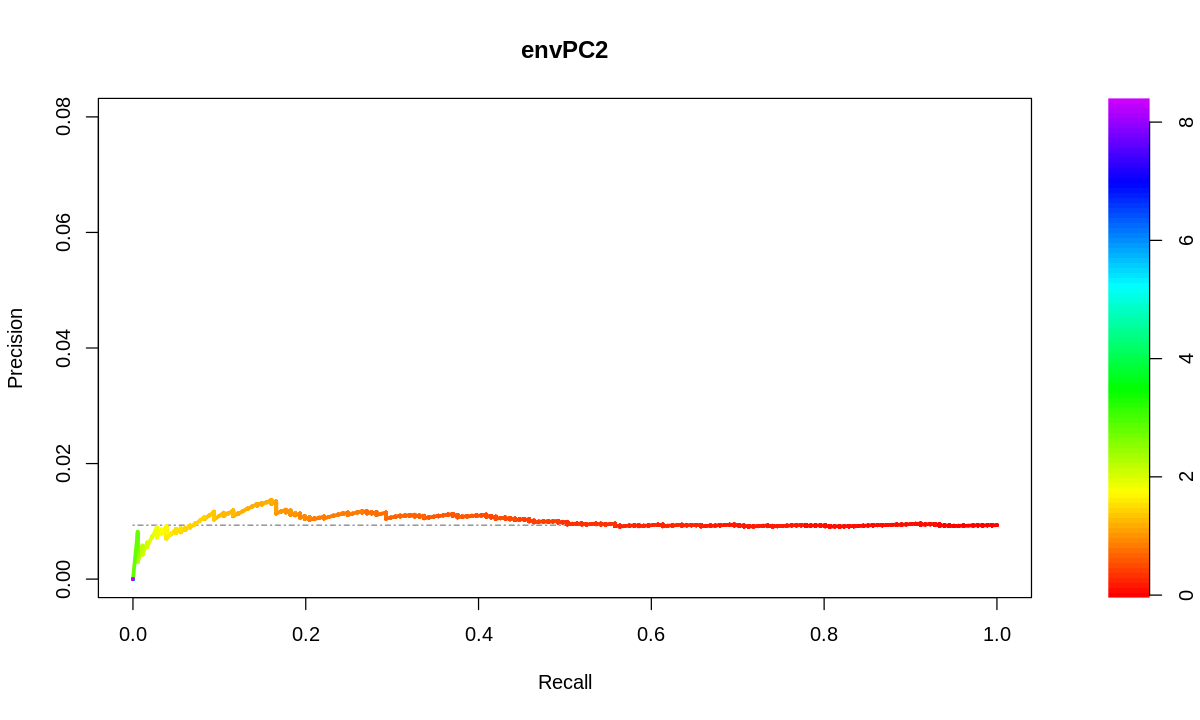

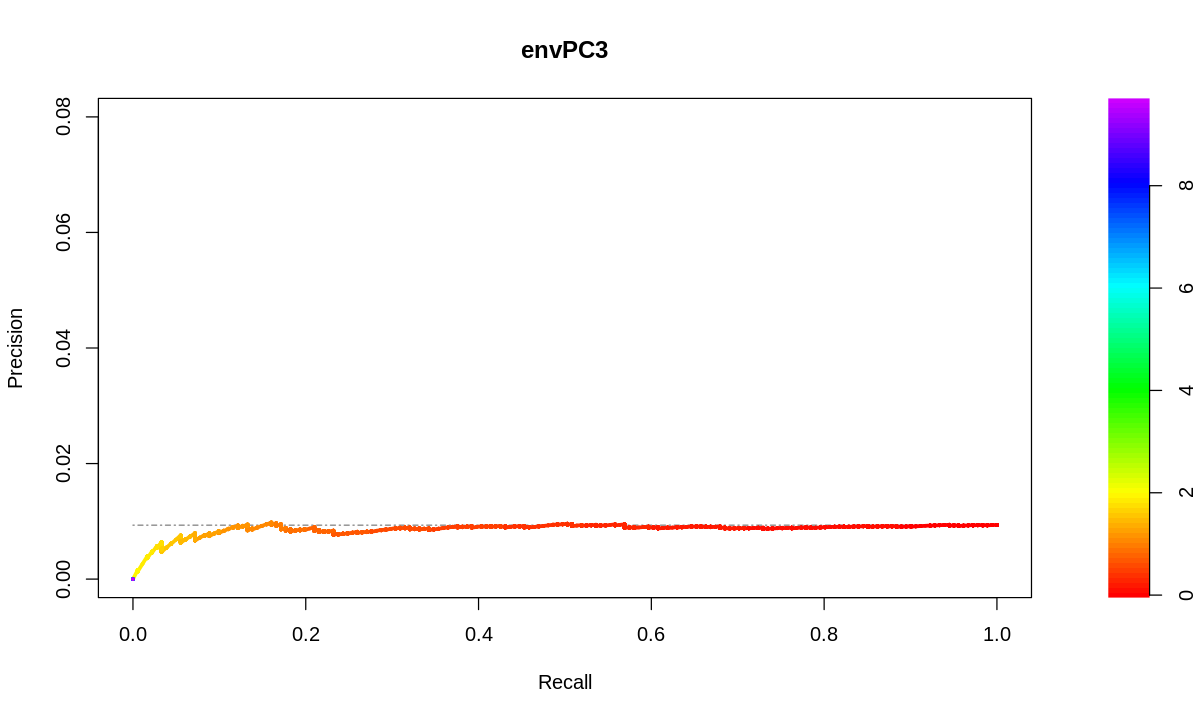

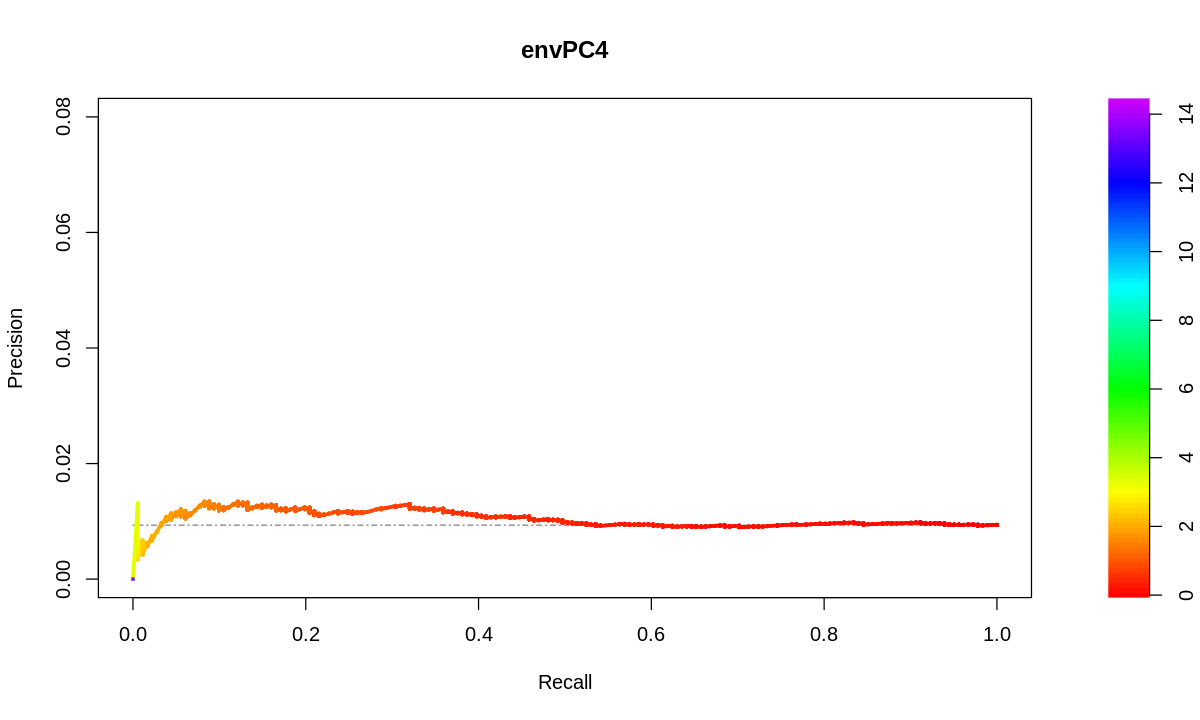

In [957]:
options(repr.plot.width=10, repr.plot.height=6)
for(i in 1:4){
    fg_RAO = -log10(as.numeric(testRes_multiVar[,i+11]))[testRes_multiVar$OG%in%RAO[,2]]
    bg_RAO = -log10(as.numeric(testRes_multiVar[,i+11]))[!testRes_multiVar$OG%in%RAO[,2]]

    pr_RAO = pr.curve(scores.class0 = fg_RAO, scores.class1 = bg_RAO[bg_RAO!=Inf], curve = T,rand.compute = T)
    roc_RAO = roc.curve(scores.class0 = fg_RAO, scores.class1 = bg_RAO[bg_RAO!=Inf], curve = T,rand.compute = T)

    plot(pr_RAO,rand.plot = T,ylim = c(0,0.08),auc.main =F,main = paste0("envPC",i))

}


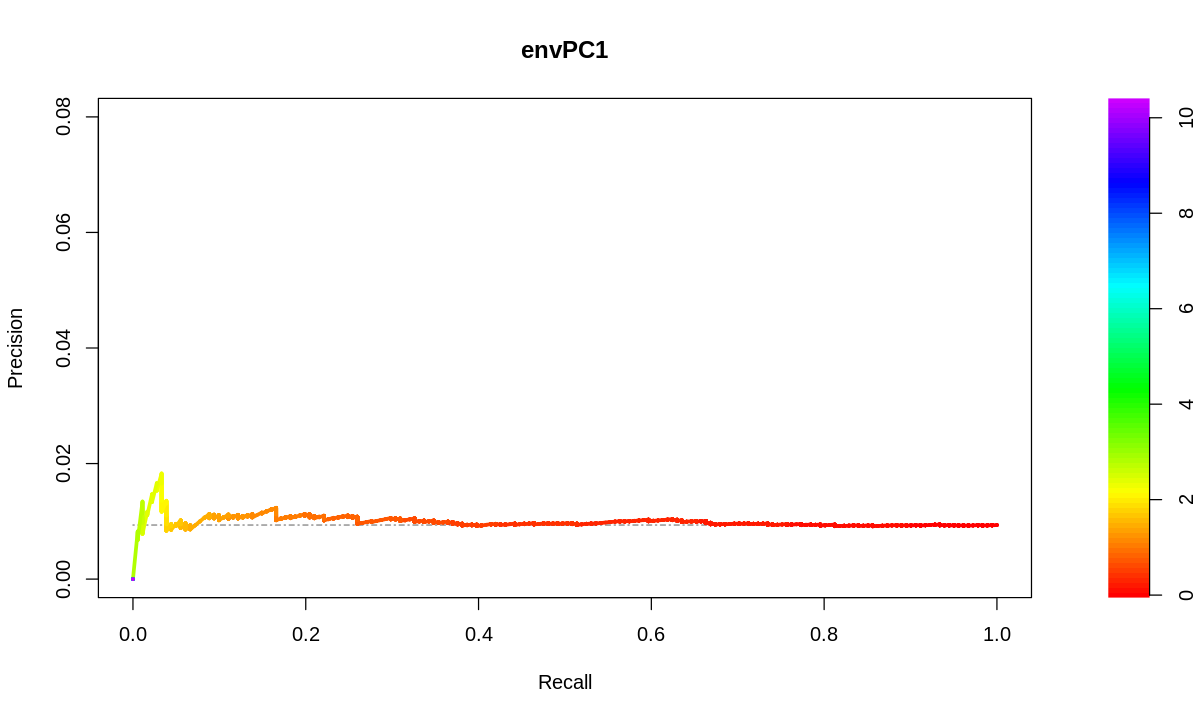

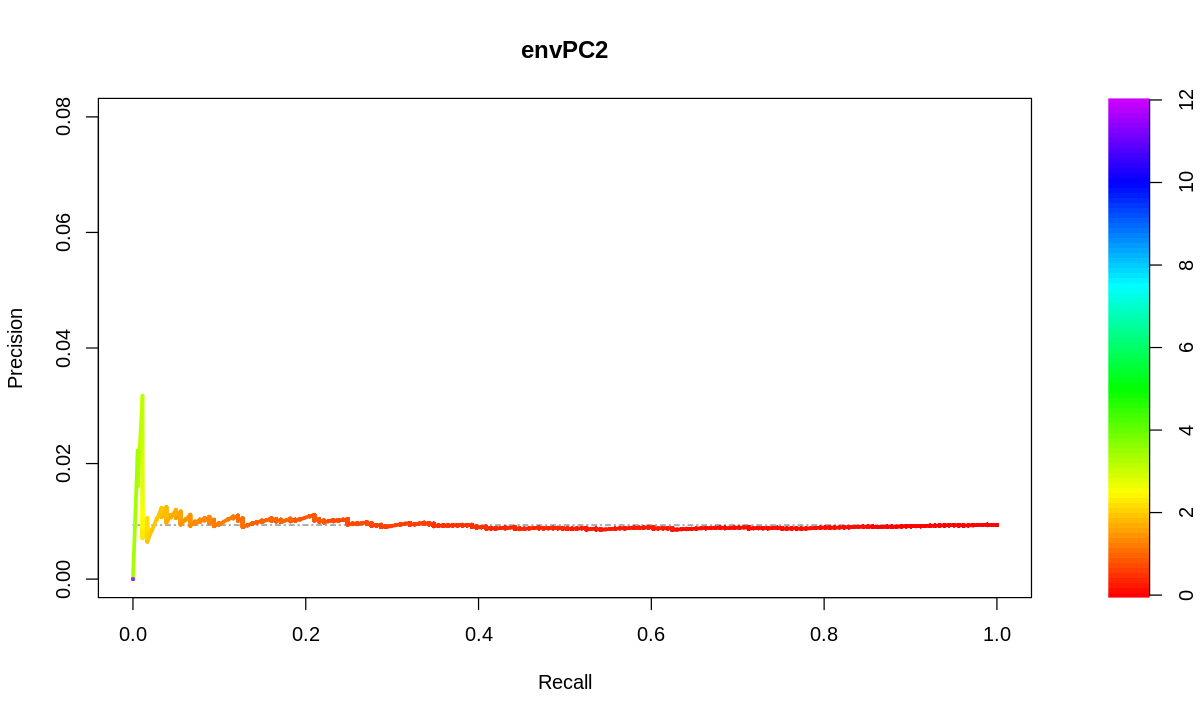

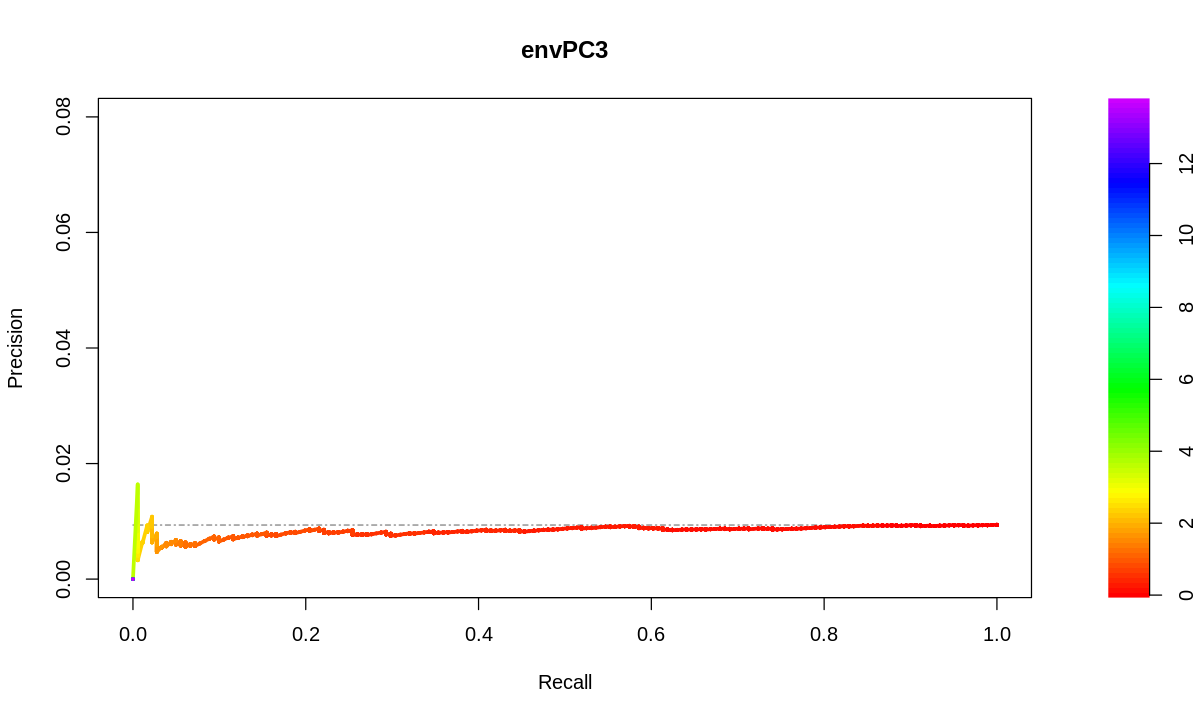

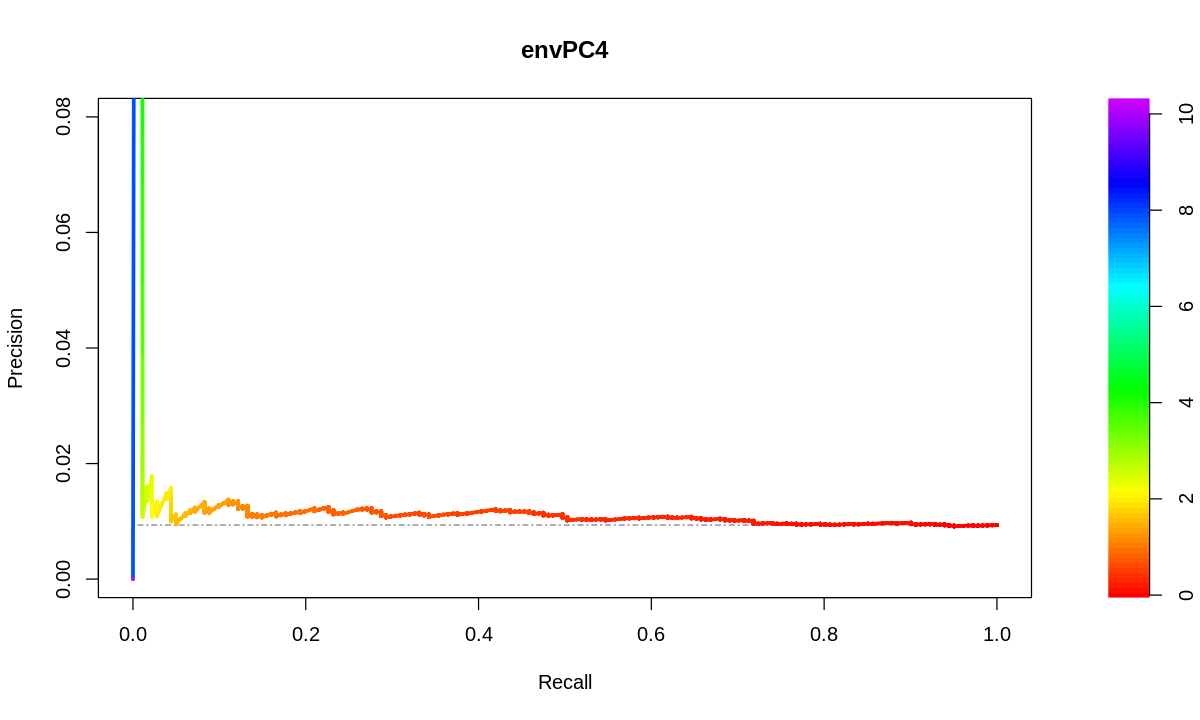

In [956]:
options(repr.plot.width=10, repr.plot.height=6)
for(i in 1:4){
    fg_RAO = -log10(as.numeric(testRes_multiVar_andro[,i+11]))[testRes_multiVar_andro$OG%in%RAO[,2]]
    bg_RAO = -log10(as.numeric(testRes_multiVar_andro[,i+11]))[!testRes_multiVar_andro$OG%in%RAO[,2]]

    pr_RAO = pr.curve(scores.class0 = fg_RAO, scores.class1 = bg_RAO[bg_RAO!=Inf], curve = T,rand.compute = T)
    roc_RAO = roc.curve(scores.class0 = fg_RAO, scores.class1 = bg_RAO[bg_RAO!=Inf], curve = T,rand.compute = T)

    plot(pr_RAO,rand.plot = T,ylim = c(0,0.08),auc.main =F,main = paste0("envPC",i))

}


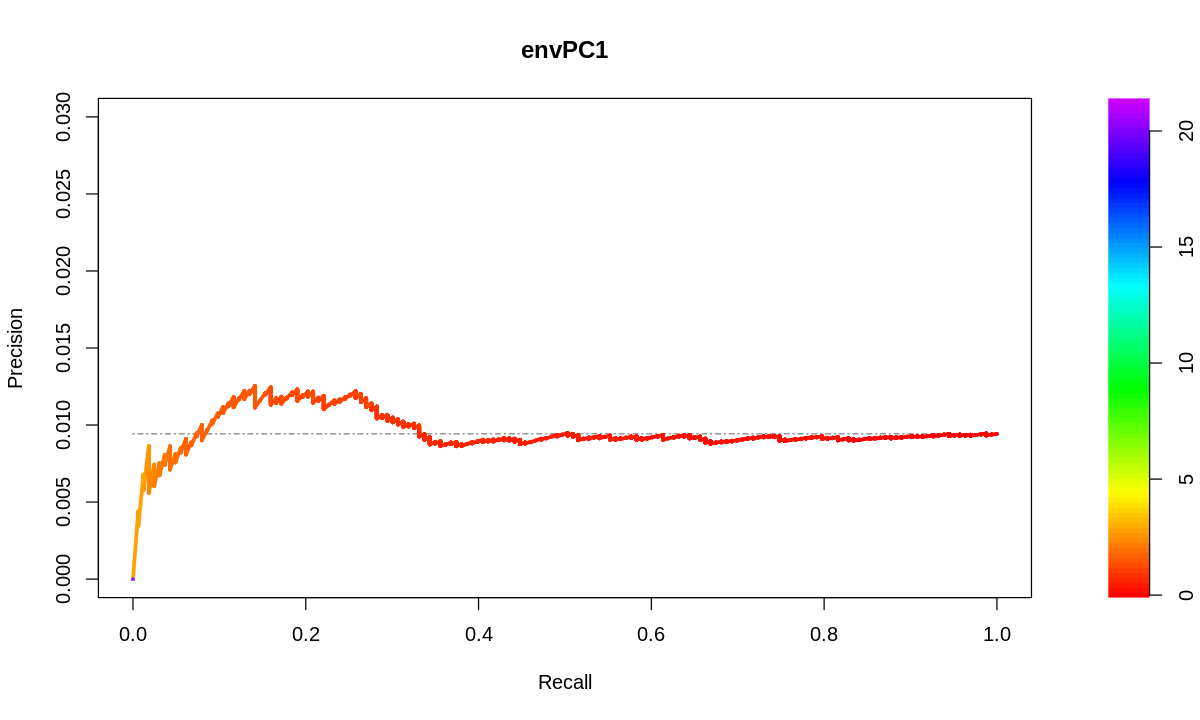

In [363]:
options(repr.plot.width=10, repr.plot.height=6)
fg_RAO = -log10(as.numeric(testRes_envPC1$p))[testRes_envPC1$OG%in%RAO[,2]]
bg_RAO = -log10(as.numeric(testRes_envPC1$p))[!testRes_envPC1$OG%in%RAO[,2]]

pr_RAO = pr.curve(scores.class0 = fg_RAO, scores.class1 = bg_RAO[bg_RAO!=Inf], curve = T,rand.compute = T)
roc_RAO = roc.curve(scores.class0 = fg_RAO, scores.class1 = bg_RAO[bg_RAO!=Inf], curve = T,rand.compute = T)

plot(pr_RAO,rand.plot = T,ylim = c(0,0.03),auc.main =F,main = paste0("envPC1"))



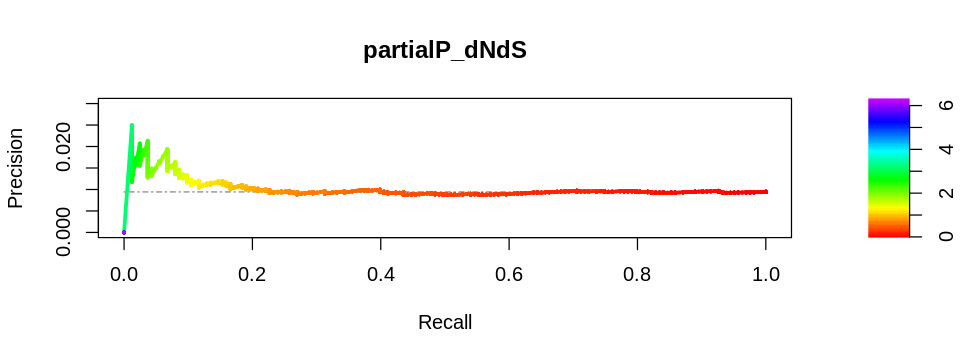

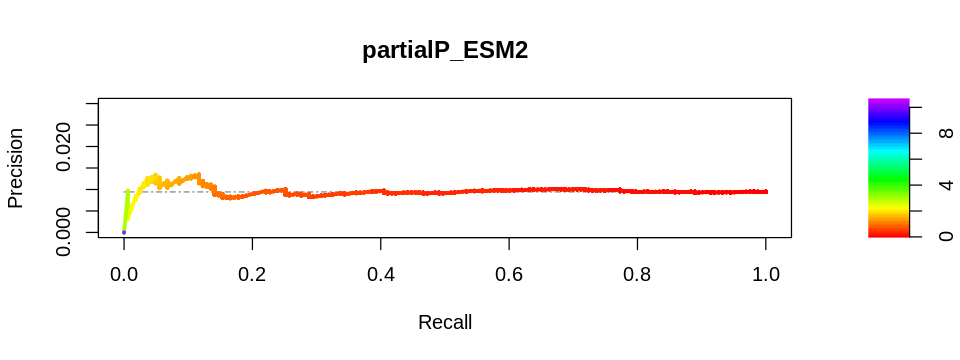

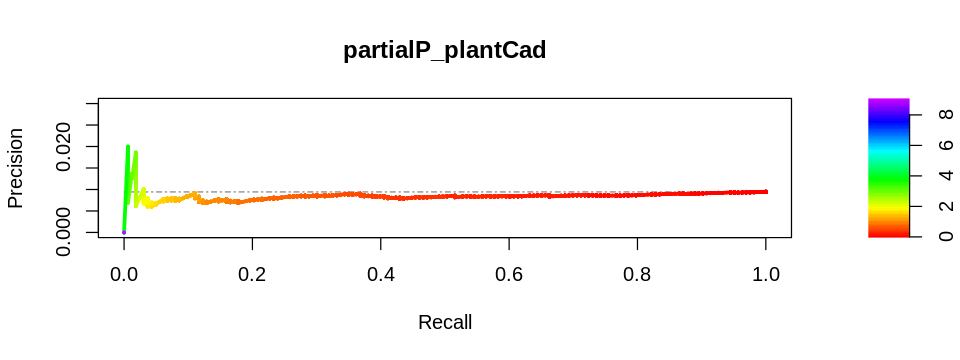

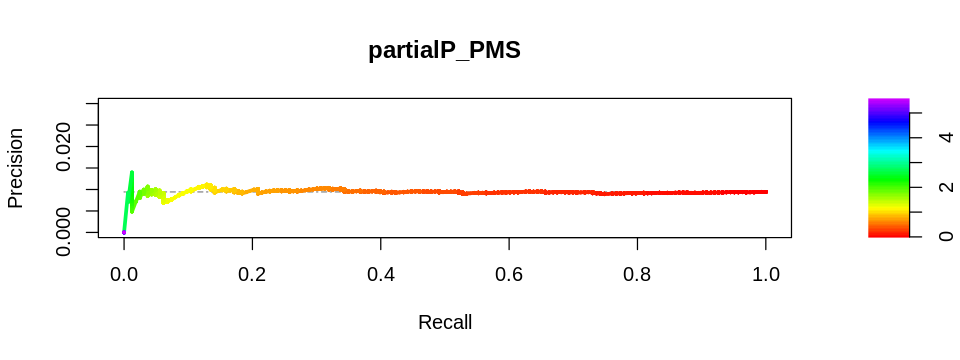

In [364]:
options(repr.plot.width=8, repr.plot.height=3)
for (i in 1:4){
    fg_RAO = -log10(as.numeric(testRes_envPC1[,12+i]))[testRes_envPC1$OG%in%RAO[,2]]
    bg_RAO = -log10(as.numeric(testRes_envPC1[,12+i]))[!testRes_envPC1$OG%in%RAO[,2]]

    pr_RAO = pr.curve(scores.class0 = fg_RAO, scores.class1 = bg_RAO[bg_RAO!=Inf], curve = T,rand.compute = T)
    roc_RAO = roc.curve(scores.class0 = fg_RAO, scores.class1 = bg_RAO[bg_RAO!=Inf], curve = T,rand.compute = T)

    plot(pr_RAO,rand.plot = T,ylim = c(0,0.03),auc.main =F,main = colnames(testRes_envPC1)[12+i])
}


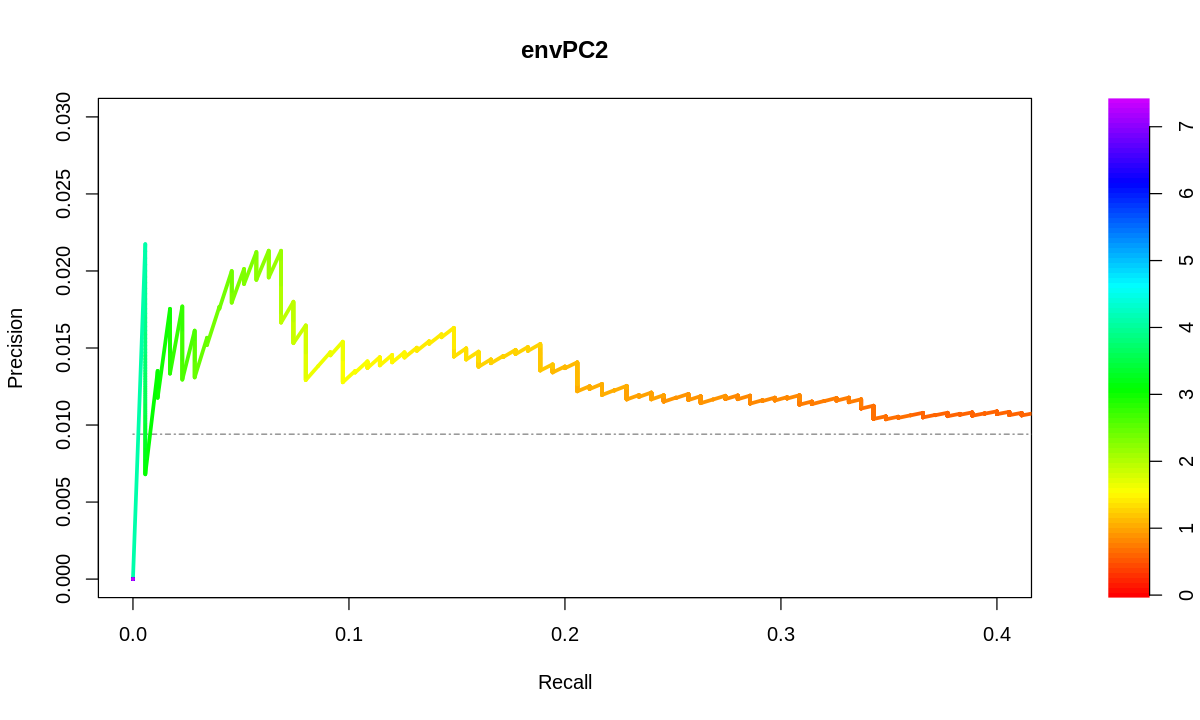

In [264]:
options(repr.plot.width=10, repr.plot.height=6)
fg_RAO = -log10(as.numeric(testRes_envPC2$p))[testRes_envPC2$OG%in%RAO[,2]]
bg_RAO = -log10(as.numeric(testRes_envPC2$p))[!testRes_envPC2$OG%in%RAO[,2]]

pr_RAO = pr.curve(scores.class0 = fg_RAO, scores.class1 = bg_RAO[bg_RAO!=Inf], curve = T,rand.compute = T)
roc_RAO = roc.curve(scores.class0 = fg_RAO, scores.class1 = bg_RAO[bg_RAO!=Inf], curve = T,rand.compute = T)

plot(pr_RAO,rand.plot = T,ylim = c(0,0.03),xlim = c(0,0.4),auc.main =F,main = paste0("envPC2"))



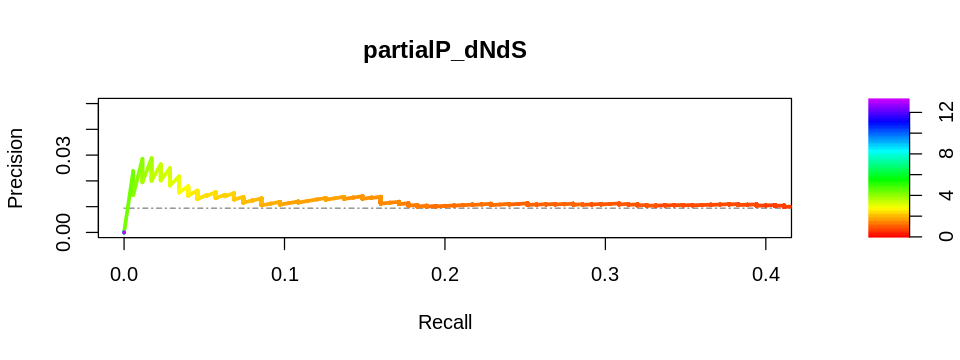

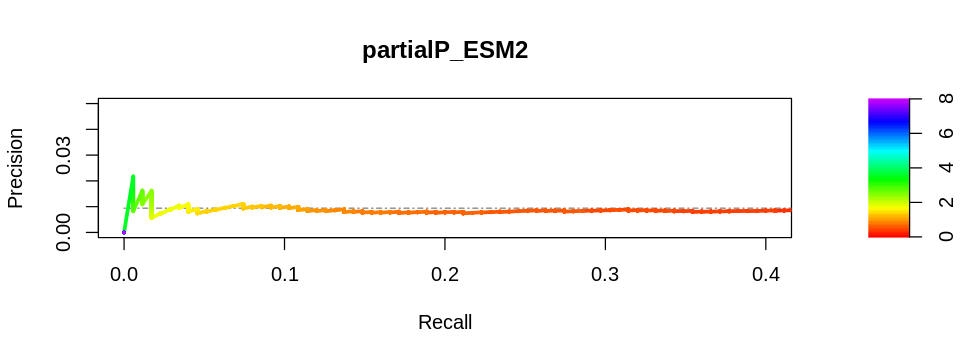

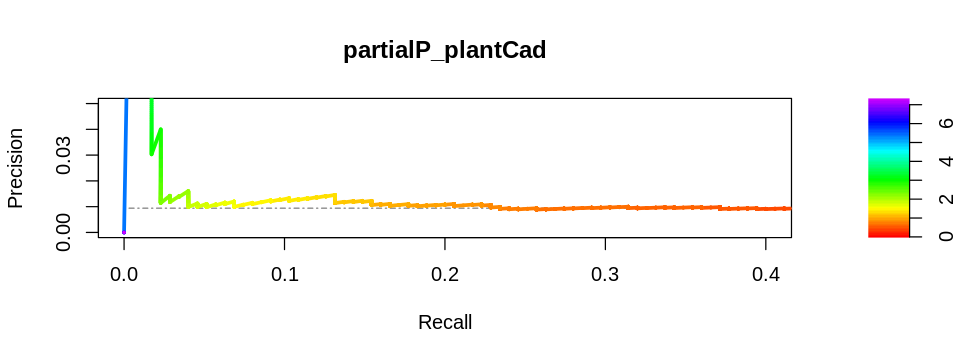

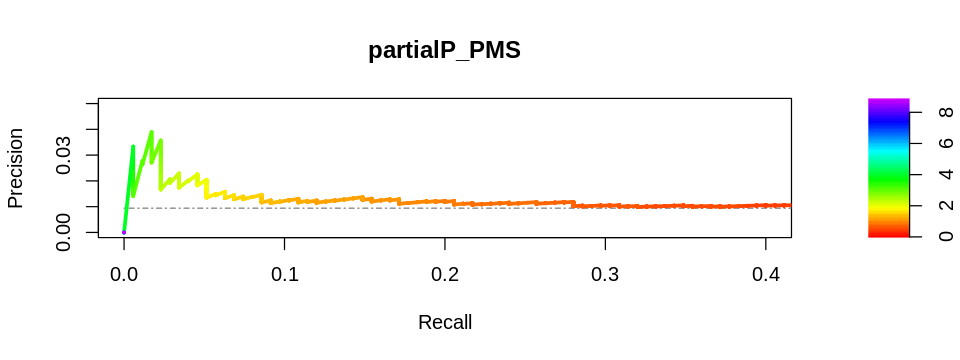

In [266]:
options(repr.plot.width=8, repr.plot.height=3)
for (i in 1:4){
    fg_RAO = -log10(as.numeric(testRes_envPC2[,12+i]))[testRes_envPC2$OG%in%RAO[,2]]
    bg_RAO = -log10(as.numeric(testRes_envPC2[,12+i]))[!testRes_envPC2$OG%in%RAO[,2]]

    pr_RAO = pr.curve(scores.class0 = fg_RAO, scores.class1 = bg_RAO[bg_RAO!=Inf], curve = T,rand.compute = T)
    roc_RAO = roc.curve(scores.class0 = fg_RAO, scores.class1 = bg_RAO[bg_RAO!=Inf], curve = T,rand.compute = T)

    plot(pr_RAO,rand.plot = T,ylim = c(0,0.05),xlim = c(0,0.4),auc.main =F,main = colnames(testRes_envPC2)[12+i])
}


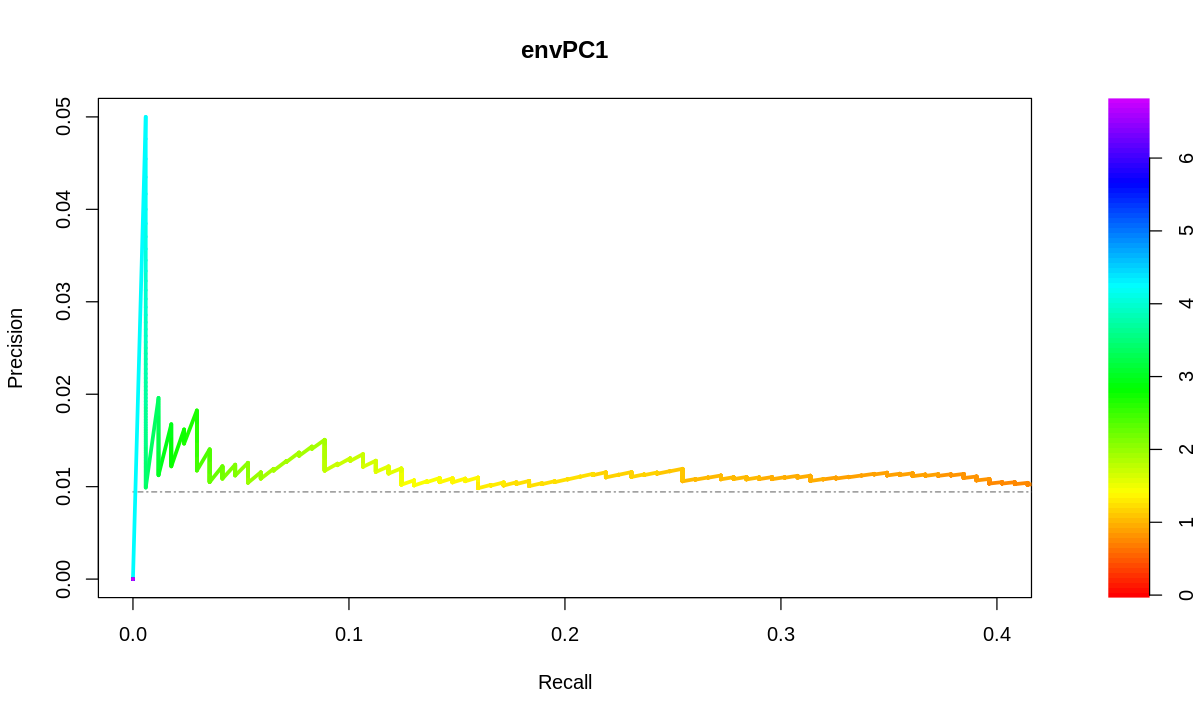

In [365]:
options(repr.plot.width=10, repr.plot.height=6)
fg_RAO = -log10(as.numeric(testRes_envPC1_v2$p))[testRes_envPC1_v2$OG%in%RAO[,2]]
bg_RAO = -log10(as.numeric(testRes_envPC1_v2$p))[!testRes_envPC1_v2$OG%in%RAO[,2]]

pr_RAO = pr.curve(scores.class0 = fg_RAO, scores.class1 = bg_RAO[bg_RAO!=Inf], curve = T,rand.compute = T)
roc_RAO = roc.curve(scores.class0 = fg_RAO, scores.class1 = bg_RAO[bg_RAO!=Inf], curve = T,rand.compute = T)

plot(pr_RAO,rand.plot = T,ylim = c(0,0.05),xlim = c(0,0.4),auc.main =F,main = paste0("envPC1"))



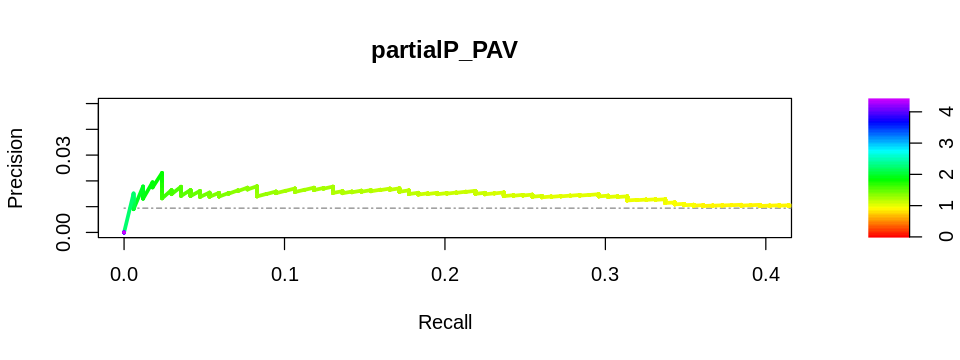

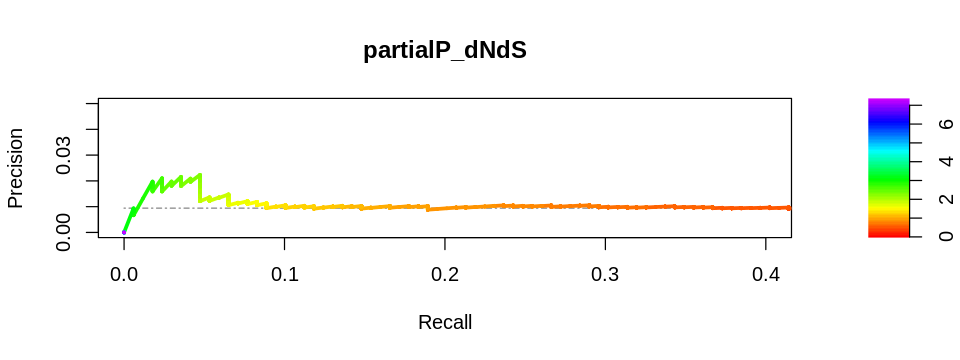

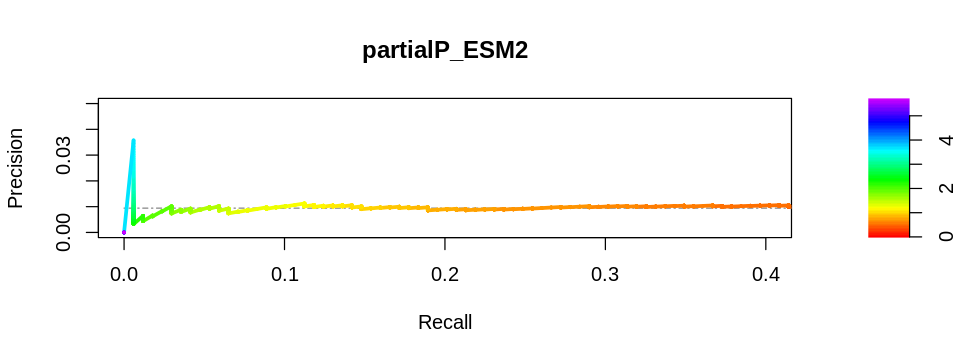

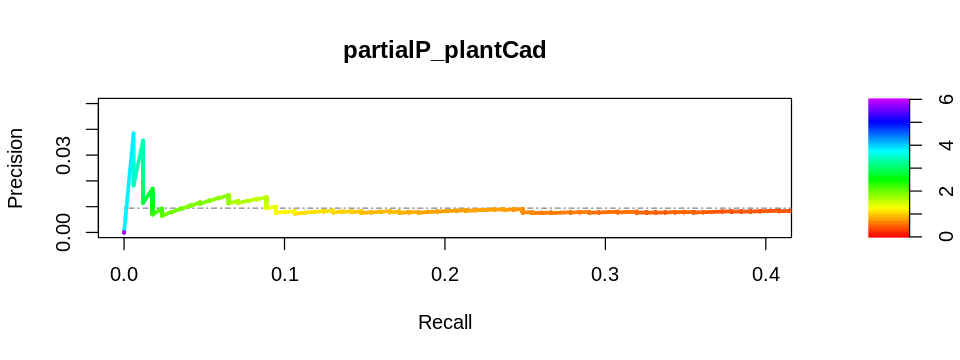

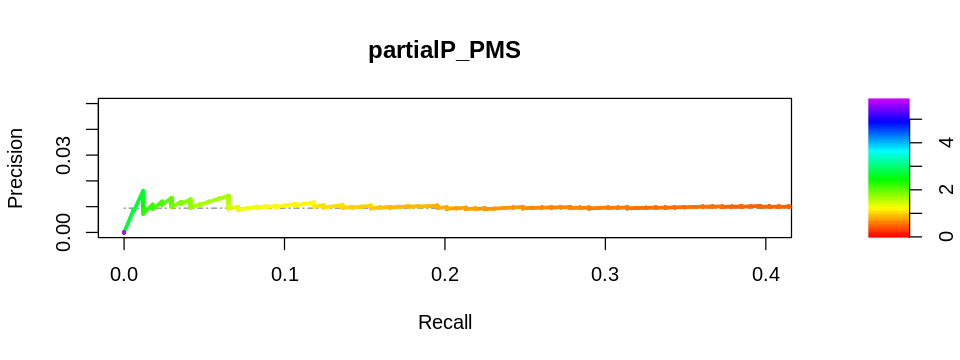

In [368]:
options(repr.plot.width=8, repr.plot.height=3)
for (i in 1:5){
    fg_RAO = na.omit(-log10(as.numeric(testRes_envPC1_v2[,13+i]))[testRes_envPC1_v2$OG%in%RAO[,2]])
    bg_RAO = na.omit(-log10(as.numeric(testRes_envPC1_v2[,13+i]))[!testRes_envPC1_v2$OG%in%RAO[,2]])

    pr_RAO = pr.curve(scores.class0 = fg_RAO, scores.class1 = bg_RAO[bg_RAO!=Inf], curve = T,rand.compute = T)
    roc_RAO = roc.curve(scores.class0 = fg_RAO, scores.class1 = bg_RAO[bg_RAO!=Inf], curve = T,rand.compute = T)

    plot(pr_RAO,rand.plot = T,ylim = c(0,0.05),xlim = c(0,0.4),auc.main =F,main = colnames(testRes_envPC1_v2)[13+i])
}


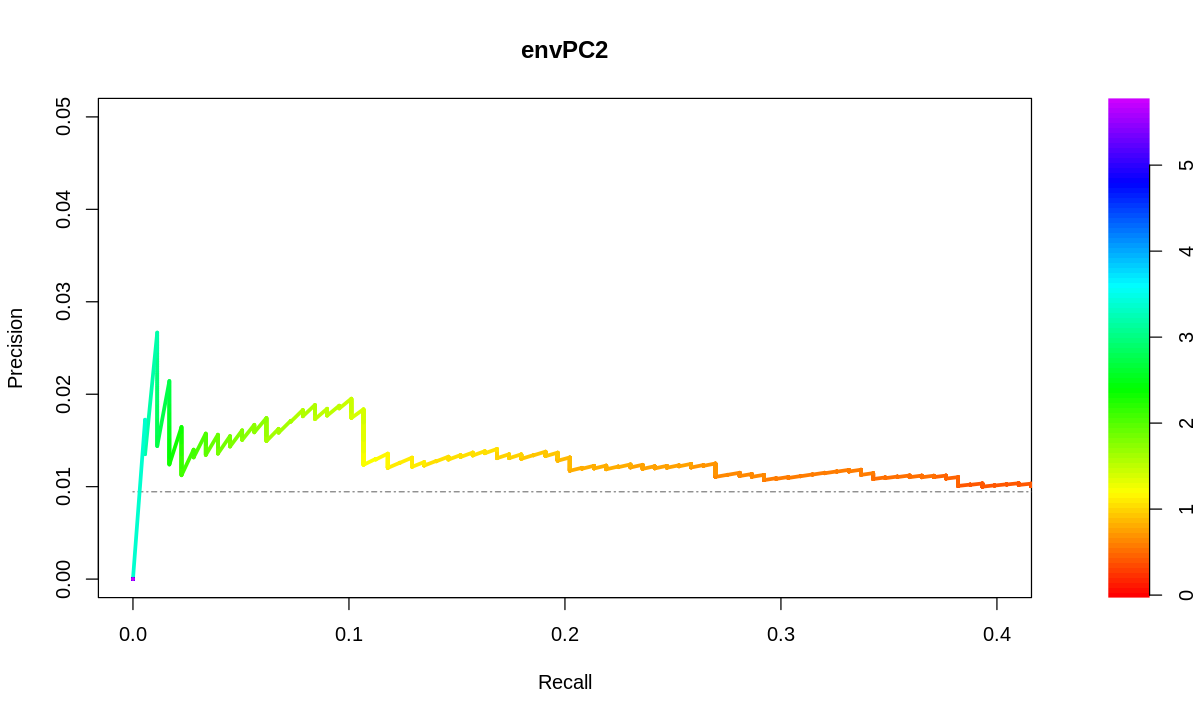

In [369]:
options(repr.plot.width=10, repr.plot.height=6)
fg_RAO = -log10(as.numeric(testRes_envPC2_v2$p))[testRes_envPC2_v2$OG%in%RAO[,2]]
bg_RAO = -log10(as.numeric(testRes_envPC2_v2$p))[!testRes_envPC2_v2$OG%in%RAO[,2]]

pr_RAO = pr.curve(scores.class0 = fg_RAO, scores.class1 = bg_RAO[bg_RAO!=Inf], curve = T,rand.compute = T)
roc_RAO = roc.curve(scores.class0 = fg_RAO, scores.class1 = bg_RAO[bg_RAO!=Inf], curve = T,rand.compute = T)

plot(pr_RAO,rand.plot = T,ylim = c(0,0.05),xlim = c(0,0.4),auc.main =F,main = paste0("envPC2"))



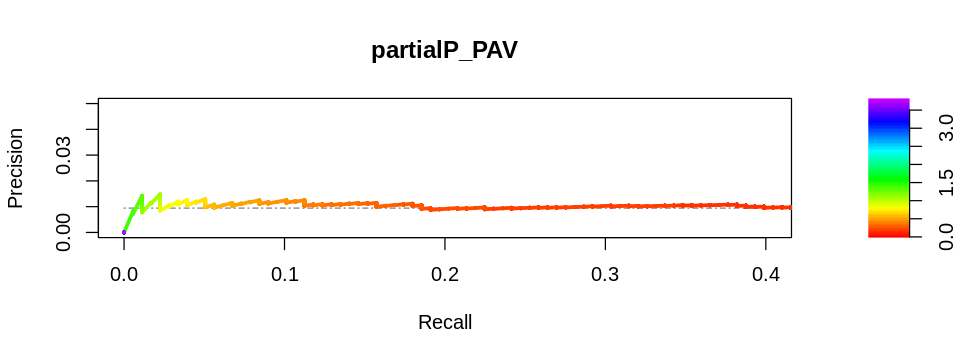

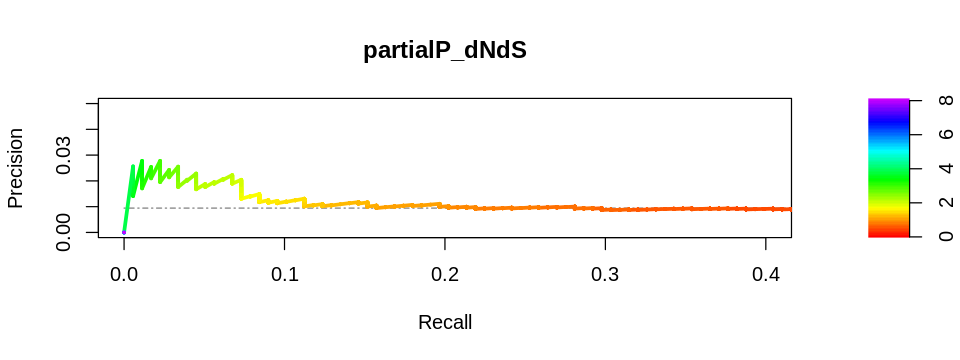

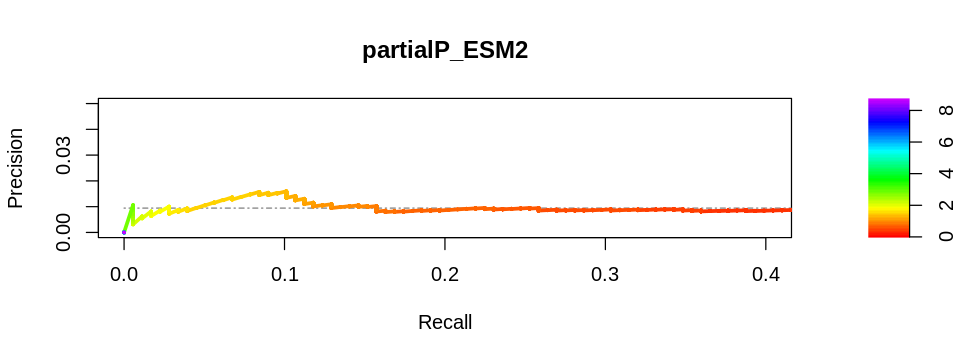

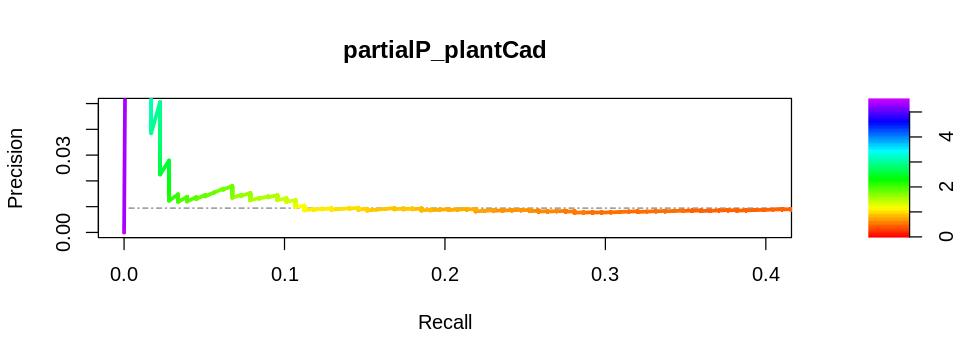

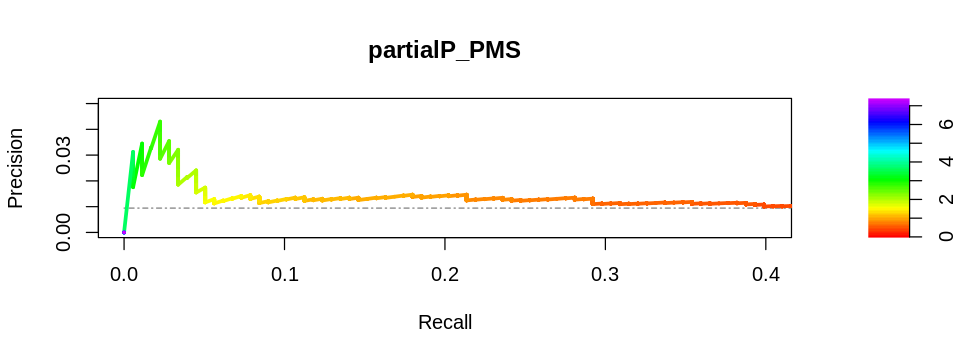

In [370]:
options(repr.plot.width=8, repr.plot.height=3)
for (i in 1:5){
    fg_RAO = na.omit(-log10(as.numeric(testRes_envPC2_v2[,13+i]))[testRes_envPC2_v2$OG%in%RAO[,2]])
    bg_RAO = na.omit(-log10(as.numeric(testRes_envPC2_v2[,13+i]))[!testRes_envPC2_v2$OG%in%RAO[,2]])

    pr_RAO = pr.curve(scores.class0 = fg_RAO, scores.class1 = bg_RAO[bg_RAO!=Inf], curve = T,rand.compute = T)
    roc_RAO = roc.curve(scores.class0 = fg_RAO, scores.class1 = bg_RAO[bg_RAO!=Inf], curve = T,rand.compute = T)

    plot(pr_RAO,rand.plot = T,ylim = c(0,0.05),xlim = c(0,0.4),auc.main =F,main = colnames(testRes_envPC1_v2)[13+i])
}


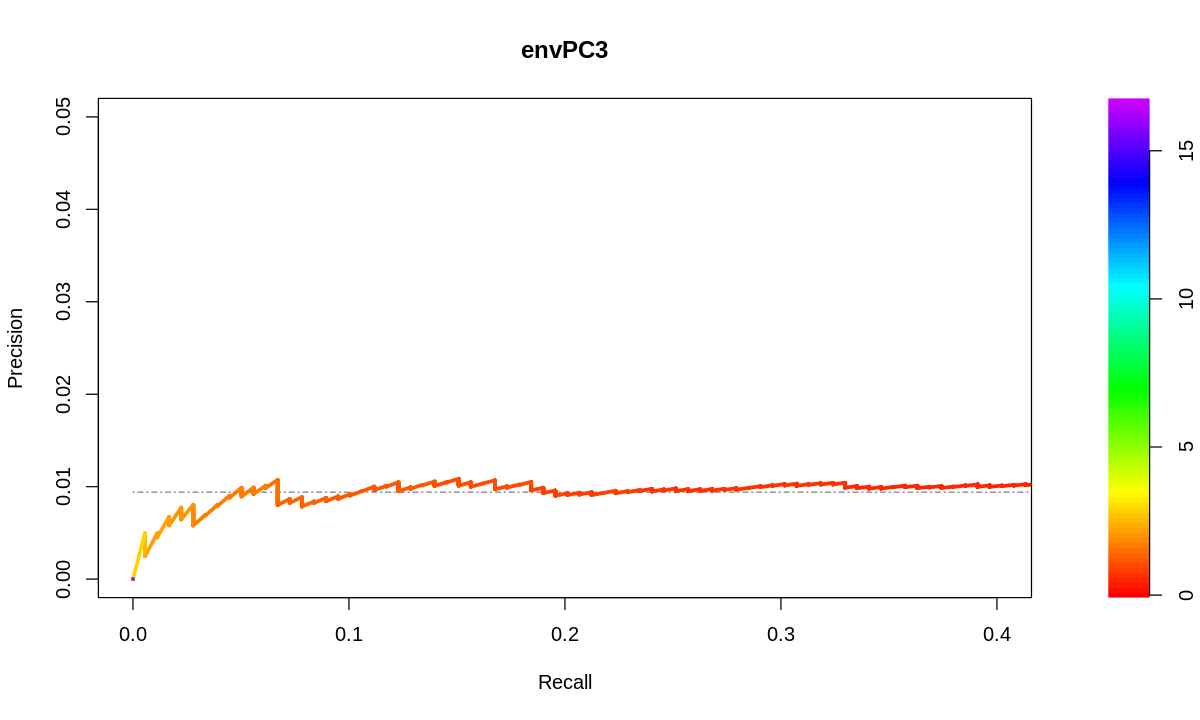

In [373]:
options(repr.plot.width=10, repr.plot.height=6)
fg_RAO = -log10(as.numeric(testRes_envPC3_v2$p))[testRes_envPC3_v2$OG%in%RAO[,2]]
bg_RAO = -log10(as.numeric(testRes_envPC3_v2$p))[!testRes_envPC3_v2$OG%in%RAO[,2]]

pr_RAO = pr.curve(scores.class0 = fg_RAO, scores.class1 = bg_RAO[bg_RAO!=Inf], curve = T,rand.compute = T)
roc_RAO = roc.curve(scores.class0 = fg_RAO, scores.class1 = bg_RAO[bg_RAO!=Inf], curve = T,rand.compute = T)

plot(pr_RAO,rand.plot = T,ylim = c(0,0.05),xlim = c(0,0.4),auc.main =F,main = paste0("envPC3"))



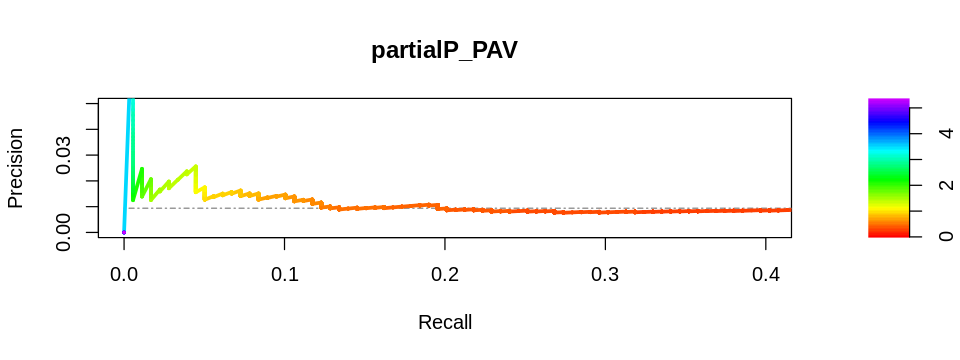

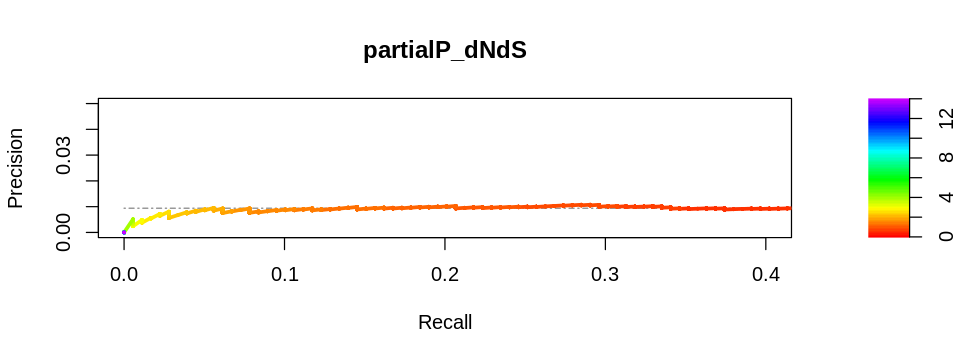

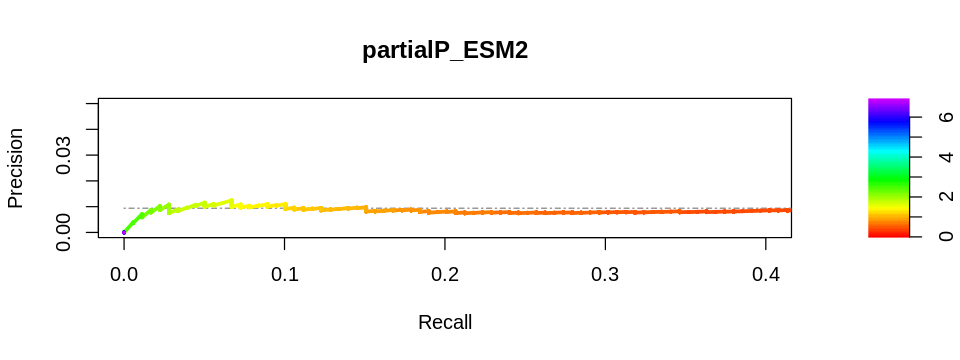

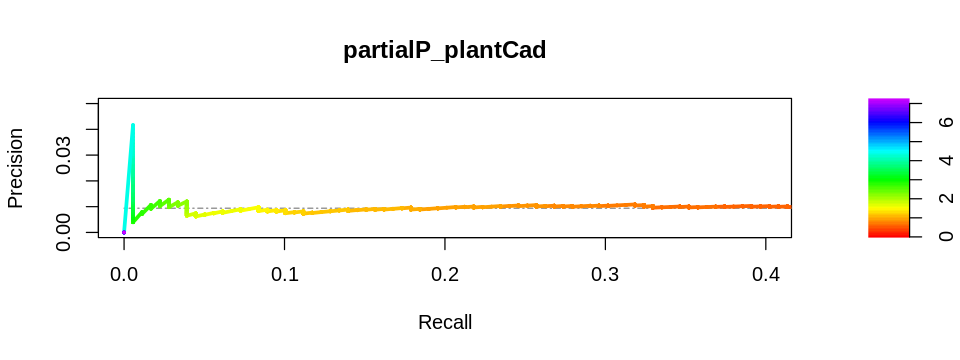

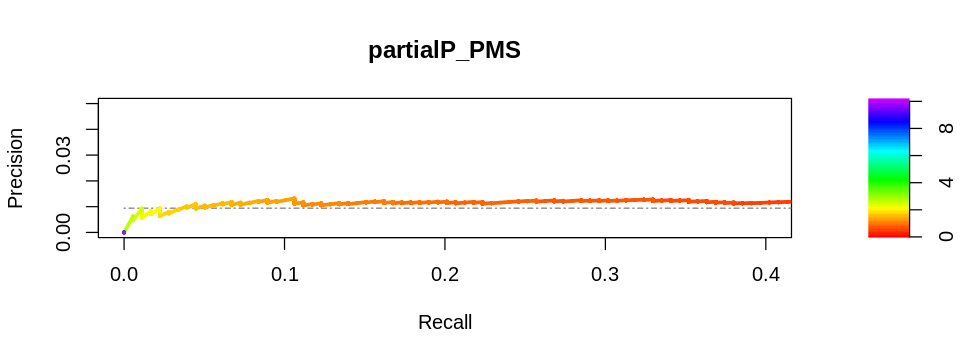

In [375]:
options(repr.plot.width=8, repr.plot.height=3)
for (i in 1:5){
    fg_RAO = na.omit(-log10(as.numeric(testRes_envPC3_v2[,13+i]))[testRes_envPC3_v2$OG%in%RAO[,2]])
    bg_RAO = na.omit(-log10(as.numeric(testRes_envPC3_v2[,13+i]))[!testRes_envPC3_v2$OG%in%RAO[,2]])

    pr_RAO = pr.curve(scores.class0 = fg_RAO, scores.class1 = bg_RAO[bg_RAO!=Inf], curve = T,rand.compute = T)
    roc_RAO = roc.curve(scores.class0 = fg_RAO, scores.class1 = bg_RAO[bg_RAO!=Inf], curve = T,rand.compute = T)

    plot(pr_RAO,rand.plot = T,ylim = c(0,0.05),xlim = c(0,0.4),auc.main =F,main = colnames(testRes_envPC3_v2)[13+i])
}


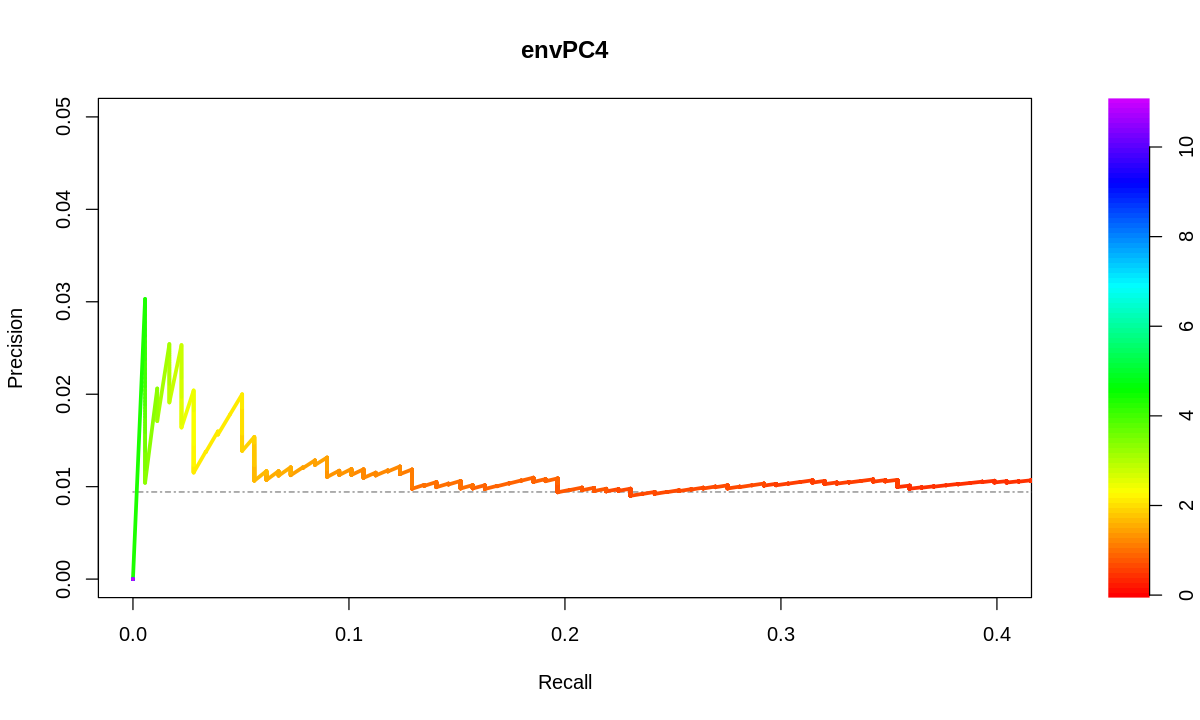

In [374]:
options(repr.plot.width=10, repr.plot.height=6)
fg_RAO = -log10(as.numeric(testRes_envPC4_v2$p))[testRes_envPC4_v2$OG%in%RAO[,2]]
bg_RAO = -log10(as.numeric(testRes_envPC4_v2$p))[!testRes_envPC4_v2$OG%in%RAO[,2]]

pr_RAO = pr.curve(scores.class0 = fg_RAO, scores.class1 = bg_RAO[bg_RAO!=Inf], curve = T,rand.compute = T)
roc_RAO = roc.curve(scores.class0 = fg_RAO, scores.class1 = bg_RAO[bg_RAO!=Inf], curve = T,rand.compute = T)

plot(pr_RAO,rand.plot = T,ylim = c(0,0.05),xlim = c(0,0.4),auc.main =F,main = paste0("envPC4"))



In [269]:
colnames(testRes_envPC1_v2)

[1] "OG"                    "BIC_full"              "BIC_reduced"          
 [4] "LR"                    "p"                     "geneVAE"              
 [7] "phyloVAE"              "totalVar"              "partialCoeff_dNdS"    
[10] "partialCoeff_ESM2"     "partialCoeff_plantCad" "partialCoeff_PMS"     
[13] "partialCoeff_PAV"      "partialP_dNdS"         "partialP_ESM2"        
[16] "partialP_plantCad"     "partialP_PMS"          "partialP_PAV"         
[19] "PvID"                  "ZmID"

In [1621]:
table(testRes_envPC1$OG%in%intersect(envPC1Candidates[[1]],Reduce("union",envPC1Candidates[2:5])),testRes_envPC1$OG%in%RAO[,2])

       
        FALSE  TRUE
  FALSE 16981   163
  TRUE    143     0

In [163]:
fisher.test(table(testRes_envPC2$OG%in%intersect(envPC2Candidates[[1]],Reduce("union",envPC2Candidates[2:5])),testRes_envPC2$OG%in%RAO[,2]))


	Fisher's Exact Test for Count Data

data:  table(testRes_envPC2$OG %in% intersect(envPC2Candidates[[1]], Reduce("union", envPC2Candidates[2:5])), testRes_envPC2$OG %in% RAO[, 2])
p-value = 0.1566
alternative hypothesis: true odds ratio is not equal to 1
95 percent confidence interval:
 0.453223 6.807871
sample estimates:
odds ratio 
  2.245671 


In [261]:
table(testRes_envPC1_v2$p < 9e-5,testRes_envPC1_v2$OG%in%RAO[,2])
fisher.test(table(testRes_envPC1_v2$p < 6e-5,testRes_envPC1_v2$OG%in%RAO[,2]))

       
        FALSE  TRUE
  FALSE 17719   168
  TRUE     29     1


	Fisher's Exact Test for Count Data

data:  table(testRes_envPC1_v2$p < 6e-05, testRes_envPC1_v2$OG %in% RAO[, 2])
p-value = 0.1883
alternative hypothesis: true odds ratio is not equal to 1
95 percent confidence interval:
  0.1207906 31.5769939
sample estimates:
odds ratio 
  5.022863 


In [1534]:
17500*0.05

[1] 875

In [1529]:
intersect(intersect(envPC1Candidates[[1]],Reduce("union",envPC1Candidates[2:5])),RAO[,2])

[1] "OG0015194"

[1] 0.09838974

       
        FALSE  TRUE
  FALSE 18618   363
  TRUE    363    37


	Fisher's Exact Test for Count Data

data:  contTab
p-value = 2.383e-14
alternative hypothesis: true odds ratio is not equal to 1
95 percent confidence interval:
 3.564861 7.477410
sample estimates:
odds ratio 
  5.226615 


,OG,Coeff_envPC1,Coeff_envPC2,Coeff_envPC3,Coeff_envPC4,Coeff_envPC5,Coeff_envPC6,Coeff_envPC7,Coeff_envPC8,Coeff_envPC9,⋯,VAE_envPC3,VAE_envPC4,VAE_envPC5,VAE_envPC6,VAE_envPC7,VAE_envPC8,VAE_envPC9,VAE_envPC10,PvID,ZmID
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
1413,OG0002226,0.14661744,-0.008498189,0.032341241,0.068465883,-0.040819365,-0.10685893,7.086941e-02,0.007903524,-0.103422874,⋯,2.367048e-02,0.106762410,0.0288289808,0.210445542,0.0955113296,7.709733e-05,1.788606e-01,0.051653952,Pavag04G151100.1,Zm00001eb181400_T001
2437,OG0003382,0.14473245,0.012521716,0.011968186,-0.009024374,0.032917686,0.05392748,-8.640915e-03,-0.022879072,-0.026256248,⋯,4.670862e-03,0.006843557,0.0163362192,0.051307847,0.0009021068,9.585746e-03,1.692240e-02,0.001893876,Pavag09G248300.1,Zm00001eb252160_T001
5058,OG0006552,0.16919041,-0.016955810,0.029092274,0.009368645,-0.049374151,0.03576173,-4.743535e-05,-0.058217678,0.022757866,⋯,9.654272e-03,0.002035005,0.0695385883,0.035676329,0.0028665738,6.030132e-02,1.757149e-02,0.012669767,Pavag02G396600.1,Zm00001eb111800_T001
5292,OG0006827,-0.67413239,0.060771096,-0.128926503,-0.087841697,0.215593015,-0.11902634,-6.313175e-02,-0.173962420,0.034306699,⋯,1.302335e-02,0.027032447,0.1246107340,0.078390539,0.0074368151,5.560364e-02,7.208249e-04,0.120525399,PavagK116300.1,Zm00001eb105230_T002
6806,OG0008524,0.13458487,0.063094209,0.079797190,-0.077913230,-0.026298738,0.04375227,6.160956e-03,0.001539291,0.001237951,⋯,1.183639e-01,0.116937778,0.0100092526,0.031089944,0.0008275455,2.443530e-05,5.832167e-05,0.024809859,Pavag10G092200.2,Zm00001eb279420_T003
7105,OG0008858,0.13045502,-0.076678442,-0.077381749,0.027914157,0.010732820,0.07045109,-7.015158e-03,-0.082280637,-0.039231637,⋯,6.683520e-02,0.001524658,0.0014567294,0.040724769,0.0001053862,5.006665e-02,1.413135e-02,0.039822051,Pavag04G247900.1,Zm00001eb252100_T004
8066,OG0009869,-0.10570228,-0.276569664,-0.184125694,0.332115964,0.033215192,0.21488577,-2.118283e-01,-0.119509267,-0.267307241,⋯,4.749323e-01,0.258858064,0.0367431587,0.016923751,0.0142576343,3.051028e-03,7.927846e-03,0.056973991,Pavag02G003800.1,NA
8178,OG0010005,-0.12226429,-0.004900163,0.013519275,-0.083431933,0.003173183,0.06456345,2.678715e-03,0.068614258,-0.013158055,⋯,9.375275e-03,0.158658124,0.0002230856,0.119201594,0.0024834133,8.376673e-02,6.280647e-03,0.024113939,Pavag04G122400.1,Zm00001eb236850_T002
14039,OG0016320,0.07763204,0.008277887,0.002524529,0.080696856,0.025466275,0.01501887,-4.719120e-03,-0.130001586,0.004069374,⋯,7.606373e-05,0.063902889,0.0153865421,0.002271481,0.0049100057,3.040512e-01,2.520136e-04,0.032233461,Pavag09G095400.1,Zm00001eb078600_T004


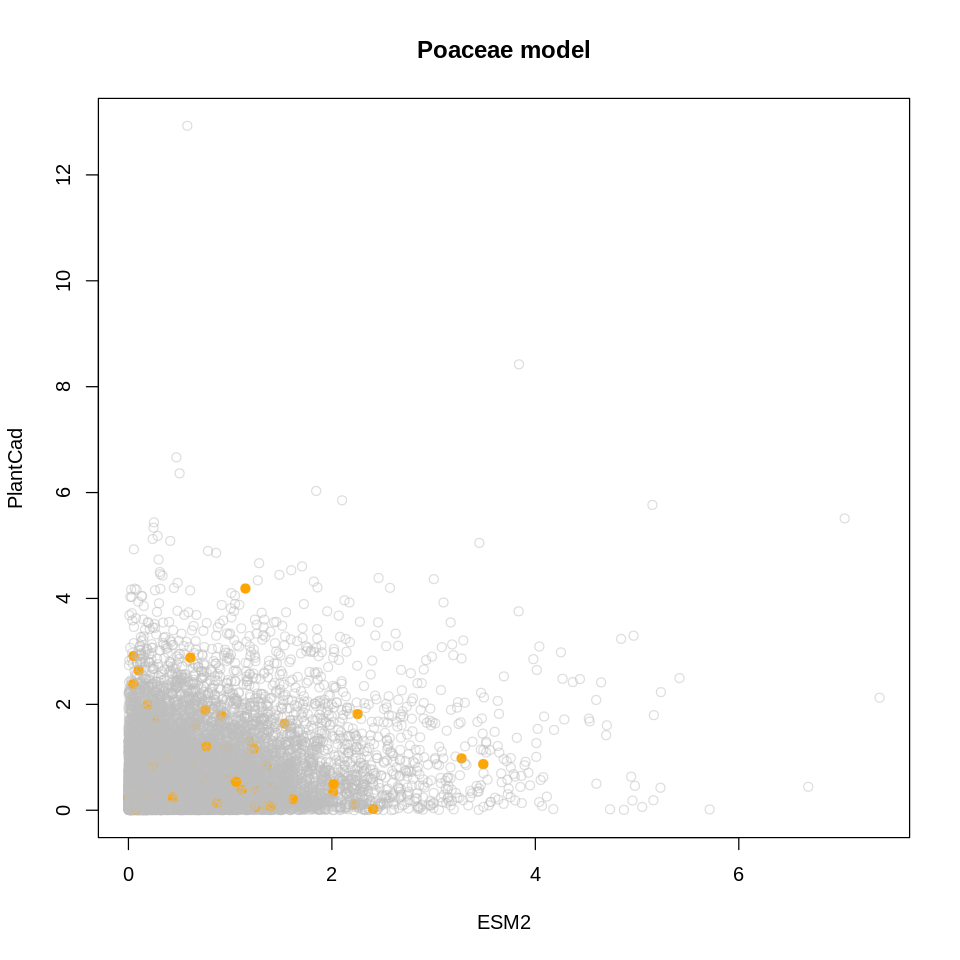

In [599]:
tmpCommonIdx = intersect(testRes_zs$OG,testRes_zs_dna$OG)
plot(-log10(testRes_zs$Pval_envPC1[testRes_zs$OG%in%tmpCommonIdx]),
     -log10(testRes_zs_dna$Pval_envPC1[testRes_zs_dna$OG%in%tmpCommonIdx]),
     xlab = "ESM2",ylab = "PlantCad",main = "Poaceae model",
     pch = ifelse(tmpCommonIdx%in%RAO[,2],19,1) ,
     col = ifelse(tmpCommonIdx%in%RAO[,2],"orange",alpha("grey",.5)))
cor(testRes_zs$Pval_envPC1[testRes_zs$OG%in%tmpCommonIdx],
     testRes_zs_dna$Pval_envPC1[testRes_zs_dna$OG%in%tmpCommonIdx],use = "complete")

contTab = table(rank(testRes_zs$Pval_envPC1[testRes_zs$OG%in%tmpCommonIdx],na.last = T) <= 400 , 
                rank(testRes_zs_dna$Pval_envPC1[testRes_zs_dna$OG%in%tmpCommonIdx],na.last = T) <= 400)
contTab
fisher.test(contTab)

testRes_zs[testRes_zs$OG%in%tmpCommonIdx,][which(rank(testRes_zs$Pval_envPC1[testRes_zs$OG%in%tmpCommonIdx],na.last = T) <= 200&rank(testRes_zs_dna$Pval_envPC1[testRes_zs_dna$OG%in%tmpCommonIdx],na.last = T) <= 200),]

[1] 0.1064384

       
        FALSE  TRUE
  FALSE 18626   355
  TRUE    355    45


	Fisher's Exact Test for Count Data

data:  contTab
p-value < 2.2e-16
alternative hypothesis: true odds ratio is not equal to 1
95 percent confidence interval:
 4.681289 9.266677
sample estimates:
odds ratio 
  6.648662 


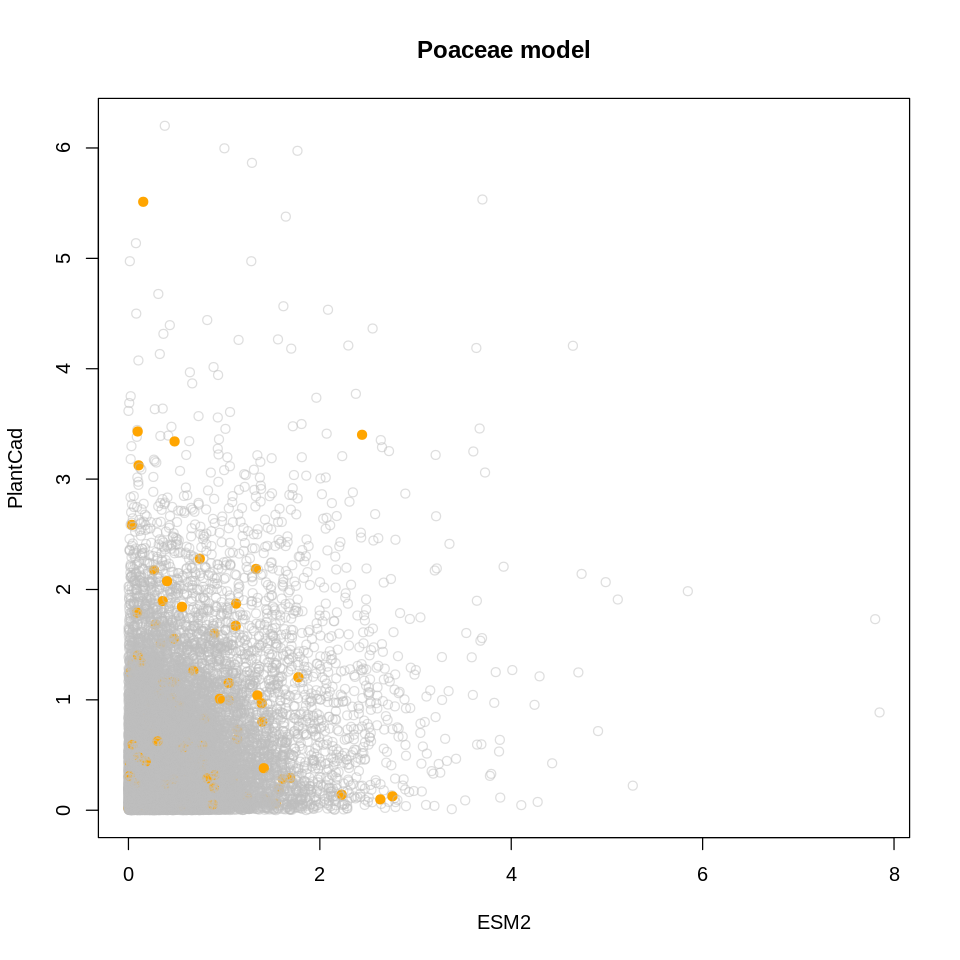

In [601]:
tmpCommonIdx = intersect(testRes_zs$OG,testRes_zs_dna$OG)
plot(-log10(testRes_zs$Pval_envPC2[testRes_zs$OG%in%tmpCommonIdx]),
     -log10(testRes_zs_dna$Pval_envPC2[testRes_zs_dna$OG%in%tmpCommonIdx]),
     xlab = "ESM2",ylab = "PlantCad",main = "Poaceae model",
     pch = ifelse(tmpCommonIdx%in%RAO[,2],19,1) ,
     col = ifelse(tmpCommonIdx%in%RAO[,2],"orange",alpha("grey",.5)))
cor(testRes_zs$Pval_envPC2[testRes_zs$OG%in%tmpCommonIdx],
     testRes_zs_dna$Pval_envPC2[testRes_zs_dna$OG%in%tmpCommonIdx],use = "complete")

contTab = table(rank(testRes_zs$Pval_envPC2[testRes_zs$OG%in%tmpCommonIdx],na.last = T) <= 400 , 
                rank(testRes_zs_dna$Pval_envPC2[testRes_zs_dna$OG%in%tmpCommonIdx],na.last = T) <= 400)
contTab
fisher.test(contTab)

# testRes_zs[testRes_zs$OG%in%tmpCommonIdx,][which(rank(testRes_zs$Pval_envPC2[testRes_zs$OG%in%tmpCommonIdx],na.last = T) <= 200&rank(testRes_zs_dna$Pval_envPC1[testRes_zs_dna$OG%in%tmpCommonIdx],na.last = T) <= 200),]

[1] 0.1072485

       
        FALSE  TRUE
  FALSE 18952   178
  TRUE    178    22


	Fisher's Exact Test for Count Data

data:  contTab
p-value < 2.2e-16
alternative hypothesis: true odds ratio is not equal to 1
95 percent confidence interval:
  7.845731 21.143144
sample estimates:
odds ratio 
  13.15754 


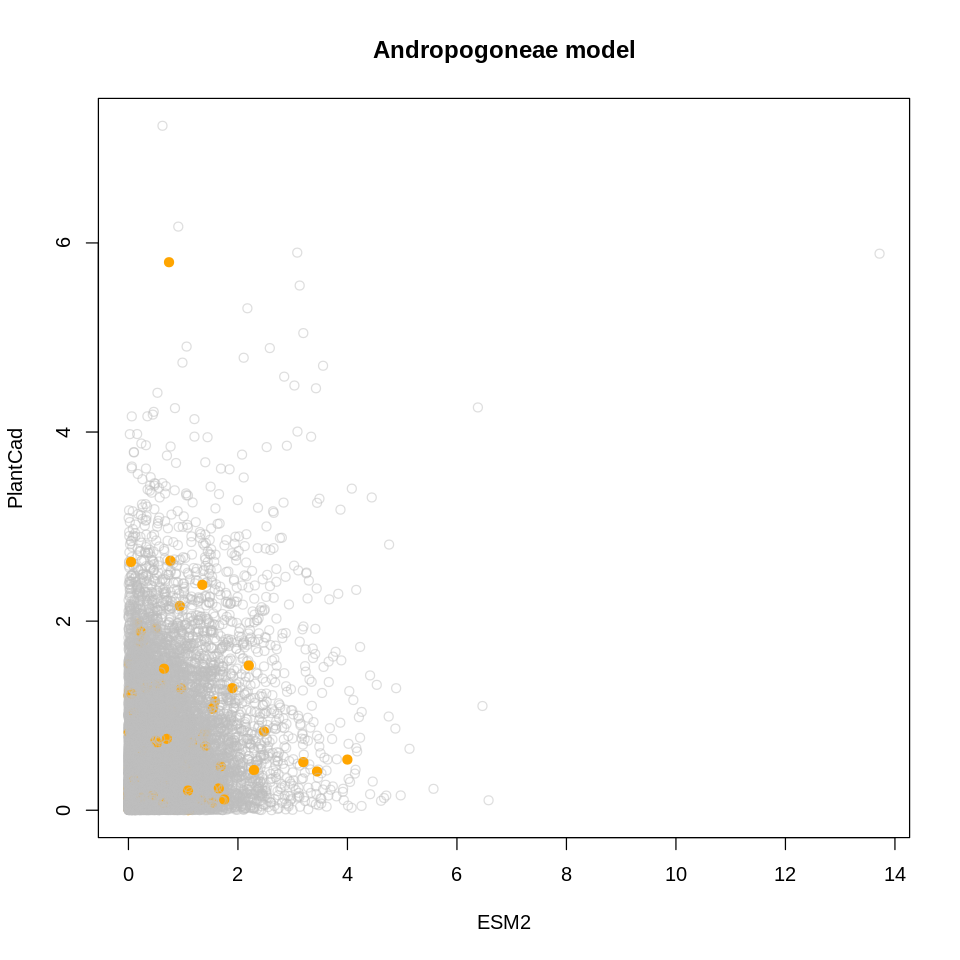

In [600]:
tmpCommonIdx = intersect(testRes_zs_andro$OG,testRes_zs_dna_andro$OG)
plot(-log10(testRes_zs_andro$Pval_envPC1[testRes_zs_andro$OG%in%tmpCommonIdx]),
     -log10(testRes_zs_dna_andro$Pval_envPC1[testRes_zs_dna_andro$OG%in%tmpCommonIdx]),
     xlab = "ESM2",ylab = "PlantCad",main = "Andropogoneae model",
     pch = ifelse(tmpCommonIdx%in%RAO[,2],19,1) ,
     col = ifelse(tmpCommonIdx%in%RAO[,2],"orange",alpha("grey",.5))) 
cor(testRes_zs_andro$Pval_envPC1[testRes_zs_andro$OG%in%tmpCommonIdx],
     testRes_zs_dna_andro$Pval_envPC1[testRes_zs_dna_andro$OG%in%tmpCommonIdx],use = "complete")

contTab = table(rank(testRes_zs_andro$Pval_envPC1[testRes_zs_andro$OG%in%tmpCommonIdx],na.last = T) <= 200 , 
                rank(testRes_zs_dna_andro$Pval_envPC1[testRes_zs_dna_andro$OG%in%tmpCommonIdx],na.last = T) <= 200)
contTab
fisher.test(contTab)

[1] 0.1318459

       
        FALSE  TRUE
  FALSE 18950   180
  TRUE    180    20


	Fisher's Exact Test for Count Data

data:  contTab
p-value = 2.413e-14
alternative hypothesis: true odds ratio is not equal to 1
95 percent confidence interval:
  6.815809 19.117457
sample estimates:
odds ratio 
  11.69446 


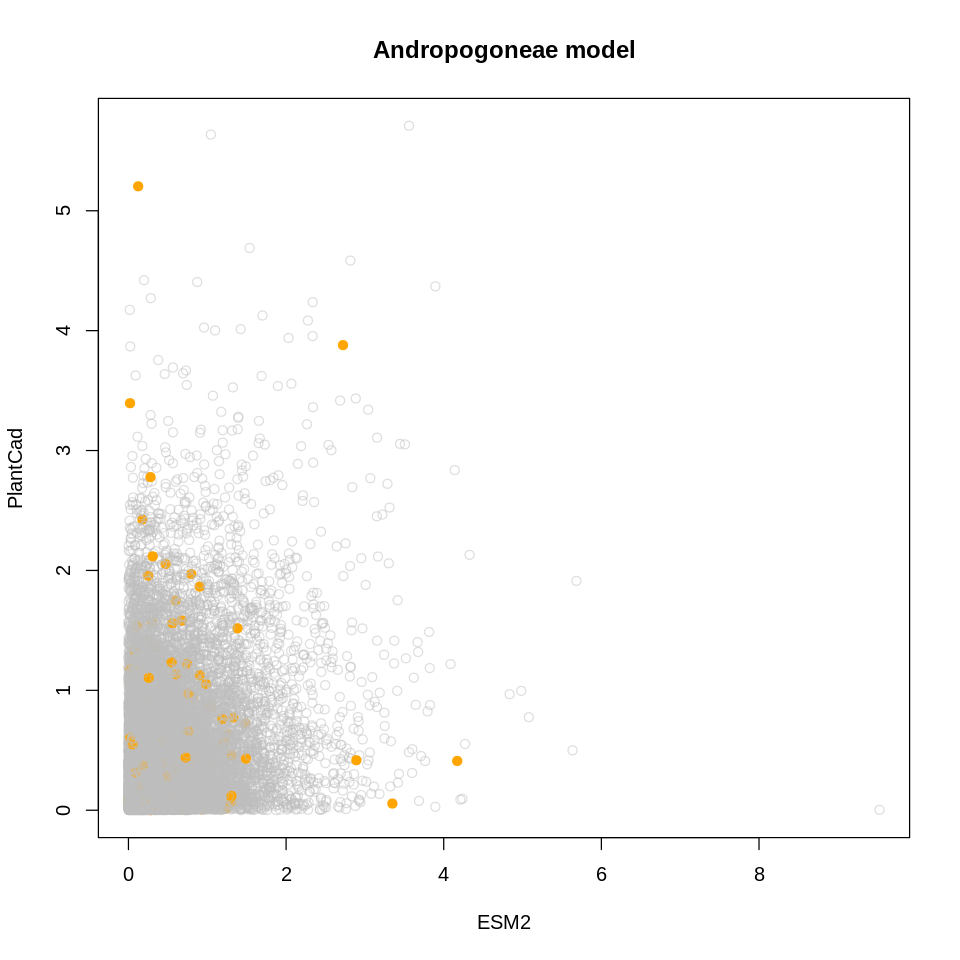

In [603]:
tmpCommonIdx = intersect(testRes_zs_andro$OG,testRes_zs_dna_andro$OG)
plot(-log10(testRes_zs_andro$Pval_envPC2[testRes_zs_andro$OG%in%tmpCommonIdx]),
     -log10(testRes_zs_dna_andro$Pval_envPC2[testRes_zs_dna_andro$OG%in%tmpCommonIdx]),
     xlab = "ESM2",ylab = "PlantCad",main = "Andropogoneae model",
     pch = ifelse(tmpCommonIdx%in%RAO[,2],19,1) ,
     col = ifelse(tmpCommonIdx%in%RAO[,2],"orange",alpha("grey",.5))) 
cor(testRes_zs_andro$Pval_envPC2[testRes_zs_andro$OG%in%tmpCommonIdx],
     testRes_zs_dna_andro$Pval_envPC2[testRes_zs_dna_andro$OG%in%tmpCommonIdx],use = "complete")

contTab = table(rank(testRes_zs_andro$Pval_envPC2[testRes_zs_andro$OG%in%tmpCommonIdx],na.last = T) <= 200 , 
                rank(testRes_zs_dna_andro$Pval_envPC2[testRes_zs_dna_andro$OG%in%tmpCommonIdx],na.last = T) <= 200)
contTab
fisher.test(contTab)

[1] 0.06259356

       
        FALSE  TRUE
  FALSE 19184   188
  TRUE    188    12


	Fisher's Exact Test for Count Data

data:  contTab
p-value = 1.064e-06
alternative hypothesis: true odds ratio is not equal to 1
95 percent confidence interval:
  3.247734 11.912290
sample estimates:
odds ratio 
  6.511639 


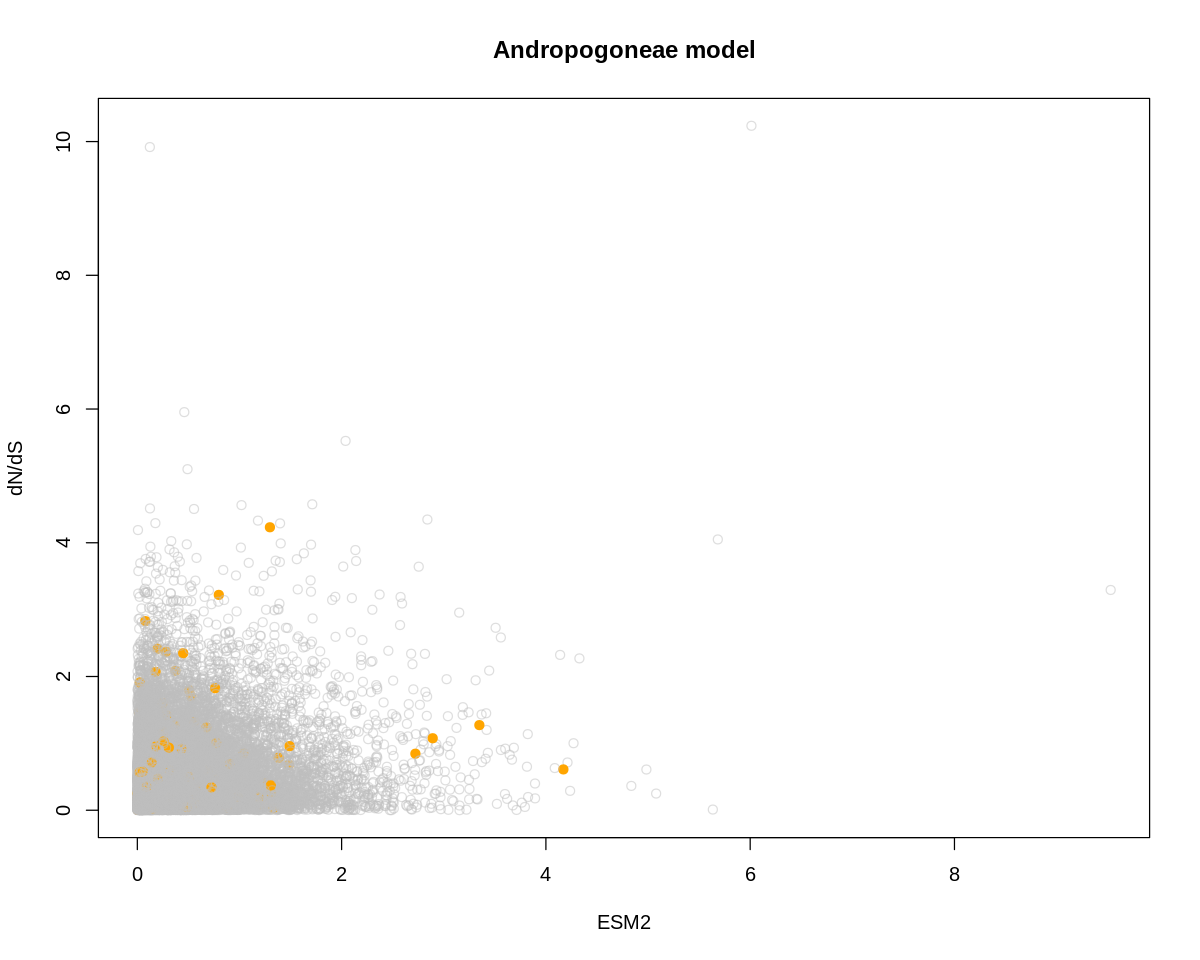

In [662]:
tmpCommonIdx = intersect(testRes_zs_andro$OG,testRes_dnds_andro$OG)
plot(-log10(testRes_zs_andro$Pval_envPC2[testRes_zs_andro$OG%in%tmpCommonIdx]),
     -log10(testRes_dnds_andro$Pval_envPC2[testRes_dnds_andro$OG%in%tmpCommonIdx]),
     xlab = "ESM2",ylab = "dN/dS",main = "Andropogoneae model",
     pch = ifelse(tmpCommonIdx%in%RAO[,2],19,1) ,
     col = ifelse(tmpCommonIdx%in%RAO[,2],"orange",alpha("grey",.5))) 
cor(testRes_zs_andro$Pval_envPC2[testRes_zs_andro$OG%in%tmpCommonIdx],
    testRes_dnds_andro$Pval_envPC2[testRes_dnds_andro$OG%in%tmpCommonIdx],use = "complete")

contTab = table(rank(testRes_zs_andro$Pval_envPC2[testRes_zs_andro$OG%in%tmpCommonIdx],na.last = T) <= 200 , 
                rank(testRes_dnds_andro$Pval_envPC2[testRes_dnds_andro$OG%in%tmpCommonIdx],na.last = T) <= 200)
contTab
fisher.test(contTab)

In [667]:
tmpCommonIdx = Reduce("intersect",list(testRes_zs$OG,testRes_zs_dna$OG,testRes_dnds$OG))
cor(cbind(testRes_zs$Pval_envPC1[testRes_zs$OG%in%tmpCommonIdx],
      testRes_zs_dna$Pval_envPC1[testRes_zs_dna$OG%in%tmpCommonIdx],
      testRes_dnds$Pval_envPC1[testRes_dnds$OG%in%tmpCommonIdx]))


1.00000000,0.09850616,0.02898137
0.09850616,1.00000000,0.08701547
0.02898137,0.08701547,1.00000000


In [958]:
poaceaeCandidates = list(testRes_zs$OG[rank(testRes_zs$Pval_envPC1) <= 400],
                         testRes_zs_dna$OG[rank(testRes_zs_dna$Pval_envPC1) <= 400],
                         testRes_dnds$OG[rank(testRes_dnds$Pval_envPC1) <= 400],
                         testRes_dnds$OG[rank(testRes_multiVar$Pval_envPC1) <= 400])
VennDiagram::venn.diagram(poaceaeCandidates,category.names = c("ESM2","plantCad","dn/ds","multiVar"),disable.logging = T,
                          filename = "/workdir/sh2246/p_phyloGWAS/output/ASREML_res_envPC1_poaceaeModel_Venn.png",
                          height = 8.7,width = 8.7,units = "cm",resolution = 600,imagetype = "png")

INFO [2024-10-14 10:01:01] [[1]]
INFO [2024-10-14 10:01:01] poaceaeCandidates
INFO [2024-10-14 10:01:01] 
INFO [2024-10-14 10:01:01] $category.names
INFO [2024-10-14 10:01:01] c("ESM2", "plantCad", "dn/ds", "multiVar")
INFO [2024-10-14 10:01:01] 
INFO [2024-10-14 10:01:01] $disable.logging
INFO [2024-10-14 10:01:01] T
INFO [2024-10-14 10:01:01] 
INFO [2024-10-14 10:01:01] $filename
INFO [2024-10-14 10:01:01] [1] "/workdir/sh2246/p_phyloGWAS/output/ASREML_res_envPC1_poaceaeModel_Venn.png"
INFO [2024-10-14 10:01:01] 
INFO [2024-10-14 10:01:01] $height
INFO [2024-10-14 10:01:01] [1] 8.7
INFO [2024-10-14 10:01:01] 
INFO [2024-10-14 10:01:01] $width
INFO [2024-10-14 10:01:01] [1] 8.7
INFO [2024-10-14 10:01:01] 
INFO [2024-10-14 10:01:01] $units
INFO [2024-10-14 10:01:01] [1] "cm"
INFO [2024-10-14 10:01:01] 
INFO [2024-10-14 10:01:01] $resolution
INFO [2024-10-14 10:01:01] [1] 600
INFO [2024-10-14 10:01:01] 
INFO [2024-10-14 10:01:01] $imagetype
INFO [2024-10-14 10:01:01] [1] "png"
INFO [202

[1] 1

In [959]:
poaceaeCandidates2 = list(testRes_zs$OG[rank(testRes_zs$Pval_envPC2) <= 400],
                         testRes_zs_dna$OG[rank(testRes_zs_dna$Pval_envPC2) <= 400],
                         testRes_dnds$OG[rank(testRes_dnds$Pval_envPC2) <= 400],
                         testRes_multiVar$OG[rank(testRes_multiVar$Pval_envPC2) <= 400])
VennDiagram::venn.diagram(poaceaeCandidates2,category.names = c("ESM2","plantCad","dn/ds","multiVar"),disable.logging = T,
                          filename = "/workdir/sh2246/p_phyloGWAS/output/ASREML_res_envPC2_poaceaeModel_Venn.png",
                          height = 8.7,width = 8.7,units = "cm",resolution = 600,imagetype = "png")

INFO [2024-10-14 10:01:01] [[1]]
INFO [2024-10-14 10:01:01] poaceaeCandidates2
INFO [2024-10-14 10:01:01] 
INFO [2024-10-14 10:01:01] $category.names
INFO [2024-10-14 10:01:01] c("ESM2", "plantCad", "dn/ds", "multiVar")
INFO [2024-10-14 10:01:01] 
INFO [2024-10-14 10:01:01] $disable.logging
INFO [2024-10-14 10:01:01] T
INFO [2024-10-14 10:01:01] 
INFO [2024-10-14 10:01:01] $filename
INFO [2024-10-14 10:01:01] [1] "/workdir/sh2246/p_phyloGWAS/output/ASREML_res_envPC2_poaceaeModel_Venn.png"
INFO [2024-10-14 10:01:01] 
INFO [2024-10-14 10:01:01] $height
INFO [2024-10-14 10:01:01] [1] 8.7
INFO [2024-10-14 10:01:01] 
INFO [2024-10-14 10:01:01] $width
INFO [2024-10-14 10:01:01] [1] 8.7
INFO [2024-10-14 10:01:01] 
INFO [2024-10-14 10:01:01] $units
INFO [2024-10-14 10:01:01] [1] "cm"
INFO [2024-10-14 10:01:01] 
INFO [2024-10-14 10:01:01] $resolution
INFO [2024-10-14 10:01:01] [1] 600
INFO [2024-10-14 10:01:01] 
INFO [2024-10-14 10:01:01] $imagetype
INFO [2024-10-14 10:01:01] [1] "png"
INFO [20

[1] 1

In [960]:
androCandidates = list(testRes_zs_andro$OG[rank(testRes_zs_andro$Pval_envPC1) <= 400],
                         testRes_zs_dna_andro$OG[rank(testRes_zs_dna_andro$Pval_envPC1) <= 400],
                         testRes_dnds_andro$OG[rank(testRes_dnds_andro$Pval_envPC1) <= 400],
                       testRes_multiVar_andro$OG[rank(testRes_multiVar_andro$Pval_envPC1) <= 400])
VennDiagram::venn.diagram(androCandidates,category.names = c("ESM2","plantCad","dn/ds","multiVar"),disable.logging = T,
                          filename = "/workdir/sh2246/p_phyloGWAS/output/ASREML_res_envPC1_andropogoneaeModel_Venn.png",
                          height = 8.7,width = 8.7,units = "cm",resolution = 600,imagetype = "png")

INFO [2024-10-14 10:01:02] [[1]]
INFO [2024-10-14 10:01:02] androCandidates
INFO [2024-10-14 10:01:02] 
INFO [2024-10-14 10:01:02] $category.names
INFO [2024-10-14 10:01:02] c("ESM2", "plantCad", "dn/ds", "multiVar")
INFO [2024-10-14 10:01:02] 
INFO [2024-10-14 10:01:02] $disable.logging
INFO [2024-10-14 10:01:02] T
INFO [2024-10-14 10:01:02] 
INFO [2024-10-14 10:01:02] $filename
INFO [2024-10-14 10:01:02] [1] "/workdir/sh2246/p_phyloGWAS/output/ASREML_res_envPC1_andropogoneaeModel_Venn.png"
INFO [2024-10-14 10:01:02] 
INFO [2024-10-14 10:01:02] $height
INFO [2024-10-14 10:01:02] [1] 8.7
INFO [2024-10-14 10:01:02] 
INFO [2024-10-14 10:01:02] $width
INFO [2024-10-14 10:01:02] [1] 8.7
INFO [2024-10-14 10:01:02] 
INFO [2024-10-14 10:01:02] $units
INFO [2024-10-14 10:01:02] [1] "cm"
INFO [2024-10-14 10:01:02] 
INFO [2024-10-14 10:01:02] $resolution
INFO [2024-10-14 10:01:02] [1] 600
INFO [2024-10-14 10:01:02] 
INFO [2024-10-14 10:01:02] $imagetype
INFO [2024-10-14 10:01:02] [1] "png"
INFO 

[1] 1

In [961]:
androCandidates2 = list(testRes_zs_andro$OG[rank(testRes_zs_andro$Pval_envPC2) <= 400],
                         testRes_zs_dna_andro$OG[rank(testRes_zs_dna_andro$Pval_envPC2) <= 400],
                         testRes_dnds_andro$OG[rank(testRes_dnds_andro$Pval_envPC2) <= 400],
                        testRes_multiVar_andro$OG[rank(testRes_multiVar_andro$Pval_envPC2) <= 400])
VennDiagram::venn.diagram(androCandidates2,category.names = c("ESM2","plantCad","dn/ds","multiVar"),disable.logging = T,
                          filename = "/workdir/sh2246/p_phyloGWAS/output/ASREML_res_envPC2_andropogoneaeModel_Venn.png",
                          height = 8.7,width = 8.7,units = "cm",resolution = 600,imagetype = "png")

INFO [2024-10-14 10:01:02] [[1]]
INFO [2024-10-14 10:01:02] androCandidates2
INFO [2024-10-14 10:01:02] 
INFO [2024-10-14 10:01:02] $category.names
INFO [2024-10-14 10:01:02] c("ESM2", "plantCad", "dn/ds", "multiVar")
INFO [2024-10-14 10:01:02] 
INFO [2024-10-14 10:01:02] $disable.logging
INFO [2024-10-14 10:01:02] T
INFO [2024-10-14 10:01:02] 
INFO [2024-10-14 10:01:02] $filename
INFO [2024-10-14 10:01:02] [1] "/workdir/sh2246/p_phyloGWAS/output/ASREML_res_envPC2_andropogoneaeModel_Venn.png"
INFO [2024-10-14 10:01:02] 
INFO [2024-10-14 10:01:02] $height
INFO [2024-10-14 10:01:02] [1] 8.7
INFO [2024-10-14 10:01:02] 
INFO [2024-10-14 10:01:02] $width
INFO [2024-10-14 10:01:02] [1] 8.7
INFO [2024-10-14 10:01:02] 
INFO [2024-10-14 10:01:02] $units
INFO [2024-10-14 10:01:02] [1] "cm"
INFO [2024-10-14 10:01:02] 
INFO [2024-10-14 10:01:02] $resolution
INFO [2024-10-14 10:01:02] [1] 600
INFO [2024-10-14 10:01:02] 
INFO [2024-10-14 10:01:02] $imagetype
INFO [2024-10-14 10:01:02] [1] "png"
INFO

[1] 1

In [776]:
install.packages("UpSetR")

also installing the dependency ‘gridExtra’


Updating HTML index of packages in '.Library'

Making 'packages.html' ...
 done



In [165]:
library(UpSetR)

In [962]:
names(poaceaeCandidates) = c("ESM2","plantCad","dn/ds","multiVar")
names(poaceaeCandidates2) = c("ESM2","plantCad","dn/ds","multiVar")
names(androCandidates) = c("ESM2","plantCad","dn/ds","multiVar")
names(androCandidates2) = c("ESM2","plantCad","dn/ds","multiVar")

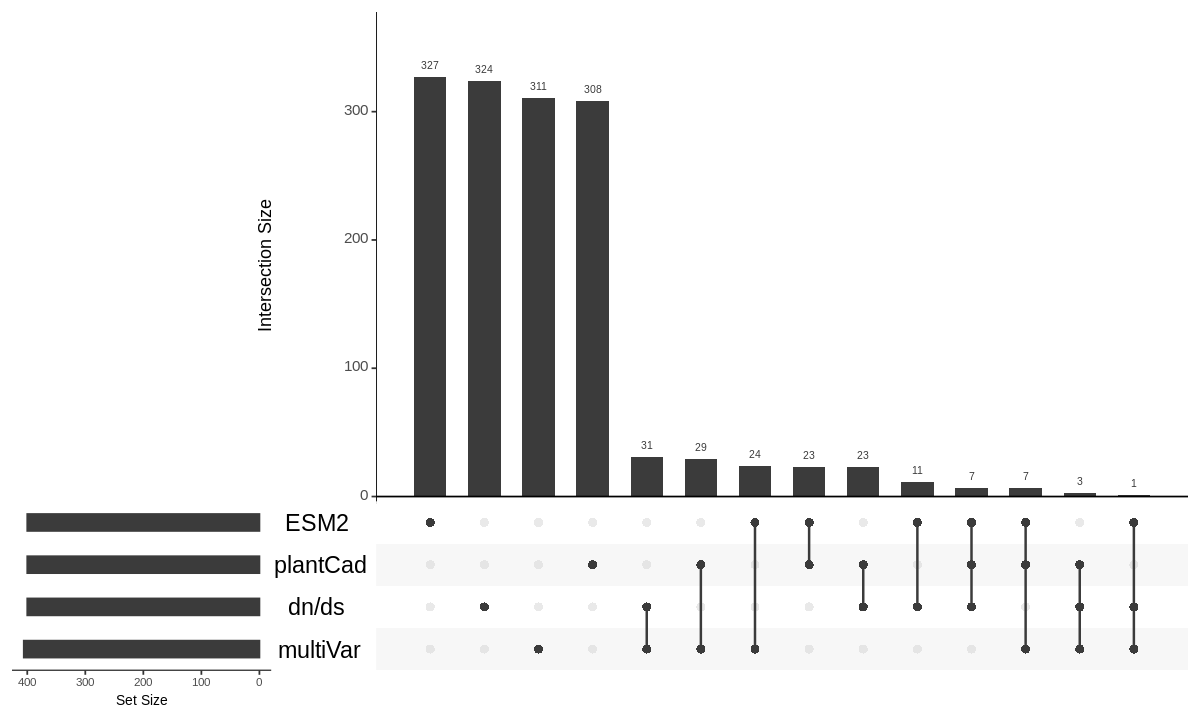

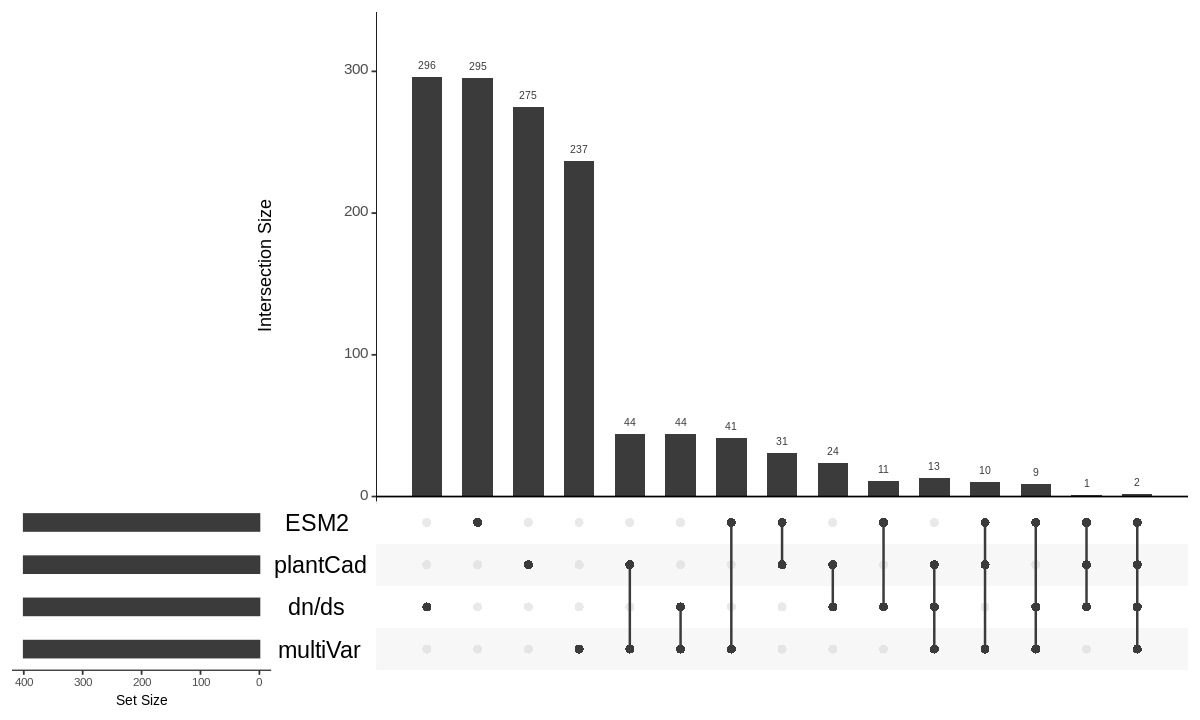

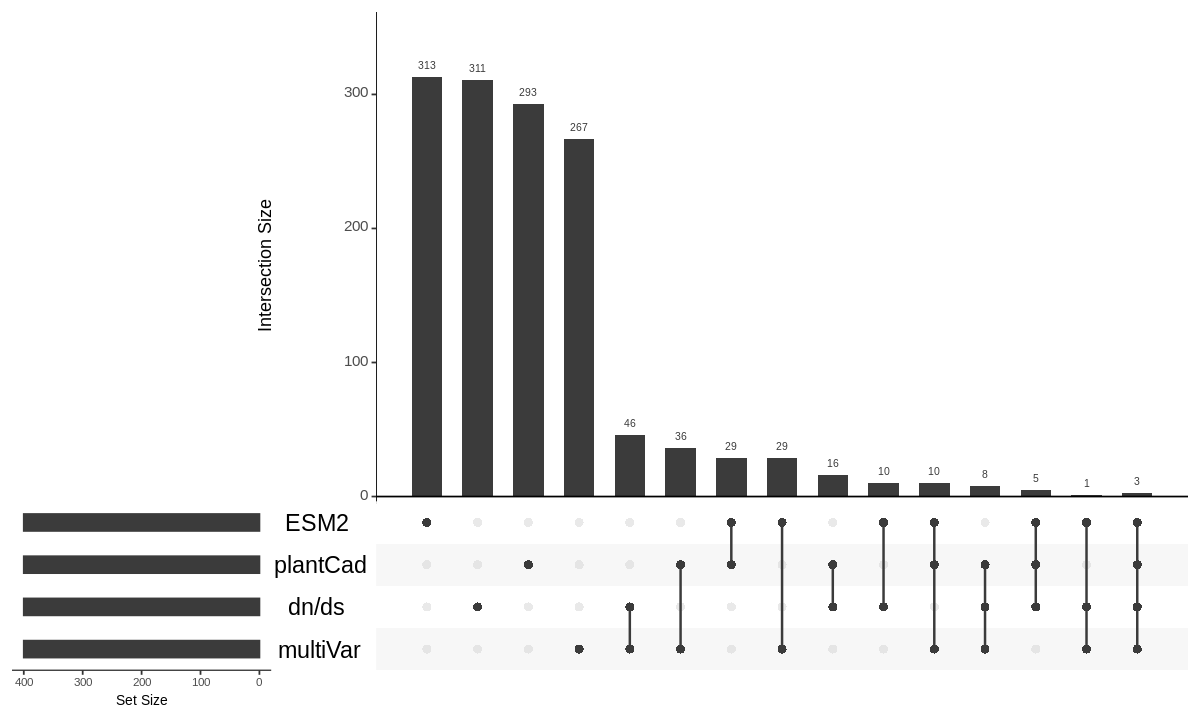

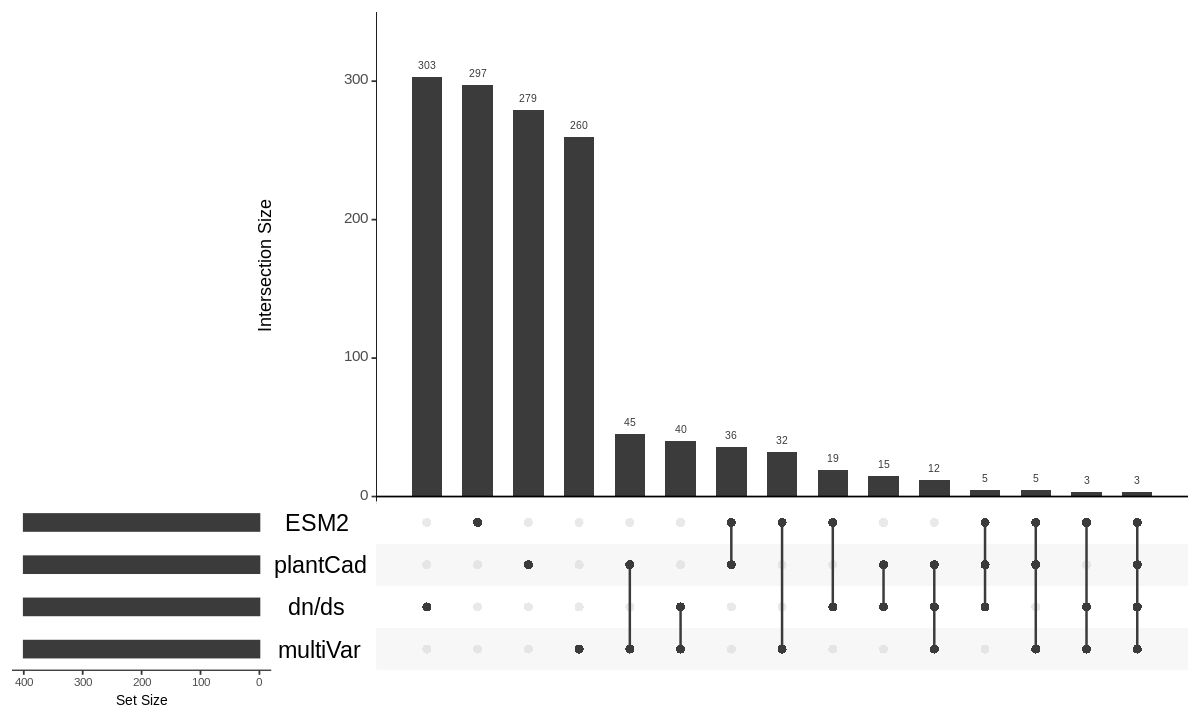

In [963]:
upset(fromList(poaceaeCandidates), text.scale = c(1.3, 1.3, 1, 1, 2, 1))
upset(fromList(poaceaeCandidates2), text.scale = c(1.3, 1.3, 1, 1, 2, 1))
upset(fromList(androCandidates), text.scale = c(1.3, 1.3, 1, 1, 2, 1))
upset(fromList(androCandidates2), text.scale = c(1.3, 1.3, 1, 1, 2, 1))

In [964]:
paste(mappingFileMerged[mappingFileMerged$OG%in%Reduce("intersect",poaceaeCandidates),3],collapse = " ")
paste(mappingFileMerged[mappingFileMerged$OG%in%Reduce("intersect",poaceaeCandidates2),3],collapse = " ")
paste(mappingFileMerged[mappingFileMerged$OG%in%Reduce("intersect",androCandidates),3],collapse = " ")
paste(mappingFileMerged[mappingFileMerged$OG%in%Reduce("intersect",androCandidates2),3],collapse = " ")

[1] ""

[1] "Zm00001eb290720_T003 Zm00001eb115840_T001"

[1] "Zm00001eb347550_T001 Zm00001eb313000_T001 Zm00001eb137060_T001"

[1] "Zm00001eb006000_T001 Zm00001eb032630_T001 Zm00001eb400310_T003"

In [710]:
Reduce("intersect",poaceaeCandidates2)
paste(mappingFileMerged[mappingFileMerged$OG%in%Reduce("intersect",poaceaeCandidates2),3],collapse = " ")

[1] "OG0011775" "OG0016353" "OG0021400"

[1] "Zm00001eb172160_T003 Zm00001eb290720_T003 Zm00001eb115840_T001"

In [666]:
tmpCommonIdx = Reduce("intersect",list(testRes_zs_andro$OG,testRes_zs_dna_andro$OG,testRes_dnds_andro$OG))
cor(cbind(testRes_zs_andro$Pval_envPC1[testRes_zs_andro$OG%in%tmpCommonIdx],
      testRes_zs_dna_andro$Pval_envPC1[testRes_zs_dna_andro$OG%in%tmpCommonIdx],
      testRes_dnds_andro$Pval_envPC1[testRes_dnds_andro$OG%in%tmpCommonIdx]))


1.00000000,0.10729249,0.04369729
0.10729249,1.00000000,0.09360231
0.04369729,0.09360231,1.00000000


In [563]:
cor(testData_merged$scaledScore[testData_merged$Frameshift==0],
    testData_merged$scaledScore_DNA[testData_merged$Frameshift==0],use = "complete")

[1] 0.2668695

In [797]:
contTab = table(rank(as.numeric(testRes_multiVar[,13]))<200,testRes_multiVar$OG%in%RAO[,2])
contTab
fisher.test(contTab,alternative = "greater")

       
        FALSE  TRUE
  FALSE 19006   177
  TRUE    195     4


	Fisher's Exact Test for Count Data

data:  contTab
p-value = 0.1164
alternative hypothesis: true odds ratio is greater than 1
95 percent confidence interval:
 0.7378484       Inf
sample estimates:
odds ratio 
  2.202645 


In [620]:
library(Biostrings)

Loading required package: XVector


Attaching package: ‘XVector’


The following object is masked from ‘package:purrr’:

    compact


Loading required package: GenomeInfoDb


Attaching package: ‘Biostrings’


The following object is masked from ‘package:ape’:

    complement


The following object is masked from ‘package:graph’:

    complement


The following object is masked from ‘package:base’:

    strsplit




In [622]:
queryOG = readAAStringSet("/workdir/sh2246/p_phyloGWAS/output/poaceaeHelixerOG_ancSeq_gapRemoved_v2_20240909.fa")
queryOG_length=width(queryOG)


In [626]:
names(queryOG_length) = names(queryOG)

In [ ]:
hist(queryOG_length[testRes])

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
   28.0   177.5   307.0   394.2   523.5  2498.0 

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
   49.0   156.5   301.0   347.8   475.0  1769.0 

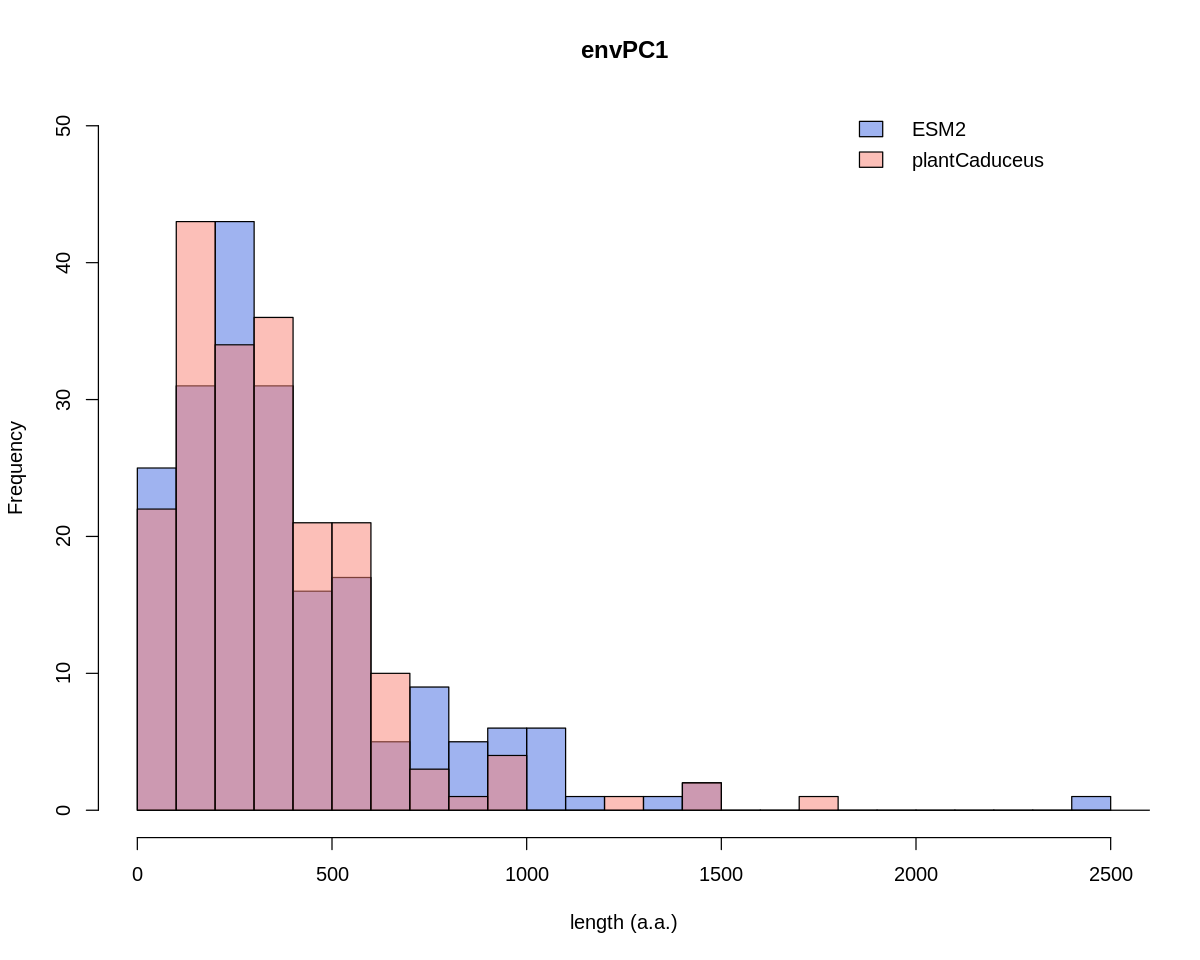

In [656]:
options(repr.plot.width=10, repr.plot.height=8)
hist(queryOG_length[testRes_zs$OG[rank(testRes_zs$Pval_envPC1) < 200]],breaks = seq(0,2500,100),ylim = c(0,50),
     main = "envPC1",xlab = "length (a.a.)",col = alpha("royalblue",.5))
hist(queryOG_length[testRes_zs_dna$OG[rank(testRes_zs_dna$Pval_envPC1) < 200]],breaks = seq(0,30000,100)
     ,add = T, col = alpha("salmon",.5))
legend("topright", legend = c("ESM2","plantCaduceus"),fill = alpha(c("royalblue","salmon"),.5),bty = 'n')
summary(queryOG_length[testRes_zs$OG[rank(testRes_zs$Pval_envPC1) < 200]])
summary(queryOG_length[testRes_zs_dna$OG[rank(testRes_zs_dna$Pval_envPC1) < 200]])

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
   32.0   173.0   285.0   338.7   435.5  1280.0 

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
   56.0   188.5   388.0   470.9   596.5  4195.0 

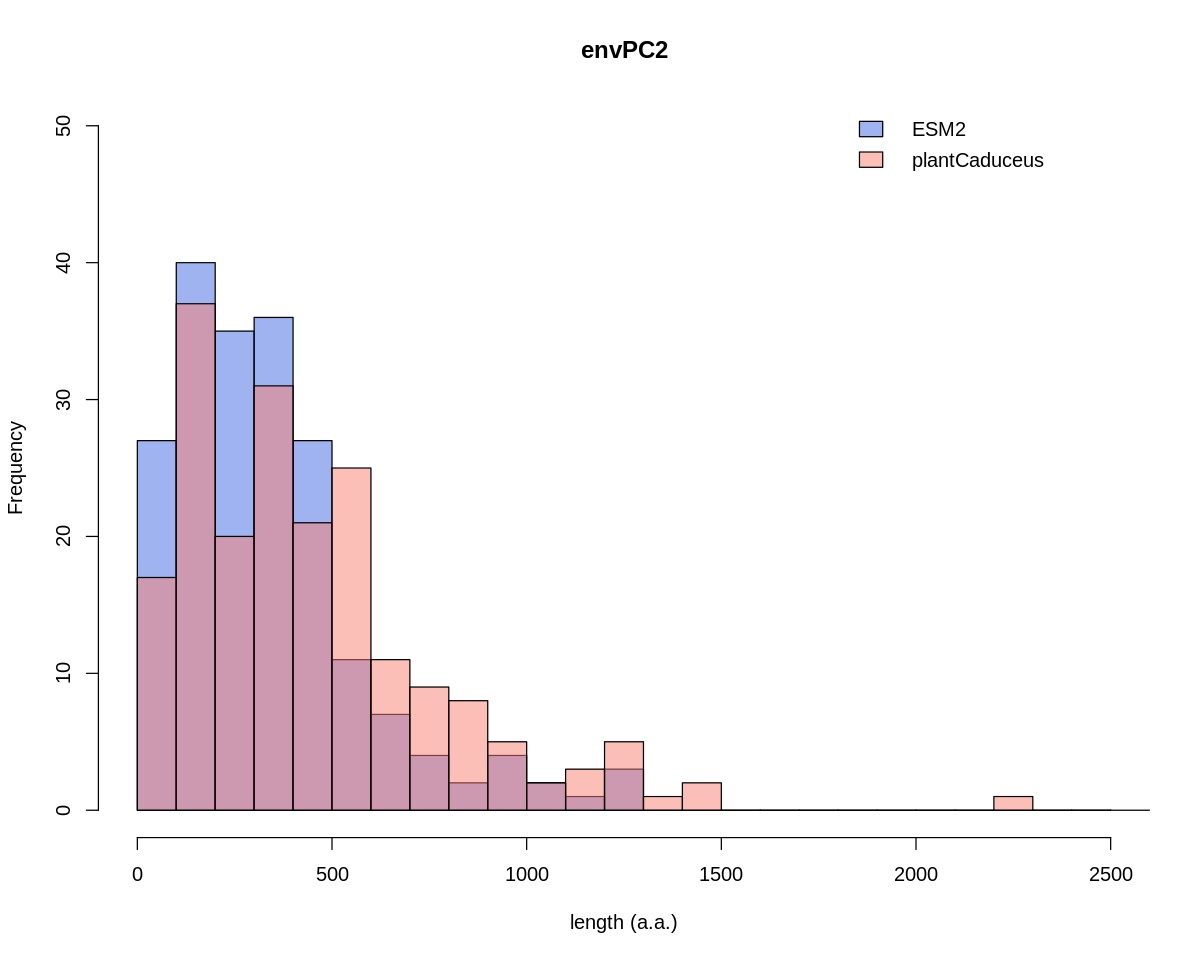

In [657]:
options(repr.plot.width=10, repr.plot.height=8)
hist(queryOG_length[testRes_zs$OG[rank(testRes_zs$Pval_envPC2) < 200]],breaks = seq(0,2500,100),ylim = c(0,50),
     main = "envPC2",xlab = "length (a.a.)",col = alpha("royalblue",.5))
hist(queryOG_length[testRes_zs_dna$OG[rank(testRes_zs_dna$Pval_envPC2) < 200]],breaks = seq(0,30000,100)
     ,add = T, col = alpha("salmon",.5))
legend("topright", legend = c("ESM2","plantCaduceus"),fill = alpha(c("royalblue","salmon"),.5),bty = 'n')
summary(queryOG_length[testRes_zs$OG[rank(testRes_zs$Pval_envPC2) < 200]])
summary(queryOG_length[testRes_zs_dna$OG[rank(testRes_zs_dna$Pval_envPC2) < 200]])

# candidate genes

In [467]:
paste(RAO[,1][RAO[,2]%in%testRes_zs$OG[testRes_zs$OG%in%RAO[,2]&as.numeric(testRes_zs[,12])<0.001]],collapse = ",")

paste(RAO[,1][RAO[,2]%in%testRes_zs_andro$OG[testRes_zs_andro$OG%in%RAO[,2]&as.numeric(testRes_zs_andro[,12])<0.001]],collapse = ",")

paste(RAO[,1][RAO[,2]%in%testRes_zs_dna$OG[testRes_zs_dna$OG%in%RAO[,2]&as.numeric(testRes_zs_dna[,12])<0.001]],collapse = ",")

paste(RAO[,1][RAO[,2]%in%testRes_zs_dna_andro$OG[testRes_zs_dna_andro$OG%in%RAO[,2]&as.numeric(testRes_zs_dna_andro[,12])<0.001]],collapse = ",")

[1] "AT4G22140.1,AT2G44520.1"

[1] "AT4G22140.1,AT1G03060.1,AT4G02725.1"

[1] "AT2G20190.1"

[1] "AT2G20190.1"

In [543]:
paste(RAO[,1][RAO[,2]%in%testRes_zs$OG[testRes_zs$OG%in%RAO[,2]&as.numeric(testRes_zs[,13])<0.005]],collapse = ",")

paste(RAO[,1][RAO[,2]%in%testRes_zs_andro$OG[testRes_zs_andro$OG%in%RAO[,2]&as.numeric(testRes_zs_andro[,13])<0.005]],collapse = ",")

paste(RAO[,1][RAO[,2]%in%testRes_zs_dna$OG[testRes_zs_dna$OG%in%RAO[,2]&as.numeric(testRes_zs_dna[,13])<0.005]],collapse = ",")

paste(RAO[,1][RAO[,2]%in%testRes_zs_dna_andro$OG[testRes_zs_dna_andro$OG%in%RAO[,2]&as.numeric(testRes_zs_dna_andro[,13])<0.005]],collapse = ",")

[1] "AT1G18330.2,AT1G56080.1,AT5G08130.8"

[1] "AT1G18330.2,AT2G14960.1,AT1G56080.1,AT5G08130.8"

[1] "AT3G53480.1,AT1G28130.1,AT3G54170.1,AT1G18330.2,AT2G20190.1,AT1G01140.3"

[1] "AT3G53480.1,AT1G28130.1,AT3G54170.1,AT1G18330.2,AT1G01140.3"

In [368]:
RAO[RAO[,2]%in%testRes_zs$OG[testRes_zs$OG%in%RAO[,2]&as.numeric(testRes_zs[,12])<0.001],]

,V1,V2
,<chr>,<chr>
7,AT4G22140.1,OG0002804
94,AT2G44520.1,OG0013140


In [370]:
RAO[RAO[,2]%in%testRes_zs_andro$OG[testRes_zs_andro$OG%in%RAO[,2]&as.numeric(testRes_zs_andro[,13])<0.01],]

,V1,V2
,<chr>,<chr>
64,AT1G18330.2,OG0010400
88,AT2G14960.1,OG0012339
127,AT1G56080.1,OG0015977
160,AT5G08130.8,OG0023794


In [468]:
RAO[RAO[,2]%in%testRes_zs_dna$OG[testRes_zs_dna$OG%in%RAO[,2]&as.numeric(testRes_zs_dna[,12])<0.001],]

,V1,V2
,<chr>,<chr>
11,AT2G20190.1,OG0003468


In [336]:
testRes_zs[testRes_zs$OG%in%RAO[,2]&as.numeric(testRes_zs[,12])<0.001,12:21]

,Pval_envPC1,Pval_envPC2,Pval_envPC3,Pval_envPC4,Pval_envPC5,Pval_envPC6,Pval_envPC7,Pval_envPC8,Pval_envPC9,Pval_envPC10
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1925,0.0005310962,0.1233479,0.4720928,0.1503000,0.0009312515,0.6588046,0.6931770,0.8800561,0.3454202,0.2039237
11109,0.0003246313,0.1529596,0.9331138,0.2162012,0.0006101856,0.7022275,0.6241877,0.4158413,0.5749178,0.8434982


In [366]:
testRes_zs_andro[testRes_zs_andro$OG%in%RAO[,2]&as.numeric(testRes_zs_andro[,13])<0.001,]

,OG,Coeff_envPC1,Coeff_envPC2,Coeff_envPC3,Coeff_envPC4,Coeff_envPC5,Coeff_envPC6,Coeff_envPC7,Coeff_envPC8,Coeff_envPC9,⋯,VAE_envPC3,VAE_envPC4,VAE_envPC5,VAE_envPC6,VAE_envPC7,VAE_envPC8,VAE_envPC9,VAE_envPC10,PvID,ZmID
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
10357,OG0012339,0.06291317,-0.1861186,-0.01433457,-0.06779721,0.04705979,-0.03335602,0.01320530,0.07993476,-0.05604722,⋯,0.0001126165,1.813940e-02,0.03081974,0.02808319,0.0003163265,0.02235608,0.04141926,0.01159569,Pavag03G286500.1,Zm00001eb152200_T001
13733,OG0015977,0.06999965,0.1293421,-0.03982555,-0.03456047,-0.02800597,-0.09975095,-0.02968569,0.07605729,-0.06124415,⋯,0.0104740687,1.176162e-05,0.01671633,0.19929848,0.0298454845,0.03129221,0.06231144,0.01016653,Pavag06G228100.1,Zm00001eb430930_T001


Warning message in cbind(...):
“number of rows of result is not a multiple of vector length (arg 1)”


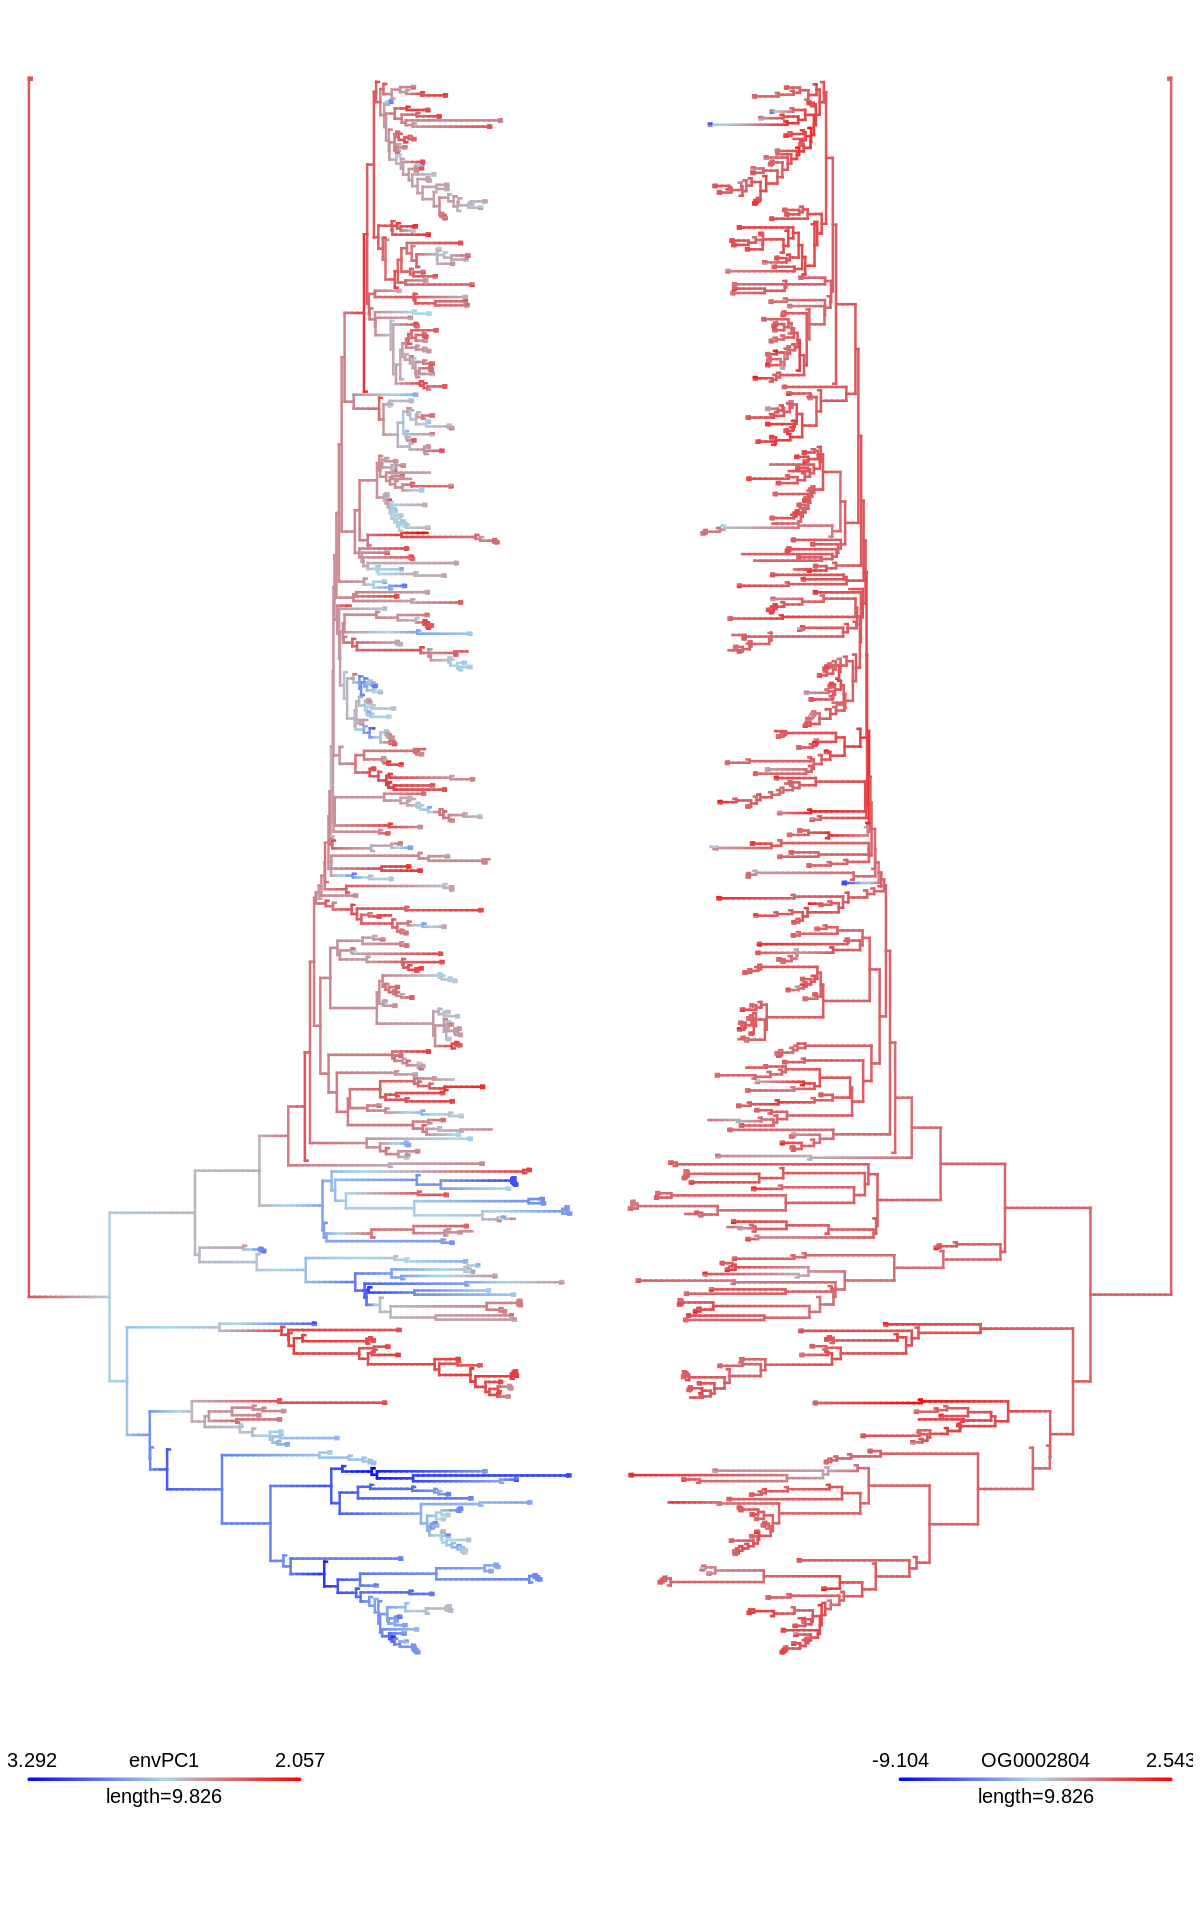

In [331]:
options(repr.plot.width=10, repr.plot.height=16)
par(mfrow = c(1,2))
plotTraitOnTree(envDf$envPC_1,
                commonID,spTre.rooted.filtered,visible_tip_labels = F,
                legend.title = "envPC1",col = c("blue","lightblue","red"))

plotTraitOnTree(tapply(testData_merged$scaledScore[testData_merged$OG%in%"OG0002804"],
                       testData_merged$assemblyID[testData_merged$OG%in%"OG0002804"],mean,na.rm = T),
                commonID,spTre.rooted.filtered,visible_tip_labels = F,direction = "leftwards",
                legend.title = "OG0002804",col = c("blue","lightblue","red"))


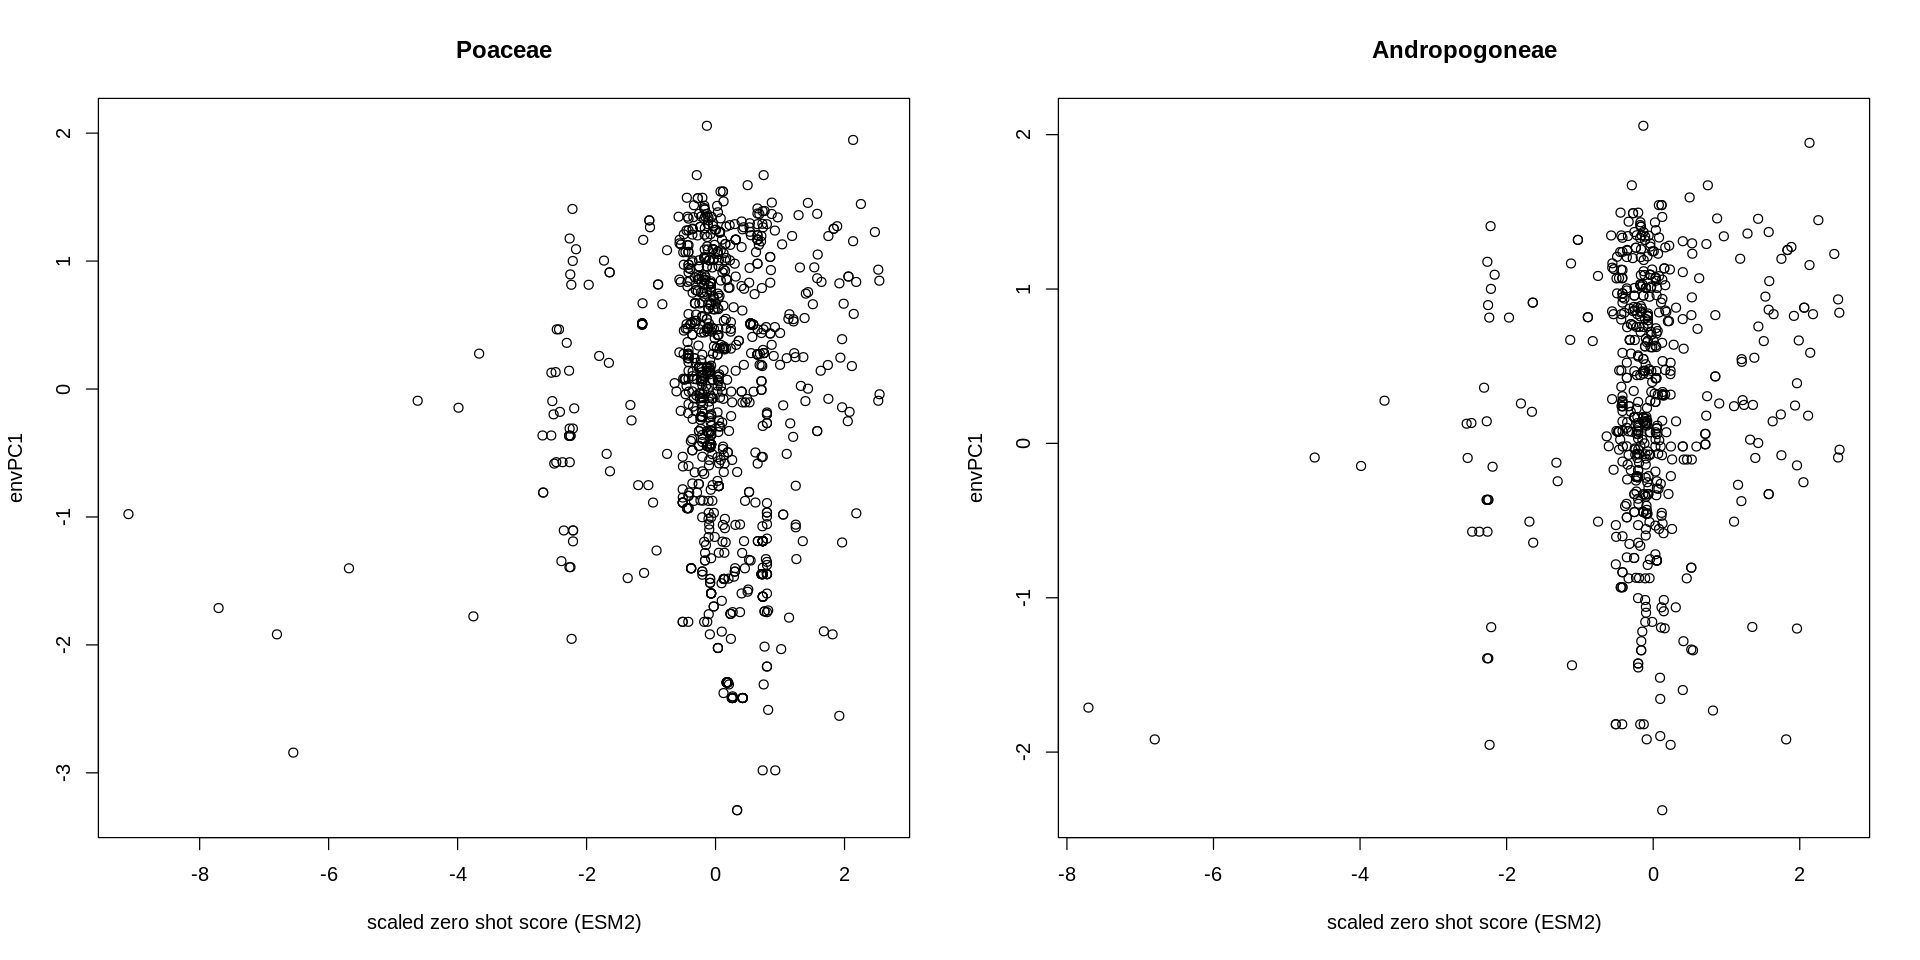

In [334]:
options(repr.plot.width=16, repr.plot.height=8)
par(mfrow = c(1,2))
plot(testData_merged$scaledScore[testData_merged$OG%in%"OG0002804"],
     testData_merged$envPC_1[testData_merged$OG%in%"OG0002804"],
     xlab = "scaled zero shot score (ESM2)",ylab = "envPC1",main = "Poaceae")

plot(testData_merged_andro$scaledScore[testData_merged_andro$OG%in%"OG0002804"],
     testData_merged_andro$envPC_1[testData_merged_andro$OG%in%"OG0002804"],
     xlab = "scaled zero shot score (ESM2)",ylab = "envPC1",main = "Andropogoneae")

Warning message in cbind(...):
“number of rows of result is not a multiple of vector length (arg 1)”


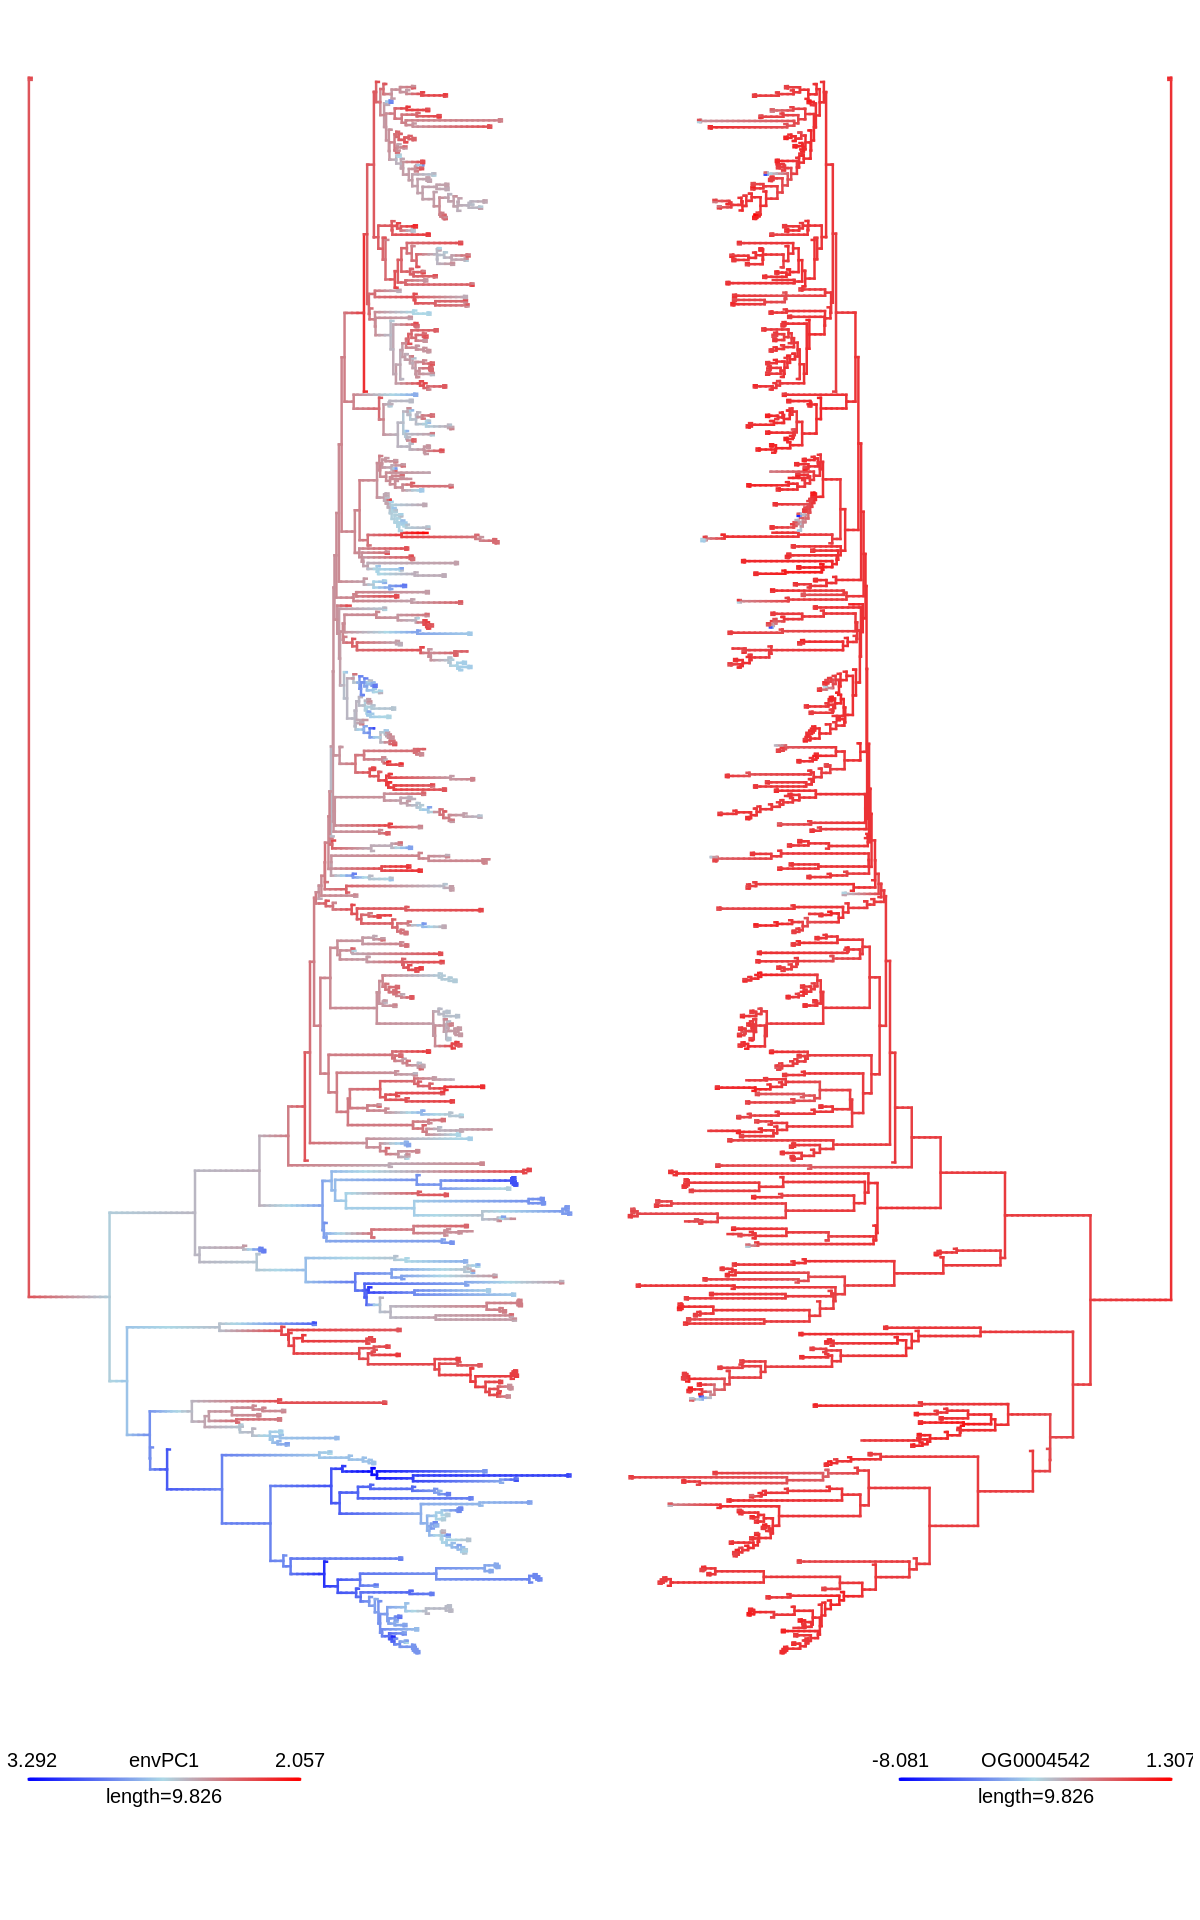

In [326]:
options(repr.plot.width=10, repr.plot.height=16)
par(mfrow = c(1,2))
plotTraitOnTree(envDf$envPC_1,
                commonID,spTre.rooted.filtered,visible_tip_labels = F,
                legend.title = "envPC1",col = c("blue","lightblue","red"))

plotTraitOnTree(tapply(testData_merged$scaledScore[testData_merged$OG%in%"OG0004542"],
                       testData_merged$assemblyID[testData_merged$OG%in%"OG0004542"],mean,na.rm = T),
                commonID,spTre.rooted.filtered,visible_tip_labels = F,direction = "leftwards",
                legend.title = "OG0004542",col = c("blue","lightblue","red"))


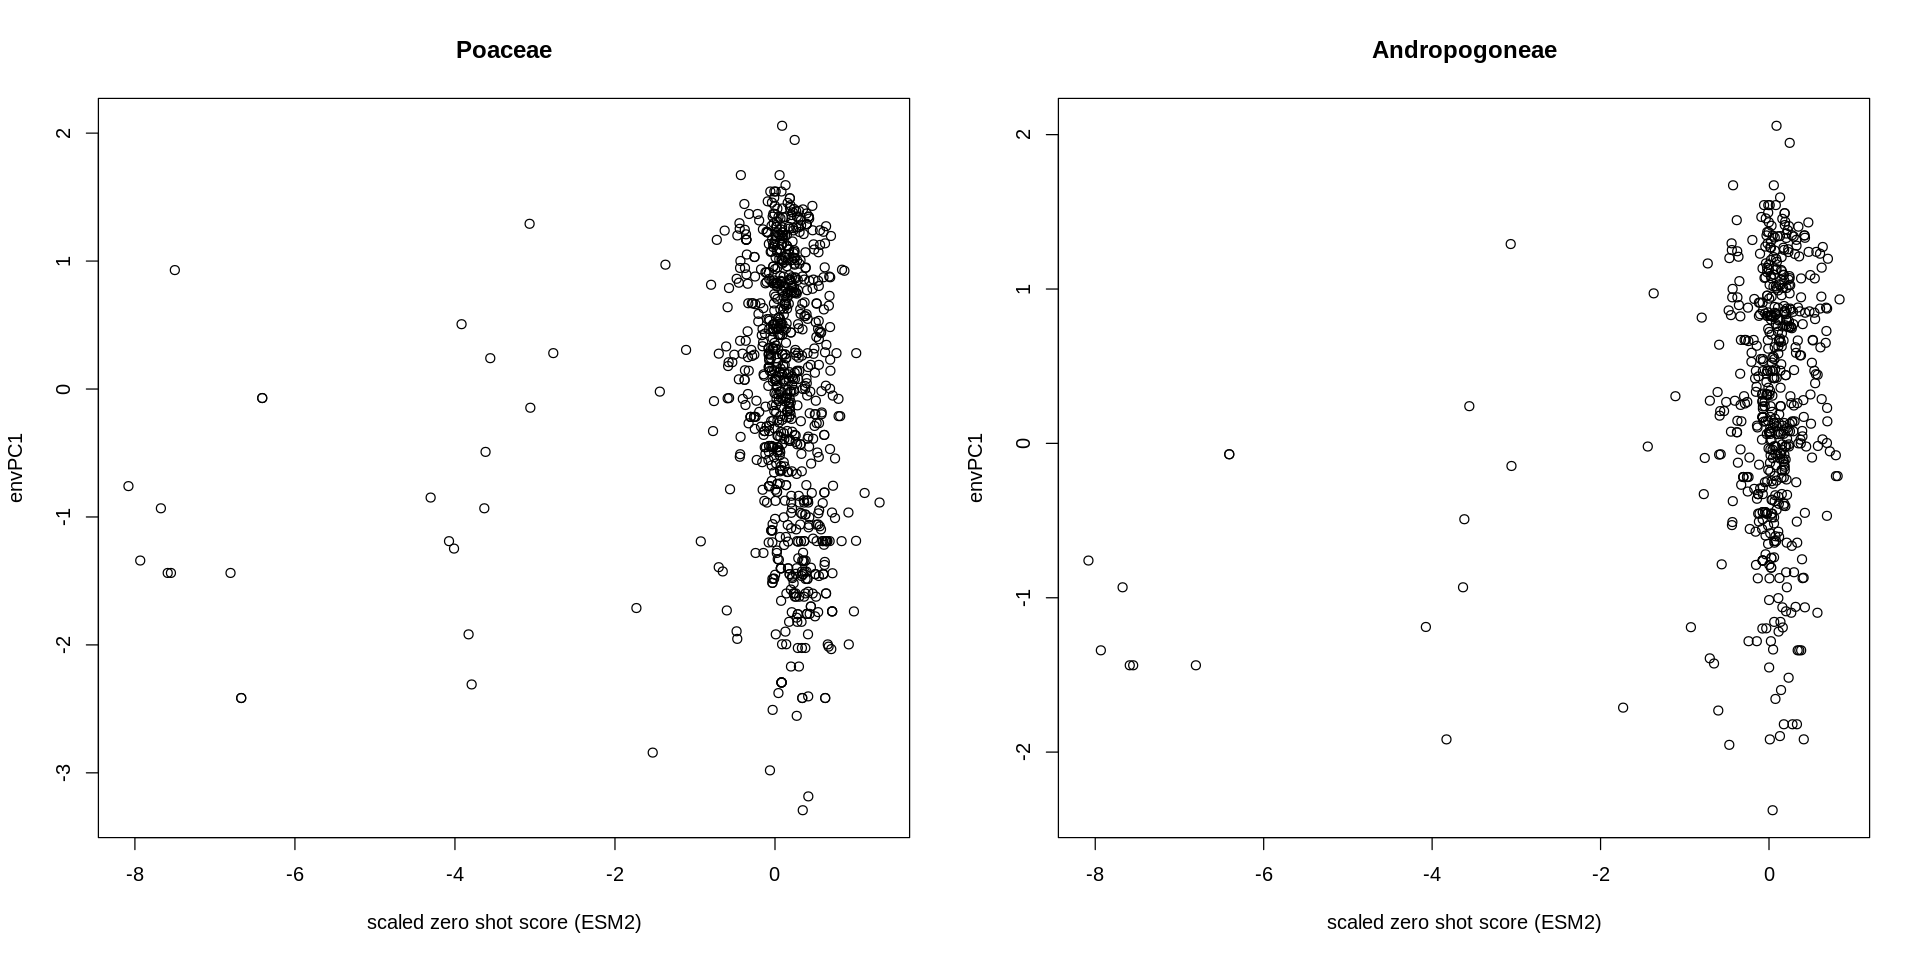

In [335]:
options(repr.plot.width=16, repr.plot.height=8)
par(mfrow = c(1,2))
plot(testData_merged$scaledScore[testData_merged$OG%in%"OG0004542"],
     testData_merged$envPC_1[testData_merged$OG%in%"OG0004542"],
     xlab = "scaled zero shot score (ESM2)",ylab = "envPC1",main = "Poaceae")

plot(testData_merged_andro$scaledScore[testData_merged_andro$OG%in%"OG0004542"],
     testData_merged_andro$envPC_1[testData_merged_andro$OG%in%"OG0004542"],
     xlab = "scaled zero shot score (ESM2)",ylab = "envPC1",main = "Andropogoneae")

seqID,zeroShotScore,scaledScore,assemblyID,seq1,Codons,Compared,Ambigiuous,Indels,Ns,⋯,envPC_37,envPC_38,envPC_39,envPC_40,PMS,AAlength,scaled.dn.ds,Frameshift,groups,groups2
<chr>,<dbl>,<dbl>,<fct>,<chr>,<int>,<int>,<int>,<int>,<int>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<int>,<dbl>,<int>,<chr>,<chr>
OG0004542:CPNAM-Leoti:0,1.397871,-8.080756,CPNAM-Leoti,OG0004542:ASM1935983v1:0,435,393,42,42,0,⋯,0.49857,-0.06174,-0.01857,0.15292,1,171,1.298637413,1,7,7
OG0004542:ASM2203655v1:1,1.456836,-7.933417,ASM2203655v1,OG0004542:ASM1935983v1:0,435,392,43,43,0,⋯,-0.80008,-0.24353,-0.81961,-0.26120,1,184,0.556726117,1,7,7
OG0004542:Bl-K1279B-DRAFT-PanAnd-1.0:0,1.560141,-7.675288,Bl-K1279B-DRAFT-PanAnd-1.0,OG0004542:ASM1935983v1:0,435,390,45,45,0,⋯,0.75669,-0.86941,-0.10914,0.69268,1,178,0.800066688,1,7,7
OG0004542:Sn-CAM1369-DRAFT-PanAnd-1.0:2,1.594229,-7.590112,Sn-CAM1369-DRAFT-PanAnd-1.0,OG0004542:ASM1935983v1:0,435,390,45,45,0,⋯,0.58202,-0.15204,0.38633,0.59221,1,120,0.717678907,1,7,7
OG0004542:Sn-CAM1369-DRAFT-PanAnd-1.0:0,1.610408,-7.549686,Sn-CAM1369-DRAFT-PanAnd-1.0,OG0004542:ASM1935983v1:0,435,390,45,45,0,⋯,0.58202,-0.15204,0.38633,0.59221,1,120,0.800066688,1,7,7
OG0004542:ASM519143v1:0,1.629917,-7.500939,ASM519143v1,OG0004542:ASM1935983v1:0,435,427,8,8,0,⋯,3.52768,-1.15146,-0.97873,-0.25620,1,113,-0.008853757,1,7,7
OG0004542:Sn-CAM1369-DRAFT-PanAnd-1.0:1,1.908466,-6.804925,Sn-CAM1369-DRAFT-PanAnd-1.0,OG0004542:ASM1935983v1:0,435,390,45,45,0,⋯,0.58202,-0.15204,0.38633,0.59221,1,207,0.781985738,1,7,7
OG0004542:Poa_pratensis_v1:1,1.961945,-6.671295,Poa_pratensis_v1,OG0004542:ASM1935983v1:0,435,396,39,39,0,⋯,1.25050,-0.58874,-0.44798,-0.14644,1,118,0.221470074,1,7,7
OG0004542:Pp-Kellogg1297-DRAFT-PanAnd-1.0:1,1.961945,-6.671295,Pp-Kellogg1297-DRAFT-PanAnd-1.0,OG0004542:ASM1935983v1:0,435,396,39,39,0,⋯,1.25050,-0.58874,-0.44798,-0.14644,1,118,0.221470074,1,7,7


seqID,zeroShotScore,scaledScore,assemblyID,seq1,Codons,Compared,Ambigiuous,Indels,Ns,⋯,envPC_37,envPC_38,envPC_39,envPC_40,PMS,AAlength,scaled.dn.ds,Frameshift,groups,groups2
<chr>,<dbl>,<dbl>,<fct>,<chr>,<int>,<int>,<int>,<int>,<int>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<int>,<dbl>,<int>,<chr>,<chr>
OG0004542:FB19_028_3:1,4.964895,0.8322180,FB19_028_3,OG0004542:ASM1935983v1:0,435,395,40,40,0,⋯,0.21703,0.38884,-0.86176,-0.61723,0,461,-1.17855623,0,1,1
OG0004542:AN22TNTL166:0,4.967090,0.8377028,AN22TNTL166,OG0004542:ASM1935983v1:0,435,419,16,16,0,⋯,-1.49298,-0.44189,-1.06820,0.02118,0,392,-0.65283752,0,2,1
OG0004542:Urochloa_brizantha:0,4.979072,0.8676417,Urochloa_brizantha,OG0004542:ASM1935983v1:0,435,424,11,11,0,⋯,-1.84897,-0.23233,0.78735,0.92184,0,336,-0.03792206,0,2,1
OG0004542:aegilops_speltoides_cv_tivon:0,4.999209,0.9179573,aegilops_speltoides_cv_tivon,OG0004542:ASM1935983v1:0,435,395,40,40,0,⋯,0.13709,0.36072,0.71933,-0.46848,0,454,-0.98599353,0,1,1
OG0004542:Aegilops_cylindrica:0,5.000888,0.9221543,Aegilops_cylindrica,OG0004542:ASM1935983v1:0,435,429,6,6,0,⋯,-0.64399,-0.53801,-0.55001,0.88753,0,285,-2.02114405,0,1,1
OG0004542:Rye_Lo7_2018_v1p1p1:0,5.026656,0.9865399,Rye_Lo7_2018_v1p1p1,OG0004542:ASM1935983v1:0,435,394,41,41,0,⋯,0.09059,-0.27538,0.89873,-0.64204,0,453,-0.77103449,0,2,1
OG0004542:ERR7747980:0,5.037281,1.0130895,ERR7747980,OG0004542:ASM1935983v1:0,435,434,1,1,0,⋯,0.09048,-0.08932,0.42623,0.40986,0,309,-0.56881779,0,2,1
OG0004542:TAN1-04B:0,5.038142,1.0152396,TAN1-04B,OG0004542:ASM1935983v1:0,435,433,2,2,0,⋯,-0.19287,-0.01571,0.12013,0.53122,0,325,-1.38266540,0,1,1
OG0004542:Avena_hirtula:1,5.080052,1.1199615,Avena_hirtula,OG0004542:ASM1935983v1:0,435,425,10,10,0,⋯,-0.31470,0.44709,0.01839,-1.09532,0,336,-1.44280030,0,1,1


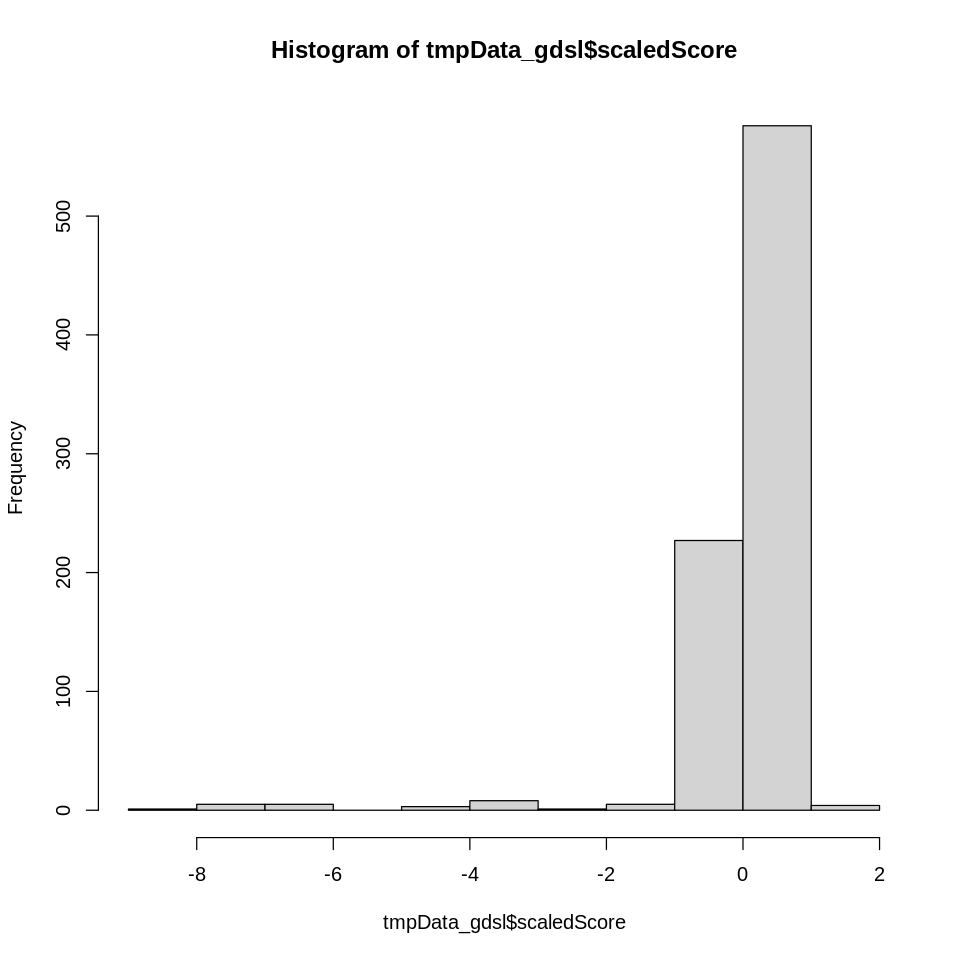

In [324]:
tmpData_gdsl = testData_merged[testData_merged$OG == 'OG0004542',]

options(repr.plot.width=8, repr.plot.height=8)
hist(tmpData_gdsl$scaledScore)


head(tmpData_gdsl[order(tmpData_gdsl$scaledScore),],10)
tail(tmpData_gdsl[order(tmpData_gdsl$scaledScore),],10)

seqID,zeroShotScore,scaledScore,assemblyID,seq1,Codons,Compared,Ambigiuous,Indels,Ns,⋯,envPC_39,envPC_40,PMS,AAlength,scaled.dn.ds,Frameshift,groups,groups2,zeroShotScore_DNA,scaledScore_DNA
<chr>,<dbl>,<dbl>,<fct>,<chr>,<int>,<int>,<int>,<int>,<int>,⋯,<dbl>,<dbl>,<int>,<int>,<dbl>,<int>,<chr>,<chr>,<dbl>,<dbl>
OG0002804:SRR23019232:0,3.156261,-9.104309,SRR23019232,OG0002804:ASM1935983v1:0,217,217,0,0,0,⋯,0.26734,-0.30848,1,134,-0.9276869,1,7,7,3.030512,-0.5479178
OG0002804:AN21TSTL0263:0,3.768542,-7.706287,AN21TSTL0263,OG0002804:ASM1935983v1:0,217,217,0,0,0,⋯,0.07672,-0.21687,0,48,-2.9263830,0,1,1,3.727407,2.7579602
OG0002804:AN21TSTL0264:0,4.164805,-6.801500,AN21TSTL0264,OG0002804:ASM1935983v1:0,217,217,0,0,0,⋯,-1.05072,0.56063,0,48,-2.9901594,0,1,1,3.542567,1.8811289
OG0002804:SRR8208366:0,4.275817,-6.548025,SRR8208366,OG0002804:ASM1935983v1:0,217,213,4,4,0,⋯,-0.13033,0.40564,1,155,1.1418075,1,7,7,2.363305,-3.7129621
OG0002804:ASM2073952v1:1,4.653929,-5.684681,ASM2073952v1,OG0002804:ASM1935983v1:0,217,217,0,0,0,⋯,0.34125,-0.32487,1,173,1.8379428,1,7,7,2.560084,-2.7794975
OG0002804:AN20T027:0,5.120596,-4.619141,AN20T027,OG0002804:ASM1935983v1:0,217,217,0,0,0,⋯,-0.49081,0.03058,0,98,-2.7379291,0,1,1,3.641887,2.3522742
OG0002804:AN22TNTL007:0,5.397756,-3.986303,AN22TNTL007,OG0002804:ASM1935983v1:0,217,217,0,0,0,⋯,0.00257,0.52521,0,101,-2.7171783,0,1,1,3.304089,0.7498536
OG0002804:Bromus_tectorum:0,5.498890,-3.755383,Bromus_tectorum,OG0002804:ASM1935983v1:0,217,214,3,3,0,⋯,0.98551,0.21937,1,178,0.2988775,1,7,7,2.324712,-3.8960336
OG0002804:AN21TS51:0,5.537912,-3.666282,AN21TS51,OG0002804:ASM1935983v1:0,217,213,4,4,0,⋯,-1.41493,-0.72572,0,208,2.1345638,0,2,4,2.542041,-2.8650872


seqID,zeroShotScore,scaledScore,assemblyID,seq1,Codons,Compared,Ambigiuous,Indels,Ns,⋯,envPC_39,envPC_40,PMS,AAlength,scaled.dn.ds,Frameshift,groups,groups2,zeroShotScore_DNA,scaledScore_DNA
<chr>,<dbl>,<dbl>,<fct>,<chr>,<int>,<int>,<int>,<int>,<int>,⋯,<dbl>,<dbl>,<int>,<int>,<dbl>,<int>,<chr>,<chr>,<dbl>,<dbl>
OG0002804:AN22TNTL073:0,8.077745,2.132919,AN22TNTL073,OG0002804:ASM1935983v1:0,217,216,1,1,0,⋯,-0.66743,0.78502,0,164,-2.260073,0,1,1,3.473223,1.552182
OG0002804:AN21TNTL0117:0,8.082059,2.142768,AN21TNTL0117,OG0002804:ASM1935983v1:0,217,217,0,0,0,⋯,-0.11824,-1.41769,0,163,-1.899986,0,1,1,3.623897,2.266935
OG0002804:AN21TSTL0179:1,8.098733,2.180841,AN21TSTL0179,OG0002804:ASM1935983v1:0,217,216,1,1,0,⋯,0.38707,0.58807,0,164,-2.350364,0,1,1,3.411331,1.258580
OG0002804:SRR23019076:0,8.099519,2.182636,SRR23019076,OG0002804:ASM1935983v1:0,217,217,0,0,0,⋯,0.20120,1.13536,0,139,-1.711615,0,1,1,4.079245,4.426981
OG0002804:AN22TNTL108:0,8.130654,2.253727,AN22TNTL108,OG0002804:ASM1935983v1:0,217,216,1,1,0,⋯,0.59396,-0.04904,0,164,-2.178603,0,1,1,3.494800,1.654534
OG0002804:AN21TSTL0228:0,8.225868,2.471128,AN21TSTL0228,OG0002804:ASM1935983v1:0,217,216,1,1,0,⋯,0.67043,-0.94300,0,141,-2.583845,0,1,1,3.696852,2.613012
OG0002804:AN22TNTL166:0,8.248694,2.523246,AN22TNTL166,OG0002804:ASM1935983v1:0,217,216,1,1,0,⋯,-1.06820,0.02118,0,164,-2.506123,0,1,1,3.412177,1.262596
OG0002804:MCRTL011:0,8.248694,2.523246,MCRTL011,OG0002804:ASM1935983v1:0,217,216,1,1,0,⋯,-0.49081,0.03058,0,164,-2.543792,0,1,1,3.408718,1.246188
OG0002804:MCRTL030:0,8.256015,2.539963,MCRTL030,OG0002804:ASM1935983v1:0,217,217,0,0,0,⋯,0.32350,0.00797,0,120,-2.793019,0,1,1,3.936357,3.749156


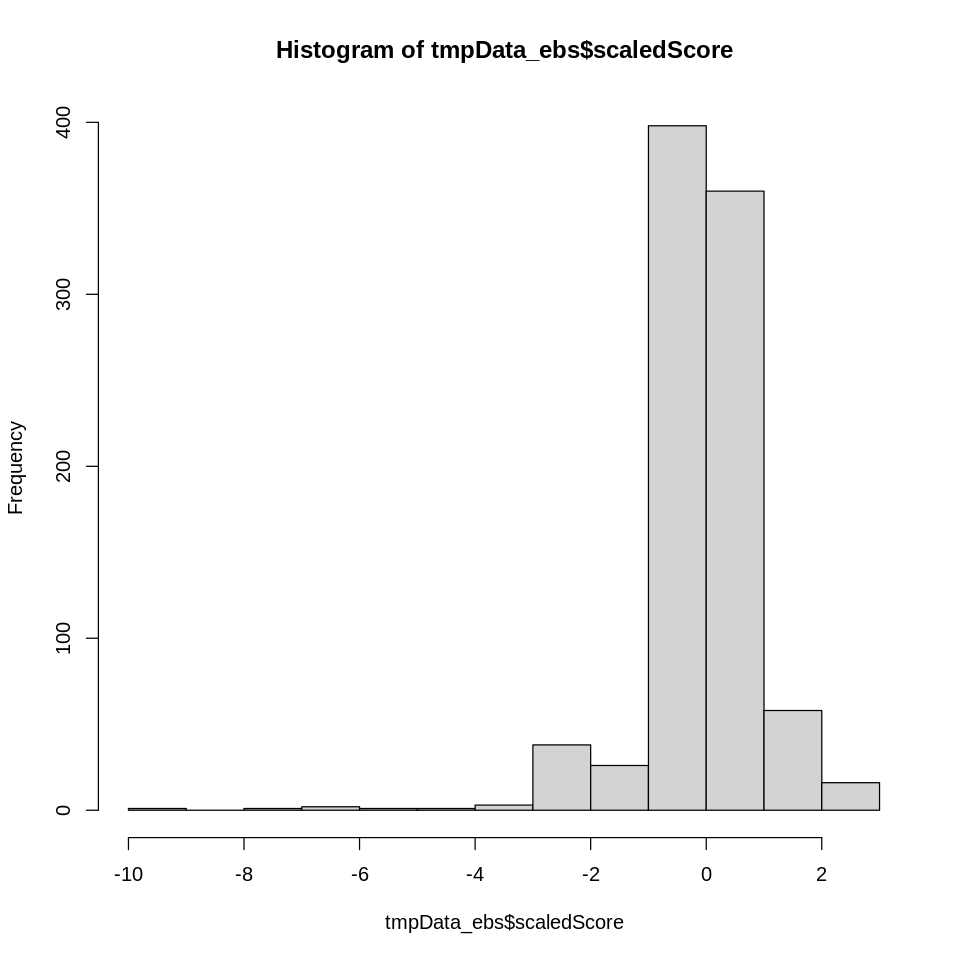

In [475]:
tmpData_ebs = testData_merged[testData_merged$OG == 'OG0002804',]

options(repr.plot.width=8, repr.plot.height=8)
hist(tmpData_ebs$scaledScore)


head(tmpData_ebs[order(tmpData_ebs$scaledScore),],10)
tail(tmpData_ebs[order(tmpData_ebs$scaledScore),],10)

seqID,zeroShotScore,scaledScore,assemblyID,seq1,Codons,Compared,Ambigiuous,Indels,Ns,⋯,envPC_37,envPC_38,envPC_39,envPC_40,PMS,AAlength,scaled.dn.ds,Frameshift,groups,groups2
<chr>,<dbl>,<dbl>,<fct>,<chr>,<int>,<int>,<int>,<int>,<int>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<int>,<dbl>,<int>,<chr>,<chr>
OG0018953:Sn-CAM1369-DRAFT-PanAnd-1.0:1,1.516864,-11.003453,Sn-CAM1369-DRAFT-PanAnd-1.0,OG0018953:ASM1935983v1:0,222,219,3,3,0,⋯,0.58202,-0.15204,0.38633,0.59221,1,20,-0.27429068,1,7,7
OG0018953:ASM980554v1:0,2.831890,-7.894486,ASM980554v1,OG0018953:ASM1935983v1:0,222,217,5,5,0,⋯,-0.01495,-0.64481,-0.04990,0.93964,1,62,0.05001889,1,7,7
OG0018953:AN22TNTL092:0,2.962777,-7.585043,AN22TNTL092,OG0018953:ASM1935983v1:0,222,220,2,2,0,⋯,-0.64367,1.09877,-0.94524,-0.44950,1,130,-0.01192610,1,7,7
OG0018953:TSU_Scap_1:1,3.014433,-7.462920,TSU_Scap_1,OG0018953:ASM1935983v1:0,222,222,0,0,0,⋯,-0.25395,-0.03396,-0.67576,0.46953,1,60,0.69998741,1,7,7
OG0018953:AN21TNTL0082:0,3.098895,-7.263236,AN21TNTL0082,OG0018953:ASM1935983v1:0,222,221,1,1,0,⋯,-1.19487,0.21927,-0.29435,-1.22959,0,100,-0.83197959,0,1,1
OG0018953:AN22TNTL008:0,3.114162,-7.227142,AN22TNTL008,OG0018953:ASM1935983v1:0,222,217,5,5,0,⋯,-1.76197,0.44634,3.06887,-1.70034,0,112,1.31514272,0,1,3
OG0018953:AN21TSTL0264:0,3.184432,-7.061010,AN21TSTL0264,OG0018953:ASM1935983v1:0,222,221,1,1,0,⋯,-0.14986,-1.29181,-1.05072,0.56063,0,100,-0.69353201,0,1,1
OG0018953:AN21TSTL0231:0,3.205231,-7.011838,AN21TSTL0231,OG0018953:ASM1935983v1:0,222,219,3,3,0,⋯,0.46633,0.20880,0.40865,0.19225,0,88,-0.71509094,0,1,1
OG0018953:AN21TS46:0,3.425467,-6.491159,AN21TS46,OG0018953:ASM1935983v1:0,222,219,3,3,0,⋯,-0.93803,-0.03743,1.21567,1.27253,0,59,-0.65121256,0,1,1


seqID,zeroShotScore,scaledScore,assemblyID,seq1,Codons,Compared,Ambigiuous,Indels,Ns,⋯,envPC_37,envPC_38,envPC_39,envPC_40,PMS,AAlength,scaled.dn.ds,Frameshift,groups,groups2
<chr>,<dbl>,<dbl>,<fct>,<chr>,<int>,<int>,<int>,<int>,<int>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<int>,<dbl>,<int>,<chr>,<chr>
OG0018953:AN21TS31:0,6.793822,1.472261,AN21TS31,OG0018953:ASM1935983v1:0,222,219,3,3,0,⋯,0.57744,-0.67764,0.28869,-1.57722,0,164,-2.207847,0,1,1
OG0018953:AN21TS26:1,6.797312,1.480513,AN21TS26,OG0018953:ASM1935983v1:0,222,222,0,0,0,⋯,7.51903,0.11048,-0.65696,4.09849,0,153,-2.318765,0,1,1
OG0018953:AN21TNTL0154:0,6.805042,1.498788,AN21TNTL0154,OG0018953:ASM1935983v1:0,222,222,0,0,0,⋯,-0.43203,-0.49288,-0.42428,-0.42454,0,164,-2.511402,0,1,1
OG0018953:AN21TSTL0280:0,6.811132,1.513185,AN21TSTL0280,OG0018953:ASM1935983v1:0,222,222,0,0,0,⋯,-0.58452,-0.19888,0.33586,-0.11080,0,164,-2.542921,0,1,1
OG0018953:AN21TNTL0161:0,6.817631,1.528551,AN21TNTL0161,OG0018953:ASM1935983v1:0,222,222,0,0,0,⋯,-2.17340,1.07282,2.20607,-0.58784,0,139,-2.638646,0,1,1
OG0018953:SRR7121975:0,6.836202,1.572455,SRR7121975,OG0018953:ASM1935983v1:0,222,222,0,0,0,⋯,-3.33049,0.11854,1.14936,2.12431,0,162,-2.352751,0,1,1
OG0018953:AT20TS1MCRTL004:0,6.839406,1.580030,AT20TS1MCRTL004,OG0018953:ASM1935983v1:0,222,219,3,3,0,⋯,1.90236,-1.92798,0.37701,-0.49245,0,164,-2.384418,0,1,1
OG0018953:AN21TS26:0,6.851646,1.608967,AN21TS26,OG0018953:ASM1935983v1:0,222,222,0,0,0,⋯,7.51903,0.11048,-0.65696,4.09849,0,153,-2.308441,0,1,1
OG0018953:SRR7121975:1,6.933644,1.802826,SRR7121975,OG0018953:ASM1935983v1:0,222,222,0,0,0,⋯,-3.33049,0.11854,1.14936,2.12431,0,162,-2.359908,0,1,1


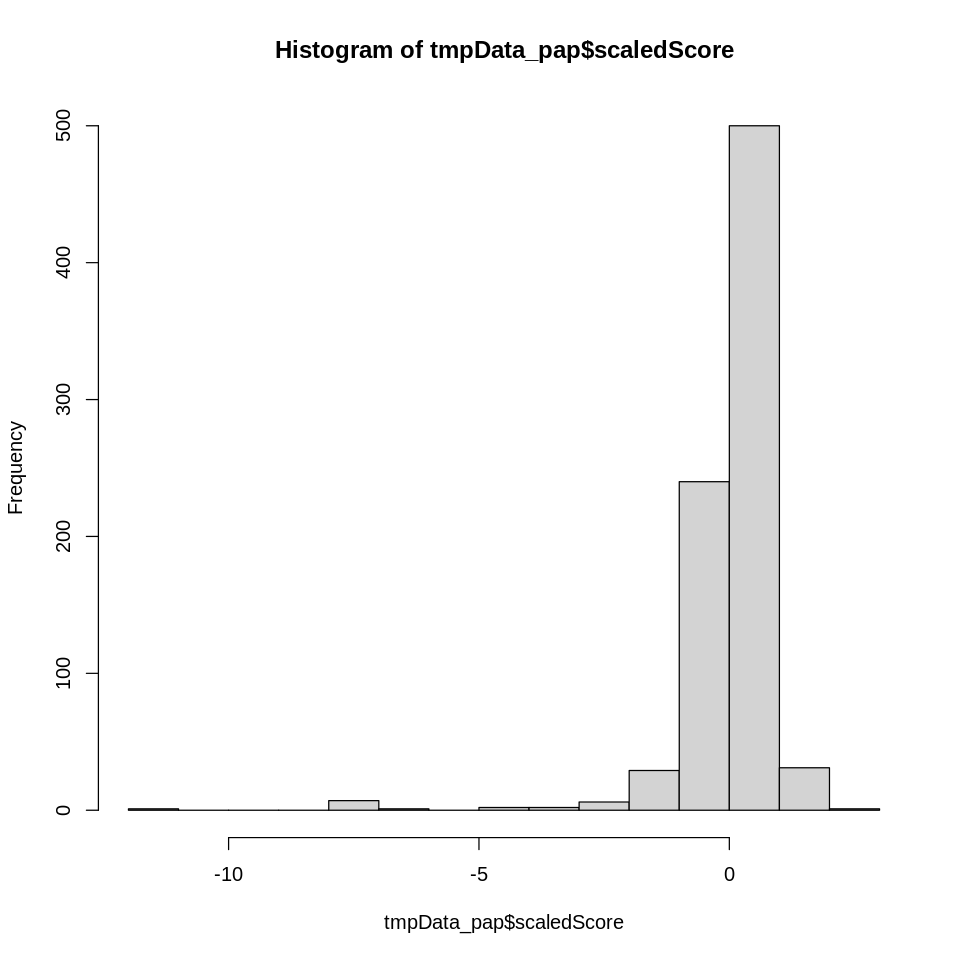

In [376]:
tmpData_pap = testData_merged[testData_merged$OG == 'OG0018953',]

options(repr.plot.width=8, repr.plot.height=8)
hist(tmpData_pap$scaledScore)


head(tmpData_pap[order(tmpData_pap$scaledScore),],10)
tail(tmpData_pap[order(tmpData_pap$scaledScore),],10)

seqID,zeroShotScore,scaledScore,assemblyID,seq1,Codons,Compared,Ambigiuous,Indels,Ns,⋯,envPC_39,envPC_40,PMS,AAlength,scaled.dn.ds,Frameshift,groups,groups2,zeroShotScore_DNA,scaledScore_DNA
<chr>,<dbl>,<dbl>,<fct>,<chr>,<int>,<int>,<int>,<int>,<int>,⋯,<dbl>,<dbl>,<int>,<int>,<dbl>,<int>,<chr>,<chr>,<dbl>,<dbl>
OG0015019:AN22TNTL170:0,1.352833,-9.561735,AN22TNTL170,OG0015019:ASM1935983v1:0,370,361,9,9,0,⋯,0.58021,0.95084,1,113,3.77074537,1,7,7,2.176189,-3.17738045
OG0015019:ASM163321v2:0,1.565130,-8.994142,ASM163321v2,OG0015019:ASM1935983v1:0,370,369,1,1,0,⋯,-0.04288,0.41473,1,174,5.86046819,1,7,7,3.140408,0.01687478
OG0015019:Phyllostachys_bambusoides:0,2.121734,-7.506018,Phyllostachys_bambusoides,OG0015019:ASM1935983v1:0,370,370,0,0,0,⋯,0.55359,0.25375,1,171,1.66193992,1,7,7,3.163335,0.09282444
OG0015019:AN21TSTL0264:0,2.770529,-5.771415,AN21TSTL0264,OG0015019:ASM1935983v1:0,370,367,3,3,0,⋯,-1.05072,0.56063,0,67,-2.17235006,0,1,1,3.739736,2.00232176
OG0015019:AN21TSTL0241:0,2.836366,-5.595396,AN21TSTL0241,OG0015019:ASM1935983v1:0,370,369,1,1,0,⋯,0.58021,0.95084,1,20,1.82809948,1,7,7,2.923868,-0.70047966
OG0015019:ChrysopogonNigritanus_v1.0:0,2.839891,-5.585970,ChrysopogonNigritanus_v1.0,OG0015019:ASM1935983v1:0,370,369,1,1,0,⋯,-0.48072,0.20626,1,54,-0.18737704,1,7,7,2.689865,-1.47567977
OG0015019:AN21TNTL0083:0,2.942045,-5.312855,AN21TNTL0083,OG0015019:ASM1935983v1:0,370,368,2,2,0,⋯,1.22322,1.29308,1,107,-0.03923061,1,7,7,2.987753,-0.48884147
OG0015019:AT20TN1MCRTL038:0,3.003681,-5.148067,AT20TN1MCRTL038,OG0015019:ASM1935983v1:0,370,369,1,1,0,⋯,-0.64920,1.43282,1,73,-1.73330589,1,7,7,3.635439,1.65680565
OG0015019:AN21TSTL0216:0,3.126372,-4.820043,AN21TSTL0216,OG0015019:ASM1935983v1:0,370,370,0,0,0,⋯,0.26182,1.21790,1,111,0.83704475,1,7,7,3.244847,0.36285786


seqID,zeroShotScore,scaledScore,assemblyID,seq1,Codons,Compared,Ambigiuous,Indels,Ns,⋯,envPC_39,envPC_40,PMS,AAlength,scaled.dn.ds,Frameshift,groups,groups2,zeroShotScore_DNA,scaledScore_DNA
<chr>,<dbl>,<dbl>,<fct>,<chr>,<int>,<int>,<int>,<int>,<int>,⋯,<dbl>,<dbl>,<int>,<int>,<dbl>,<int>,<chr>,<chr>,<dbl>,<dbl>
OG0015019:AN21TNTL0091:0,5.207978,0.7452896,AN21TNTL0091,OG0015019:ASM1935983v1:0,370,370,0,0,0,⋯,0.98906,1.62537,0,205,-1.2576534,0,1,1,2.469395,-2.20605292
OG0015019:AT20TN1MCRTL026:0,5.238228,0.8261667,AT20TN1MCRTL026,OG0015019:ASM1935983v1:0,370,370,0,0,0,⋯,0.08904,0.54461,0,250,-1.1750997,0,1,1,3.157488,0.07345581
OG0015019:MCRTL039:0,5.268736,0.9077328,MCRTL039,OG0015019:ASM1935983v1:0,370,370,0,0,0,⋯,-0.09335,0.46274,0,173,-1.4301635,0,1,1,2.716698,-1.38678739
OG0015019:MCRTL039:1,5.268736,0.9077328,MCRTL039,OG0015019:ASM1935983v1:0,370,370,0,0,0,⋯,-0.09335,0.46274,0,173,-1.4924126,0,1,1,2.723330,-1.36481849
OG0015019:MCRTL052:0,5.268736,0.9077328,MCRTL052,OG0015019:ASM1935983v1:0,370,370,0,0,0,⋯,-0.09335,0.46274,0,173,-1.4924126,0,1,1,2.723330,-1.36481849
OG0015019:AN22TNTL108:0,5.277454,0.9310407,AN22TNTL108,OG0015019:ASM1935983v1:0,370,370,0,0,0,⋯,0.59396,-0.04904,0,172,-1.4407693,0,1,1,2.761380,-1.23876716
OG0015019:AN22TNTL108:1,5.277454,0.9310407,AN22TNTL108,OG0015019:ASM1935983v1:0,370,370,0,0,0,⋯,0.59396,-0.04904,0,172,-1.5025916,0,1,1,2.764704,-1.22775631
OG0015019:MCRTL069:1,5.277454,0.9310407,MCRTL069,OG0015019:ASM1935983v1:0,370,370,0,0,0,⋯,-1.05366,0.25952,0,172,-1.5025916,0,1,1,2.754500,-1.26155823
OG0015019:AT20TN1MCRTL070:0,5.360156,1.1521516,AT20TN1MCRTL070,OG0015019:ASM1935983v1:0,370,370,0,0,0,⋯,4.67319,2.93254,0,164,-1.4183267,0,1,1,2.564152,-1.89214319


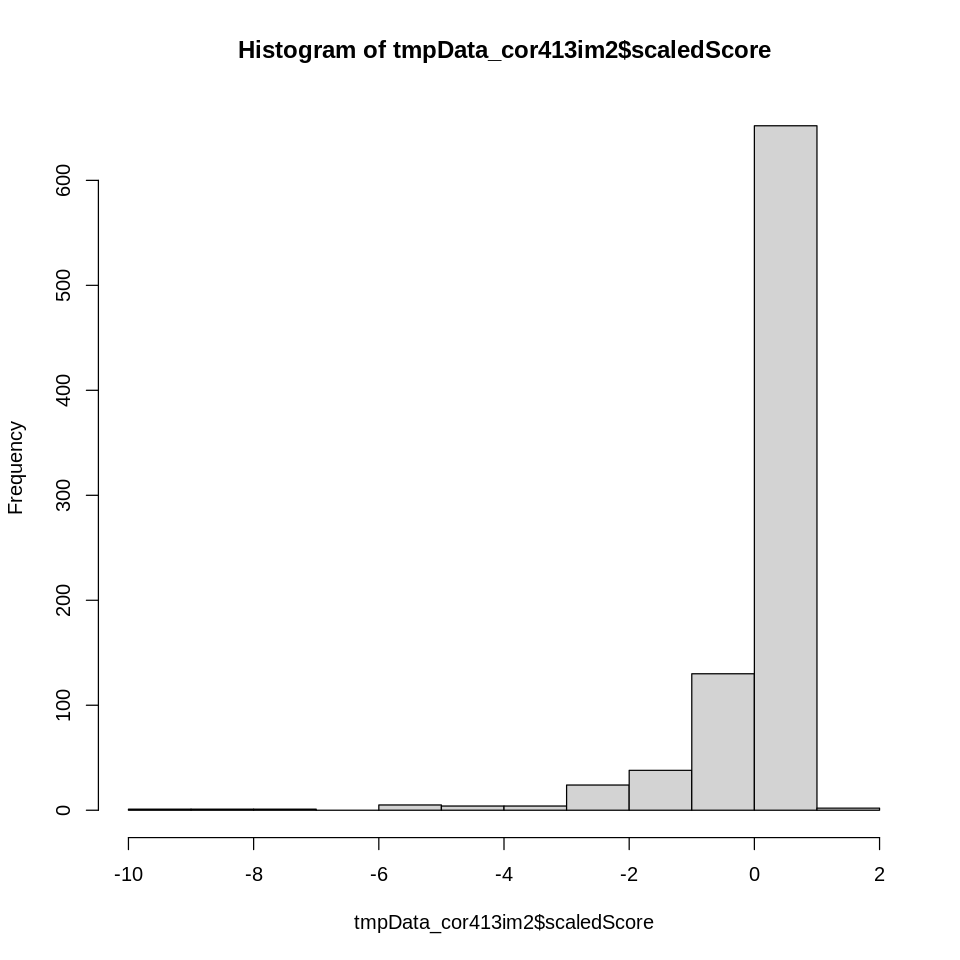

In [798]:
tmpData_cor413im2 = testData_merged[testData_merged$OG == 'OG0015019',]

options(repr.plot.width=8, repr.plot.height=8)
hist(tmpData_cor413im2$scaledScore)


head(tmpData_cor413im2[order(tmpData_cor413im2$scaledScore),],10)
tail(tmpData_cor413im2[order(tmpData_cor413im2$scaledScore),],10)

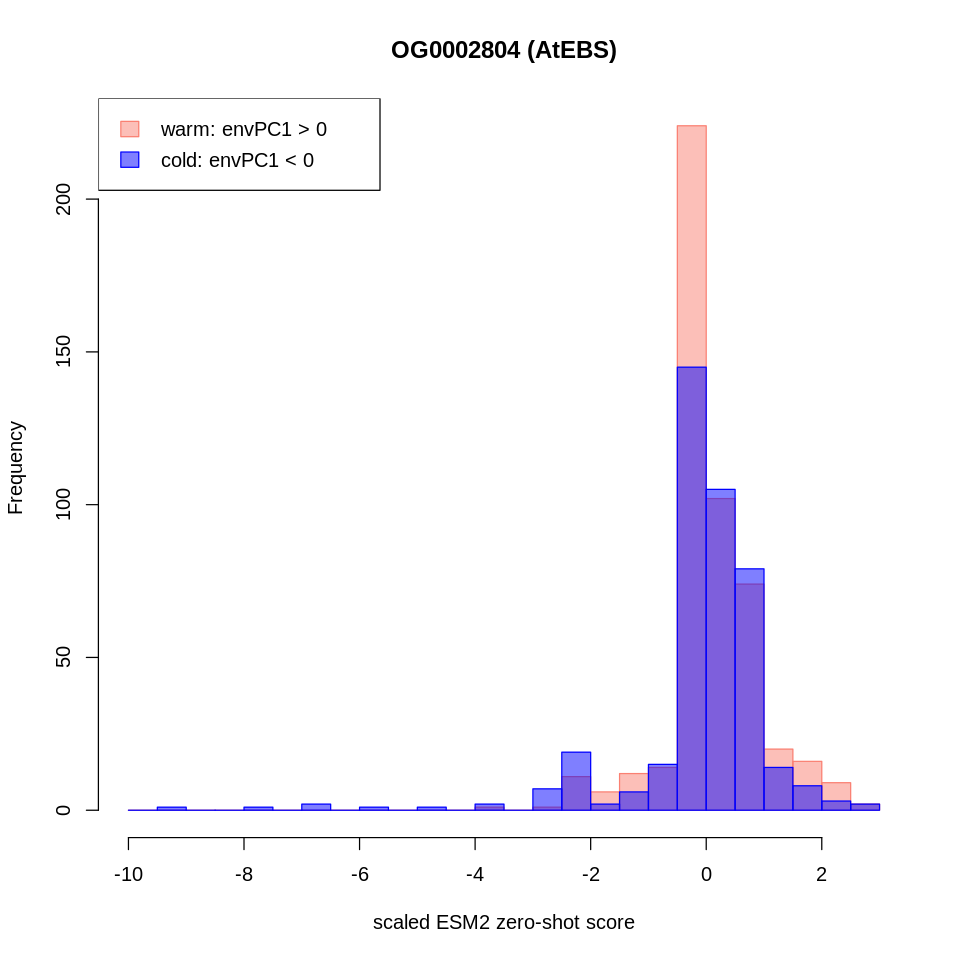

In [476]:
hist(tmpData_ebs$scaledScore[tmpData_ebs$envPC_1>= 0],col = alpha("salmon",.5),border = "salmon",
     main = "OG0002804 (AtEBS)",xlim = c(-10,3),breaks = seq(-10,3,0.5),xlab = "scaled ESM2 zero-shot score")
hist(tmpData_ebs$scaledScore[tmpData_ebs$envPC_1< 0],add =T, col =alpha("blue",.5),border = "blue",
     breaks = seq(-10,3,0.5))
legend("topleft",fill = alpha(c("salmon","blue"),.5),border = c("salmon","blue"),
       legend = c("warm: envPC1 > 0","cold: envPC1 < 0"))

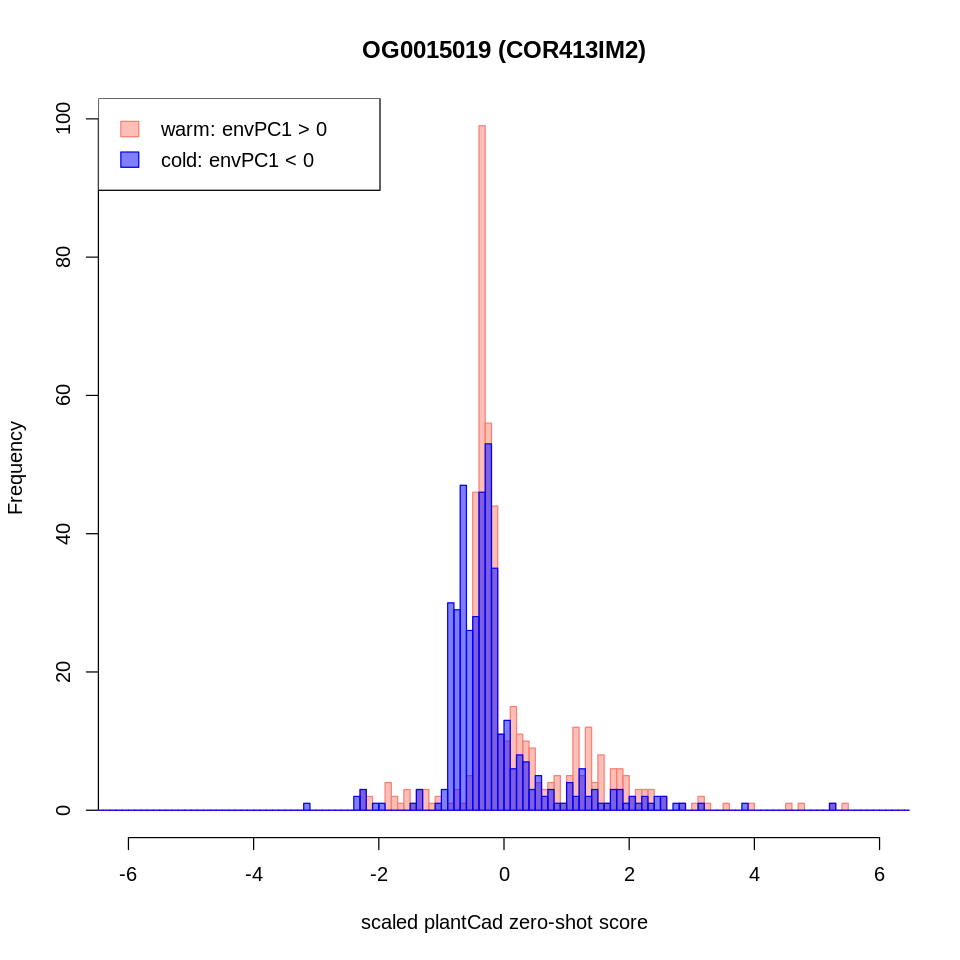

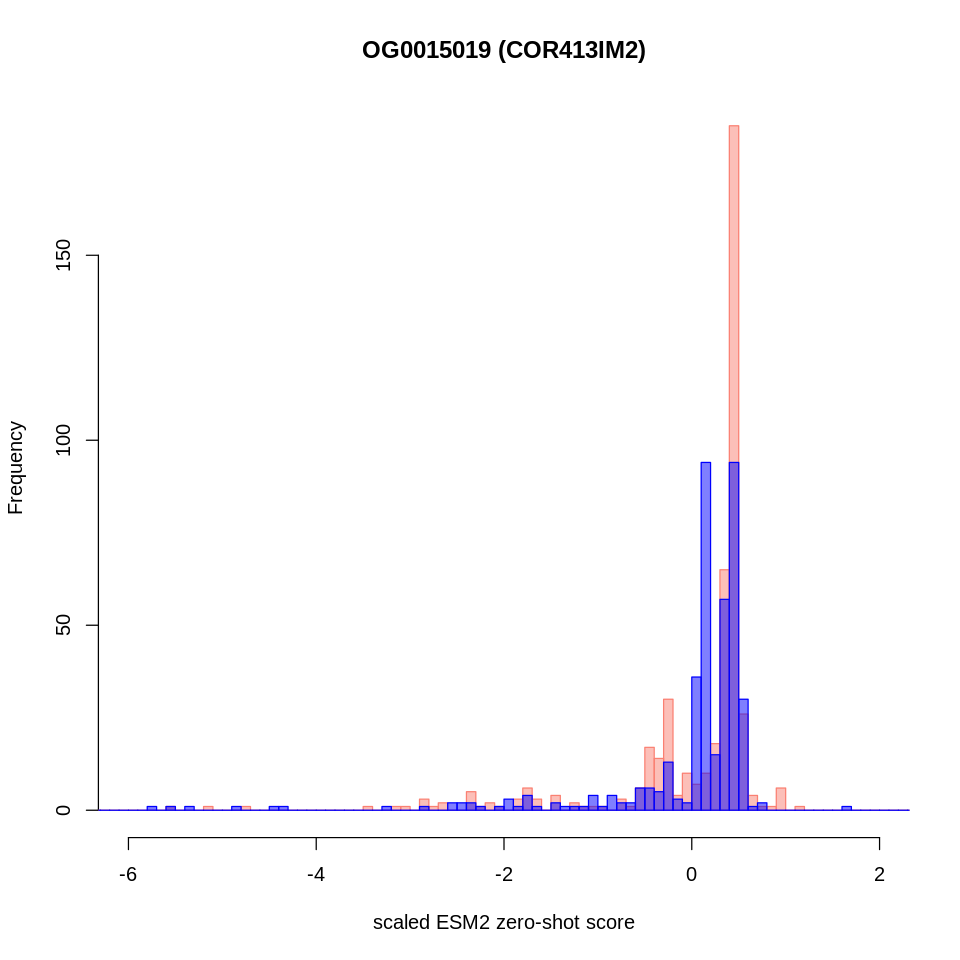

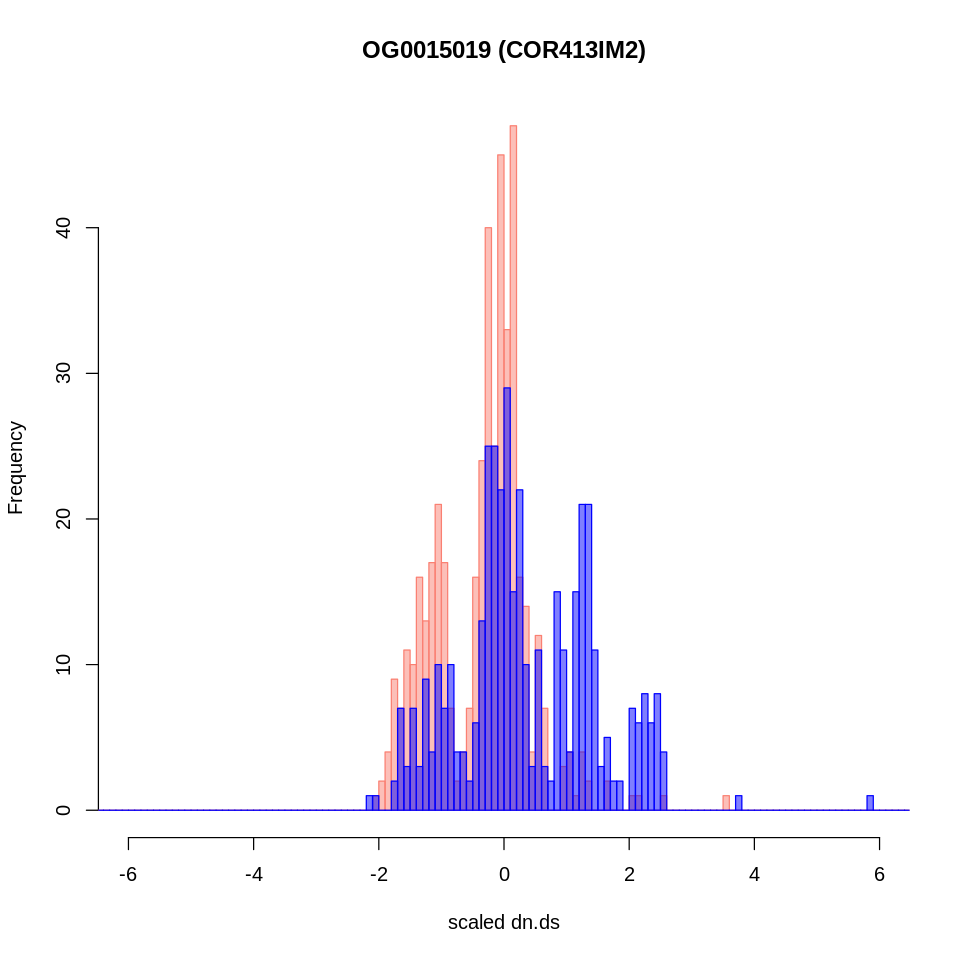

In [814]:
hist(tmpData_cor413im2$scaledScore_DNA[tmpData_cor413im2$envPC_1>= 0],col = alpha("salmon",.5),border = "salmon",
     main = "OG0015019 (COR413IM2)",xlim = c(-6,6),breaks = seq(-10,10,0.1),xlab = "scaled plantCad zero-shot score")
hist(tmpData_cor413im2$scaledScore_DNA[tmpData_cor413im2$envPC_1< 0],add =T, col =alpha("blue",.5),border = "blue",
     breaks = seq(-10,10,0.1))
legend("topleft",fill = alpha(c("salmon","blue"),.5),border = c("salmon","blue"),
       legend = c("warm: envPC1 > 0","cold: envPC1 < 0"))
hist(tmpData_cor413im2$scaledScore[tmpData_cor413im2$envPC_1>= 0],col = alpha("salmon",.5),border = "salmon",
     main = "OG0015019 (COR413IM2)",xlim = c(-6,2),breaks = seq(-10,10,0.1),xlab = "scaled ESM2 zero-shot score")
hist(tmpData_cor413im2$scaledScore[tmpData_cor413im2$envPC_1< 0],add =T, col =alpha("blue",.5),border = "blue",
     breaks = seq(-10,10,0.1))
hist(tmpData_cor413im2$scaled.dn.ds[tmpData_cor413im2$envPC_1>= 0],col = alpha("salmon",.5),border = "salmon",
     main = "OG0015019 (COR413IM2)",xlim = c(-6,6),breaks = seq(-10,10,0.1),xlab = "scaled dn.ds")
hist(tmpData_cor413im2$scaled.dn.ds[tmpData_cor413im2$envPC_1< 0],add =T, col =alpha("blue",.5),border = "blue",
     breaks = seq(-10,10,0.1))

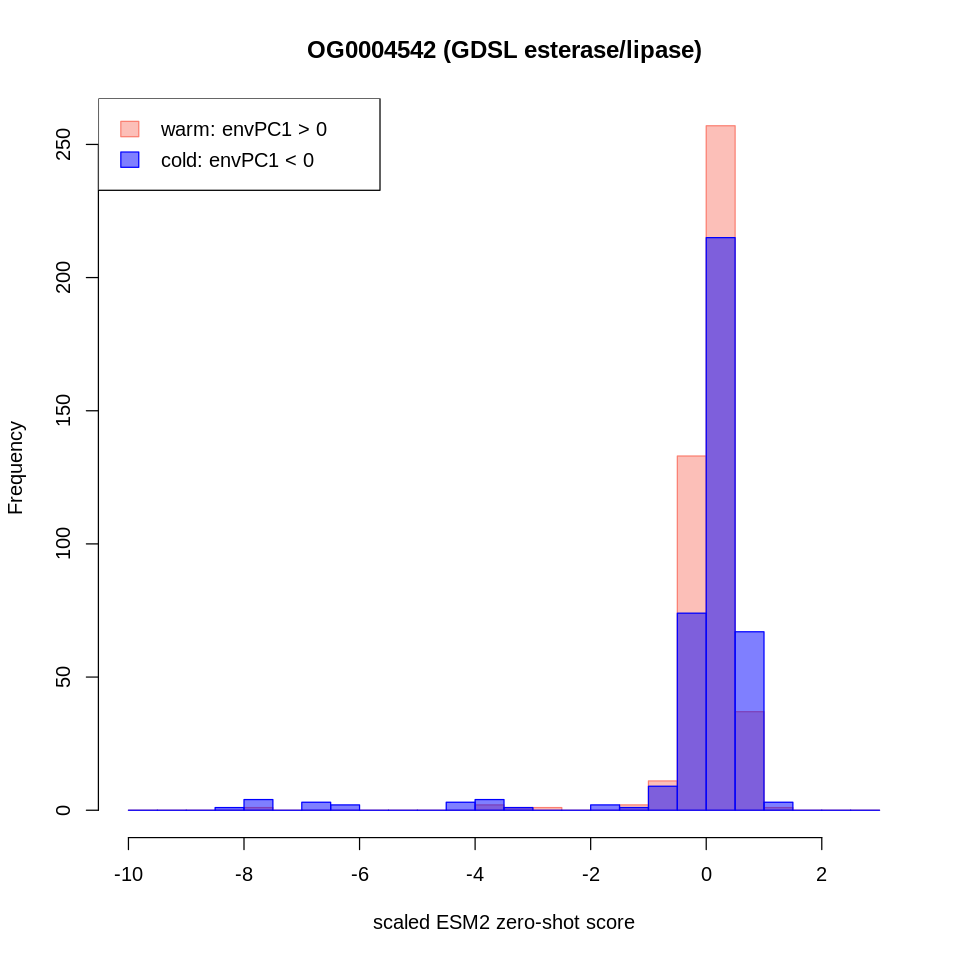

In [362]:
hist(tmpData_gdsl$scaledScore[tmpData_gdsl$envPC_1>= 0],col = alpha("salmon",.5),border = "salmon",
     main = "OG0004542 (GDSL esterase/lipase)",xlim = c(-10,3),breaks = seq(-10,3,0.5),xlab = "scaled ESM2 zero-shot score")
hist(tmpData_gdsl$scaledScore[tmpData_gdsl$envPC_1< 0],add =T, col =alpha("blue",.5),border = "blue",
     breaks = seq(-10,3,0.5))
legend("topleft",fill = alpha(c("salmon","blue"),.5),border = c("salmon","blue"),
       legend = c("warm: envPC1 > 0","cold: envPC1 < 0"))

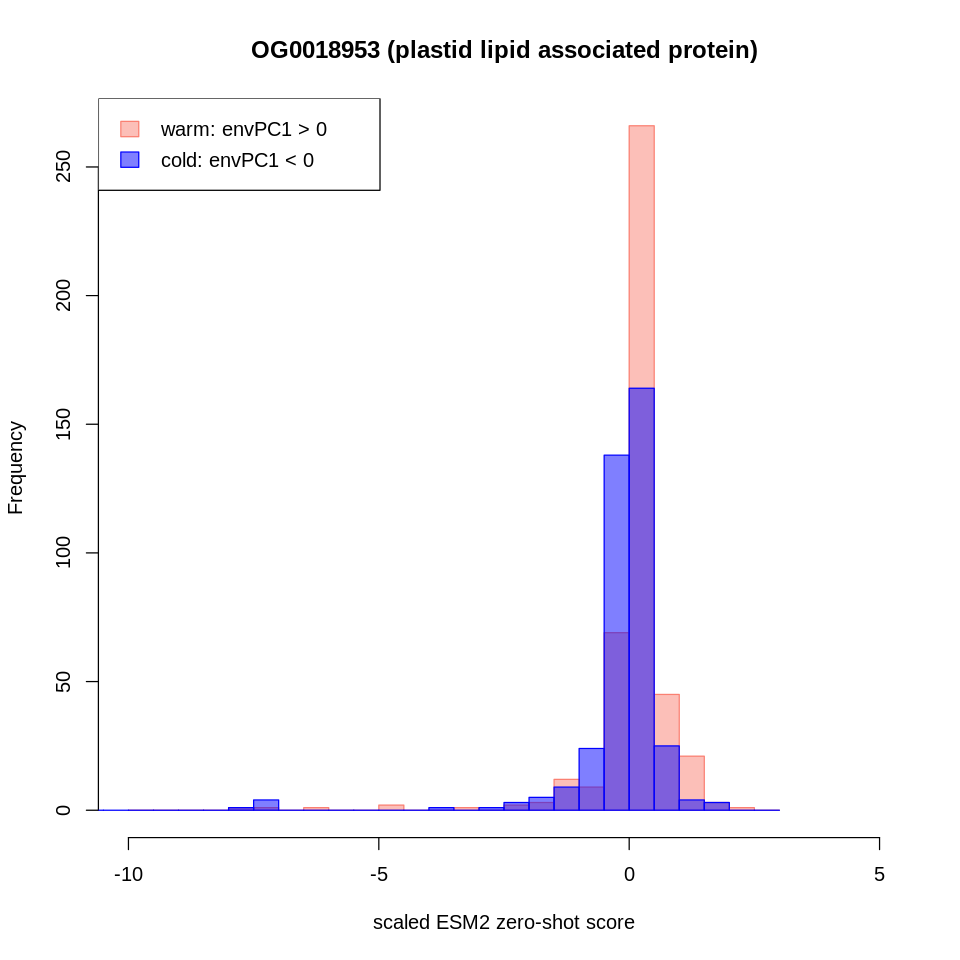

In [382]:
hist(tmpData_pap$scaledScore[tmpData_pap$envPC_1>= 0],col = alpha("salmon",.5),border = "salmon",
     main = "OG0018953 (plastid lipid associated protein)",xlim = c(-10,5),breaks = seq(-10,3,0.5),xlab = "scaled ESM2 zero-shot score")
hist(tmpData_pap$scaledScore[tmpData_pap$envPC_1< 0],add =T, col =alpha("blue",.5),border = "blue",
     breaks = seq(-12,3,0.5))
legend("topleft",fill = alpha(c("salmon","blue"),.5),border = c("salmon","blue"),
       legend = c("warm: envPC1 > 0","cold: envPC1 < 0"))

In [383]:
table(tmpData_pap$envPC_1>= 0)


FALSE  TRUE 
  383   437 

In [338]:
envDf$assemblyID

,assemblyID,bio01_Annual_Mean_Temperature_quan10,bio01_Annual_Mean_Temperature_quan50,bio01_Annual_Mean_Temperature_quan90,bio10_Mean_Temperature_Warmest_Quarter_quan10,bio10_Mean_Temperature_Warmest_Quarter_quan50,bio10_Mean_Temperature_Warmest_Quarter_quan90,bio11_Mean_Temperature_Coldest_Quarter_quan10,bio11_Mean_Temperature_Coldest_Quarter_quan50,bio11_Mean_Temperature_Coldest_Quarter_quan90,⋯,envPC_31,envPC_32,envPC_33,envPC_34,envPC_35,envPC_36,envPC_37,envPC_38,envPC_39,envPC_40
,<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
10wheat_assembly_jagger,10wheat_assembly_jagger,6.133500,13.1071663,20.018167,17.007999,23.71200,28.88067,-5.1043334,3.24566662,11.958000,⋯,0.99264,-0.88270,0.80461,-0.40422,-1.26081,-0.07097,0.20012,0.50082,0.57836,1.26217
10wheat_assembly_stanley,10wheat_assembly_stanley,6.133500,13.1071663,20.018167,17.007999,23.71200,28.88067,-5.1043334,3.24566662,11.958000,⋯,0.99264,-0.88270,0.80461,-0.40422,-1.26081,-0.07097,0.20012,0.50082,0.57836,1.26217
10wheat_assembly_lancer,10wheat_assembly_lancer,6.133500,13.1071663,20.018167,17.007999,23.71200,28.88067,-5.1043334,3.24566662,11.958000,⋯,0.99264,-0.88270,0.80461,-0.40422,-1.26081,-0.07097,0.20012,0.50082,0.57836,1.26217
Triticum_aestivum_Claire_EIv1.1,Triticum_aestivum_Claire_EIv1.1,6.133500,13.1071663,20.018167,17.007999,23.71200,28.88067,-5.1043334,3.24566662,11.958000,⋯,0.99264,-0.88270,0.80461,-0.40422,-1.26081,-0.07097,0.20012,0.50082,0.57836,1.26217
WEW_v2.1,WEW_v2.1,16.764166,18.7045002,20.341333,23.534000,25.71667,27.30067,8.9806662,10.91266632,12.826800,⋯,-0.05710,0.30570,0.76211,0.52841,0.31222,-1.22973,0.26641,-0.06968,0.46370,2.34564
Svevo.v1,Svevo.v1,8.796250,12.3255835,15.784000,16.990000,20.43933,24.17740,0.2693333,4.98433328,8.728067,⋯,0.44827,-0.29788,-0.29079,-0.05951,-0.22431,0.86044,-0.67817,-0.47077,0.25302,-0.01622
SRR13484808,SRR13484808,9.772833,16.2625008,18.427767,21.112667,28.40867,30.88000,-2.3980000,4.28600025,6.096666,⋯,2.59143,0.18100,-0.09097,1.71525,-1.17632,1.33499,-0.26378,1.65355,-2.21338,1.22726
Triticum_petropavlovskyi,Triticum_petropavlovskyi,-6.387500,-0.9163332,8.996217,4.408667,11.68400,22.76780,-17.6293335,-14.58400011,-6.931734,⋯,-0.34366,-1.03797,1.37552,4.82592,-2.06554,-3.28306,-0.21600,-0.06277,1.05704,-2.53961
PI306540_Tmono,PI306540_Tmono,8.476017,11.7157893,17.294016,17.985133,21.71367,27.47440,-2.5315999,2.48399997,7.888667,⋯,1.87978,0.87968,-0.76011,0.20469,-0.71951,1.08654,-0.57305,0.23509,-0.31397,-0.47426


In [384]:
avgZS_perTaxa = tapply(testData_merged$scaledScore,testData_merged$assemblyID,median,na.rm = T)

# life history - envPC association

In [518]:
fit_model_lifeHistory <- function(data, Kmat) {
#   library(asreml)
    gc()
  asreml.options(verbose = FALSE)
  filtered_data <- data
  #filtered_data <- filtered_data %>% group_by(assemblyID) %>% slice_max(queryCov, n = 1, with_ties = FALSE) %>% ungroup()
  phyloK_OG <- Kmat[rownames(Kmat) %in% filtered_data$assemblyID,]
  phyloK_OG <- phyloK_OG[,colnames(phyloK_OG) %in% filtered_data$assemblyID]
  model <- asreml(fixed = lifeHistoryNum ~ envPC_1 + envPC_2 + envPC_3 + envPC_4 + envPC_5 + envPC_6 + envPC_7 + envPC_8 + envPC_9 + envPC_10,family = asr_binomial(),
                  random = ~ vm(assemblyID, phyloK_OG), ai.sing = TRUE, data = filtered_data)
  #model <- asreml(fixed = lifeHistoryNumeric ~ dn.ds, random = ~compdup, ai.sing = TRUE, data = filtered_data)
  modelSummary <- summary(model)
  loglik <- modelSummary$loglik
  phylo_explained <- modelSummary$varcomp$component[2]/sum(modelSummary$varcomp$component)
  modelWald <- wald.asreml(model)
  envPC_coeff <- model$coefficients$fixed[2:11]
  envPC_pval <- modelWald[2:11,4]
  envPC_explained <- modelWald[2:11,2]/sum(modelWald[,2])
#     return(model)
  return(c(envPC_coeff, envPC_pval, loglik, phylo_explained, envPC_explained))
}

In [519]:
fit_model_lifeHistory_noK <- function(data) {
#   library(asreml)
    gc()
  asreml.options(verbose = FALSE)
  filtered_data <- data
  #filtered_data <- filtered_data %>% group_by(assemblyID) %>% slice_max(queryCov, n = 1, with_ties = FALSE) %>% ungroup()
  model <- asreml(fixed = lifeHistoryNum ~ envPC_1 + envPC_2 + envPC_3 + envPC_4 + envPC_5 + envPC_6 + envPC_7 + envPC_8 + envPC_9 + envPC_10,family = asr_binomial(),
                  ai.sing = TRUE, data = filtered_data)
  #model <- asreml(fixed = lifeHistoryNumeric ~ dn.ds, random = ~compdup, ai.sing = TRUE, data = filtered_data)
  modelSummary <- summary(model)
  loglik <- modelSummary$loglik
  modelWald <- wald.asreml(model)
  envPC_coeff <- model$coefficients$fixed[2:11]
  envPC_pval <- modelWald[2:11,4]
  envPC_explained <- modelWald[2:11,2]/sum(modelWald[,2])
#     return(model)
  return(c(envPC_coeff, envPC_pval, loglik, envPC_explained))
}

In [481]:
lifeHistoryAssTab = merge(metadata,envDf,by = "assemblyID")

In [528]:
lifeHistoryAssTab$lifeHistoryNum = lifeHistoryAssTab$lifeHistory
lifeHistoryAssTab$lifeHistoryNum[!lifeHistoryAssTab$lifeHistory%in%c("annual","perennial")] = NA
lifeHistoryAssTab$lifeHistoryNum = as.numeric(as.factor(lifeHistoryAssTab$lifeHistoryNum))-1

In [510]:
lifeHistoryAssTab$assemblyID = as.factor(lifeHistoryAssTab$assemblyID)

In [532]:
asreml.options(maxit = 30,verbose = F)
lifeHistoryAssRes = fit_model_lifeHistory(lifeHistoryAssTab,phyloKMat)
lifeHistoryAssRes_noK = fit_model_lifeHistory_noK(lifeHistoryAssTab)

ASReml Version 4.2 24/09/2024 10:59:50
          LogLik        Sigma2     DF     wall
 1     -1053.383           1.0    715   10:59:50
 2     -1049.602           1.0    715   10:59:51
 3     -1047.105           1.0    715   10:59:51
 4     -1066.960           1.0    715   10:59:51
 5     -1102.269           1.0    715   10:59:51
 6     -1132.549           1.0    715   10:59:51
 7     -1158.853           1.0    715   10:59:51
 8     -1181.683           1.0    715   10:59:51
 9     -1201.218           1.0    715   10:59:52
10     -1217.620           1.0    715   10:59:52
11     -1231.116           1.0    715   10:59:52
12     -1242.004           1.0    715   10:59:52
13     -1250.638           1.0    715   10:59:52
14     -1257.384           1.0    715   10:59:52
15     -1262.590           1.0    715   10:59:52
16     -1268.063           1.0    715   10:59:53
17     -1271.186           1.0    715   10:59:53
18     -1273.773           1.0    715   10:59:53
19     -1275.463           1.0  

In [533]:
names(lifeHistoryAssRes) = c(paste0("Coeff_envPC",1:10),paste0("Pval_envPC",1:10),"loglik",
                             "VarComp_phylo",paste0("VAE_envPC",1:10))
names(lifeHistoryAssRes_noK) = c(paste0("Coeff_envPC",1:10),paste0("Pval_envPC",1:10),"loglik",
                                 paste0("VAE_envPC",1:10))


In [537]:
lifeHistoryAssOut = cbind(lifeHistoryAssRes[1:10],lifeHistoryAssRes[11:20],lifeHistoryAssRes_noK[1:10],lifeHistoryAssRes_noK[11:20])

In [538]:
rownames(lifeHistoryAssOut) = paste("envPC",1:10,sep = "")
colnames(lifeHistoryAssOut) = c("coefficient-K","p_val-K","coefficient","p_val")

In [541]:
lifeHistoryAssOut
write.table(lifeHistoryAssOut,'/workdir/sh2246/p_phyloGWAS/output/lifeHistoryEnvAssRes.txt',quote = F,sep = "\t",row.names = T,col.names = T)

,coefficient-K,p_val-K,coefficient,p_val
envPC1,-0.54376886,3.363099e-06,0.22327742,2.035913e-01
envPC2,-0.72763060,7.224314e-04,-0.77820546,9.627738e-09
envPC3,-0.15120692,1.544345e-01,-0.22202195,3.857736e-03
envPC4,-0.03871251,6.830807e-01,-0.19919389,3.244200e-03
envPC5,-0.12694430,4.016002e-01,0.03367554,6.621440e-01
envPC6,-0.37406996,2.371271e-02,-0.49712923,2.243669e-03
envPC7,-0.12063520,2.493364e-01,-0.10384808,3.752878e-01
envPC8,0.55288356,3.380250e-02,0.65562691,8.535378e-10
envPC9,-0.61545012,4.144785e-03,-0.63650125,3.734532e-07
envPC10,-0.36437847,1.003559e-01,-0.23869937,7.781037e-02


In [ ]:
asreml.options(maxit = 30,verbose = F)
testRes = mclapply(OG_list,function(x) try(fit_model_ePC1(x,data = testData_merged,phyloK),silent = T),mc.cores = 2)
testRes = t(simplify2array(testRes[sapply(testRes,length)==7]))

In [ ]:
testRes_sorted = na.omit(testRes[order(as.numeric(testRes[,3])),])

In [ ]:
dim(testRes_sorted)
head(testRes_sorted)

In [ ]:
mycol = rep("grey",nrow(testRes_sorted))
mycol[testRes_sorted[,2]>0& -log10(as.numeric(testRes_sorted[,3]))>4.47] = "red"
mycol[testRes_sorted[,2]<0& -log10(as.numeric(testRes_sorted[,3]))>4.47] = "blue"

In [ ]:
qq(as.numeric(testRes_sorted[,3]),col = mycol)

In [ ]:
plot(as.numeric(testRes_sorted[,2]),-log10(as.numeric(testRes_sorted[,3])),col = mycol,pch = 19,
     xlab = "Effect size",ylab = expression(-log[10](P)))

In [ ]:
# testRes[which.min(as.numeric(testRes[,3])),]
head(testRes_sorted,17)

In [ ]:
quantile(-log10(as.numeric(testRes_sorted[,3])),.99,na.rm = T)

In [ ]:
topCandidates = testRes_sorted[-log10(as.numeric(testRes_sorted[,3]))>4.47,1]

In [ ]:
topCandidates

In [ ]:
testData_merged_subset = subset(testData_merged,OG == 'OG0002978')

testData_merged_subset = merge(testData_merged_subset,envDf[,c(1,3)],by = 'assemblyID')

In [ ]:
mycol2 = rep(NA,nrow(testData_merged_subset))
mycol2[testData_merged_subset$lifeHistoryNumeric =="1"&testData_merged_subset$bio01_Annual_Mean_Temperature_quan50>18] = "darkred"
mycol2[testData_merged_subset$lifeHistoryNumeric =="1"&testData_merged_subset$bio01_Annual_Mean_Temperature_quan50<18] = "darkblue"
mycol2[testData_merged_subset$lifeHistoryNumeric !="1"&testData_merged_subset$bio01_Annual_Mean_Temperature_quan50>18] = "salmon"
mycol2[testData_merged_subset$lifeHistoryNumeric !="1"&testData_merged_subset$bio01_Annual_Mean_Temperature_quan50<18] = "lightblue"

In [ ]:

layout(matrix(1:4,2,2),widths = c(3,1),heights = c(1,3))
par(mar = c(1,5,1,1))
plot(density(testData_merged_subset$dn.ds[testData_merged_subset$lifeHistoryNumeric =="1"&testData_merged_subset$bio01_Annual_Mean_Temperature_quan50>18]),
     type ='l',col = "darkred",main = '',xaxt ='n',yaxt = 'n',xlab = '',ylab = '',ylim = c(0,20),xlim = c(0,0.25))
points(density(testData_merged_subset$dn.ds[testData_merged_subset$lifeHistoryNumeric =="1"&testData_merged_subset$bio01_Annual_Mean_Temperature_quan50<18]),
     type ='l',col = "darkblue")
points(density(testData_merged_subset$dn.ds[testData_merged_subset$lifeHistoryNumeric !="1"&testData_merged_subset$bio01_Annual_Mean_Temperature_quan50>18]),
     type ='l',col = "salmon")
points(density(testData_merged_subset$dn.ds[testData_merged_subset$lifeHistoryNumeric !="1"&testData_merged_subset$bio01_Annual_Mean_Temperature_quan50<18]),
     type ='l',col = "lightblue")

par(mar = c(5,5,1,1))
plot(testData_merged_subset$dn.ds,testData_merged_subset$envPC_1,xlab = 'dN/dS',ylab = 'envPC1',
     col = mycol2)

plot(1,1,type = 'n',axes = F,xlab = '',ylab ='')
par(mar = c(1,1,1,1))
legend(0.1,1.2,legend = c("Tropical Annual","Temperate Annual","Tropical Perennial","Temperate Perennial"),
       col = c("darkred","darkblue","salmon","lightblue"),pch = 19,bty ='n',cex = 1.5)
par(mar = c(5,1,1,1))
d1 = density(testData_merged_subset$envPC_1[testData_merged_subset$lifeHistoryNumeric =="1"&testData_merged_subset$bio01_Annual_Mean_Temperature_quan50>18])
d2 = density(testData_merged_subset$envPC_1[testData_merged_subset$lifeHistoryNumeric =="1"&testData_merged_subset$bio01_Annual_Mean_Temperature_quan50<18])
d3 = density(testData_merged_subset$envPC_1[testData_merged_subset$lifeHistoryNumeric !="1"&testData_merged_subset$bio01_Annual_Mean_Temperature_quan50>18])
d4 = density(testData_merged_subset$envPC_1[testData_merged_subset$lifeHistoryNumeric !="1"&testData_merged_subset$bio01_Annual_Mean_Temperature_quan50<18])
plot(d1$y,d1$x,type ='l',col = "darkred",xlim = c(0,1.2),ylim = c(-3,2),xlab = '',ylab = '',xaxt = 'n',yaxt = 'n')
points(d2$y,d2$x,type ='l',col = "darkblue")
points(d3$y,d3$x,type ='l',col = "salmon")
points(d4$y,d4$x,type ='l',col = "lightblue")

In [ ]:
LSD::heatscatter(testData_merged_subset$dn.ds,testData_merged_subset$envPC_1,xlab = 'dN/dS',ylab = 'envPC1',cexplot = 1)

In [ ]:
class(testData_merged_subset$envPC_1)

In [ ]:
boxplot(testData_merged_subset$dn.ds~testData_merged_subset$bio01_Annual_Mean_Temperature_quan50>18)

In [ ]:
asreml.options(maxit = 30,verbose = F)
testRes2 = mclapply(OG_list,function(x) try(fit_model_ePC2(x,data = testData_merged,phyloK),silent = T),mc.cores = 2)
testRes2 = t(simplify2array(testRes2[sapply(testRes2,length)==7]))

In [ ]:
testRes2_sorted = na.omit(testRes2[order(as.numeric(testRes2[,3])),])

In [ ]:
write.table(testRes_sorted, "/workdir/sh2246/p_phyloGWAS/output/asremlRes_envPC1.txt",quote = F,col.names = F,row.names = F)
write.table(testRes2_sorted, "/workdir/sh2246/p_phyloGWAS/output/asremlRes_envPC2.txt",quote = F,col.names = F,row.names = F)

In [ ]:
quantile(-log10(as.numeric(testRes2_sorted[,3])),.999)

In [ ]:
mycol2 = rep("grey",nrow(testRes2_sorted))
mycol2[testRes2_sorted[,2]>0& -log10(as.numeric(testRes2_sorted[,3]))>4.68] = "red"
mycol2[testRes2_sorted[,2]<0& -log10(as.numeric(testRes2_sorted[,3]))>4.68] = "blue"

In [ ]:
qq(as.numeric(testRes2[,3]),col = mycol2)

In [ ]:
plot(as.numeric(testRes2_sorted[,2]),-log10(as.numeric(testRes2_sorted[,3])),col = mycol2,pch = 19,
     xlab = "Effect size",ylab = expression(-log[10](P)))

In [ ]:
dim(testRes)
dim(testRes2)

In [ ]:
rownames(testRes) = testRes[,1]
rownames(testRes2) = testRes2[,1]
commonID = intersect(rownames(testRes),rownames(testRes2))

In [ ]:
plot(-log10(as.numeric(testRes[commonID,3])),-log10(as.numeric(testRes2[commonID,3])),xlab = "envPC1",ylab = "envPC2")

In [ ]:
cor(-log10(as.numeric(testRes[commonID,3])),-log10(as.numeric(testRes2[commonID,3])),use = "complete")

In [ ]:
plot(as.numeric(testRes[commonID,2]),as.numeric(testRes2[commonID,2]),xlab = "envPC1",ylab = "envPC2")

In [ ]:
cor(as.numeric(testRes[commonID,2]),as.numeric(testRes2[commonID,2]),use = "complete")

In [ ]:
asreml.options(maxit = 30,verbose = F)
testRes_bio01 = mclapply(OG_list,function(x) try(fit_model_bio01(x,data = testData_merged,phyloK),silent = T),mc.cores = 2)
testRes_bio01 = t(simplify2array(testRes_bio01[sapply(testRes_bio01,length)==7]))
testRes_bio12 = mclapply(OG_list,function(x) try(fit_model_bio12(x,data = testData_merged,phyloK),silent = T),mc.cores = 2)
testRes_bio12 = t(simplify2array(testRes_bio12[sapply(testRes_bio12,length)==7]))

In [ ]:
fit_model_bio01(OG_list[[1]],data = testData_merged,phyloK)

In [ ]:
rownames(testRes_bio01) = testRes_bio01[,1]
rownames(testRes_bio12) = testRes_bio12[,1]

In [ ]:
testRes_bio01_sorted = na.omit(testRes_bio01[order(as.numeric(testRes_bio01[,3])),])
testRes_bio12_sorted = na.omit(testRes_bio12[order(as.numeric(testRes_bio12[,3])),])

In [ ]:
write.table(testRes_bio01_sorted, "/workdir/sh2246/p_phyloGWAS/output/asremlRes_bio01.txt",quote = F,col.names = F,row.names = F)
write.table(testRes_bio12_sorted, "/workdir/sh2246/p_phyloGWAS/output/asremlRes_bio12.txt",quote = F,col.names = F,row.names = F)

In [ ]:
options(repr.plot.width=10, repr.plot.height=5)
par(mfrow = c(1,2))
mycol = rep("grey",nrow(testRes_bio01_sorted))
mycol[testRes_bio01_sorted[,2]>0& rank(as.numeric(testRes_bio01_sorted[,3]))<=17] = "royalblue"
mycol[testRes_bio01_sorted[,2]<0& rank(as.numeric(testRes_bio01_sorted[,3]))<=17] = "salmon"
qq(as.numeric(testRes_bio01_sorted[,3]),col = mycol,main = "Temperature adaptation")
mycol = rep("grey",nrow(testRes_bio12_sorted))
mycol[testRes_bio12_sorted[,2]>0& rank(as.numeric(testRes_bio12_sorted[,3]))<=17] = "brown"
mycol[testRes_bio12_sorted[,2]<0& rank(as.numeric(testRes_bio12_sorted[,3]))<=17] = "forestgreen"
qq(as.numeric(testRes_bio12[,3]),col = mycol, main = "Precipitation adaptation")

In [ ]:
commonID2 = intersect(rownames(testRes_bio01),rownames(testRes_bio12))

In [ ]:
mycol3 = rep("NA",length(commonID2))
mycol3[rank(as.numeric(testRes_bio01[commonID2,3]))<=17&as.numeric(testRes_bio01[commonID2,2])>0] = "royalblue"
mycol3[rank(as.numeric(testRes_bio01[commonID2,3]))<=17&as.numeric(testRes_bio01[commonID2,2])<0] = "salmon"
mycol3[rank(as.numeric(testRes_bio12[commonID2,3]))<=17&as.numeric(testRes_bio12[commonID2,2])>0] = "brown"
mycol3[rank(as.numeric(testRes_bio12[commonID2,3]))<=17&as.numeric(testRes_bio12[commonID2,2])<0] = "forestgreen"
mycol3[rank(as.numeric(testRes_bio01[commonID2,3]))<=17&
       rank(as.numeric(testRes_bio12[commonID2,3]))<=17&
       as.numeric(testRes_bio01[commonID2,2])>0&
       as.numeric(testRes_bio12[commonID2,2])>0] = "cyan"
mycol3[rank(as.numeric(testRes_bio01[commonID2,3]))<=17&
       rank(as.numeric(testRes_bio12[commonID2,3]))<=17&
       as.numeric(testRes_bio01[commonID2,2])<0&
       as.numeric(testRes_bio12[commonID2,2])<0] = "darkred"
mycol3[rank(as.numeric(testRes_bio01[commonID2,3]))<=17&
       rank(as.numeric(testRes_bio12[commonID2,3]))<=17&
       as.numeric(testRes_bio01[commonID2,2])>0&
       as.numeric(testRes_bio12[commonID2,2])<0] = "darkblue"
mycol3[rank(as.numeric(testRes_bio01[commonID2,3]))<=17&
       rank(as.numeric(testRes_bio12[commonID2,3]))<=17&
       as.numeric(testRes_bio01[commonID2,2])<0&
       as.numeric(testRes_bio12[commonID2,2])>0] = "orange"


In [ ]:
plot(-log10(as.numeric(testRes_bio01[commonID2,3])),-log10(as.numeric(testRes_bio12[commonID2,3])),
     xlab = "Annual Temp.",ylab = "Annual Precipitation",col = mycol3)

In [ ]:
plot(scale(as.numeric(testRes_bio01[commonID2,2])),scale(as.numeric(testRes_bio12[commonID2,2])),
     xlab = "Temperature",ylab = "Precipitation",
     col = alpha("grey90",.5))
abline(h = 0,lty = 2, lwd = 1.5,col = "grey")
abline(v = 0,lty = 2, lwd = 1.5,col = "grey")
points(scale(as.numeric(testRes_bio01[commonID2,2])),scale(as.numeric(testRes_bio12[commonID2,2])),
     col = mycol3,pch = 19)


In [ ]:
plot(scale(as.numeric(testRes_bio01[commonID2,2])),scale(as.numeric(testRes_bio12[commonID2,2])),
     xlab = "Temperature",ylab = "Precipitation")


In [ ]:
cor(as.numeric(testRes_bio01[commonID2,2]),as.numeric(testRes_bio12[commonID2,2]))

In [ ]:
head(testRes_bio01_sorted,10)

In [ ]:
testData_merged_subset = subset(testData_merged,OG == 'OG0007714')

In [ ]:
phyloK_test <- phyloK[rownames(phyloK) %in% testData_merged_subset$assemblyID,rownames(phyloK) %in% testData_merged_subset$assemblyID]

In [ ]:
dnds_test = tapply(testData_merged_subset$dn.ds,testData_merged_subset$assemblyID,mean)
bio01_test = tapply(testData_merged_subset$bio01_Annual_Mean_Temperature_quan50,testData_merged_subset$assemblyID,mean)

dnds_test = dnds_test[!is.na(dnds_test)]
bio01_test = bio01_test[!is.na(bio01_test)]

In [ ]:
hc = hclust(as.dist(2-phyloK_test), method = "ward.D2")

cut = cutree(hc,5)

In [ ]:
fm = list()
for (i in 1:5){
    fm[[i]] = lm(bio01_test[names(cut)][cut==i]~dnds_test[names(cut)][cut==i])
}
fm0 = lm(bio01_test[names(cut)]~dnds_test[names(cut)])

In [ ]:
wd = log2((table(cut)/length(cut))/min(table(cut)/length(cut)))+1
wd

In [ ]:
lnCol = c("royalblue","forestgreen","purple","orange","red")

In [ ]:
options(repr.plot.width=7, repr.plot.height=7)
plot(dnds_test[names(cut)],bio01_test[names(cut)],col = lnCol[cut],pch = 1,xlab = "evolutionary constraint (dN/dS)",ylab = "Habitat annual mean Temperature")
abline(fm0$coefficients,col = "grey",lty =3 ,lwd = 6)
for(i in 1:5){
    abline(fm[[i]]$coefficients,col = lnCol[i],lwd = wd[i])
}
legend("bottomright",legend=c("All","Pooideae","Bambusoideae","Chloridoideae","Panicoideae","Oryzoideae"),
       seg.len = 4,col = c("grey",lnCol),lty =c(3,rep(1,5)),bty = 'n',lwd = c(6,wd))

In [ ]:
names(cut)[cut==1]
names(cut)[cut==2]
names(cut)[cut==3]
names(cut)[cut==4]
names(cut)[cut==5]


In [ ]:
sort(dnds_test[names(cut)][cut==1])

In [ ]:
annot_col_expr = data.frame(omega.score = dnds_test,temp = bio01_test)
rownames(annot_col_expr)=rownames(phyloK_test)
ann_colors_expr = list(omega.score=rev(heat.colors(10)),temp = cm.colors(10))

options(repr.plot.width=15, repr.plot.height=10)
pheatmap::pheatmap(phyloK_test,show_rownames = F,show_colnames = F,
         annotation_row = annot_col_expr,annotation_colors = ann_colors_expr,cluster_rows = F,cluster_cols = F)


In [ ]:
summary(unlist(phyloK_test))

In [ ]:
vae = c()
for (i in testRes_bio01_sorted[1:17,1]){
    testData_merged_subset = subset(testData_merged,OG == i)
    phyloK_test <- phyloK[rownames(phyloK) %in% testData_merged_subset$assemblyID,rownames(phyloK) %in% testData_merged_subset$assemblyID]
    testModel = asreml(fixed = bio01_Annual_Mean_Temperature_quan50 ~ dn.ds, random = ~ vm(assemblyID, phyloK_test) + compdup, ai.sing = TRUE, data = testData_merged_subset)
#     testData_merged_subset = subset(testData_merged,OG == i)
#     testModel_reduced = asreml(fixed = bio01_Annual_Mean_Temperature_quan50 ~ dn.ds, random = ~ compdup, ai.sing = TRUE, data = testData_merged_subset)
#     testData_merged_subset = subset(testData_merged,OG == i)
    testModel_reduced = asreml(fixed = bio01_Annual_Mean_Temperature_quan50 ~ 1, random = ~ vm(assemblyID, phyloK_test) + compdup, ai.sing = TRUE, data = testData_merged_subset)

    r1 = 1-summary(testModel)$varcomp[3,1]/sum(summary(testModel)$varcomp[,1])
    r2 = 1-summary(testModel)$varcomp[3,1]/summary(testModel_reduced)$varcomp[3,1] 
    vae = rbind(vae,c(r1,r2))
}


In [ ]:
vae*100

In [ ]:
testData_merged_subset = subset(testData_merged,OG == 'OG0007714')
phyloK_test <- phyloK[rownames(phyloK) %in% testData_merged_subset$assemblyID,rownames(phyloK) %in% testData_merged_subset$assemblyID]
testModel = asreml(fixed = bio01_Annual_Mean_Temperature_quan50 ~ 1 + dn.ds, random = ~ vm(assemblyID, phyloK_test) + compdup, ai.sing = TRUE, data = testData_merged_subset)
testModel_reduced = asreml(fixed = bio01_Annual_Mean_Temperature_quan50 ~ 1, random = ~ vm(assemblyID, phyloK_test) + compdup, ai.sing = TRUE, data = testData_merged_subset)

In [ ]:
summary(testModel)$varcomp
# wald.asreml(testModel)

In [ ]:
summary(testModel_reduced)$varcomp
# wald.asreml(testModel_reduced2)

In [ ]:
1-summary(testModel)$varcomp[3,1]/sum(summary(testModel)$varcomp[,1])
1-summary(testModel)$varcomp[3,1]/summary(testModel_reduced)$varcomp[3,1]
summary(testModel)$varcomp[2,1]/sum(summary(testModel)$varcomp[,1])

In [ ]:
sum(summary(testModel)$varcomp[,1])
sum(summary(testModel_reduced)$varcomp[,1])

In [ ]:
mappingFile2 = read.table("/workdir/sh2246/p_phyloGWAS/output/OGToZm_mapping.txt")

In [ ]:
intersect(substr(mappingFile2[mappingFile2[,2]%in%testRes_bio01_sorted[1:17,1],1],1,15),
          c("Zm00001eb102170","Zm00001eb408490","Zm00001eb081940","Zm00001eb374460",
            "Zm00001eb216820","Zm00001eb034840","Zm00001eb334120","Zm00001eb171760","Zm00001eb442360"))

In [ ]:
mappingFile2[mappingFile2[,2]%in%testRes_bio01_sorted[1:17,1],]

In [ ]:
head(testRes_bio01_sorted,17)

In [ ]:
# GO enrichment

In [ ]:
mappingFile = read.table("/workdir/sh2246/p_phyloGWAS/output/OGToPv_mapping.txt")

In [ ]:
topHits = mappingFile[mappingFile[,2]%in%topCandidates,1]

In [ ]:
GODB <- readMappings("/workdir/sh2246/p_panAndOGASR/data/Pv_GOTable.txt",IDsep = ",")
background = intersect(names(GODB),mappingFile[,1])
# background = names(GODB)

tmp=factor(as.integer(background%in%topHits))
names(tmp)=background
tgd1=new( "topGOdata", ontology="BP", allGenes = tmp, nodeSize=5,annot=annFUN.gene2GO, gene2GO = GODB)
resTopGO.classic=runTest(tgd1, algorithm = "classic", statistic = "Fisher")
resTopGO.weight01=runTest(tgd1, algorithm = "weight01", statistic = "Fisher")
GO_res_table=GenTable(tgd1,Fisher.classic = resTopGO.classic,Fisher.weight01=resTopGO.weight01,orderBy = "Fisher.weight01",ranksOf="Fisher.classic",topNodes=length(resTopGO.classic@score),numChar=100)


In [ ]:
head(GO_res_table)

In [ ]:
topHits2 = mappingFile2[mappingFile2[,2]%in%topCandidates,1]
GODB <- readMappings("/workdir/sh2246/p_panAndOGASR/data/Zm00001eb.1.fulldata_goList.txt",IDsep = ",")
background = intersect(names(GODB),substr(mappingFile2[,1],1,15))
# background = names(GODB)

tmp=factor(as.integer(background%in%substr(topHits2,1,15)))
names(tmp)=background
tgd1=new( "topGOdata", ontology="BP", allGenes = tmp, nodeSize=5,annot=annFUN.gene2GO, gene2GO = GODB)
resTopGO.classic=runTest(tgd1, algorithm = "classic", statistic = "Fisher")
resTopGO.weight01=runTest(tgd1, algorithm = "weight01", statistic = "Fisher")
GO_res_table_Zm=GenTable(tgd1,Fisher.classic = resTopGO.classic,Fisher.weight01=resTopGO.weight01,orderBy = "Fisher.weight01",ranksOf="Fisher.classic",topNodes=length(resTopGO.classic@score),numChar=100)



In [ ]:
head(GO_res_table_Zm,10)

In [ ]:
intersect(substr(topHits2,1,15),genesInTerm(tgd1,"GO:0010048")[[1]])

In [ ]:
# annualism for Aimee

In [ ]:
annualTopHits = read.table("/workdir/sh2246/p_phyloGWAS/output/dnds_topHits.txt",header = T)
topHits = mappingFile[mappingFile[,2]%in%annualTopHits[,1],1]

In [ ]:

GODB <- readMappings("/workdir/sh2246/p_panAndOGASR/data/Pv_GOTable.txt",IDsep = ",")
background = intersect(names(GODB),mappingFile[,1])
# background = names(GODB)

tmp=factor(as.integer(background%in%topHits))
names(tmp)=background
tgd1=new( "topGOdata", ontology="BP", allGenes = tmp, nodeSize=5,annot=annFUN.gene2GO, gene2GO = GODB)
resTopGO.classic=runTest(tgd1, algorithm = "classic", statistic = "Fisher")
resTopGO.weight01=runTest(tgd1, algorithm = "weight01", statistic = "Fisher")
GO_res_table=GenTable(tgd1,Fisher.classic = resTopGO.classic,Fisher.weight01=resTopGO.weight01,orderBy = "Fisher.weight01",ranksOf="Fisher.classic",topNodes=length(resTopGO.classic@score),numChar=100)


In [ ]:
head(GO_res_table,10)

In [ ]:
head(GO_res_table[order(GO_res_table[,6]),],20)

In [ ]:
mappingFile2 = read.table("/workdir/sh2246/p_phyloGWAS/output/OGToZm_mapping.txt")
topHits2 = mappingFile2[mappingFile2[,2]%in%annualTopHits[,1],1]

In [ ]:
length(topHits2)

In [ ]:
GODB <- readMappings("/workdir/sh2246/p_panAndOGASR/data/Zm00001eb.1.fulldata_goList.txt",IDsep = ",")
# background = intersect(names(GODB),substr(mappingFile2[,1],1,15))
background = names(GODB)

tmp=factor(as.integer(background%in%substr(topHits2,1,15)))
names(tmp)=background
tgd1=new( "topGOdata", ontology="BP", allGenes = tmp, nodeSize=5,annot=annFUN.gene2GO, gene2GO = GODB)
resTopGO.classic=runTest(tgd1, algorithm = "classic", statistic = "Fisher")
resTopGO.weight01=runTest(tgd1, algorithm = "weight01", statistic = "Fisher")
GO_res_table_Zm=GenTable(tgd1,Fisher.classic = resTopGO.classic,Fisher.weight01=resTopGO.weight01,orderBy = "Fisher.weight01",ranksOf="Fisher.classic",topNodes=length(resTopGO.classic@score),numChar=100)



In [ ]:
head(GO_res_table_Zm,10)

In [ ]:
head(GO_res_table_Zm[order(GO_res_table_Zm[,6]),],20)

In [ ]:
intersect(substr(topHits2,1,15),genesInTerm(tgd1,"GO:0007135")[[1]])